# <font color='#cec748'>This notebook is for SED fitting of our Chenxu AGN data</font>
The notebook uses data from the get_spec_example file to:
- Work with the spectra (make adjustments and clean up)
- Look at spectra over wavelength
- Fit spectral lines
- Find BH Mass

## <font color='#e55730' size=3 >Imports</font>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import bagpipes as pipes

from astropy.table import QTable, Table, Column
import matplotlib as mpl

from astropy import units as u
from astropy.cosmology import Planck18
import os
from scipy.interpolate import interp1d
import warnings

import pandas as pd
from matplotlib.gridspec import GridSpec
import seaborn as sns

from matplotlib.ticker import ScalarFormatter

from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

from scipy.stats import gaussian_kde

import nautilus

#import pymultinest
import dynesty
import ultranest
import emcee

from scipy.integrate import quad as quad
import scipy.stats as stats



%matplotlib widget

Bagpipes: PyMultiNest import failed, fitting will use the Nautilus sampler instead.


## <font color='#e55730' size=3 >Plotting imports and settings</font>

In [2]:
pwd

'/home/jovyan/work/stampede3/AGN-Black-Hole-Research'

## <font color='#e55730' size=3 >Values</font>

In [3]:
c = 299792.5 #km s^-1
H_0 = 70 #km s^-1 MpC^-1

"""
These are the rest wavelengths in angstroms for the lines that are important for the fits.
"""
HeII_2733 = 2733.289
MgII_2800 = 2799.000
FeIV_2829 = 2829.36
FeIV_2836 = 2835.740
ArIV_2854 = 2853.670
ArIV_2868 = 2868.210

# Pivot Bands wavelength
G_Band_Wave = 4791.155332473396 #AA https://prc.nao.ac.jp/citizen-science/hscv/hscdata_e.html - These are turned into Pivot Wavelengths by Bagpipes
R_Band_Wave = 7688.726218179237
I_Band_Wave = 6214.060657315306
Z_Band_Wave = 8903.034519679457
Y_Band_Wave = 9771.696773766653




"""
To get the FWHM to use in my MgII fitting in velocity space. 
This will give a minumum not a maximum.
FWHM = speed of light / spectral resolution.
"""
R = 800 #Spectral Resolution

FWHM_Velocity = c/R


# Your existing code should work better now
hsc_filter_files = {
    'hsc_g': '/home/jovyan/work/stampede3/AGN-Black-Hole-Research/hsc_g.dat',
    'hsc_r': '/home/jovyan/work/stampede3/AGN-Black-Hole-Research/hsc_r.dat', 
    'hsc_i': '/home/jovyan/work/stampede3/AGN-Black-Hole-Research/hsc_i.dat',
    'hsc_z': '/home/jovyan/work/stampede3/AGN-Black-Hole-Research/hsc_z.dat',
    'hsc_y': '/home/jovyan/work/stampede3/AGN-Black-Hole-Research/hsc_y.dat'
}

In [4]:
# How to figure out everything about the calls / definitions

"""
# Get the function's signature
signature = inspect.signature(ESU.stack_spectra)
print("Signature:", signature)

# Get the return type annotation
return_type = signature.return_annotation
print("Return type:", return_type)

# Get the docstring
docstring = inspect.getdoc(ESU.stack_spectra)
print("Docstring:", docstring)

# Get the source code
source_code = inspect.getsource(ESU.stack_spectra)
print("Source code:\n", source_code)
"""

'\n# Get the function\'s signature\nsignature = inspect.signature(ESU.stack_spectra)\nprint("Signature:", signature)\n\n# Get the return type annotation\nreturn_type = signature.return_annotation\nprint("Return type:", return_type)\n\n# Get the docstring\ndocstring = inspect.getdoc(ESU.stack_spectra)\nprint("Docstring:", docstring)\n\n# Get the source code\nsource_code = inspect.getsource(ESU.stack_spectra)\nprint("Source code:\n", source_code)\n'

'''
For plotting clear distinctions 

Teal - #309898 - Original teal base
Orange - #FF9F00 - Original orange base
Red - #CB0404 - Original red base
Black - #000000 - Original black base
Navy Blue - #1D5799 - Deep blue with good contrast against teal
Yellow - #ECC700 - Bright yellow distinguishable from orange
Purple - #8B3D88 - Distinct from blues and reds
Lime Green - #74B741 - Bright green distinguishable from teal
Magenta - #DB3EB1 - Distinct pink/purple
Brown - #8D6E42 - Earth tone distinct from oranges and reds




Sequential Teal Variants (for heatmaps or gradients)

Teal 100% - #309898 - Base teal
Teal 80% - #5CACA6 - Lighter teal
Teal 60% - #87BFB5 - Even lighter teal
Teal 40% - #B2D2CC - Very light teal
Teal 20% - #D9E6E3 - Almost white teal




Sequential Orange Variants (for heatmaps or gradients)

Orange 100% - #FF9F00 - Base orange
Orange 80% - #FFB440 - Lighter orange
Orange 60% - #FFC977 - Even lighter orange
Orange 40% - #FFDEA6 - Very light orange
Orange 20% - #FFF0D9 - Almost white orange




High Contrast Pairs
These pairs are specifically designed to be highly distinguishable from each other:

Vivid Blue - #0072B2 - ColorBrewer-inspired blue
Vivid Orange - #E69F00 - ColorBrewer-inspired orange
Vivid Green - #009E73 - ColorBrewer-inspired green
Vivid Red - #D55E00 - ColorBrewer-inspired red
Vivid Purple - #9467BD - ColorBrewer-inspired purple




Special Purpose

Background Gray - #F0F0F0 - Light gray for plot backgrounds
Grid Line Gray - #CCCCCC - Medium gray for grid lines
Highlight Yellow - #FFFB54 - Attention-grabbing highlight
Reference Line - #505050 - Dark gray for reference lines
Annotation Red - #E41A1C - Bright red for important annotations




colors = {
    '025_035': "#a714ff",  # Purple
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red

    
'''

## <font color='#e55730' size=3 >Definitions</font>

In [5]:
def create_bagpipes_data_loader_correct(flux_array, flux_err_array, redshift):
    """
    Create CORRECT data loader function for BAGPIPES photometry-only fitting
    
    Based on official BAGPIPES documentation:
    - For photometry-only: load_data should return ONLY photometry (not a tuple)
    - Photometry should be 2D array with shape (n_filters, 2)
    - Format: [[flux1, error1], [flux2, error2], ...]
    - Units: microjanskys (default for phot_units)
    
    Parameters:
    -----------
    flux_array : array-like
        Flux values in microjanskys
    flux_err_array : array-like
        Flux error values in microjanskys
    redshift : float
        Galaxy redshift (passed separately to galaxy object)
        
    Returns:
    --------
    function : Data loader function that returns correct format
    """
    
    def load_data(galaxy_id):
        """
        Load photometry data for BAGPIPES
        
        For photometry-only fitting, return only the photometry array
        Redshift is handled separately by the galaxy object
        """
        
        # Convert to numpy arrays and ensure they're 1D
        flux_arr = np.asarray(flux_array, dtype=np.float64).flatten()
        flux_err_arr = np.asarray(flux_err_array, dtype=np.float64).flatten()
        
        # Check arrays have same length
        if len(flux_arr) != len(flux_err_arr):
            raise ValueError(f"Flux and error arrays must have same length: {len(flux_arr)} vs {len(flux_err_arr)}")
        
        # Ensure positive fluxes and errors
        flux_arr = np.maximum(flux_arr, 1e-10)  # Avoid zero/negative fluxes
        flux_err_arr = np.maximum(flux_err_arr, 1e-10)  # Avoid zero/negative errors
        
        # Create 2D photometry array: each row is [flux, error] for one filter
        photometry_array = np.column_stack([flux_arr, flux_err_arr])
        
        # Verify shape and data types
        print(f"Data loader returning photometry with shape: {photometry_array.shape}")
        print(f"Data type: {photometry_array.dtype}")
        print(f"Sample values: {photometry_array[:2]}")
        
        # For photometry-only fitting, return ONLY the photometry array
        return photometry_array
    
    return load_data


def create_bagpipes_filter_files_corrected(filter_response_files, output_dir="bagpipes_filters"):
    """
    Create BAGPIPES-compatible filter files from HSC filter response curves
    
    Parameters:
    -----------
    filter_response_files : dict
        Dictionary mapping filter names to response curve file paths
    output_dir : str
        Directory to save BAGPIPES filter files
        
    Returns:
    --------
    tuple : (filter_file_paths_dict, filter_paths_list)
    """
    
    os.makedirs(output_dir, exist_ok=True)
    
    filter_file_paths = {}
    
    for filter_name, response_file_path in filter_response_files.items():
        
        if not os.path.exists(response_file_path):
            print(f"Warning: Filter file {response_file_path} not found, skipping {filter_name}")
            continue
        
        try:
            # Load filter response curve
            data = np.loadtxt(response_file_path)
            
            if data.shape[1] != 2:
                print(f"Warning: {response_file_path} should have 2 columns (wavelength, transmission)")
                continue
            
            wavelength = data[:, 0]  # Assuming already in Angstroms
            transmission = data[:, 1]
            
            # Create output filename
            output_filename = f"{filter_name}.filt"
            output_path = os.path.join(output_dir, output_filename)
            
            # Save in BAGPIPES format (wavelength in Angstroms, transmission fraction)
            bagpipes_data = np.column_stack([wavelength, transmission])
            np.savetxt(output_path, bagpipes_data, fmt='%.6e')
            
            filter_file_paths[filter_name] = output_path
            print(f"Created BAGPIPES filter file: {output_path}")
            
        except Exception as e:
            print(f"Error processing {filter_name}: {e}")
            continue
    
    # Create list of filter paths in consistent order
    filter_paths_list = [filter_file_paths[name] for name in sorted(filter_file_paths.keys())]
    
    return filter_file_paths, filter_paths_list

def check_bagpipes_dependencies():
    """
    Check which sampler is available and working - prioritizing dynesty
    
    Returns:
    --------
    str : "dynesty", "ultranest", "multinest", "emcee", or "none"
    """
    
    # Test dynesty first (recommended MultiNest alternative)
    try:
        print("✓ dynesty is available - excellent nested sampling alternative to MultiNest")
        return "dynesty"
    except ImportError:
        print("✗ dynesty not available")
    
    # Test UltraNest (another good nested sampling option)
    try:
        print("✓ ultranest is available - another nested sampling option")
        return "ultranest"
    except ImportError:
        print("✗ ultranest not available")
    
    # Test MultiNest (if properly installed)
    try:
        # Try to actually use it to see if the library is properly installed
        pymultinest.run(lambda: 0, lambda: 0, 1, n_live_points=2, resume=False, 
                      verbose=False, outputfiles_basename='test_', max_iter=1)
        print("✓ MultiNest is available and working")
        return "multinest"
    except Exception as e:
        print(f"✗ MultiNest installed but not working: {e}")
    
    # Test emcee (MCMC fallback)
    try:
        print("✓ emcee is available - MCMC sampler (different from nested sampling)")
        return "emcee"
    except ImportError:
        print("✗ emcee not available")
    
    # Test nautilus (last resort)
    try:
        print("✓ nautilus is available - will try with workarounds")
        return "nautilus"
    except ImportError:
        print("✗ nautilus not available")
    
    print("✗ No supported samplers available!")
    return "none"

def setup_bagpipes_model_minimal_stable(fixed_redshift=None):
    """
    Set up the most minimal stable BAGPIPES model
    
    Parameters:
    -----------
    fixed_redshift : float, optional
        If provided, fix redshift to this value
        
    Returns:
    --------
    dict : BAGPIPES model configuration
    """
    
    # Define minimal model components
    model_components = {}
    
    # Redshift - fixed or free
    if fixed_redshift is not None:
        model_components["redshift"] = fixed_redshift
    else:
        model_components["redshift"] = (0.299, 0.301)  # Conservative range
    
    # Star formation history - constant star formation rate (simplest)
    model_components["constant"] = {
        "age": (1.0, 13.0),          # Avoid very young ages
        "massformed": (9.0, 11.5),   # Narrow, realistic range
        "metallicity": (0.5, 1.5)    # Conservative metallicity range
    }
    
    return model_components

def setup_bagpipes_model_robust(fixed_redshift):
    """
    Set up a robust BAGPIPES model with dust for AGN research
    
    Parameters:
    -----------
    fixed_redshift : float, optional
        If provided, fix redshift to this value
        
    Returns:
    --------
    dict : BAGPIPES model configuration
    """
    
    # Define model components
    model_components = {}
    
    # Redshift - fixed or free
    if fixed_redshift is not None:
        model_components["redshift"] = fixed_redshift
    else:
        model_components["redshift"] = (0.29, 0.301)  # Avoid zero redshift
    
    # Star formation history - delayed exponential (tau model)
    model_components["delayed"] = {
        "age": (0.5, 13.0),          # Avoid very young ages
        "tau": (0.3, 5.0),           # More conservative tau range
        "massformed": (8.0, 12.0),   # Realistic stellar mass range
        "metallicity": (0.1, 2.0)    # Avoid extreme metallicities
    }
    
    # Dust attenuation - Calzetti law
    model_components["dust"] = {
        "type": "Calzetti",         # Calzetti dust law
        "Av": (0.0, 2.0)            # Conservative attenuation range
    }
    
    return model_components

def setup_bagpipes_model_agn_optimized(fixed_redshift=None):
    """
    Set up BAGPIPES model optimized for AGN host galaxy research
    
    Parameters:
    -----------
    fixed_redshift : float, optional
        If provided, fix redshift to this value
        
    Returns:
    --------
    dict : BAGPIPES model configuration
    """
    
    model_components = {}
    
    # Redshift
    if fixed_redshift is not None:
        model_components["redshift"] = fixed_redshift
    else:
        model_components["redshift"] = (0.299, 0.301)  # AGN can be at higher z
    
    # Double exponential SFH (good for AGN hosts with possible bursts)
    model_components["dblplaw"] = {
        "tau": (0.1, 3.0),           # e-folding time
        "alpha": (0.1, 1000.0),      # Power-law slope at early times
        "beta": (0.1, 1000.0),       # Power-law slope at late times
        "massformed": (8.5, 12.5),   # AGN hosts often massive
        "metallicity": (0.2, 2.5)    # AGN hosts can be metal-rich
    }
    
    # Dust - important for AGN hosts
    model_components["dust"] = {
        "type": "Calzetti",
        "Av": (0.0, 3.0)            # AGN hosts can be dusty
    }
    
    return model_components

def install_sampler_guide():
    """
    Print installation guide for supported samplers
    """
    
    print("\n" + "="*70)
    print("SAMPLER INSTALLATION GUIDE")
    print("="*70)
    print("\nRecommended installation order:")
    print("\n1. DYNESTY (BEST OPTION - direct MultiNest replacement):")
    print("   pip install dynesty")
    print("   - Pure Python nested sampling")
    print("   - No C library dependencies")
    print("   - Same algorithm family as MultiNest")
    print("\n2. ULTRANEST (Alternative nested sampling):")
    print("   pip install ultranest")
    print("   - Another excellent nested sampler")
    print("   - Good for high-dimensional problems")
    print("\n3. EMCEE (MCMC alternative):")
    print("   pip install emcee")
    print("   - Different approach (MCMC vs nested sampling)")
    print("   - Very reliable and widely used")
    print("\n4. MULTINEST (if you can get it working):")
    print("   conda install -c conda-forge multinest")
    print("   - Original nested sampling implementation")
    print("   - Requires C/Fortran compilation")
    print("\nFor AGN research, nested sampling (dynesty/ultranest) is recommended")
    print("over MCMC because it handles multi-modal posteriors better.")
    print("="*70)

def run_bagpipes_fit_dynesty_fixed(flux_array, flux_err_array, 
                                 filter_response_files, redshift, 
                                 n_live, galaxy_id="agn_galaxy",
                                 run_name="agn_fit",
                                 model_type="robust"):
    """
    BAGPIPES SED fitting with FIXED parameter compatibility for dynesty and other samplers
    
    This version uses only parameters that are universally supported across BAGPIPES versions
    
    Parameters:
    -----------
    flux_array : array-like
        Flux values in microjanskys for HSC filters
    flux_err_array : array-like  
        Flux error values in microjanskys for HSC filters
    filter_response_files : dict
        Dictionary mapping filter names to response curve file paths
    galaxy_id : str
        Galaxy identifier
    redshift : float
        Fixed spectroscopic redshift
    run_name : str
        Name for the fitting run
    n_live : int
        Number of live points for nested sampling
    model_type : str
        "minimal", "robust", or "agn_optimized"
        
    Returns:
    --------
    tuple : (fit, galaxy) BAGPIPES objects
    """
    
    print("BAGPIPES AGN Host Galaxy SED Fitting (Parameter-Fixed Version)")
    print("=" * 70)
    
    # Check available samplers
    sampler = check_bagpipes_dependencies()
    if sampler == "none":
        print("ERROR: No supported samplers available!")
        install_sampler_guide()
        return None, None
    
    # 1. Create BAGPIPES-compatible filter files
    print("\nCreating BAGPIPES-compatible filter files...")
    filter_file_paths, filter_paths_list = create_bagpipes_filter_files_corrected(
        filter_response_files, output_dir="bagpipes_filters"
    )
    
    if len(filter_file_paths) == 0:
        print("ERROR: No filter files created successfully!")
        return None, None
    
    print(f"Successfully created {len(filter_file_paths)} filter files")
    
    # 2. Create data loader function
    print("Creating data loader function...")
    load_data = create_bagpipes_data_loader_correct(flux_array, flux_err_array, redshift)
    
    # 3. Test the data loader
    print("Testing data loader...")
    try:
        test_photometry = load_data(galaxy_id)
        print(f"✓ Data loader test successful")
        print(f"  Photometry shape: {test_photometry.shape}")
        
        # Print photometry summary
        print(f"\nPhotometric data summary:")
        print("-" * 35)
        filter_names = sorted(filter_file_paths.keys())
        for i, filt_name in enumerate(filter_names):
            if i < len(test_photometry):
                flux, err = test_photometry[i]
                snr = flux / err if err > 0 else 0
                print(f"{filt_name:10s}: {flux:8.2f} ± {err:6.2f} μJy (S/N: {snr:5.1f})")
        
    except Exception as e:
        print(f"✗ Data loader test failed: {e}")
        return None, None
    
    # 4. Create galaxy object
    print(f"\nCreating galaxy object...")
    try:
        galaxy = pipes.galaxy(galaxy_id, 
                             load_data, 
                             spectrum_exists=False,
                             photometry_exists=True,
                             filt_list=filter_paths_list,
                             phot_units='mujy')
        
        print(f"✓ Galaxy object created successfully!")
        
    except Exception as e:
        print(f"✗ Galaxy object creation failed: {e}")
        return None, None
    
    # 5. Set up model based on type
    print(f"\nSetting up {model_type} model...")
    if model_type == "minimal":
        model_components = setup_bagpipes_model_minimal_stable(fixed_redshift=redshift)
    elif model_type == "agn_optimized":
        model_components = setup_bagpipes_model_agn_optimized(fixed_redshift=redshift)
    else:  # robust
        model_components = setup_bagpipes_model_robust(fixed_redshift=redshift)
    
    print(f"Model configuration:")
    for component, params in model_components.items():
        if isinstance(params, dict):
            print(f"- {component}: {list(params.keys())}")
        else:
            print(f"- {component}: {params}")
    
    # 6. Create fit object
    print(f"\nCreating fit object...")
    try:
        fit = pipes.fit(galaxy=galaxy, 
                       fit_instructions=model_components,
                       run=run_name,
                       time_calls=True)
        
        print(f"✓ Fit object created successfully!")
        
    except Exception as e:
        print(f"✗ Fit object creation failed: {e}")
        return None, galaxy
    
    # 7. Run fitting with CONSERVATIVE sampler-specific settings
    print(f"\nRunning SED fitting with {sampler} sampler...")
    
    try:
        if sampler == "dynesty":
            print("Using dynesty with conservative settings...")
            # Use only basic parameters that are universally supported
            fit.fit(verbose=True, 
                    n_live=n_live)
            
        elif sampler == "ultranest":
            print("Using ultranest with conservative settings...")
            fit.fit(verbose=True, 
                    n_live=n_live)
            
        elif sampler == "multinest":
            print("Using MultiNest with conservative settings...")
            fit.fit(verbose=True, 
                    n_live=n_live)
            
        elif sampler == "emcee":
            print("Using emcee with conservative settings...")
            # EMCEE uses different parameters
            n_params = len([p for p in model_components.values() if isinstance(p, tuple)])
            n_walkers = max(20, 2 * n_params)  # Safe minimum
            n_samples = max(1000, n_live * 20)  # Reasonable sample count
            
            fit.fit(verbose=True, 
                    n_samples=n_samples,
                    n_walkers=n_walkers)
            
        elif sampler == "nautilus":
            print("Using nautilus with conservative settings...")
            fit.fit(verbose=True, 
                    n_live=max(50, n_live//2))
        
        print(f"\n{'='*70}")
        print(f"SUCCESS! SED fitting completed with {sampler}")
        print(f"{'='*70}")
        
        # Print basic results
        if hasattr(fit, 'posterior'):
            print(f"\nFit results summary:")
            if hasattr(fit.posterior, 'logz'):
                print(f"- Log evidence: {fit.posterior.logz:.2f}")
            elif hasattr(fit.posterior, 'samples'):
                print(f"- Number of samples: {len(fit.posterior.samples)}")
                
                # Print parameter estimates
                print(f"\nParameter estimates (median ± 1σ):")
                print("-" * 40)
                for param in sorted(fit.fitted_model.params):
                    if param in fit.posterior.samples:
                        samples = fit.posterior.samples[param]
                        median_val = np.median(samples)
                        std_val = np.std(samples)
                        print(f"{param:15s}: {median_val:8.3f} ± {std_val:6.3f}")
        
        return fit, galaxy
        
    except Exception as e:
        print(f"✗ Fitting with {sampler} failed: {e}")
        print(f"   Error type: {type(e).__name__}")
        print(f"   Error details: {str(e)}")
        
        # Try most basic fitting approach
        if sampler != "emcee":
            print("\nTrying most basic fitting approach...")
            try:
                fit.fit(verbose=True)  # No parameters at all
                print("✓ Basic fitting successful!")
                return fit, galaxy
            except Exception as e2:
                print(f"✗ Basic fitting also failed: {e2}")
        
        print(f"All fitting attempts failed.")
        return None, galaxy

def extract_model_manually(fit, galaxy):
    """
    Manually extract model spectrum by using BAGPIPES internal methods
    """
    print("=== MANUAL MODEL EXTRACTION ===")
    
    data = {}
    
    # Extract observed data
    if hasattr(galaxy, 'photometry') and galaxy.photometry is not None:
        data['obs_wavelengths'] = galaxy.photometry[:, 0]
        data['obs_fluxes'] = galaxy.photometry[:, 1] 
        data['obs_errors'] = galaxy.photometry[:, 2]
        print(f"✓ Extracted {len(data['obs_wavelengths'])} photometry points")
    
    # Extract posterior samples
    if hasattr(fit.posterior, 'samples'):
        data['posterior_samples'] = fit.posterior.samples
        data['n_samples'] = len(next(iter(fit.posterior.samples.values())))
        print(f"✓ Extracted {data['n_samples']} posterior samples")
        print(f"✓ Parameters: {list(fit.posterior.samples.keys())}")
    
    # The key insight: samples2d likely contains pre-computed model predictions
    # Let's figure out what each column represents
    if hasattr(fit.posterior, 'samples2d'):
        samples2d = fit.posterior.samples2d
        print(f"✓ samples2d shape: {samples2d.shape}")
        
        # Common BAGPIPES samples2d structure:
        # Could be [photometry, spectrum_wavelengths, spectrum_fluxes] or similar
        # Let's check the ranges of each column to understand what they represent
        
        print("Analyzing samples2d columns:")
        for i in range(samples2d.shape[1]):
            col_data = samples2d[:, i]
            print(f"  Column {i}: min={col_data.min():.3e}, max={col_data.max():.3e}, mean={col_data.mean():.3e}")
    
    # Try to access the fitted model directly
    if hasattr(fit, 'fitted_model'):
        fitted_model = fit.fitted_model
        print(f"✓ fitted_model type: {type(fitted_model)}")
        
        # Check what attributes it has
        model_attrs = [attr for attr in dir(fitted_model) if not attr.startswith('_')]
        print(f"✓ fitted_model attributes: {model_attrs}")
        
        # Common attributes to check
        for attr in ['spectrum', 'photometry', 'wavelengths', 'spec_wavs', 'phot_wavs']:
            if hasattr(fitted_model, attr):
                value = getattr(fitted_model, attr)
                if value is not None:
                    if hasattr(value, 'shape'):
                        print(f"  {attr}: shape {value.shape}")
                        data[f'model_{attr}'] = value
                    else:
                        print(f"  {attr}: {type(value)}")
    
    # Try to access wavelength information
    print("\nLooking for wavelength grids...")
    wavelength_sources = [
        ('fit.spec_wavs', getattr(fit, 'spec_wavs', None)),
        ('galaxy.spec_wavs', getattr(galaxy, 'spec_wavs', None)),
        ('fit.posterior.spec_wavs', getattr(fit.posterior, 'spec_wavs', None)),
        ('galaxy.filter_set', getattr(galaxy, 'filter_set', None)),
        ('galaxy.filt_list', getattr(galaxy, 'filt_list', None))
    ]
    
    for name, value in wavelength_sources:
        if value is not None:
            if hasattr(value, '__len__'):
                print(f"  {name}: length {len(value)}")
                if 'wavs' in name:
                    data['wavelength_grid'] = value
            else:
                print(f"  {name}: {type(value)}")
    
    return data





def plot_custom_sed(data, percentiles=[16, 50, 84], figsize=(14, 8)):
    """
    Create custom SED plot from extracted data with model spectrum
    """
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot observed photometry
    if 'obs_wavelengths' in data:
        ax.errorbar(data['obs_wavelengths'], data['obs_fluxes'], 
                   yerr=data['obs_errors'], fmt='o', color='red', 
                   markersize=8, capsize=4, capthick=2, alpha=0.8,
                   label='Observed Photometry', zorder=10)
    
    # Plot model spectrum
    if 'model_spectrum' in data and 'model_wavelengths' in data:
        ax.plot(data['model_wavelengths'], data['model_spectrum'], 
               color='navy', linewidth=2, alpha=0.8,
               label='Model Spectrum (Median)', zorder=5)
    
    # Plot model photometry if available
    if 'model_photometry' in data and 'obs_wavelengths' in data:
        ax.plot(data['obs_wavelengths'], data['model_photometry'], 
               's', color='blue', markersize=6, alpha=0.7,
               label='Model Photometry', zorder=8)
    
    ax.set_xlabel('Wavelength [Å]', fontsize=14, fontweight='bold')
    ax.set_ylabel('Flux [μJy]', fontsize=14, fontweight='bold')
    ax.set_title('SED with BAGPIPES Model Spectrum', fontsize=16, fontweight='bold')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=12)
    
    plt.tight_layout()
    return fig, ax

def plot_sed_with_uncertainty(fit, galaxy, percentiles=[16, 50, 84], figsize=(14, 8)):
    """
    Plot SED with model spectrum uncertainty bands
    """
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Extract basic data
    data = extract_all_fit_data(fit, galaxy)
    
    # Plot observed photometry
    if 'obs_wavelengths' in data:
        ax.errorbar(data['obs_wavelengths'], data['obs_fluxes'], 
                   yerr=data['obs_errors'], fmt='o', color='red', 
                   markersize=8, capsize=4, capthick=2, alpha=0.8,
                   label='Observed Photometry', zorder=10)
    
    # Get model spectrum with uncertainties
    spectrum_data = get_model_spectrum_percentiles(fit, percentiles)
    
    if spectrum_data and 'wavelengths' in spectrum_data:
        wavelengths = spectrum_data['wavelengths']
        
        if 'percentiles' in spectrum_data:
            # Plot median
            median_spec = spectrum_data['percentiles'][50]
            ax.plot(wavelengths, median_spec, color='navy', linewidth=2,
                   label='Model Spectrum (Median)', zorder=5)
            
            # Plot uncertainty bands
            if 16 in spectrum_data['percentiles'] and 84 in spectrum_data['percentiles']:
                lower_spec = spectrum_data['percentiles'][16]
                upper_spec = spectrum_data['percentiles'][84]
                
                ax.fill_between(wavelengths, lower_spec, upper_spec,
                               alpha=0.3, color='navy', 
                               label='68% Confidence', zorder=3)
    
    # Alternative: if direct model spectrum is available
    elif 'model_spectrum' in data and 'model_wavelengths' in data:
        ax.plot(data['model_wavelengths'], data['model_spectrum'], 
               color='navy', linewidth=2, alpha=0.8,
               label='Model Spectrum', zorder=5)
    
    ax.set_xlabel('Wavelength [Å]', fontsize=14, fontweight='bold')
    ax.set_ylabel('Flux [μJy]', fontsize=14, fontweight='bold')
    ax.set_title('SED with Model Spectrum Uncertainties', fontsize=16, fontweight='bold')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=12)
    
    plt.tight_layout()
    return fig, ax





def generate_model_spectrum_from_samples(fit, galaxy, n_models=50):
    """
    Generate model spectrum using posterior samples and BAGPIPES model
    """
    print("=== GENERATING MODEL SPECTRUM FROM SAMPLES ===")
    
    if not hasattr(fit.posterior, 'samples'):
        print("No posterior samples available")
        return None
    
    samples = fit.posterior.samples
    n_total = len(next(iter(samples.values())))
    
    # Get a subset of samples
    indices = np.random.choice(n_total, min(n_models, n_total), replace=False)
    
    # Try to use the same wavelength grid as the fit
    if hasattr(fit, 'spec_wavs') and fit.spec_wavs is not None:
        wavelengths = fit.spec_wavs
    elif hasattr(galaxy, 'spec_wavs') and galaxy.spec_wavs is not None:
        wavelengths = galaxy.spec_wavs
    else:
        # Create a reasonable wavelength grid
        wavelengths = np.logspace(np.log10(1000), np.log10(100000), 1000)
        print(f"Using default wavelength grid: {len(wavelengths)} points")
    
    print(f"Wavelength range: {wavelengths.min():.0f} - {wavelengths.max():.0f} Å")
    
    # The key: we need to recreate the model using BAGPIPES
    # This requires knowing your model setup (SFH, dust, etc.)
    
    # Let's try to access the fit instructions which contain the model setup
    if hasattr(fit, 'fit_instructions'):
        print(f"Fit instructions: {fit.fit_instructions}")
        model_components = fit.fit_instructions
    elif hasattr(fit.posterior, 'fit_instructions'):
        print(f"Fit instructions: {fit.posterior.fit_instructions}")
        model_components = fit.posterior.fit_instructions
    else:
        print("Could not find fit instructions")
        return None
    
    # Now we would need to recreate the BAGPIPES model
    # This is complex and depends on your specific model setup
    
    print("To generate models, you would need to:")
    print("1. Import the appropriate BAGPIPES model classes")
    print("2. Recreate your model using the fit_instructions")
    print("3. Generate spectra for each parameter set")
    
    return None

def try_extract_from_posterior_methods(fit, galaxy):
    """
    Try using posterior methods to get model predictions
    """
    print("=== TRYING POSTERIOR METHODS ===")
    
    posterior = fit.posterior
    
    # Check available methods
    methods = [m for m in dir(posterior) if not m.startswith('_') and callable(getattr(posterior, m))]
    print(f"Available posterior methods: {methods}")
    
    # Try predict method if available
    if hasattr(posterior, 'predict'):
        print("Trying posterior.predict()...")
        try:
            # Get median parameters
            samples = posterior.samples
            median_params = {}
            for param, values in samples.items():
                median_params[param] = np.median(values)
            
            print(f"Median parameters: {list(median_params.keys())}")
            
            # Try to predict
            prediction = posterior.predict(median_params)
            print(f"Prediction type: {type(prediction)}")
            
            if hasattr(prediction, '__dict__'):
                pred_attrs = [attr for attr in dir(prediction) if not attr.startswith('_')]
                print(f"Prediction attributes: {pred_attrs}")
                
                # Look for spectrum/photometry
                for attr in ['spectrum', 'photometry', 'sed']:
                    if hasattr(prediction, attr):
                        value = getattr(prediction, attr)
                        if value is not None:
                            print(f"  {attr}: shape {getattr(value, 'shape', 'no shape')}")
                            return attr, value
            
        except Exception as e:
            print(f"predict() failed: {e}")
    
    return None, None

def plot_extracted_data(data, figsize=(14, 8)):
    """
    Plot whatever data we managed to extract
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    plots_made = []
    
    # Plot observed photometry
    if 'obs_wavelengths' in data:
        ax.errorbar(data['obs_wavelengths'], data['obs_fluxes'], 
                   yerr=data['obs_errors'], fmt='o', color='red', 
                   markersize=8, capsize=4, capthick=2, alpha=0.8,
                   label='Observed Photometry', zorder=10)
        plots_made.append('observed_photometry')
    
    # Plot any model data we found
    model_plotted = False
    for key, value in data.items():
        if key.startswith('model_') and value is not None:
            if hasattr(value, 'shape'):
                if len(value.shape) == 1:  # 1D array - could be spectrum
                    if 'wavelength_grid' in data and len(value) == len(data['wavelength_grid']):
                        ax.plot(data['wavelength_grid'], value, 
                               label=f'Model ({key})', linewidth=2)
                        model_plotted = True
                        plots_made.append(key)
                    else:
                        print(f"Found {key} but no matching wavelength grid")
                elif len(value.shape) == 2:  # 2D array - could be multiple spectra
                    if 'wavelength_grid' in data and value.shape[1] == len(data['wavelength_grid']):
                        # Plot median and percentiles
                        median_spec = np.median(value, axis=0)
                        p16_spec = np.percentile(value, 16, axis=0)
                        p84_spec = np.percentile(value, 84, axis=0)
                        
                        ax.plot(data['wavelength_grid'], median_spec, 
                               label=f'Model Median ({key})', linewidth=2)
                        ax.fill_between(data['wavelength_grid'], p16_spec, p84_spec,
                                       alpha=0.3, label=f'68% CI ({key})')
                        model_plotted = True
                        plots_made.append(key)
    
    if not model_plotted:
        ax.text(0.05, 0.95, 'No model spectrum extracted\nSee debug output for details', 
                transform=ax.transAxes, fontsize=12, 
                bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7),
                verticalalignment='top')
    
    ax.set_xlabel('Wavelength [Å]', fontsize=14, fontweight='bold')
    ax.set_ylabel('Flux [μJy]', fontsize=14, fontweight='bold')
    ax.set_title('Manual BAGPIPES Data Extraction', fontsize=16, fontweight='bold')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=12)
    
    plt.tight_layout()
    print(f"Plotted: {plots_made}")
    return fig, ax

# Main extraction function
def manual_bagpipes_analysis(fit, galaxy):
    """
    Complete manual extraction workflow
    """
    print("=== MANUAL BAGPIPES ANALYSIS ===")
    
    # Step 1: Extract basic data
    data = extract_model_manually(fit, galaxy)
    
    # Step 2: Try posterior methods
    pred_type, pred_value = try_extract_from_posterior_methods(fit, galaxy)
    if pred_value is not None:
        data[f'model_{pred_type}'] = pred_value
    


def debug_fit_object(fit, galaxy):
    """
    Debug function to explore what's actually in your fit object
    """
    print("=== DEBUGGING FIT OBJECT ===")
    print(f"fit type: {type(fit)}")
    print(f"fit attributes: {dir(fit)}")
    
    if hasattr(fit, 'posterior'):
        print(f"\nfit.posterior type: {type(fit.posterior)}")
        print(f"fit.posterior attributes: {dir(fit.posterior)}")
        
        if hasattr(fit.posterior, 'samples2d'):
            print(f"\nfit.posterior.samples2d type: {type(fit.posterior.samples2d)}")
            if isinstance(fit.posterior.samples2d, dict):
                print(f"fit.posterior.samples2d keys: {list(fit.posterior.samples2d.keys())}")
                for key in fit.posterior.samples2d.keys():
                    print(f"  {key}: shape {np.array(fit.posterior.samples2d[key]).shape}")
        
        if hasattr(fit.posterior, 'model_galaxy'):
            print(f"\nfit.posterior.model_galaxy type: {type(fit.posterior.model_galaxy)}")
            print(f"fit.posterior.model_galaxy attributes: {dir(fit.posterior.model_galaxy)}")
    
    print(f"\ngalaxy type: {type(galaxy)}")
    print(f"galaxy attributes: {dir(galaxy)}")
    
    # Look for any spectrum-related attributes
    all_attrs = []
    for obj_name, obj in [('fit', fit), ('galaxy', galaxy)]:
        if hasattr(obj, 'posterior'):
            all_attrs.extend([(f'{obj_name}.posterior', attr) for attr in dir(obj.posterior)])
        all_attrs.extend([(obj_name, attr) for attr in dir(obj)])
    
    spectrum_attrs = [attr for attr in all_attrs if 'spec' in attr[1].lower()]
    print(f"\nSpectrum-related attributes found: {spectrum_attrs}")
    
def extract_all_fit_data(fit, galaxy):
    """
    Extract all available data from BAGPIPES fit and galaxy objects
    
    Parameters:
    -----------
    fit : bagpipes fit object
    galaxy : bagpipes galaxy object
    
    Returns:
    --------
    dict : Dictionary containing all extracted data
    """
    
    data = {}
    
    # Posterior samples
    if hasattr(fit, 'posterior') and hasattr(fit.posterior, 'samples'):
        data['posterior_samples'] = fit.posterior.samples
        data['n_samples'] = len(next(iter(fit.posterior.samples.values())))
        
    # Observed data
    if hasattr(galaxy, 'photometry'):
        data['obs_wavelengths'] = galaxy.photometry[:, 0]
        data['obs_fluxes'] = galaxy.photometry[:, 1]
        data['obs_errors'] = galaxy.photometry[:, 2]
        
    if hasattr(galaxy, 'spectrum'):
        data['spec_wavelengths'] = galaxy.spectrum[:, 0]
        data['spec_fluxes'] = galaxy.spectrum[:, 1]
        data['spec_errors'] = galaxy.spectrum[:, 2]

    # Model spectrum from BAGPIPES - try multiple methods
    print("Trying to extract model spectrum...")
    
    if hasattr(fit, 'posterior'):
        # Method 1: samples2d contains model spectra for each posterior sample
        if hasattr(fit.posterior, 'samples2d') and 'spectrum' in fit.posterior.samples2d:
            print("✓ Found model spectra in samples2d")
            all_spectra = fit.posterior.samples2d['spectrum']
            data['model_spectrum_median'] = np.median(all_spectra, axis=0)
            data['model_spectrum_16'] = np.percentile(all_spectra, 16, axis=0)
            data['model_spectrum_84'] = np.percentile(all_spectra, 84, axis=0)
            data['all_model_spectra'] = all_spectra
            
        # Method 2: Direct model galaxy spectrum (median model)
        elif hasattr(fit.posterior, 'model_galaxy'):
            print("✓ Found model_galaxy")
            if hasattr(fit.posterior.model_galaxy, 'spectrum'):
                data['model_spectrum_median'] = fit.posterior.model_galaxy.spectrum
                
        # Method 3: Try accessing through fit object directly
        elif hasattr(fit, 'model_galaxy'):
            print("✓ Found model_galaxy in fit object")
            if hasattr(fit.model_galaxy, 'spectrum'):
                data['model_spectrum_median'] = fit.model_galaxy.spectrum
                
        # Get wavelength grid - try multiple sources
        if hasattr(fit, 'spec_wavs'):
            data['model_wavelengths'] = fit.spec_wavs
            print("✓ Got wavelengths from fit.spec_wavs")
        elif hasattr(galaxy, 'spec_wavs'):
            data['model_wavelengths'] = galaxy.spec_wavs  
            print("✓ Got wavelengths from galaxy.spec_wavs")
        elif hasattr(fit.posterior, 'spec_wavs'):
            data['model_wavelengths'] = fit.posterior.spec_wavs
            print("✓ Got wavelengths from fit.posterior.spec_wavs")
        else:
            print("⚠ Could not find wavelength grid")
            
        # Get model photometry
        if hasattr(fit.posterior, 'samples2d') and 'photometry' in fit.posterior.samples2d:
            all_phot = fit.posterior.samples2d['photometry']
            data['model_photometry'] = np.median(all_phot, axis=0)
            print("✓ Got model photometry from samples2d")
        elif hasattr(fit.posterior, 'model_galaxy') and hasattr(fit.posterior.model_galaxy, 'photometry'):
            data['model_photometry'] = fit.posterior.model_galaxy.photometry
            print("✓ Got model photometry from model_galaxy")
            
    # Fit statistics
    if hasattr(fit, 'posterior'):
        if hasattr(fit.posterior, 'lnz'):
            data['log_evidence'] = fit.posterior.lnz
        if hasattr(fit.posterior, 'lnz_err'):
            data['log_evidence_err'] = fit.posterior.lnz_err
    
    return data

def get_model_spectrum_percentiles(fit, percentiles=[16, 50, 84]):
    """
    Extract model spectrum percentiles from BAGPIPES posterior samples
    
    Parameters:
    -----------
    fit : bagpipes fit object
    percentiles : list of percentiles to calculate
    
    Returns:
    --------
    dict : Dictionary with wavelengths and spectrum percentiles
    """
    
    spectrum_data = {}
    
    # Try different methods to get model spectra from posterior
    if hasattr(fit, 'posterior'):
        
        # Method 1: samples2d contains all model spectra
        if hasattr(fit.posterior, 'samples2d') and 'spectrum' in fit.posterior.samples2d:
            spectra = fit.posterior.samples2d['spectrum']
            
            # Calculate percentiles
            spectrum_percentiles = np.percentile(spectra, percentiles, axis=0)
            spectrum_data['percentiles'] = dict(zip(percentiles, spectrum_percentiles))
            
            # Get wavelength grid
            if hasattr(fit, 'spec_wavs'):
                spectrum_data['wavelengths'] = fit.spec_wavs
            elif hasattr(fit.posterior, 'spec_wavs'):
                spectrum_data['wavelengths'] = fit.posterior.spec_wavs
                
        # Method 2: Generate model spectra from parameter samples
        elif hasattr(fit.posterior, 'samples'):
            print("Generating model spectra from parameter samples...")
            # This would require calling BAGPIPES model generation
            # which is more complex - see alternative approach below
            
    return spectrum_data

def plot_custom_sed(data, percentiles=[16, 50, 84], figsize=(14, 8)):
    """
    Create custom SED plot from extracted data with model spectrum
    """
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot observed photometry
    if 'obs_wavelengths' in data:
        ax.errorbar(data['obs_wavelengths'], data['obs_fluxes'], 
                   yerr=data['obs_errors'], fmt='o', color='red', 
                   markersize=8, capsize=4, capthick=2, alpha=0.8,
                   label='Observed Photometry', zorder=10)
    
    # Plot model spectrum
    if 'model_spectrum' in data and 'model_wavelengths' in data:
        ax.plot(data['model_wavelengths'], data['model_spectrum'], 
               color='navy', linewidth=2, alpha=0.8,
               label='Model Spectrum (Median)', zorder=5)
    
    # Plot model photometry if available
    if 'model_photometry' in data and 'obs_wavelengths' in data:
        ax.plot(data['obs_wavelengths'], data['model_photometry'], 
               's', color='blue', markersize=6, alpha=0.7,
               label='Model Photometry', zorder=8)
    
    ax.set_xlabel('Wavelength [Å]', fontsize=14, fontweight='bold')
    ax.set_ylabel('Flux [μJy]', fontsize=14, fontweight='bold')
    ax.set_title('SED with BAGPIPES Model Spectrum', fontsize=16, fontweight='bold')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=12)
    
    plt.tight_layout()
    return fig, ax

def plot_sed_with_uncertainty(fit, galaxy, percentiles=[16, 50, 84], figsize=(14, 8)):
    """
    Plot SED with model spectrum uncertainty bands
    """
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Extract basic data
    data = extract_all_fit_data(fit, galaxy)
    
    # Plot observed photometry
    if 'obs_wavelengths' in data:
        ax.errorbar(data['obs_wavelengths'], data['obs_fluxes'], 
                   yerr=data['obs_errors'], fmt='o', color='red', 
                   markersize=8, capsize=4, capthick=2, alpha=0.8,
                   label='Observed Photometry', zorder=10)
    
    # Get model spectrum with uncertainties
    spectrum_data = get_model_spectrum_percentiles(fit, percentiles)
    
    if spectrum_data and 'wavelengths' in spectrum_data:
        wavelengths = spectrum_data['wavelengths']
        
        if 'percentiles' in spectrum_data:
            # Plot median
            median_spec = spectrum_data['percentiles'][50]
            ax.plot(wavelengths, median_spec, color='navy', linewidth=2,
                   label='Model Spectrum (Median)', zorder=5)
            
            # Plot uncertainty bands
            if 16 in spectrum_data['percentiles'] and 84 in spectrum_data['percentiles']:
                lower_spec = spectrum_data['percentiles'][16]
                upper_spec = spectrum_data['percentiles'][84]
                
                ax.fill_between(wavelengths, lower_spec, upper_spec,
                               alpha=0.3, color='navy', 
                               label='68% Confidence', zorder=3)
    
    # Alternative: if direct model spectrum is available
    elif 'model_spectrum' in data and 'model_wavelengths' in data:
        ax.plot(data['model_wavelengths'], data['model_spectrum'], 
               color='navy', linewidth=2, alpha=0.8,
               label='Model Spectrum', zorder=5)
    
    ax.set_xlabel('Wavelength [Å]', fontsize=14, fontweight='bold')
    ax.set_ylabel('Flux [μJy]', fontsize=14, fontweight='bold')
    ax.set_title('SED with Model Spectrum Uncertainties', fontsize=16, fontweight='bold')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=12)
    
    plt.tight_layout()
    return fig, ax

def plot_spectrum_residuals(fit, galaxy, figsize=(14, 10)):
    """
    Plot SED with residuals panel
    """
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, 
                                   height_ratios=[3, 1], sharex=True)
    
    # Extract data
    data = extract_all_fit_data(fit, galaxy)
    
    # Main SED plot
    if 'obs_wavelengths' in data:
        ax1.errorbar(data['obs_wavelengths'], data['obs_fluxes'], 
                    yerr=data['obs_errors'], fmt='o', color='red', 
                    markersize=8, capsize=4, capthick=2, alpha=0.8,
                    label='Observed Photometry', zorder=10)
    
    # Model spectrum
    if 'model_spectrum' in data and 'model_wavelengths' in data:
        ax1.plot(data['model_wavelengths'], data['model_spectrum'], 
                color='navy', linewidth=2, alpha=0.8,
                label='Model Spectrum', zorder=5)
    
    # Model photometry for residuals
    if 'model_photometry' in data and 'obs_wavelengths' in data:
        ax1.plot(data['obs_wavelengths'], data['model_photometry'], 
                's', color='blue', markersize=6, alpha=0.7,
                label='Model Photometry', zorder=8)
        
        # Residuals
        residuals = (data['obs_fluxes'] - data['model_photometry']) / data['obs_errors']
        ax2.errorbar(data['obs_wavelengths'], residuals, 
                    yerr=np.ones_like(residuals), fmt='o', color='darkred',
                    markersize=6, capsize=3, alpha=0.8)
        ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
        ax2.set_ylabel('Residuals (σ)', fontsize=12, fontweight='bold')
    
    ax1.set_ylabel('Flux [μJy]', fontsize=14, fontweight='bold')
    ax1.set_title('SED with Model Spectrum and Residuals', fontsize=16, fontweight='bold')
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=12)
    
    ax2.set_xlabel('Wavelength [Å]', fontsize=14, fontweight='bold')
    ax2.set_xscale('log')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig, (ax1, ax2)



def plot_custom_corner(data, params=None, figsize=(15, 15)):
    """
    Create custom corner plot from posterior samples
    """
    
    samples = data['posterior_samples']
    
    if params is None:
        # Use common parameters
        params = ['age', 'tau', 'massformed', 'metallicity', 'Av', 'stellar_mass']
        params = [p for p in params if p in samples]
    
    n_params = len(params)
    
    fig, axes = plt.subplots(n_params, n_params, figsize=figsize)
    fig.suptitle('Custom Parameter Corner Plot', fontsize=20, fontweight='bold')
    
    for i, param_y in enumerate(params):
        for j, param_x in enumerate(params):
            ax = axes[i, j]
            
            if i == j:
                # Diagonal: 1D histograms
                ax.hist(samples[param_x], bins=50, alpha=0.7, 
                       density=True, color='skyblue', edgecolor='black')
                
                # Add median and confidence intervals
                median_val = np.median(samples[param_x])
                conf_16 = np.percentile(samples[param_x], 16)
                conf_84 = np.percentile(samples[param_x], 84)
                
                ax.axvline(median_val, color='red', linestyle='--', linewidth=2)
                ax.axvline(conf_16, color='orange', linestyle=':', alpha=0.8)
                ax.axvline(conf_84, color='orange', linestyle=':', alpha=0.8)
                ax.set_ylabel('Density')
                
            elif i > j:
                # Lower triangle: 2D scatter/contour plots
                ax.scatter(samples[param_x], samples[param_y], 
                          alpha=0.3, s=1, color='navy')
                
                # Add contours
                try:
                    # Create 2D histogram for contours
                    H, xedges, yedges = np.histogram2d(samples[param_x], samples[param_y], bins=30)
                    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
                    ax.contour(H.T, extent=extent, colors='red', alpha=0.8, levels=3)
                except ImportError:
                    pass
                
            else:
                # Upper triangle: hide
                ax.set_visible(False)
            
            # Set labels
            if i == n_params - 1:
                ax.set_xlabel(param_x, fontsize=12)
            if j == 0 and i > 0:
                ax.set_ylabel(param_y, fontsize=12)
    
    plt.tight_layout()
    return fig, axes


def plot_custom_sfh(data, figsize=(12, 6)):
    """
    Create custom star formation history plot
    """
    
    samples = data['posterior_samples']
    
    # This requires knowing how BAGPIPES encodes SFH
    # For exponential declining SFH: SFR(t) = SFR_0 * exp(-t/tau)
    
    if 'tau' not in samples or 'massformed' not in samples:
        print("Need tau and massformed parameters for SFH plot")
        return None, None
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Time array (lookback time)
    age_universe = 13.8  # Gyr
    time = np.linspace(0.01, age_universe, 1000)
    
    # Calculate SFH for a subset of posterior samples
    n_plot = min(100, len(samples['tau']))
    indices = np.random.choice(len(samples['tau']), n_plot, replace=False)
    
    sfh_curves = []
    
    for idx in indices:
        tau = samples['tau'][idx]
        massformed = 10**samples['massformed'][idx]  # Convert from log
        
        if 'age' in samples:
            age = samples['age'][idx]
            # Only show SFH up to galaxy age
            time_gal = time[time <= age]
        else:
            time_gal = time
        
        # Exponential declining SFH
        if tau > 0:
            sfr = (massformed / tau) * np.exp(-time_gal / tau)
        else:
            sfr = np.zeros_like(time_gal)
        
        sfh_curves.append(sfr)
        ax.plot(time_gal, sfr, alpha=0.1, color='blue')
    
    # Plot median SFH
    if sfh_curves:
        sfh_array = np.array(sfh_curves)
        median_sfh = np.median(sfh_array, axis=0)
        ax.plot(time_gal, median_sfh, color='red', linewidth=3, 
               label='Median SFH')
    
    ax.set_xlabel('Lookback Time [Gyr]', fontsize=14, fontweight='bold')
    ax.set_ylabel('SFR [M☉/yr]', fontsize=14, fontweight='bold')
    ax.set_title('Custom Star Formation History', fontsize=16, fontweight='bold')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    return fig, ax


# Example usage - keeping your original workflow:
def analyze_fit_custom(fit, galaxy):
    """
    Complete custom analysis workflow
    """
    
    print("Extracting all data from fit...")
    data = extract_all_fit_data(fit, galaxy)
    
    print(f"Found {data.get('n_samples', 0)} posterior samples")
    print(f"Available parameters: {list(data.get('posterior_samples', {}).keys())}")
    
    # Check what model data we extracted
    if 'model_spectrum_median' in data:
        print("✓ Model spectrum extracted successfully")
    if 'model_photometry' in data:
        print("✓ Model photometry extracted successfully")
    if 'model_wavelengths' in data:
        print(f"✓ Wavelength grid: {len(data['model_wavelengths'])} points")
    
    # Create all custom plots
    print("\nCreating custom plots...")
    
    # SED plot
    fig_sed, ax_sed = plot_custom_sed(data)
    plt.savefig('custom_sed.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Corner plot
    fig_corner, axes_corner = plot_custom_corner(data)
    plt.savefig('custom_corner.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # SFH plot
    fig_sfh, ax_sfh = plot_custom_sfh(data)
    if fig_sfh:
        plt.savefig('custom_sfh.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    # Parameter evolution
    if 'stellar_mass' in data['posterior_samples']:
        fig_trace, axes_trace = plot_parameter_evolution(data, 'stellar_mass')
        plt.savefig('custom_trace.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    # Summary plot
    fig_summary = create_custom_summary_plot(data)
    plt.savefig('custom_summary.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("All custom plots created!")
    
    return data

# Set MNRAS-compliant figure parameters
def set_mnras_style():
    """Set matplotlib parameters for MNRAS-compliant figures"""
    plt.rcParams.update({
        'font.size': 12,
        'font.family': 'serif',
        'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
        'mathtext.fontset': 'dejavuserif',
        'axes.linewidth': 2.5,
        'axes.grid': True,
        'grid.alpha': 0.7,
        'grid.linestyle': '--',
        'grid.linewidth': 0.8,
        'xtick.major.size': 8,
        'xtick.minor.size': 4,
        'ytick.major.size': 8,
        'ytick.minor.size': 4,
        'xtick.major.width': 2.0,
        'xtick.minor.width': 1.5,
        'ytick.major.width': 2.0,
        'ytick.minor.width': 1.5,
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'xtick.top': True,
        'ytick.right': True,
        'legend.frameon': True,
        'legend.fancybox': True,
        'legend.edgecolor': 'black',
        'legend.facecolor': 'white',
        'legend.framealpha': 1.0
    })

# Color scheme (same as your original code)
colors = {
    '025_035': "#a714ff",  # Purple (deep/cool)
    '035_045': "#ff14f5",  # Pink
    '045_055': "#14D8FF",  # Teal
    '055_065': "#60B5FF",  # Blue
    '065_075': "#00FF9C",  # Green
    '075_085': "#ffbb14",  # Orange
    '085_096': "#FF5757"   # Red (warm)
}

# Convert to list for easy indexing
color_list = list(colors.values())

def customize_sfh_plot(fig):
    """Customize the star formation history plot with MNRAS style"""
    # Handle case where Bagpipes returns a tuple (fig, axes)
    if isinstance(fig, tuple):
        fig, axes = fig
        if not isinstance(axes, list):
            axes = [axes]
    else:
        axes = fig.get_axes()
    
    # Apply MNRAS styling to all axes
    for ax in axes:
        # Configure spines
        for spine in ax.spines.values():
            spine.set_linewidth(2.5)
        
        # Configure ticks
        ax.tick_params(axis='both', which='major', labelsize=12,
                      length=8, width=2.0, direction='in')
        ax.tick_params(axis='both', which='minor', labelsize=10,
                      length=4, width=1.5, direction='in')
        ax.tick_params(top=True, right=True)
        ax.minorticks_on()
        
        # Configure grid
        ax.grid(visible=True, which='both', axis='both', 
                linestyle='--', alpha=0.7, zorder=-10)
        
        # Update fill/patch colors if present
        patches = ax.patches
        if patches:
            for i, patch in enumerate(patches):
                if i < len(color_list):
                    patch.set_facecolor(color_list[i % len(color_list)])
                    patch.set_alpha(0.7)
                    patch.set_edgecolor('black')
                    patch.set_linewidth(1.0)
        
        # Update line colors
        lines = ax.get_lines()
        if lines:
            for i, line in enumerate(lines):
                if i < len(color_list):
                    line.set_color(color_list[i % len(color_list)])
                    line.set_linewidth(2.5)
        
        # Update labels
        ax.set_xlabel(ax.get_xlabel(), fontsize=14, color="black")
        ax.set_ylabel(ax.get_ylabel(), fontsize=14, color="black")
        
        # Update legend if present
        legend = ax.get_legend()
        if legend:
            legend.set_frame_on(True)
            legend.get_frame().set_linewidth(1.5)
            legend.get_frame().set_edgecolor('black')
            legend.get_frame().set_facecolor('white')
            legend.get_frame().set_alpha(1.0)
    
    # Set figure background
    fig.patch.set_facecolor('white')
    try:
        plt.tight_layout(pad=0.5)
    except:
        # If tight_layout fails, just adjust margins manually
        plt.subplots_adjust(left=0.1, right=0.95, top=0.95, bottom=0.1)
    
    return fig

def customize_corner_plot(fig, fitt, title=None):
    """Customize the corner plot with MNRAS style"""
    
    # Create custom pink colormap
    colors = ['white', '#a714ff', '#14D8FF', '#60B5FF', '#00FF9C', '#F5F5F5']
    pink_cmap = LinearSegmentedColormap.from_list('custom_pink', colors, N=256)
    
    # Handle case where Bagpipes returns a tuple (fig, axes)
    if isinstance(fig, tuple):
        fig, axes = fig
        if isinstance(axes, np.ndarray):
            axes = axes.flatten()
        elif not isinstance(axes, list):
            axes = [axes]
    else:
        axes = fig.get_axes()
    
    # Legend elements
    legend_elements = []
    legend_added = False
    
    # Get all axes from the corner plot
    for ax in axes:
        # Configure spines
        for spine in ax.spines.values():
            spine.set_linewidth(2.5)
        
        # Configure ticks
        ax.tick_params(axis='both', which='major', labelsize=10,
                      length=6, width=1.5, direction='in')
        ax.tick_params(axis='both', which='minor', labelsize=8,
                      length=3, width=1.0, direction='in')
        ax.tick_params(top=True, right=True)
        ax.minorticks_on()
        
        # Remove scientific notation offset
        try:
            ax.ticklabel_format(style='plain', useOffset=False)
        except AttributeError:
            # Skip if formatter doesn't support this (e.g., NullFormatter)
            pass
        
        # Additional approach: directly set formatters to avoid offset notation
        try:
            # Set custom formatter for x-axis
            if ax.xaxis.get_major_formatter().__class__.__name__ != 'NullFormatter':
                formatter_x = ScalarFormatter(useOffset=False)
                formatter_x.set_scientific(False)
                ax.xaxis.set_major_formatter(formatter_x)
            
            # Set custom formatter for y-axis
            if ax.yaxis.get_major_formatter().__class__.__name__ != 'NullFormatter':
                formatter_y = ScalarFormatter(useOffset=False)
                formatter_y.set_scientific(False)
                ax.yaxis.set_major_formatter(formatter_y)
        except:
            # If setting formatters fails, continue anyway
            pass
        
        # Check if this is a 2D contour plot (has collections) or 1D histogram (has patches)
        is_contour_plot = len(ax.collections) > 0
        is_histogram_plot = len(ax.patches) > 0
        
        if is_contour_plot:
            # For 2D contour plots - very light, barely visible grid
            ax.grid(visible=True, which='major', axis='both', 
                    linestyle='-', alpha=0.5, color='black', linewidth=0.3, zorder=-10)
        elif is_histogram_plot:
            # For 1D histogram plots - original style
            ax.grid(visible=True, which='major', axis='both', 
                    linestyle='--', alpha=0.7, color='gray', linewidth=0.8, zorder=-10)
        else:
            # Default grid for other plots
            ax.grid(visible=True, which='major', axis='both', 
                    linestyle='--', alpha=0.2, color='gray', zorder=-10)
        
        # Update contour colors if present (for 2D plots)
        collections = ax.collections
        if collections:
            for i, collection in enumerate(collections):
                # Apply custom pink colormap to filled contours
                if hasattr(collection, 'set_cmap'):
                    collection.set_cmap(pink_cmap)
                elif hasattr(collection, 'set_facecolor'):
                    # Fallback: use pink shades if colormap doesn't work
                    pink_colors = ['#FFB3DA', '#FF80C1', '#FF4DA8']
                    color = pink_colors[min(i, len(pink_colors)-1)]
                    collection.set_facecolor(color)
                    if i == 0:  # Innermost contour (highest confidence)
                        collection.set_alpha(0.8)
                    elif i == 1:  # Middle contour
                        collection.set_alpha(0.6)
                    else:  # Outer contours
                        collection.set_alpha(0.4)
                
                ## Set contour line edges to blue
                #if hasattr(collection, 'set_edgecolor'):
                #    collection.set_edgecolor('grey')
                #    collection.set_linewidth(1.0)
                #    collection.set_alpha(1.0)
        
        # Update line colors for percentile lines
        lines = ax.get_lines()
        if lines:
            for i, line in enumerate(lines):
                if i == 0:  # Median line
                    line.set_color("black")
                    line.set_linewidth(2.5)
                elif i == 1:  # 1-sigma line
                    line.set_color(color_list[1])
                    line.set_linewidth(2.0)
                    line.set_linestyle(":")
                elif i == 2:  # 2-sigma line
                    line.set_color(color_list[1])
                    line.set_linewidth(1.5)
                    line.set_linestyle("--")
                else:  # Additional lines
                    line.set_color(color_list[1])
                    line.set_linewidth(1.0)
                    line.set_linestyle("-.")
        
        # Update labels (only for edge plots)
        if ax.get_xlabel():
            ax.set_xlabel(ax.get_xlabel(), fontsize=12, color="black")
        if ax.get_ylabel():
            ax.set_ylabel(ax.get_ylabel(), fontsize=12, color="black")
    
    # Add title if provided
    if title:
        fig.suptitle(title, fontsize=14, fontweight='bold', color='black')
    
    ## Add legend
    #if not legend_added:
    #    legend_elements = [
    #        mlines.Line2D([], [], color='black', linewidth=2.5, label='Median'),
    #        mlines.Line2D([], [], color=color_list[1], linewidth=2.0, linestyle=':', label=r'1$\sigma$ bounds'),
    #        mlines.Line2D([], [], color=color_list[1], linewidth=1.5, linestyle='--', label=r'2$\sigma$ bounds'),
    #        mlines.Line2D([], [], color=color_list[1], linewidth=1.5, linestyle='-.', label=r'3$\sigma$ bounds')
    #    ]
    #    fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98), 
    #              fontsize=12, frameon=True, fancybox=True, shadow=True,
    #              framealpha=0.9, facecolor='white', edgecolor='black')
    #
    # Set figure background
    fig.patch.set_facecolor('white')
    try:
        plt.tight_layout(pad=0.3)
    except:
        # If tight_layout fails, just adjust margins manually
        plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)
        
    plotpath = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/Plots_For_Paper/"+ fitt + "_fit.pdf"
    plt.savefig(plotpath, bbox_inches="tight")    
    
    return fig

def auto_axis_label(ax, y_scale, z_non_zero=True, log_x=False):
    # Fixed: Removed extra closing brace after \AA
    ax.set_xlabel(r"Observed Wavelength [$\AA$]")  # Updated for linear scale
    ax.set_ylabel(r"f$_{\lambda}$ / 10$^{" + str(y_scale) + r"}$ erg s$^{-1}$ A$^{-1}$")


def add_spectrum(spectrum, ax, y_scale=None, color="red", zorder=4):
    """ Add spectrum data to the axes with linear wavelength scale. """
    # Calculate y_scale if not provided
    
    if not y_scale:
        ymax = 1.05*np.max(spectrum[:, 1])
        y_scale = int(np.log10(ymax))-1
    
    # Plot spectrum with linear wavelength (no log conversion)
    ax.plot(spectrum[:, 0], spectrum[:, 1]*10**-y_scale, 
            color=color, zorder=zorder, linewidth=1)
    
    # Add error bars if available
    if spectrum.shape[1] > 2:
        ax.fill_between(spectrum[:, 0], 
                       (spectrum[:, 1] - spectrum[:, 2])*10**-y_scale,
                       (spectrum[:, 1] + spectrum[:, 2])*10**-y_scale,
                       alpha=0.3, color=color, zorder=zorder-1)
    
    # Ensure linear scale
    ax.set_xscale('linear')
    auto_axis_label(ax, y_scale, log_x=False)
    
    return y_scale


def add_observed_photometry(galaxy, ax, std):
    """ Add observed photometry data to the axes. """
    photometry = np.copy(galaxy.photometry)
    mask = (photometry[:, 1] > 0.)
    ymax = 1.05*np.nanmax((photometry[:, 1]+photometry[:, 2])[mask])
    y_scale = int(np.log10(ymax))-1
    
    # Plot with linear wavelength scale
    ax.scatter(photometry[:, 0], photometry[:, 1]*10**-y_scale, color='#60B5FF', zorder=10)
    
    ax.errorbar(photometry[:, 0], photometry[:, 1]*10**-y_scale, linestyle="",
                yerr=std, color='black', capsize=3, markersize=6, zorder=9)
    
    # Ensure linear scale
    ax.set_xscale('linear')
    auto_axis_label(ax, y_scale, log_x=False)

    
    return y_scale

def add_rest_wavelength_axis(ax, redshift):
    """Add a rest wavelength axis on top of the observed wavelength axis."""
    # Create a secondary x-axis on top
    ax2 = ax.twiny()
    
    # Get the observed wavelength limits
    obs_xlim = ax.get_xlim()
    
    # Convert to rest wavelength
    rest_xlim = [obs_xlim[0] / (1 + redshift), obs_xlim[1] / (1 + redshift)]
    ax2.set_xlim(rest_xlim)
    
    # Set appropriate tick locations for rest wavelength
    rest_ticks = np.linspace(rest_xlim[0], rest_xlim[1], 6)
    ax2.set_xticks(rest_ticks)
    ax2.set_xlabel(r"Rest Wavelength [$\AA$]")
    
    return ax2


def add_observed_photometry_linear(galaxy, ax, standard_deviation, zorder=4, y_scale=None,
                                   skip_no_obs=False, ptsize=40, lw=1.,
                                   marker="o", label=None, color="#60B5FF"):
    """ Adds photometric data to the passed axes without doing any
    manipulation of the axes or labels. """
    photometry = np.copy(galaxy.photometry)

    if skip_no_obs:
        mask = (photometry[:, 1] != 0.)
        photometry = photometry[mask, :]

    mask = (photometry[:, 1] > 0.)
    ymax = 1.05*np.nanmax((photometry[:, 1]+photometry[:, 2])[mask])

    if not y_scale:
        y_scale = int(np.log10(ymax))-1

    # Plot the data - using linear wavelength scale
    ax.errorbar(photometry[:, 0], photometry[:, 1]*10**-y_scale,
                yerr=standard_deviation*10**-y_scale, lw=lw,
                linestyle="", capsize=300, capthick=lw, zorder=zorder-1,
                color="black")

    #ax.scatter(photometry[:, 0], photometry[:, 1]*10**-y_scale, color=color,
    #           s=ptsize, zorder=zorder, linewidth=lw, facecolor=color,
    #           edgecolor="black", marker=marker, label=label)

    # Ensure linear scale
    ax.set_xscale('linear')
    auto_axis_label(ax, y_scale, log_x=False)

    return ax


def plot_spectrum_posterior(fit, standard_deviation, title, show=False, save=True, xlim=None, ylim=None, 
                           spectrum_xlim=None, spectrum_ylim=None, 
                           photometry_xlim=None, photometry_ylim=None):
    """ 
    Plot the observational data and posterior from a fit object.
    
    Parameters:
    -----------
    fit : object
        Fit object containing galaxy data and posterior samples
    show : bool, default False
        Whether to display the plot
    save : bool, default True
        Whether to save the plot
    xlim : tuple, optional
        Global x-axis limits (min, max) applied to all subplots
    ylim : tuple, optional
        Global y-axis limits (min, max) applied to all subplots
    spectrum_xlim : tuple, optional
        X-axis limits specifically for spectrum plot
    spectrum_ylim : tuple, optional
        Y-axis limits specifically for spectrum plot
    photometry_xlim : tuple, optional
        X-axis limits specifically for photometry plot
    photometry_ylim : tuple, optional
        Y-axis limits specifically for photometry plot
    """
    
    fit.posterior.get_advanced_quantities()
    
    # First plot the observational data
    print(fit.galaxy)
    fig, ax, y_scale = plot_galaxy(fit.galaxy, standard_deviation, title=title, show=False, return_y_scale=True)
    
    # Get redshift for rest wavelength axis
    if "redshift" in fit.fitted_model.params:
        redshift = np.median(fit.posterior.samples["redshift"])
    else:
        redshift = fit.fitted_model.model_components["redshift"]
    
    # Handle spectrum plotting and limits
    if fit.galaxy.spectrum_exists:
        add_spectrum_posterior(fit, ax[0], zorder=6, y_scale=y_scale[0])
        
        # Set spectrum-specific limits or global limits BEFORE adding rest wavelength axis
        if spectrum_xlim is not None:
            ax[0].set_xlim(spectrum_xlim)
        elif xlim is not None:
            ax[0].set_xlim(xlim)
            
        if spectrum_ylim is not None:
            ax[0].set_ylim(spectrum_ylim)
        elif ylim is not None:
            ax[0].set_ylim(ylim)
        
        # Add rest wavelength axis to spectrum plot AFTER setting limits
        # This ensures the top axis adjusts to match the bottom axis limits
        add_rest_wavelength_axis(ax[0], redshift)
    
    # Handle photometry plotting and limits
    if fit.galaxy.photometry_exists:
        add_photometry_posterior(fit, ax[-1], zorder=2, y_scale=y_scale[-1])
        
        # Set photometry-specific limits or global limits BEFORE adding rest wavelength axis
        if photometry_xlim is not None:
            ax[-1].set_xlim(photometry_xlim)
        elif xlim is not None:
            ax[-1].set_xlim(xlim)
            
        if photometry_ylim is not None:
            ax[-1].set_ylim(photometry_ylim)
        elif ylim is not None:
            ax[-1].set_ylim(ylim)
        
        # Add rest wavelength axis to photometry plot AFTER setting limits
        add_rest_wavelength_axis(ax[-1], redshift)
    
    # Apply global limits to any remaining axes if needed
    if xlim is not None or ylim is not None:
        for axis in ax:
            if xlim is not None and axis.get_xlim() == axis.get_xlim():  # Check if not already set
                axis.set_xlim(xlim)
            if ylim is not None and axis.get_ylim() == axis.get_ylim():  # Check if not already set
                axis.set_ylim(ylim)
    
    if save:
        plotpath = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/Plots_For_Paper/"+ fit.galaxy.ID + "_fit.pdf"
        plt.savefig(plotpath, bbox_inches="tight")
        #plt.close(fig)
        
    if show:
        plt.show()
        #plt.close(fig)
        
    return fig, ax


def add_photometry_posterior(fit, ax, zorder=4, y_scale=None, color1=None,
                             color2=None, skip_no_obs=False,
                             background_spectrum=True, label=None):
    if color1 == None:
        color1 = "#a714ff"
    if color2 == None:
        color2 = "darkorange"
    mask = (fit.galaxy.photometry[:, 1] > 0.)
    upper_lims = fit.galaxy.photometry[:, 1] + fit.galaxy.photometry[:, 2]
    ymax = 1.05*np.max(upper_lims[mask])
    if not y_scale:
        y_scale = float(int(np.log10(ymax))-1)
    # Calculate posterior median redshift.
    if "redshift" in fit.fitted_model.params:
        redshift = np.median(fit.posterior.samples["redshift"])
    else:
        redshift = fit.fitted_model.model_components["redshift"]
    
    # Plot the posterior photometry and full spectrum - using linear wavelength
    # Convert from log wavelength to linear wavelength
    wavs = fit.posterior.model_galaxy.wavelengths*(1.+redshift)  # Already linear wavelengths
    eff_wavs = fit.galaxy.filter_set.eff_wavs  # Already linear effective wavelengths
    
    if background_spectrum:
        # Changed to 2-sigma (95% confidence interval)
        spec_post = np.percentile(fit.posterior.samples["spectrum_full"],
                                  (2.5, 50, 97.5), axis=0).T*10**-y_scale
        spec_post = spec_post.astype(float)  # fixes weird isfinite error
        ax.plot(wavs, spec_post[:, 1], color="black",
                zorder=zorder-1, linewidth=1.5)
        
        ax.fill_between(wavs, spec_post[:, 0], spec_post[:, 2],
                        zorder=zorder-1, color=color1, linewidth=0, alpha=0.15)
    
    # Changed to 2-sigma (95% confidence interval)
    phot_post = np.percentile(fit.posterior.samples["photometry"],
                              (2.5, 97.5), axis=0).T
    
    # Set x-axis to linear scale - this is the key fix
    ax.set_xscale('linear')
    
    #for j in range(fit.galaxy.photometry.shape[0]):
    #    if skip_no_obs and fit.galaxy.photometry[j, 1] == 0.:
    #        continue
    #    phot_band = fit.posterior.samples["photometry"][:, j]
    #    mask = (phot_band > phot_post[j, 0]) & (phot_band < phot_post[j, 1])
    #    phot_2sig = phot_band[mask]*10**-y_scale  # Renamed for clarity
    #    wav_array = np.zeros(phot_2sig.shape[0]) + eff_wavs[j]  # Linear wavelengths
    #    
    #    if phot_2sig.min() < ymax*10**-y_scale:
    #        ax.scatter(wav_array, phot_2sig, color="#ff14f5",
    #                   zorder=zorder, alpha=0.05, s=100, rasterized=True)   
            
def add_spectrum_posterior(fit, ax, zorder=4, y_scale=None):
    ymax = 1.05*np.max(fit.galaxy.spectrum[:, 1])
    if not y_scale:
        y_scale = float(int(np.log10(ymax))-1)
    wavs = fit.galaxy.spectrum[:, 0]  # Linear wavelengths
    spec_post = np.copy(fit.posterior.samples["spectrum"])
    if "calib" in list(fit.posterior.samples):
        spec_post /= fit.posterior.samples["calib"]
    if "noise" in list(fit.posterior.samples):
        spec_post += fit.posterior.samples["noise"]
    post = np.percentile(spec_post, (16, 50, 84), axis=0).T*10**-y_scale
    ax.plot(wavs, post[:, 1], color="black", zorder=zorder, lw=1.5)
    ax.fill_between(wavs, post[:, 0], post[:, 2], color="sandybrown",
                    zorder=zorder, alpha=0.75, linewidth=0)
    
    # Set x-axis to linear scale
    ax.set_xscale('linear')

    

In [6]:
import multiprocessing as mp
import os
def setup_bagpipes_model_agn_optimized(fixed_redshift=None):
    """
    Improved BAGPIPES model for AGN host galaxy research
    More constrained parameters for better convergence
    
    Parameters:
    -----------
    fixed_redshift : float, optional
        If provided, fix redshift to this value
        
    Returns:
    --------
    dict : BAGPIPES model configuration
    """
    
    model_components = {}
    
    # Redshift
    if fixed_redshift is not None:
        model_components["redshift"] = fixed_redshift
    else:
        model_components["redshift"] = (0.299, 0.301)
    
    # Use exponential SFH instead of double power-law (simpler, more stable)
    model_components["exponential"] = {
        "age": (0.5, 10.0),          # Narrower age range
        "tau": (0.3, 8.0),           # Star formation timescale
        "massformed": (9.0, 12.0),   # Realistic for AGN hosts
        "metallicity": (-0.5, 0.3)   # Solar to sub-solar (more realistic)
    }
    
    # Dust - important for AGN hosts
    model_components["dust"] = {
        "type": "Calzetti",
        "Av": (0.0, 2.5)            # Reasonable dust range
    }
    
    # Add nebular emission (important for AGN hosts)
    model_components["nebular"] = {
        "logU": (-3.5, -2.0)        # Ionization parameter
    }
    
    return model_components

def run_bagpipes_fit_dynesty_fixed(flux_array, flux_err_array, 
                                 filter_response_files, redshift, 
                                 n_live, galaxy_id="agn_galaxy",
                                 run_name="agn_fit",
                                 model_type="robust",
                                 use_parallel=True):
    """
    BAGPIPES SED fitting with FIXED parameter compatibility for dynesty and other samplers
    
    This version uses only parameters that are universally supported across BAGPIPES versions
    
    Parameters:
    -----------
    flux_array : array-like
        Flux values in microjanskys for HSC filters
    flux_err_array : array-like  
        Flux error values in microjanskys for HSC filters
    filter_response_files : dict
        Dictionary mapping filter names to response curve file paths
    galaxy_id : str
        Galaxy identifier
    redshift : float
        Fixed spectroscopic redshift
    run_name : str
        Name for the fitting run
    n_live : int
        Number of live points for nested sampling
    model_type : str
        "minimal", "robust", or "agn_optimized"
    use_parallel : bool
        Whether to use parallel processing (default: True)
        
    Returns:
    --------
    tuple : (fit, galaxy) BAGPIPES objects
    """
    import warnings
    warnings.filterwarnings("ignore", category=RuntimeWarning, 
                       message="divide by zero encountered in log10")

    print("BAGPIPES AGN Host Galaxy SED Fitting (Parameter-Fixed Version)")
    print("=" * 70)
    
    # Set up parallel processing
    if use_parallel:
        # Use all but one core
        n_cores = max(1, mp.cpu_count() - 1)
        print(f"Parallel processing enabled: Using {n_cores} of {mp.cpu_count()} available cores")
        
        # Set environment variables for parallel processing
        os.environ['OMP_NUM_THREADS'] = str(n_cores)
        os.environ['MKL_NUM_THREADS'] = str(n_cores)
        os.environ['NUMEXPR_NUM_THREADS'] = str(n_cores)
        os.environ['OPENBLAS_NUM_THREADS'] = str(n_cores)
        
    else:
        n_cores = 1
        print("Parallel processing disabled: Using single core")
    
    # Check available samplers
    sampler = check_bagpipes_dependencies()
    if sampler == "none":
        print("ERROR: No supported samplers available!")
        install_sampler_guide()
        return None, None
    
    # 1. Create BAGPIPES-compatible filter files
    print("\nCreating BAGPIPES-compatible filter files...")
    filter_file_paths, filter_paths_list = create_bagpipes_filter_files_corrected(
        filter_response_files, output_dir="bagpipes_filters"    )
    
    if len(filter_file_paths) == 0:
        print("ERROR: No filter files created successfully!")
        return None, None
    
    print(f"Successfully created {len(filter_file_paths)} filter files")
    
    # 2. Create data loader function
    print("Creating data loader function...")
    load_data = create_bagpipes_data_loader_correct(flux_array, flux_err_array, redshift)
    
    # 3. Test the data loader
    print("Testing data loader...")
    try:
        test_photometry = load_data(galaxy_id)
        print(f"✓ Data loader test successful")
        print(f"  Photometry shape: {test_photometry.shape}")
        
        # Print photometry summary
        print(f"\nPhotometric data summary:")
        print("-" * 35)
        filter_names = sorted(filter_file_paths.keys())
        for i, filt_name in enumerate(filter_names):
            if i < len(test_photometry):
                flux, err = test_photometry[i]
                snr = flux / err if err > 0 else 0
                print(f"{filt_name:10s}: {flux:8.2f} ± {err:6.2f} μJy (S/N: {snr:5.1f})")
        
    except Exception as e:
        print(f"✗ Data loader test failed: {e}")
        return None, None
    
    # 4. Create galaxy object
    print(f"\nCreating galaxy object...")
    try:
        galaxy = pipes.galaxy(galaxy_id, 
                             load_data, 
                             spectrum_exists=False,
                             photometry_exists=True,
                             filt_list=filter_paths_list,
                             phot_units='mujy')
        
        print(f"✓ Galaxy object created successfully!")
        
    except Exception as e:
        print(f"✗ Galaxy object creation failed: {e}")
        return None, None
    
    # 5. Set up model based on type
    print(f"\nSetting up {model_type} model...")
    if model_type == "minimal":
        model_components = setup_bagpipes_model_minimal_stable(fixed_redshift=redshift)
    elif model_type == "agn_optimized":
        model_components = setup_bagpipes_model_agn_optimized(fixed_redshift=redshift)
    else:  # robust
        model_components = setup_bagpipes_model_robust(fixed_redshift=redshift)
    
    print(f"Model configuration:")
    for component, params in model_components.items():
        if isinstance(params, dict):
            print(f"- {component}: {list(params.keys())}")
        else:
            print(f"- {component}: {params}")
    
    # 6. Create fit object
    print(f"\nCreating fit object...")
    try:
        fit = pipes.fit(galaxy=galaxy, 
                       fit_instructions=model_components,
                       run=run_name,
                       time_calls=True)
        
        print(f"✓ Fit object created successfully!")
        
    except Exception as e:
        print(f"✗ Fit object creation failed: {e}")
        return None, galaxy
    
    # 7. Run fitting with CONSERVATIVE sampler-specific settings
    print(f"\nRunning SED fitting with {sampler} sampler...")
    
    try:
        if sampler == "dynesty":
            print("Using dynesty with conservative settings...")
            # Use only basic parameters that are universally supported
            if use_parallel and n_cores > 1:
                with mp.Pool(processes=n_cores) as pool:
                    fit.fit(verbose=True, 
                            n_live=n_live,
                            pool=pool)
            else:
                fit.fit(verbose=True, 
                        n_live=n_live)
            
        elif sampler == "ultranest":
            print("Using ultranest with conservative settings...")
            if use_parallel and n_cores > 1:
                fit.fit(verbose=True, 
                        n_live=n_live,
                        num_proc=n_cores)
            else:
                fit.fit(verbose=True, 
                        n_live=n_live)            
        elif sampler == "multinest":
            print("Using MultiNest with conservative settings...")
            if use_parallel and n_cores > 1:
                fit.fit(verbose=True, 
                        n_live=n_live,
                        n_cpu=n_cores)
            else:
                fit.fit(verbose=True, 
                        n_live=n_live)
            
        elif sampler == "emcee":
            print("Using emcee with conservative settings...")
            # EMCEE uses different parameters
            n_params = len([p for p in model_components.values() if isinstance(p, tuple)])
            n_walkers = max(20, 2 * n_params)  # Safe minimum
            n_samples = max(1000, n_live * 20)  # Reasonable sample count
            
            if use_parallel and n_cores > 1:
                with mp.Pool(processes=n_cores) as pool:
                    fit.fit(verbose=True, 
                            n_samples=n_samples,
                            n_walkers=n_walkers,
                            pool=pool)
            else:
                fit.fit(verbose=True, 
                        n_samples=n_samples,
                        n_walkers=n_walkers)
            
        elif sampler == "nautilus":
            print("Using nautilus with conservative settings...")
            if use_parallel and n_cores > 1:
                with mp.Pool(processes=n_cores) as pool:
                    fit.fit(verbose=True, 
                            n_live=max(50, n_live//2),
                            pool=pool)
            else:
                fit.fit(verbose=True, 
                        n_live=max(50, n_live//2))
        
        print(f"\n{'='*70}")
        print(f"SUCCESS! SED fitting completed with {sampler}")
        print(f"{'='*70}")
        
        # Print basic results
        if hasattr(fit, 'posterior'):
            print(f"\nFit results summary:")
            if hasattr(fit.posterior, 'logz'):
                print(f"- Log evidence: {fit.posterior.logz:.2f}")
            elif hasattr(fit.posterior, 'samples'):
                print(f"- Number of samples: {len(fit.posterior.samples)}")
                
                # Print parameter estimates
                print(f"\nParameter estimates (median ± 1σ):")
                print("-" * 40)
                for param in sorted(fit.fitted_model.params):
                    if param in fit.posterior.samples:
                        samples = fit.posterior.samples[param]
                        median_val = np.median(samples)
                        std_val = np.std(samples)
                        print(f"{param:15s}: {median_val:8.3f} ± {std_val:6.3f}")
        
        return fit, galaxy
        
    except Exception as e:
        print(f"✗ Fitting with {sampler} failed: {e}")
        print(f"   Error type: {type(e).__name__}")
        print(f"   Error details: {str(e)}")
        
        # Try most basic fitting approach
        if sampler != "emcee":
            print("\nTrying most basic fitting approach...")
            try:
                fit.fit(verbose=True)  # No parameters at all
                print("✓ Basic fitting successful!")
                return fit, galaxy
            except Exception as e2:
                print(f"✗ Basic fitting also failed: {e2}")
        
        print(f"All fitting attempts failed.")

    if hasattr(fit, 'posterior') and hasattr(fit.posterior, 'samples'):
        print(f"Fit succeeded with {len(fit.posterior.samples)} samples")
    # Print best-fit parameters
        for param in fit.fitted_model.params:
            samples = fit.posterior.samples[param]
            print(f"{param}: {np.median(samples):.3f}")
        else:
            print("Fit failed or no samples generated!")
    
        return None, galaxy












def plot_galaxy(galaxy, std, show=True, return_y_scale=False, y_scale_spec=None, title=None):
    """ Make a quick plot of the data loaded into a galaxy object. """
    naxes = 1
    if (galaxy.photometry_exists and galaxy.spectrum_exists):
        naxes = 2
    y_scale = []
    axes = []  # Initialize axes as empty list
    fig = plt.figure(figsize=(12, 5))
    gs = mpl.gridspec.GridSpec(naxes, 1, hspace=0.3)
    
    # Add observed spectroscopy to plot
    if galaxy.spectrum_exists:
        spec_ax = plt.subplot(gs[0, 0])
        y_scale_spec = add_spectrum(galaxy.spectrum, spec_ax,
                                    y_scale=y_scale_spec)
        if galaxy.photometry_exists:
            add_observed_photometry_linear(galaxy, spec_ax, standard_deviation,
                                           y_scale=y_scale_spec)
        axes.append(spec_ax)
        y_scale.append(y_scale_spec)
    
    # Add observed photometry to plot
    if galaxy.photometry_exists:
        if galaxy.spectrum_exists:
            phot_ax = plt.subplot(gs[1, 0])
        else:
            phot_ax = plt.subplot(gs[0, 0])  # Use first subplot if no spectrum
        y_scale_phot = float(add_observed_photometry(galaxy, phot_ax, std))
        y_scale.append(y_scale_phot)
        axes.append(phot_ax)
    
    ## Add vertical line at x=5235 based on the top subplot's x-axis scale
    #plt.axvline(x=min(G_Bandpass_Wave), color='red', linestyle='--', alpha=1.0, linewidth=3)
    #plt.axvline(x=max(G_Bandpass_Wave), color='red', linestyle='-', alpha=1.0, linewidth=3)
    #
    #plt.axvline(x=min(R_Bandpass_Wave), color='orange', linestyle='--', alpha=1.0, linewidth=3)
    #plt.axvline(x=max(R_Bandpass_Wave), color='orange', linestyle='-', alpha=1.0, linewidth=3)
    #
    #plt.axvline(x=min(I_Bandpass_Wave), color='gold', linestyle='--', alpha=1.0, linewidth=3)
    #plt.axvline(x=max(I_Bandpass_Wave), color='gold', linestyle='-', alpha=1.0, linewidth=3)
    #
    #plt.axvline(x=min(Z_Bandpass_Wave), color='green', linestyle='--', alpha=1.0, linewidth=3)
    #plt.axvline(x=max(Z_Bandpass_Wave), color='green', linestyle='-', alpha=1.0, linewidth=3)
    #
    #plt.axvline(x=min(Y_Bandpass_Wave), color='blue', linestyle='--', alpha=1.0, linewidth=3)
    #plt.axvline(x=max(Y_Bandpass_Wave), color='blue', linestyle='-', alpha=1.0, linewidth=3)
    #
    ## In your plotting function, replace the hardcoded values with:
    #photometry_wavelengths = galaxy.photometry[:, 0]
    #for i, wave in enumerate(photometry_wavelengths):
    #    color = ['red', 'gold', 'orange', 'blue', 'green'][i]
    #    plt.axvline(x=wave, color=color, linestyle=":", alpha=1.0, linewidth=2)
        # Add title if provided
    if title:
        fig.suptitle(title, fontsize=14, color='black', y=0.9)
        
    plt.subplots_adjust(top=0.75)  # Add this before plt.show()
    
    if show:
        plt.show()
        #plt.close(fig)
    
    if return_y_scale:
        return fig, axes, y_scale
    
    return fig, axes



In [7]:


def setup_bagpipes_model_agn_optimized(fixed_redshift=None):
    """
    Set up BAGPIPES model optimized for AGN host galaxy research
    Parameters:
    -----------
    fixed_redshift : float, optional
        If provided, fix redshift to this value
    Returns:
    --------
    dict : BAGPIPES model configuration
    """
    model_components = {}
    
    # Redshift
    model_components["redshift"] = fixed_redshift


    if fixed_redshift > 0.8:
        # High-z: younger, less evolved systems with tighter constraints
        model_components["dblplaw"] = {
            "tau": (0.1, 1.5),           # Shorter timescales
            "alpha": (1.0, 50.0),        # Reduced range to avoid degeneracies
            "beta": (1.0, 50.0),         # Reduced range to avoid degeneracies
            "massformed": (9.0, 12.0),   # Tighter mass range
            "metallicity": (0.2, 1.5)    # Lower metallicity for high-z
        }
    elif fixed_redshift > 0.6:
        # Mid-z: intermediate properties
        model_components["dblplaw"] = {
            "tau": (0.2, 2.5),           # Intermediate timescales
            "alpha": (1.0, 100.0),       # Moderate range
            "beta": (1.0, 100.0),        # Moderate range
            "massformed": (8.5, 12.0),   # Moderate mass range
            "metallicity": (0.3, 2.0)    # Intermediate metallicity
        }
    elif fixed_redshift > 0.4:
        # Low-mid z: more evolved systems
        model_components["dblplaw"] = {
            "tau": (0.3, 3.0),           # Longer timescales allowed
            "alpha": (0.5, 200.0),       # Broader range
            "beta": (0.5, 200.0),        # Broader range
            "massformed": (8.5, 12.5),   # Full mass range
            "metallicity": (0.4, 2.2)    # Higher metallicity allowed
        }
    else:
        # Low-z: most evolved systems
        model_components["dblplaw"] = {
            "tau": (0.5, 3.0),           # Full timescale range
            "alpha": (0.1, 1000.0),      # Original broad range
            "beta": (0.1, 1000.0),       # Original broad range
            "massformed": (8.5, 12.5),   # Full mass range
            "metallicity": (0.5, 2.5)    # Full metallicity range
        }

    # Dust - important for AGN hosts
    model_components["dust"] = {
        "type": "Calzetti",
        "Av": (0.0, 3.0)            # AGN hosts can be dusty
    }
    return model_components





































def setup_bagpipes_model_agn_optimized(fixed_redshift=None):
    """
    Set up BAGPIPES model optimized for AGN host galaxy research
    
    Parameters:
    -----------
    fixed_redshift : float, optional
        If provided, fix redshift to this value
        
    Returns:
    --------
    dict : BAGPIPES model configuration
    """
    model_components = {}
    
    # Redshift
    model_components["redshift"] = fixed_redshift
    
    # Age constraints to break age-dust degeneracy
    if fixed_redshift is not None:
        universe_age = get_universe_age(fixed_redshift)  # You'll need to implement this
        max_age = universe_age * 0.95  # Don't allow ages > 95% of universe age
    else:
        max_age = 13.0  # Conservative maximum for low-z
    
    if fixed_redshift > 0.8:
        # High-z: younger, less evolved systems with much tighter constraints
        model_components["dblplaw"] = {
            "tau": (0.1, 1.0),           # Shorter timescales - reduced upper limit
            "alpha": (1.0, 10.0),        # Much tighter to avoid degeneracies
            "beta": (1.0, 10.0),         # Much tighter to avoid degeneracies
            "massformed": (9.5, 11.5),   # Tighter mass range based on typical high-z
            "metallicity": (0.1, 1.0)    # Lower metallicity for high-z
        }
        # Add age constraints for high-z
        model_components["dblplaw"]["age"] = (0.1, min(max_age, 2.0))
        
    elif fixed_redshift > 0.6:
        # Mid-z: intermediate properties with better constraints
        model_components["dblplaw"] = {
            "tau": (0.2, 2.0),           # Reduced upper limit
            "alpha": (1.0, 20.0),        # Tighter range
            "beta": (1.0, 20.0),         # Tighter range
            "massformed": (9.0, 11.8),   # Slightly tighter
            "metallicity": (0.2, 1.5)    # Reduced range
        }
        model_components["dblplaw"]["age"] = (0.2, min(max_age, 4.0))
        
    elif fixed_redshift > 0.4:
        # Low-mid z: more evolved systems but still constrained
        model_components["dblplaw"] = {
            "tau": (0.3, 2.5),           # Moderate timescales
            "alpha": (0.5, 50.0),        # Reduced from original
            "beta": (0.5, 50.0),         # Reduced from original
            "massformed": (8.5, 12.0),   # Reasonable range
            "metallicity": (0.3, 2.0)    # Reasonable metallicity
        }
        model_components["dblplaw"]["age"] = (0.3, min(max_age, 8.0))
        
    else:
        # Low-z: most evolved systems but with reasonable constraints
        model_components["dblplaw"] = {
            "tau": (0.5, 3.0),           # Full timescale range
            "alpha": (0.1, 100.0),       # Reduced from 1000 to avoid degeneracies
            "beta": (0.1, 100.0),        # Reduced from 1000 to avoid degeneracies
            "massformed": (8.5, 12.5),   # Full mass range
            "metallicity": (0.4, 2.5)    # Full metallicity range
        }
        model_components["dblplaw"]["age"] = (0.5, min(max_age, 12.0))
    
    # Improved dust model with better constraints
    if fixed_redshift > 0.8:
        # High-z: typically less dust processing time
        model_components["dust"] = {
            "type": "Calzetti",
            "Av": (0.0, 2.0)            # Reduced upper limit for high-z
        }
    elif fixed_redshift > 0.6:
        # Mid-z: moderate dust
        model_components["dust"] = {
            "type": "Calzetti",
            "Av": (0.0, 2.5)            # Moderate dust allowed
        }
    else:
        # Low-z: can be very dusty
        model_components["dust"] = {
            "type": "Calzetti",
            "Av": (0.0, 3.0)            # AGN hosts can be dusty
        }
    
    # Add nebular emission to improve fits
    model_components["nebular"] = {
        "logU": (-4.0, -2.0),          # Typical ionization parameter range
    }
    
    return model_components


def get_universe_age(redshift):
    """
    Calculate universe age at given redshift
    
    Parameters:
    -----------
    redshift : float
        Redshift value
        
    Returns:
    --------
    float : Age of universe in Gyr
    """
    from astropy.cosmology import Planck18
    return Planck18.age(redshift, H0=69).value
















def setup_bagpipes_model_Carnall(fixed_redshift=None):
    """
    Set up BAGPIPES model following Carnall et al. 2018 methodology
    
    Parameters:
    -----------
    fixed_redshift : float, optional
        If provided, fix redshift to this value
        
    Returns:
    --------
    dict : BAGPIPES model configuration following Carnall et al. 2018
    """
    model_components = {}
    
    # Redshift - fixed if provided, otherwise fitted
    if fixed_redshift is not None:
        model_components["redshift"] = fixed_redshift
    
    # Double power law star formation history (primary model in Carnall 2018)
    # These ranges are based on typical Bagpipes implementations and physical constraints
    model_components["dblplaw"] = {
        "tau": (0.1, 10.048960427839186),           # Timescale in Gyr
        "alpha": (0.01, 1000.0),      # Power law index for rising phase
        "beta": (0.01, 1000.0),       # Power law index for declining phase  
        "massformed": (1.0, 15.0),    # Log total stellar mass formed
        "metallicity": (0.1, 2.5)     # Metallicity (Z/Z_sun)
    }
    
    # Dust attenuation - simplified to standard Bagpipes format
    model_components["dust"] = {
        "type": "Calzetti",          # Standard Calzetti dust law
        "Av": (0.0, 4.0)             # Visual extinction range
    }
    
    # Nebular emission - important for accurate SED fitting
    model_components["nebular"] = {
        "logU": (-4.0, -1.0),        # Log ionization parameter
    }
    
        
    # Add age constraint to prevent older ages than universe
    model_components["dblplaw"]["age"] = (0.1, 13.8)
    
    return model_components


def run_bagpipes_fit_dynesty_fixed(flux_array, flux_err_array, 
                                 filter_response_files, redshift, 
                                 n_live, galaxy_id="agn_galaxy",
                                 run_name="agn_fit",
                                 model_type="robust",
                                 use_parallel=True):
    """
    BAGPIPES SED fitting with FIXED parameter compatibility for dynesty and other samplers
    
    This version uses only parameters that are universally supported across BAGPIPES versions
    
    Parameters:
    -----------
    flux_array : array-like
        Flux values in microjanskys for HSC filters
    flux_err_array : array-like  
        Flux error values in microjanskys for HSC filters
    filter_response_files : dict
        Dictionary mapping filter names to response curve file paths
    galaxy_id : str
        Galaxy identifier
    redshift : float
        Fixed spectroscopic redshift
    run_name : str
        Name for the fitting run
    n_live : int
        Number of live points for nested sampling
    model_type : str
        "minimal", "robust", or "agn_optimized"
    use_parallel : bool
        Whether to use parallel processing (default: True)
        
    Returns:
    --------
    tuple : (fit, galaxy) BAGPIPES objects
    """
    import warnings
    warnings.filterwarnings("ignore", category=RuntimeWarning, 
                       message="divide by zero encountered in log10")

    print("BAGPIPES AGN Host Galaxy SED Fitting (Parameter-Fixed Version)")
    print("=" * 70)
    
    # Set up parallel processing
    if use_parallel:
        # Use all but one core
        n_cores = max(1, mp.cpu_count() - 1)
        print(f"Parallel processing enabled: Using {n_cores} of {mp.cpu_count()} available cores")
        
        # Set environment variables for parallel processing
        os.environ['OMP_NUM_THREADS'] = str(n_cores)
        os.environ['MKL_NUM_THREADS'] = str(n_cores)
        os.environ['NUMEXPR_NUM_THREADS'] = str(n_cores)
        os.environ['OPENBLAS_NUM_THREADS'] = str(n_cores)
        
    else:
        n_cores = 1
        print("Parallel processing disabled: Using single core")
    
    # Check available samplers
    sampler = check_bagpipes_dependencies()
    if sampler == "none":
        print("ERROR: No supported samplers available!")
        install_sampler_guide()
        return None, None
    
    # 1. Create BAGPIPES-compatible filter files
    print("\nCreating BAGPIPES-compatible filter files...")
    filter_file_paths, filter_paths_list = create_bagpipes_filter_files_corrected(
        filter_response_files, output_dir="bagpipes_filters"    )
    
    if len(filter_file_paths) == 0:
        print("ERROR: No filter files created successfully!")
        return None, None
    
    print(f"Successfully created {len(filter_file_paths)} filter files")
    
    # 2. Create data loader function
    print("Creating data loader function...")
    load_data = create_bagpipes_data_loader_correct(flux_array, flux_err_array, redshift)
    
    # 3. Test the data loader
    print("Testing data loader...")
    try:
        test_photometry = load_data(galaxy_id)
        print(f"✓ Data loader test successful")
        print(f"  Photometry shape: {test_photometry.shape}")
        
        # Print photometry summary
        print(f"\nPhotometric data summary:")
        print("-" * 35)
        filter_names = sorted(filter_file_paths.keys())
        for i, filt_name in enumerate(filter_names):
            if i < len(test_photometry):
                flux, err = test_photometry[i]
                snr = flux / err if err > 0 else 0
                print(f"{filt_name:10s}: {flux:8.2f} ± {err:6.2f} μJy (S/N: {snr:5.1f})")
        
    except Exception as e:
        print(f"✗ Data loader test failed: {e}")
        return None, None
    
    # 4. Create galaxy object
    print(f"\nCreating galaxy object...")
    try:
        galaxy = pipes.galaxy(galaxy_id, 
                             load_data, 
                             spectrum_exists=False,
                             photometry_exists=True,
                             filt_list=filter_paths_list,
                             phot_units='mujy')
        
        print(f"✓ Galaxy object created successfully!")
        
    except Exception as e:
        print(f"✗ Galaxy object creation failed: {e}")
        return None, None
    
    # 5. Set up model based on type
    print(f"\nSetting up {model_type} model...")
    if model_type == "minimal":
        model_components = setup_bagpipes_model_minimal_stable(fixed_redshift=redshift)
    elif model_type == "agn_optimized":
        model_components = setup_bagpipes_model_Carnall(fixed_redshift=redshift)
    else:  # robust
        model_components = setup_bagpipes_model_robust(fixed_redshift=redshift)
    
    print(f"Model configuration:")
    for component, params in model_components.items():
        if isinstance(params, dict):
            print(f"- {component}: {list(params.keys())}")
        else:
            print(f"- {component}: {params}")
    
    # 6. Create fit object
    print(f"\nCreating fit object...")
    try:
        fit = pipes.fit(galaxy=galaxy, 
                       fit_instructions=model_components,
                       run=run_name,
                       time_calls=True)
        
        print(f"✓ Fit object created successfully!")
        
    except Exception as e:
        print(f"✗ Fit object creation failed: {e}")
        return None, galaxy
    
    # 7. Run fitting with CONSERVATIVE sampler-specific settings
    print(f"\nRunning SED fitting with {sampler} sampler...")
    
    try:
        if sampler == "dynesty":
            print("Using dynesty with conservative settings...")
            # Use only basic parameters that are universally supported
            if use_parallel and n_cores > 1:
                with mp.Pool(processes=n_cores) as pool:
                    fit.fit(verbose=True, 
                            n_live=n_live,
                            pool=pool)
            else:
                fit.fit(verbose=True, 
                        n_live=n_live)
            
        elif sampler == "ultranest":
            print("Using ultranest with conservative settings...")
            if use_parallel and n_cores > 1:
                fit.fit(verbose=True, 
                        n_live=n_live,
                        num_proc=n_cores)
            else:
                fit.fit(verbose=True, 
                        n_live=n_live)            
        elif sampler == "multinest":
            print("Using MultiNest with conservative settings...")
            if use_parallel and n_cores > 1:
                fit.fit(verbose=True, 
                        n_live=n_live,
                        n_cpu=n_cores)
            else:
                fit.fit(verbose=True, 
                        n_live=n_live)
            
        elif sampler == "emcee":
            print("Using emcee with conservative settings...")
            # EMCEE uses different parameters
            n_params = len([p for p in model_components.values() if isinstance(p, tuple)])
            n_walkers = max(20, 2 * n_params)  # Safe minimum
            n_samples = max(1000, n_live * 20)  # Reasonable sample count
            
            if use_parallel and n_cores > 1:
                with mp.Pool(processes=n_cores) as pool:
                    fit.fit(verbose=True, 
                            n_samples=n_samples,
                            n_walkers=n_walkers,
                            pool=pool)
            else:
                fit.fit(verbose=True, 
                        n_samples=n_samples,
                        n_walkers=n_walkers)
            
        elif sampler == "nautilus":
            print("Using nautilus with conservative settings...")
            if use_parallel and n_cores > 1:
                with mp.Pool(processes=n_cores) as pool:
                    fit.fit(verbose=True, 
                            n_live=max(50, n_live//2),
                            pool=pool)
            else:
                fit.fit(verbose=True, 
                        n_live=max(50, n_live//2))
        
        print(f"\n{'='*70}")
        print(f"SUCCESS! SED fitting completed with {sampler}")
        print(f"{'='*70}")
        
        # Print basic results
        if hasattr(fit, 'posterior'):
            print(f"\nFit results summary:")
            if hasattr(fit.posterior, 'logz'):
                print(f"- Log evidence: {fit.posterior.logz:.2f}")
            elif hasattr(fit.posterior, 'samples'):
                print(f"- Number of samples: {len(fit.posterior.samples)}")
                
                # Print parameter estimates
                print(f"\nParameter estimates (median ± 1σ):")
              
                print("-" * 40)
                for param in sorted(fit.fitted_model.params):
                    if param in fit.posterior.samples:
                        samples = fit.posterior.samples[param]
                        median_val = np.median(samples)
                        std_val = np.std(samples)
                        print(f"{param:15s}: {median_val:8.3f} ± {std_val:6.3f}")
        
        return fit, galaxy
        
    except Exception as e:
        print(f"✗ Fitting with {sampler} failed: {e}")
        print(f"   Error type: {type(e).__name__}")
        print(f"   Error details: {str(e)}")
        
        # Try most basic fitting approach
        if sampler != "emcee":
            print("\nTrying most basic fitting approach...")
            try:
                fit.fit(verbose=True)  # No parameters at all
                print("✓ Basic fitting successful!")
                return fit, galaxy
            except Exception as e2:
                print(f"✗ Basic fitting also failed: {e2}")
        
        print(f"All fitting attempts failed.")

    if hasattr(fit, 'posterior') and hasattr(fit.posterior, 'samples'):
        print(f"Fit succeeded with {len(fit.posterior.samples)} samples")
    # Print best-fit parameters
        for param in fit.fitted_model.params:
            samples = fit.posterior.samples[param]
            print(f"{param}: {np.median(samples):.3f}")
        else:
            print("Fit failed or no samples generated!")
    
        return None, galaxy



































from astropy.cosmology import FlatLambdaCDM







def setup_bagpipes_model_Carnall_fixed(fixed_redshift=None):
    """
    Set up BAGPIPES model with realistic parameter ranges to fix convergence issues
    
    Parameters:
    -----------
    fixed_redshift : float, optional
        If provided, fix redshift to this value
        
    Returns:
    --------
    dict : BAGPIPES model configuration with tightened priors
    """
    model_components = {}
    
    # Redshift - fixed if provided, otherwise fitted
    if fixed_redshift is not None:
        model_components["redshift"] = fixed_redshift


    # Calculate maximum age at observed redshift
    cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
    max_age = cosmo.age(fixed_redshift).value  # ~11 Gyr
    
    # Option 1: Use simpler exponential declining SFH first
    #model_components["exponential"] = {
    #    "age": (2.9, max_age * 0.95),  # 95% of cosmic age for safety,              # Age of universe constraint
    #    "tau": (0.3, 11.0),              # e-folding timescale in Gyr
    #    "massformed": (8.0, 12.0),       # Log stellar mass formed (realistic range)
    #    "metallicity": (0.1, 2.5)       # Metallicity (Z/Z_sun)
    #}
    
    # If you want to keep double power law, use these tightened ranges instead:
    # model_components["dblplaw"] = {
    #     "tau": (0.1, 5.0),              # Timescale in Gyr (more reasonable)
    #     "alpha": (0.1, 10.0),           # Power law index for rising phase (realistic)
    #     "beta": (0.1, 10.0),            # Power law index for declining phase (realistic)
    #     "massformed": (8.0, 12.0),      # Log total stellar mass formed (realistic)
    #     "metallicity": (0.1, 2.5),      # Metallicity (Z/Z_sun)
    #     "age": (0.1, 13.8)              # Age constraint
    # }

    model_components["delayed"] = {
    "age": (0.001, max_age * 0.95),           # Expand age range
    "tau": (0.001, 10),                      # (0.1, 8.5) -> This is almost perfect (0.1, 70) also seems okay
    "massformed": (8.0, 12.0),
    "metallicity": (0.1, 2.6)
    }

    # Dust attenuation - tighten the range
    model_components["dust"] = {
        "type": "Calzetti",
        "Av": (0.5, 5.0)                 # More realistic dust range
    }


    ## Dust attenuation - Charlot & Fall (2000) two-component model
    #model_components["dust"] = {
    #"type": "CF00",                      # Charlot & Fall (2000) law
    #"Av": (2, 6.0),                   # More realistic dust range
    #"eta": (1.0, 3.0),                  # Multiplicative factor on Av for birth clouds
    #"n": (0.3, 1.5)                     # Power-law slope of attenuation law
    #}

    #model_components["dust"] = {
    #"type": "CF00",
    #"Av": (0.5, 4.0),  # Slightly broader range to avoid edge effects
    #"eta": (1.0, 2.5),  # Birth cloud multiplier
    #"n": (0.3, 1.2)     # Power-law slope
    #}

    ## Nebular emission - tighten the range
    #model_components["nebular"] = {
    #    "logU": (-3.5, -1.5),            # More realistic ionization parameter range
    #}

    model_components["nebular"] = {
    "logU": (-3.5, -1.0)#,
    #"f_esc": (0.0, 0.2),  # Escape fraction for Lyman continuum
    #"f_dust": (0.0, 1.0)  # Dust-to-metal ratio
    }

    return model_components



def run_bagpipes_fit_dynesty_fixed(flux_array, flux_err_array, 
                                 filter_response_files, redshift, 
                                 n_live, galaxy_id="agn_galaxy",
                                 run_name="agn_fit",
                                 model_type="robust",
                                 use_parallel=True):
    """
    BAGPIPES SED fitting with FIXED parameter compatibility for dynesty and other samplers
    
    This version uses only parameters that are universally supported across BAGPIPES versions
    
    Parameters:
    -----------
    flux_array : array-like
        Flux values in microjanskys for HSC filters
    flux_err_array : array-like  
        Flux error values in microjanskys for HSC filters
    filter_response_files : dict
        Dictionary mapping filter names to response curve file paths
    galaxy_id : str
        Galaxy identifier
    redshift : float
        Fixed spectroscopic redshift
    run_name : str
        Name for the fitting run
    n_live : int
        Number of live points for nested sampling
    model_type : str
        "minimal", "robust", or "agn_optimized"
    use_parallel : bool
        Whether to use parallel processing (default: True)
        
    Returns:
    --------
    tuple : (fit, galaxy) BAGPIPES objects
    """
    import warnings
    warnings.filterwarnings("ignore", category=RuntimeWarning, 
                       message="divide by zero encountered in log10")

    print("BAGPIPES AGN Host Galaxy SED Fitting (Parameter-Fixed Version)")
    print("=" * 70)
    
    # Set up parallel processing
    if use_parallel:
        # Use all but one core
        n_cores = max(1, mp.cpu_count() - 1)
        print(f"Parallel processing enabled: Using {n_cores} of {mp.cpu_count()} available cores")
        
        # Set environment variables for parallel processing
        os.environ['OMP_NUM_THREADS'] = str(n_cores)
        os.environ['MKL_NUM_THREADS'] = str(n_cores)
        os.environ['NUMEXPR_NUM_THREADS'] = str(n_cores)
        os.environ['OPENBLAS_NUM_THREADS'] = str(n_cores)
        
    else:
        n_cores = 1
        print("Parallel processing disabled: Using single core")
    
    # Check available samplers
    sampler = check_bagpipes_dependencies()
    if sampler == "none":
        print("ERROR: No supported samplers available!")
        install_sampler_guide()
        return None, None
    
    # 1. Create BAGPIPES-compatible filter files
    print("\nCreating BAGPIPES-compatible filter files...")
    filter_file_paths, filter_paths_list = create_bagpipes_filter_files_corrected(
        filter_response_files, output_dir="bagpipes_filters"    )
    
    if len(filter_file_paths) == 0:
        print("ERROR: No filter files created successfully!")
        return None, None
    
    print(f"Successfully created {len(filter_file_paths)} filter files")
    
    # 2. Create data loader function
    print("Creating data loader function...")
    load_data = create_bagpipes_data_loader_correct(flux_array, flux_err_array, redshift)
    
    # 3. Test the data loader
    print("Testing data loader...")
    try:
        test_photometry = load_data(galaxy_id)
        print(f"✓ Data loader test successful")
        print(f"  Photometry shape: {test_photometry.shape}")
        
        # Print photometry summary
        print(f"\nPhotometric data summary:")
        print("-" * 35)
        filter_names = sorted(filter_file_paths.keys())
        for i, filt_name in enumerate(filter_names):
            if i < len(test_photometry):
                flux, err = test_photometry[i]
                snr = flux / err if err > 0 else 0
                print(f"{filt_name:10s}: {flux:8.2f} ± {err:6.2f} μJy (S/N: {snr:5.1f})")
        
    except Exception as e:
        print(f"✗ Data loader test failed: {e}")
        return None, None
    
    # 4. Create galaxy object
    print(f"\nCreating galaxy object...")
    try:
        galaxy = pipes.galaxy(galaxy_id, 
                             load_data, 
                             spectrum_exists=False,
                             photometry_exists=True,
                             filt_list=filter_paths_list,
                             phot_units='mujy')
        
        print(f"✓ Galaxy object created successfully!")
        

    except Exception as e:
        print(f"✗ Galaxy object creation failed: {e}")
        return None, None
    
    # 5. Set up model based on type
    print(f"\nSetting up {model_type} model...")
    if model_type == "minimal":
        model_components = setup_bagpipes_model_minimal_stable(fixed_redshift=redshift)
    elif model_type == "agn_optimized":
        model_components = setup_bagpipes_model_Carnall_fixed(fixed_redshift=redshift)
    else:  # robust
        model_components = setup_bagpipes_model_robust(fixed_redshift=redshift)
    
    print(f"Model configuration:")
    for component, params in model_components.items():
        if isinstance(params, dict):
            print(f"- {component}: {list(params.keys())}")
        else:
            print(f"- {component}: {params}")
    
    # 6. Create fit object
    print(f"\nCreating fit object...")
    try:
        fit = pipes.fit(galaxy=galaxy, 
                       fit_instructions=model_components,
                       run=run_name,
                       time_calls=True)
        
        print(f"✓ Fit object created successfully!")
        
    except Exception as e:
        print(f"✗ Fit object creation failed: {e}")
        return None, galaxy
    
    # 7. Run fitting with CONSERVATIVE sampler-specific settings
    print(f"\nRunning SED fitting with {sampler} sampler...")
    
    try:
        if sampler == "dynesty":
            print("Using dynesty with conservative settings...")
            # Use only basic parameters that are universally supported
            if use_parallel and n_cores > 1:
                with mp.Pool(processes=n_cores) as pool:
                    fit.fit(verbose=True, 
                            n_live=n_live,
                            pool=pool)
            else:
                fit.fit(verbose=True, 
                        n_live=n_live)
            

        elif sampler == "ultranest":
            print("Using ultranest with conservative settings...")
            if use_parallel and n_cores > 1:
                fit.fit(verbose=True, 
                        n_live=n_live,
                        num_proc=n_cores)
            else:
                fit.fit(verbose=True, 
                        n_live=n_live)            
        elif sampler == "multinest":
            print("Using MultiNest with conservative settings...")
            if use_parallel and n_cores > 1:
                fit.fit(verbose=True, 
                        n_live=n_live,
                        n_cpu=n_cores)
            else:
                fit.fit(verbose=True, 
                        n_live=n_live)
            
        elif sampler == "emcee":
            print("Using emcee with conservative settings...")
            # EMCEE uses different parameters
            n_params = len([p for p in model_components.values() if isinstance(p, tuple)])
            n_walkers = max(20, 2 * n_params)  # Safe minimum
            n_samples = max(1000, n_live * 20)  # Reasonable sample count
            
            if use_parallel and n_cores > 1:
                with mp.Pool(processes=n_cores) as pool:
                    fit.fit(verbose=True, 
                            n_samples=n_samples,
                            n_walkers=n_walkers,
                            pool=pool)
            else:
                fit.fit(verbose=True, 
                        n_samples=n_samples,
                        n_walkers=n_walkers)
            
        elif sampler == "nautilus":
            print("Using nautilus with conservative settings...")
            if use_parallel and n_cores > 1:
                with mp.Pool(processes=n_cores) as pool:
                    fit.fit(verbose=True, 
                            n_live=max(50, n_live//2),
                            pool=pool)
            else:
                fit.fit(verbose=True, 
                        n_live=max(50, n_live//2))
        
        print(f"\n{'='*70}")

        print(f"SUCCESS! SED fitting completed with {sampler}")
        print(f"{'='*70}")
        
        # Print basic results
        if hasattr(fit, 'posterior'):
            print(f"\nFit results summary:")
            if hasattr(fit.posterior, 'logz'):
                print(f"- Log evidence: {fit.posterior.logz:.2f}")
            elif hasattr(fit.posterior, 'samples'):
                print(f"- Number of samples: {len(fit.posterior.samples)}")
                
                # Print parameter estimates
                print(f"\nParameter estimates (median ± 1σ):")
              
                print("-" * 40)
                for param in sorted(fit.fitted_model.params):
                    if param in fit.posterior.samples:
                        samples = fit.posterior.samples[param]
                        median_val = np.median(samples)
                        std_val = np.std(samples)
                        print(f"{param:15s}: {median_val:8.3f} ± {std_val:6.3f}")
        
        return fit, galaxy
        
    except Exception as e:
        print(f"✗ Fitting with {sampler} failed: {e}")
        print(f"   Error type: {type(e).__name__}")
        print(f"   Error details: {str(e)}")
        
        # Try most basic fitting approach
        if sampler != "emcee":
            print("\nTrying most basic fitting approach...")
            try:
                fit.fit(verbose=True)  # No parameters at all
                print("✓ Basic fitting successful!")
                return fit, galaxy
            except Exception as e2:
                print(f"✗ Basic fitting also failed: {e2}")
        
        print(f"All fitting attempts failed.")

    if hasattr(fit, 'posterior') and hasattr(fit.posterior, 'samples'):
        print(f"Fit succeeded with {len(fit.posterior.samples)} samples")
    # Print best-fit parameters
        for param in fit.fitted_model.params:
            samples = fit.posterior.samples[param]
            print(f"{param}: {np.median(samples):.3f}")
        else:
            print("Fit failed or no samples generated!")
    
        return None, galaxy

def luminosity_evolution_correction(luminosities, luminosities_SD, redshifts, file_name, ref_z=0.25, evolution_model='power_law', plot_results=True, n_bins=7):
    """
    Apply luminosity evolution correction to AGN luminosity data.
    Aka correct the Malmquist bias.
    
    Parameters:
    -----------
    luminosities : array-like
        Original luminosity values
    luminosities_SD : array-like
        Standard deviations of original luminosities
    redshifts : array-like
        Redshift values
    ref_z : float, default=0.25
        Reference redshift for correction
    evolution_model : str, default='power_law'
        Evolution model ('power_law', 'exponential', 'linear')
    plot_results : bool, default=True
        Whether to create plots
    n_bins : int, default=7
        Number of redshift bins for binned output
    
    Returns:
    --------
    corrected_luminosities : array
        Luminosity values corrected for evolution
    corrected_luminosities_SD : array
        Standard deviations of corrected luminosities (properly propagated)
    correction_params : dict
        Parameters of the fitted evolution model
    binned_results : dict
        Dictionary containing binned corrected luminosities and their SDs
    """

    # Set MNRAS-compliant figure parameters
    plt.rcParams.update({
        'font.size': 12,
        'font.family': 'serif',
        'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
        'mathtext.fontset': 'dejavuserif',
        'axes.linewidth': 2.5,
        'axes.grid': True,
        'grid.alpha': 0.7,
        'grid.linestyle': '--',
        'grid.linewidth': 0.8,
        'xtick.major.size': 8,
        'xtick.minor.size': 4,
        'ytick.major.size': 8,
        'ytick.minor.size': 4,
        'xtick.major.width': 2.0,
        'xtick.minor.width': 1.5,
        'ytick.major.width': 2.0,
        'ytick.minor.width': 1.5,
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'xtick.top': True,
        'ytick.right': True,
        'legend.frameon': True,
        'legend.fancybox': True,
        'legend.edgecolor': 'black',
        'legend.facecolor': 'white',
        'legend.framealpha': 1.0
    })

    luminosities = np.asarray(luminosities)
    redshifts = np.asarray(redshifts)
    luminosities_SD = np.asarray(luminosities_SD)

    # Define evolution models
    def power_law(z, alpha):
        return (1 + z)**alpha
    
    def exponential(z, k):
        return np.exp(k * z)
    
    def linear(z, m):
        return 1 + m * z
    
    # Take natural log of luminosities for fitting
    log_luminosities = np.log(luminosities)
    
    # Choose evolution model and fit
    if evolution_model == 'power_law':
        X = np.log(1 + redshifts).reshape(-1, 1)
        model = stats.linregress(X.flatten(), log_luminosities)
        alpha = model.slope
        intercept = model.intercept
        evolution_func = power_law
        params = [alpha]
        correction_params = {'model': 'power_law', 'alpha': alpha}
    
    elif evolution_model == 'exponential':
        X = redshifts.reshape(-1, 1)
        model = stats.linregress(X.flatten(), log_luminosities)
        k = model.slope
        intercept = model.intercept
        evolution_func = exponential
        params = [k]
        correction_params = {'model': 'exponential', 'k': k}
    
    elif evolution_model == 'linear':
        def linear_fit_func(z, log_L0, m):
            return log_L0 + np.log(1 + m * z)
        
        popt, _ = curve_fit(linear_fit_func, redshifts, log_luminosities)
        log_L0, m = popt
        intercept = log_L0
        evolution_func = linear
        params = [m]
        correction_params = {'model': 'linear', 'm': m}
    
    else:
        raise ValueError("Evolution model must be 'power_law', 'exponential', or 'linear'")
    
    # Calculate correction factors
    correction_factors = evolution_func(redshifts, *params) / evolution_func(ref_z, *params)
    
    # Apply correction to normalize to reference redshift
    corrected_luminosities = luminosities / correction_factors

    # Propagate uncertainty: corrected_SD = original_SD / correction_factor
    corrected_luminosities_SD = luminosities_SD / correction_factors

    # Create redshift bins for binned output - FIXED BINNING
    # Use predefined bins that match your data structure better
    if n_bins == 7:
        # Custom bins for your specific redshift structure
        z_bins = np.array([0.25, 0.35, 0.45, 0.55, 0.65, 0.75, 0.85, 1.0])
    else:
        # Fall back to automatic binning for other cases
        z_bins = np.linspace(np.min(redshifts), np.max(redshifts), n_bins + 1)
    
    z_bin_centers = (z_bins[:-1] + z_bins[1:]) / 2
    digitized_bins = np.digitize(redshifts, z_bins)
    
    # Organize corrected data by redshift bins
    binned_corrected_luminosities = []
    binned_corrected_luminosities_SD = []
    binned_corrected_luminosities_scatter = []
    bin_info = []
    
    # Ensure we always get exactly n_bins by iterating through the expected number
    for i in range(1, n_bins + 1):
        bin_mask = digitized_bins == i
        if np.sum(bin_mask) > 0:
            bin_corrected_lum = corrected_luminosities[bin_mask]
            bin_corrected_lum_SD = corrected_luminosities_SD[bin_mask]
            
            # Calculate the actual scatter of luminosity values in this bin
            bin_scatter = np.std(bin_corrected_lum) if len(bin_corrected_lum) > 1 else 0.0
            
            binned_corrected_luminosities.append(bin_corrected_lum)
            binned_corrected_luminosities_SD.append(bin_corrected_lum_SD)
            binned_corrected_luminosities_scatter.append(bin_scatter)
            
            bin_info.append({
                'bin_index': i-1,
                'z_center': z_bin_centers[i-1],
                'z_range': (z_bins[i-1], z_bins[i]),
                'n_objects': len(bin_corrected_lum),
                'redshifts': redshifts[bin_mask],
                'mean_luminosity': np.mean(bin_corrected_lum),
                'luminosity_scatter': bin_scatter,
                'mean_measurement_error': np.mean(bin_corrected_lum_SD)
            })
        else:
            # Handle empty bins (shouldn't happen with your data, but safety check)
            binned_corrected_luminosities.append(np.array([]))
            binned_corrected_luminosities_SD.append(np.array([]))
            binned_corrected_luminosities_scatter.append(0.0)
            
            bin_info.append({
                'bin_index': i-1,
                'z_center': z_bin_centers[i-1],
                'z_range': (z_bins[i-1], z_bins[i]),
                'n_objects': 0,
                'redshifts': np.array([]),
                'mean_luminosity': np.nan,
                'luminosity_scatter': 0.0,
                'mean_measurement_error': np.nan
            })
    
    # Create binned results dictionary
    binned_results = {
        'corrected_luminosities_by_bin': binned_corrected_luminosities,
        'corrected_luminosities_SD_by_bin': binned_corrected_luminosities_SD,
        'corrected_luminosities_scatter_by_bin': binned_corrected_luminosities_scatter,
        'bin_info': bin_info,
        'z_bins': z_bins,
        'z_bin_centers': z_bin_centers
    }

    if plot_results:
        # Color scheme
        purple = "#a714ff"
        pink = "#ff14f5"
        teal = "#14D8FF"
        main_blue = "#60B5FF"
        green = "#00FF9C"
        orange = "#ffbb14"
        red = "#FF5757"
        
        fig, axs = plt.subplots(1, 3, figsize=(18, 6))
        
        z_bins_for_errors = np.linspace(min(redshifts), max(redshifts), 10)
        digitized = np.digitize(redshifts, z_bins_for_errors)
        
        z_bin_centers_plot = []
        orig_lum_means = []
        orig_lum_stds = []
        corr_lum_means = []
        corr_lum_stds = []
        
        for i in range(1, len(z_bins_for_errors)):
            bin_mask = digitized == i
            if np.sum(bin_mask) > 1:
                z_bin_centers_plot.append((z_bins_for_errors[i-1] + z_bins_for_errors[i]) / 2)
                orig_lum_means.append(np.mean(luminosities[bin_mask]))
                # Fixed: Use actual scatter of luminosity values, not measurement errors
                orig_lum_stds.append(np.std(luminosities[bin_mask]))
                corr_lum_means.append(np.mean(corrected_luminosities[bin_mask]))
                corr_lum_stds.append(np.std(corrected_luminosities[bin_mask]))

        axs[0].scatter(redshifts, luminosities, marker='o', alpha=0.5, color=main_blue, s=30, zorder=3)
        axs[0].errorbar(redshifts, luminosities, yerr=luminosities_SD, linestyle='', ecolor="black", capsize=5, capthick=2, zorder=0)
        axs[0].set_xlabel('Redshift (z)', fontsize=12)
        axs[0].set_ylabel('Original Luminosity', fontsize=12)
        axs[0].set_title('Original Luminosity vs Redshift', fontsize=12)
        axs[0].set_yscale('log')
        axs[0].grid(True, alpha=0.3, zorder=0)
        axs[0].spines['top'].set_linewidth(1.5)
        axs[0].spines['right'].set_linewidth(1.5)
        axs[0].spines['left'].set_linewidth(1.5)
        axs[0].spines['bottom'].set_linewidth(1.5)
        axs[0].tick_params(axis='both', which='major', width=1.5, length=5, labelsize=10)
        axs[0].tick_params(axis='both', which='minor', width=1, length=3, labelsize=8)
        
        axs[1].scatter(redshifts, corrected_luminosities, alpha=0.5, color=green, s=30, zorder=3)
        axs[1].errorbar(redshifts, corrected_luminosities, yerr=corrected_luminosities_SD, linestyle='', ecolor="black", capsize=5, capthick=2, zorder=0)
        axs[1].set_xlabel('Redshift (z)', fontsize=12)
        axs[1].set_ylabel('Corrected Luminosity', fontsize=12)
        axs[1].set_title(f'Corrected Luminosity vs Redshift (ref z={ref_z})', fontsize=12)
        axs[1].set_yscale('log')
        axs[1].grid(True, alpha=0.3, zorder=0)
        axs[1].spines['top'].set_linewidth(1.5)
        axs[1].spines['right'].set_linewidth(1.5)
        axs[1].spines['left'].set_linewidth(1.5)
        axs[1].spines['bottom'].set_linewidth(1.5)
        axs[1].tick_params(axis='both', which='major', width=1.5, length=5, labelsize=10)
        axs[1].tick_params(axis='both', which='minor', width=1, length=3, labelsize=8)
        
        axs[2].hist(np.log10(luminosities), bins=15, alpha=0.5, label='Original', color=purple)
        axs[2].hist(np.log10(corrected_luminosities), bins=15, alpha=0.5, label='Corrected', color=teal)
        axs[2].set_xlabel('Log Luminosity', fontsize=12)
        axs[2].set_ylabel('Number', fontsize=12)
        axs[2].set_title('Luminosity Distribution', fontsize=12)
        axs[2].legend(
            loc='upper right', 
            fontsize=9, 
            frameon=True, 
            fancybox=True, 
            shadow=True, 
            borderpad=0.8, 
            edgecolor='black', 
            facecolor='white', 
            handlelength=2.5,
            columnspacing=1.5,
            labelspacing=1.5
        )
        axs[2].grid(True, alpha=0.3, zorder=0)
        axs[2].spines['top'].set_linewidth(1.5)
        axs[2].spines['right'].set_linewidth(1.5)
        axs[2].spines['left'].set_linewidth(1.5)
        axs[2].spines['bottom'].set_linewidth(1.5)
        axs[2].tick_params(axis='both', which='major', width=1.5, length=5, labelsize=10)
        axs[2].tick_params(axis='both', which='minor', width=1, length=3, labelsize=8)
        
        plt.tight_layout()
        
        fig.savefig(file_name, dpi=300, 
             bbox_inches='tight', facecolor='white', edgecolor='none')
        
        plt.show()
    
    return corrected_luminosities, corrected_luminosities_SD, correction_params, binned_results


def analyze_correction_results(luminosities, corrected_luminosities, redshifts, n_bins=7):
    """
    Analyze the results of luminosity evolution correction.
    
    Parameters:
    -----------
    luminosities : array-like
        Original luminosity values
    corrected_luminosities : array-like
        Corrected luminosity values
    redshifts : array-like
        Redshift values
    n_bins : int, default=7
        Number of redshift bins for analysis
    
    Returns:
    --------
    dict : Analysis results containing statistics and diagnostics
    """

    # Set MNRAS-compliant figure parameters
    plt.rcParams.update({
        'font.size': 12,
        'font.family': 'serif',
        'font.serif': ['Times', 'Times New Roman', 'DejaVu Serif'],
        'mathtext.fontset': 'dejavuserif',
        'axes.linewidth': 2.5,
        'axes.grid': True,
        'grid.alpha': 0.7,
        'grid.linestyle': '--',
        'grid.linewidth': 0.8,
        'xtick.major.size': 8,
        'xtick.minor.size': 4,
        'ytick.major.size': 8,
        'ytick.minor.size': 4,
        'xtick.major.width': 2.0,
        'xtick.minor.width': 1.5,
        'ytick.major.width': 2.0,
        'ytick.minor.width': 1.5,
        'xtick.direction': 'in',
        'ytick.direction': 'in',
        'xtick.top': True,
        'ytick.right': True,
        'legend.frameon': True,
        'legend.fancybox': True,
        'legend.edgecolor': 'black',
        'legend.facecolor': 'white',
        'legend.framealpha': 1.0
    })


    luminosities = np.asarray(luminosities)
    corrected_luminosities = np.asarray(corrected_luminosities)
    redshifts = np.asarray(redshifts)
    
    # Color scheme matching the original code
    purple = "#a714ff"
    pink = "#ff14f5"
    teal = "#14D8FF"
    main_blue = "#60B5FF"
    green = "#00FF9C"
    orange = "#ffbb14"
    red = "#FF5757"

    
    # Calculate correction factors
    correction_factors = luminosities / corrected_luminosities
    
    # Basic statistics
    original_stats = {
        'mean': np.mean(luminosities),
        'median': np.median(luminosities),
        'std': np.std(luminosities),
        'min': np.min(luminosities),
        'max': np.max(luminosities)
    }
    
    corrected_stats = {
        'mean': np.mean(corrected_luminosities),
        'median': np.median(corrected_luminosities),
        'std': np.std(corrected_luminosities),
        'min': np.min(corrected_luminosities),
        'max': np.max(corrected_luminosities)
    }
    
    # Create redshift bins for detailed analysis
    z_bins = np.linspace(np.min(redshifts), np.max(redshifts), n_bins + 1)
    z_bin_centers = (z_bins[:-1] + z_bins[1:]) / 2
    digitized = np.digitize(redshifts, z_bins)
    
    # Analyze each redshift bin
    bin_analysis = []
    for i in range(1, len(z_bins)):
        bin_mask = digitized == i
        if np.sum(bin_mask) > 0:
            bin_data = {
                'z_center': z_bin_centers[i-1],
                'z_range': (z_bins[i-1], z_bins[i]),
                'n_objects': np.sum(bin_mask),
                'original_lum_mean': np.mean(luminosities[bin_mask]),
                'original_lum_std': np.std(luminosities[bin_mask]),
                'corrected_lum_mean': np.mean(corrected_luminosities[bin_mask]),
                'corrected_lum_std': np.std(corrected_luminosities[bin_mask]),
                'mean_correction_factor': np.mean(correction_factors[bin_mask]),
                'correction_factor_std': np.std(correction_factors[bin_mask])
            }
            bin_analysis.append(bin_data)
    
    # Test for correlation with redshift (before and after correction)
    original_corr, original_p = stats.pearsonr(redshifts, np.log10(luminosities))
    corrected_corr, corrected_p = stats.pearsonr(redshifts, np.log10(corrected_luminosities))
    
    # Variance reduction analysis
    variance_reduction = (np.var(np.log10(luminosities)) - np.var(np.log10(corrected_luminosities))) / np.var(np.log10(luminosities))
    
    # Create comprehensive plots
    fig, axs = plt.subplots(2, 3, figsize=(18, 12))
    
    # Plot 1: Correction factors vs redshift
    axs[0, 0].scatter(redshifts, correction_factors, alpha=0.6, color=orange, s=40)
    axs[0, 0].set_xlabel('Redshift (z)', fontsize=12)
    axs[0, 0].set_ylabel('Correction Factor', fontsize=12)
    axs[0, 0].set_title('Correction Factors vs Redshift', fontsize=12)
    axs[0, 0].grid(True, alpha=0.3)
    axs[0, 0].set_yscale('log')
    
    # Plot 2: Log luminosity vs redshift correlation comparison
    axs[0, 1].scatter(redshifts, np.log10(luminosities), alpha=0.5, color=main_blue, 
                     label=f'Original (r={original_corr:.3f})', s=30)
    axs[0, 1].scatter(redshifts, np.log10(corrected_luminosities), alpha=0.5, color=green, 
                     label=f'Corrected (r={corrected_corr:.3f})', s=30)
    axs[0, 1].set_xlabel('Redshift (z)', fontsize=12)
    axs[0, 1].set_ylabel('Log₁₀ Luminosity', fontsize=12)
    axs[0, 1].set_title('Luminosity-Redshift Correlation', fontsize=12)
    axs[0, 1].legend(fontsize=10)
    axs[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Variance comparison by redshift bin
    if bin_analysis:
        z_centers = [bin_data['z_center'] for bin_data in bin_analysis]
        orig_vars = [bin_data['original_lum_std']**2 for bin_data in bin_analysis]
        corr_vars = [bin_data['corrected_lum_std']**2 for bin_data in bin_analysis]
        
        x = np.arange(len(z_centers))
        width = 0.35
        
        axs[0, 2].bar(x - width/2, orig_vars, width, label='Original', color=purple, alpha=0.7)
        axs[0, 2].bar(x + width/2, corr_vars, width, label='Corrected', color=teal, alpha=0.7)
        axs[0, 2].set_xlabel('Redshift Bin Center', fontsize=12)
        axs[0, 2].set_ylabel('Variance', fontsize=12)
        axs[0, 2].set_title('Variance by Redshift Bin', fontsize=12)
        axs[0, 2].set_xticks(x)
        axs[0, 2].set_xticklabels([f'{z:.2f}' for z in z_centers], rotation=45)
        axs[0, 2].legend(fontsize=10)
        axs[0, 2].grid(True, alpha=0.3)
    
    
    # Q-Q plot to compare distributions
    orig_quantiles = np.sort(np.log10(luminosities))
    corr_quantiles = np.sort(np.log10(corrected_luminosities))
    
    # Theoretical normal quantiles
    n = len(orig_quantiles)
    theoretical_quantiles = stats.norm.ppf(np.linspace(0.01, 0.99, n))
    
    axs[1, 0].scatter(theoretical_quantiles, orig_quantiles, alpha=0.6, color=purple, 
                     label='Original', s=20)
    axs[1, 0].scatter(theoretical_quantiles, corr_quantiles, alpha=0.6, color=teal, 
                     label='Corrected', s=20)
    axs[1, 0].plot(theoretical_quantiles, theoretical_quantiles, 'k--', alpha=0.5)
    axs[1, 0].set_xlabel('Theoretical Normal Quantiles', fontsize=12)
    axs[1, 0].set_ylabel('Sample Quantiles (Log Luminosity)', fontsize=12)
    axs[1, 0].set_title('Q-Q Plot vs Normal Distribution', fontsize=12)
    axs[1, 0].legend(fontsize=10)
    axs[1, 0].grid(True, alpha=0.3)
    
    # Plot 5: Residuals analysis
    # Calculate residuals from mean trend
    z_sorted_idx = np.argsort(redshifts)
    z_sorted = redshifts[z_sorted_idx]
    orig_sorted = np.log10(luminosities[z_sorted_idx])
    corr_sorted = np.log10(corrected_luminosities[z_sorted_idx])
    
    # Simple moving average for trend
    window = max(5, len(redshifts) // 10)
    orig_trend = np.convolve(orig_sorted, np.ones(window)/window, mode='same')
    corr_trend = np.convolve(corr_sorted, np.ones(window)/window, mode='same')
    
    orig_residuals = orig_sorted - orig_trend
    corr_residuals = corr_sorted - corr_trend
    
    axs[1, 1].scatter(z_sorted, orig_residuals, alpha=0.6, color=purple, 
                     label=f'Original (σ={np.std(orig_residuals):.3f})', s=20)
    axs[1, 1].scatter(z_sorted, corr_residuals, alpha=0.6, color=teal, 
                     label=f'Corrected (σ={np.std(corr_residuals):.3f})', s=20)
    axs[1, 1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
    axs[1, 1].set_xlabel('Redshift (z)', fontsize=12)
    axs[1, 1].set_ylabel('Residuals (Log Luminosity)', fontsize=12)
    axs[1, 1].set_title('Residuals from Trend', fontsize=12)
    axs[1, 1].legend(fontsize=10)
    axs[1, 1].grid(True, alpha=0.3)
    
    # Plot 6: Statistical summary
    axs[1, 2].axis('off')
    
    # Create text summary
    summary_text = f"""Statistical Summary:

Original Data:
  Mean: {original_stats['mean']:.2e}
  Std:  {original_stats['std']:.2e}
  
Corrected Data:
  Mean: {corrected_stats['mean']:.2e}
  Std:  {corrected_stats['std']:.2e}

Correlation with Redshift:
  Original:  r = {original_corr:.4f} (p = {original_p:.4f})
  Corrected: r = {corrected_corr:.4f} (p = {corrected_p:.4f})

Variance Reduction: {variance_reduction:.1%}

Correction Factor Stats:
  Mean: {np.mean(correction_factors):.3f}
  Range: {np.min(correction_factors):.3f} - {np.max(correction_factors):.3f}
  
Data Points: {len(luminosities)}
Redshift Range: {np.min(redshifts):.3f} - {np.max(redshifts):.3f}"""
    
    axs[1, 2].text(0.05, 0.95, summary_text, transform=axs[1, 2].transAxes, 
                   fontsize=11, verticalalignment='top', fontfamily='monospace',
                   bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    # Style all plots
    for ax in axs.flat:
        if ax.get_xlabel():  # Skip the text-only subplot
            ax.spines['top'].set_linewidth(1.5)
            ax.spines['right'].set_linewidth(1.5)
            ax.spines['left'].set_linewidth(1.5)
            ax.spines['bottom'].set_linewidth(1.5)
            ax.tick_params(axis='both', which='major', width=1.5, length=5, labelsize=10)
            ax.tick_params(axis='both', which='minor', width=1, length=3, labelsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Compile results
    analysis_results = {
        'original_statistics': original_stats,
        'corrected_statistics': corrected_stats,
        'correlation_analysis': {
            'original_correlation': original_corr,
            'original_p_value': original_p,
            'corrected_correlation': corrected_corr,
            'corrected_p_value': corrected_p
        },
        'correction_factors': {
            'mean': np.mean(correction_factors),
            'std': np.std(correction_factors),
            'min': np.min(correction_factors),
            'max': np.max(correction_factors)
        },
        'variance_reduction': variance_reduction,
        'bin_analysis': bin_analysis,
        'data_summary': {
            'n_objects': len(luminosities),
            'redshift_range': (np.min(redshifts), np.max(redshifts)),
            'luminosity_range_original': (np.min(luminosities), np.max(luminosities)),
            'luminosity_range_corrected': (np.min(corrected_luminosities), np.max(corrected_luminosities))
        }
    }
    
    return analysis_results


def Luminosity_from_flux_single(flux_mjy, flux_mjy_std, dl, dl_std, z):
    """
    This function converts the observed flux in microjanskys to luminosity using the luminosity distance
    and corrects for redshift.
    
    Parameters
    ----------
    flux_mjy : float
        Flux in microjanskys (µJy) for a given filter (G,R,I,Y,Z) and a given redshift.
    
    flux_mjy_std : float
       Flux error in microjanskys (µJy) for a given filter (G,R,I,Y,Z) and a given redshift.
    
    dl : float
        Luminosity distances for each spectrum in cm.
    
    dl_std : float
        Standard deviations of the luminosity distances in cm.
    
    z : float
        Redshift values for each spectrum.
    
    Returns
    -------
    Lum : float
        Luminosity value in units of erg/s.
    
    Lum_Std : float
        Luminosity standard deviation of the luminosity value.
    """
    # Convert flux from microjanskys to erg/s/cm²
    # 1 µJy = 1e-29 erg/s/cm²/Hz
    # For broadband filters, this assumes a representative frequency
    flux_cgs = flux_mjy * 1e-29  # Convert µJy to erg/s/cm²/Hz
    flux_cgs_std = flux_mjy_std * 1e-29
    
    # Calculate luminosity: L = F * (1+z) * 4πD_L²
    # The (1+z) factor accounts for redshift
    # Note: flux is now in units of erg/s/cm²/Hz
    # Multiplying by 4πD_L² converts to erg/s/Hz
    lum = flux_cgs * (1 + z) * (4 * np.pi * dl**2)
    
    # Error propagation for luminosity
    # For a function f(x,y,z) = x*y*z, the relative error is:
    # σ_f/f = sqrt((σ_x/x)² + (σ_y/y)² + (σ_z/z)²)
    # Here we ignore the uncertainty in z as it's typically very small
    
    # Relative errors
    rel_err_flux = flux_cgs_std / flux_cgs
    rel_err_dl = 2 * dl_std / dl  # Factor of 2 because distance is squared
    
    # Overall relative error
    rel_err = np.sqrt(rel_err_flux**2 + rel_err_dl**2)
    
    # Absolute error
    lum_std = lum * rel_err
    
    return lum, lum_std

def DL(DM, DM_SD, z):
    """
    This is getting the Luminosity distances for the filter values at all redshifts in each of the bins given the proper motion distance and redshift.
    
    Paper
    -----
    https://arxiv.org/pdf/astro-ph/9905116
    
    Parameters
    ----------
    DM: float
        This is the proper motion distance. Calulated by the DM_Single definition.
    DM SD: float
        The standard deviation of the proper motion distance.
    Z: float
        The redshift.
    
    Returns
    -------
    DL: float 
        The Luminosity distance for the given filter and redshift.
    DL_SD: float
        The Standard deviation of the Luminosity distance for the given filter and redshift.
    
    """
    # Convert inputs to numpy arrays if they aren't already
    DM = np.array(DM)
    DM_SD = np.array(DM_SD)
    z = np.array(z)
    
    # Calculate luminosity distance and its standard deviation
    DL = (1 + z) * DM
    DL_SD = (1 + z) * DM_SD
                                 
    return DL, DL_SD

def DM_single(z, omega_m=0.3, omega_lambda=0.7):
    """
    Calculate proper motion distance for a single redshift value.

    Paper
    -----
    https://arxiv.org/pdf/astro-ph/9905116
    
    Parameters
    ----------
    z : float
        Redshift
    omega_m : float, optional
        Matter density parameter, default is 0.3
    omega_lambda : float, optional
        Dark energy density parameter, default is 0.7
    
    Returns
    -------
    float
        Proper motion distance in Mpc
    float
        Integration error (not statistical error)
    """
    result, error = quad(lambda x: DM_func(x, omega_m, omega_lambda), 0, z)
    return (c/H_0) * result, (c/H_0) * error

def DM_func(z, omega_m=0.3, omega_lambda=0.7):
    """
    Function for the proper motion distance integration.

    Paper
    -----
    https://arxiv.org/pdf/astro-ph/9905116
    
    Parameters
    ----------
    z : float
        Redshift
    omega_m : float, optional
        Matter density parameter, default is 0.3
    omega_lambda : float, optional
        Dark energy density parameter, default is 0.7
    
    Returns
    -------
    float
        The integrand for the proper motion distance calculation
    """
    return 1.0 / np.sqrt(omega_m * (1 + z)**3 + omega_lambda)


def flux_from_luminosity_single(luminosity, lum_std, dl, dl_std, z):
    """
    Convert luminosity to observed flux in microjanskys.
    
    Parameters
    ----------
    luminosity : float
        Luminosity value in units of erg/s/Hz (L_ν, monochromatic).
    
    lum_std : float
        Standard deviation of the luminosity value in erg/s/Hz.
    
    dl : float
        Luminosity distance in cm.
    
    dl_std : float
        Standard deviation of the luminosity distance in cm.
    
    z : float
        Redshift value.
    
    Returns
    -------
    flux_mjy : float
        Flux value in microjanskys (µJy).
    
    flux_mjy_std : float
        Standard deviation of the flux in microjanskys (µJy).
    """
    # Convert luminosity to flux: F_ν = L_ν / [4πD_L²(1+z)]
    flux_cgs = luminosity / (4 * np.pi * dl**2 * (1 + z))
    
    # Convert from erg/s/cm²/Hz to microjanskys
    # 1 Jy = 1e-23 erg/s/cm²/Hz
    # 1 µJy = 1e-29 erg/s/cm²/Hz
    flux_mjy = flux_cgs / 1e-29
    
    # Error propagation
    # For F = L / [4πD_L²(1+z)], ignoring uncertainty in z
    rel_err_lum = lum_std / luminosity
    rel_err_dl = 2 * dl_std / dl  # Factor of 2 because distance is squared
    
    # Overall relative error
    rel_err = np.sqrt(rel_err_lum**2 + rel_err_dl**2)
    
    # Absolute error in microjanskys
    flux_mjy_std = flux_mjy * rel_err
    
    return flux_mjy, flux_mjy_std    

import h5py
import numpy as np
import pickle

def load_variables_from_hdf5(filepath, auto_assign=True):
    """Load variables from HDF5 file with proper handling of pickled objects"""
    vars_dict = {}
    
    with h5py.File(filepath, 'r') as f:
        for var_name in f.keys():
            data = f[var_name][()]
            
            # Check if this was a pickled object
            if var_name in f and 'data_type' in f[var_name].attrs:
                data_type = f[var_name].attrs['data_type']
                
                if isinstance(data_type, bytes):
                    data_type = data_type.decode('utf-8')
                
                if data_type == 'pickle':
                    # Unpickle the data
                    if isinstance(data, np.void):
                        # Extract bytes from numpy.void
                        pickled_bytes = data.tobytes()
                    else:
                        pickled_bytes = data
                    
                    try:
                        vars_dict[var_name] = pickle.loads(pickled_bytes)
                    except Exception as e:
                        print(f"Error unpickling {var_name}: {e}")
                        vars_dict[var_name] = data  # Fallback to original data
                elif data_type == 'string':
                    # Handle string data
                    if isinstance(data, bytes):
                        vars_dict[var_name] = data.decode('utf-8')
                    elif isinstance(data, np.ndarray) and data.dtype.kind == 'S':
                        vars_dict[var_name] = data.astype(str)
                    else:
                        vars_dict[var_name] = data
                else:
                    # Handle other data types (scalar, array)
                    vars_dict[var_name] = data
            else:
                # Handle legacy data without data_type attribute
                if isinstance(data, bytes):
                    vars_dict[var_name] = data.decode('utf-8')
                elif isinstance(data, np.ndarray) and data.dtype.kind == 'S':
                    vars_dict[var_name] = data.astype(str)
                else:
                    vars_dict[var_name] = data
    
    if auto_assign:
        import inspect
        frame = inspect.currentframe()
        try:
            caller_globals = frame.f_back.f_globals
            for var_name, var_value in vars_dict.items():
                caller_globals[var_name] = var_value
            
            print(f"Successfully loaded and assigned {len(vars_dict)} variables")
            print("Sample variables:")
            for i, var_name in enumerate(vars_dict.keys()):
                if i < 3:
                    var_type = type(vars_dict[var_name]).__name__
                    print(f"  - {var_name} ({var_type})")
                elif i == 3:
                    print(f"  ... and {len(vars_dict) - 3} more")
                    break
        finally:
            del frame
    
    return vars_dict

def load_and_assign_variables_hdf5(filepath):
    """Load variables from HDF5 and explicitly assign them using globals()"""
    vars_dict = {}
    
    with h5py.File(filepath, 'r') as f:
        for var_name in f.keys():
            data = f[var_name][()]
            
            # Check if this was a pickled object
            if var_name in f and 'data_type' in f[var_name].attrs:
                data_type = f[var_name].attrs['data_type']
                
                if isinstance(data_type, bytes):
                    data_type = data_type.decode('utf-8')
                
                if data_type == 'pickle':
                    # Unpickle the data
                    if isinstance(data, np.void):
                        # Extract bytes from numpy.void
                        pickled_bytes = data.tobytes()
                    else:
                        pickled_bytes = data
                    
                    try:
                        vars_dict[var_name] = pickle.loads(pickled_bytes)
                    except Exception as e:
                        print(f"Error unpickling {var_name}: {e}")
                        vars_dict[var_name] = data  # Fallback to original data
                elif data_type == 'string':
                    # Handle string data
                    if isinstance(data, bytes):
                        vars_dict[var_name] = data.decode('utf-8')
                    elif isinstance(data, np.ndarray) and data.dtype.kind == 'S':
                        vars_dict[var_name] = data.astype(str)
                    else:
                        vars_dict[var_name] = data
                else:
                    # Handle other data types (scalar, array)
                    vars_dict[var_name] = data
            else:
                # Handle legacy data without data_type attribute
                if isinstance(data, bytes):
                    vars_dict[var_name] = data.decode('utf-8')
                elif isinstance(data, np.ndarray) and data.dtype.kind == 'S':
                    vars_dict[var_name] = data.astype(str)
                else:
                    vars_dict[var_name] = data
    
    assigned_count = 0
    for var_name, var_value in vars_dict.items():
        globals()[var_name] = var_value
        assigned_count += 1
    
    print(f"Successfully loaded and assigned {assigned_count} variables")
    print("Variables are now available in the global namespace")
    print("Sample variables:")
    for i, (var_name, var_value) in enumerate(vars_dict.items()):
        if i < 3:
            var_type = type(var_value).__name__
            print(f"  - {var_name} ({var_type})")
        elif i == 3:
            print(f"  ... and {len(vars_dict) - 3} more")
            break
    
    return vars_dict

# Test function to check what's in your HDF5 file
def inspect_hdf5_file(filepath):
    """Inspect the structure and data types in an HDF5 file"""
    with h5py.File(filepath, 'r') as f:
        print(f"HDF5 file: {filepath}")
        print(f"Number of variables: {len(f.keys())}")
        print("\nVariable details:")
        
        for var_name in f.keys():
            data = f[var_name]
            print(f"\n{var_name}:")
            print(f"  Shape: {data.shape}")
            print(f"  Dtype: {data.dtype}")
            
            if 'data_type' in data.attrs:
                data_type = data.attrs['data_type']
                if isinstance(data_type, bytes):
                    data_type = data_type.decode('utf-8')
                print(f"  Stored as: {data_type}")
            else:
                print(f"  Stored as: unknown (no data_type attribute)")
            
            # Show a preview of the data
            actual_data = data[()]
            print(f"  Preview: {str(actual_data)[:100]}...")



In [8]:
SED_File = Table.read("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/Table_Gal_Flux_MicroJansky_For_Alexa.fits", format = 'fits')

################################################################################################################################################
##############################################################################
####################################

Table_2_G = load_variables_from_hdf5("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/All_Variables_2_G.h5", auto_assign = False)
# Add 'G_' prefix and assign to global namespace
for key, value in Table_2_G.items():
    globals()['G_' + key] = value

# Update the dictionary as well
Table_2_G = {'G_' + key: value for key, value in Table_2_G.items()}

print(f"Successfully assigned {len(Table_2_G)} variables with G_ prefix")



Table_2_R = load_variables_from_hdf5("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/All_Variables_2_R.h5", auto_assign = False)
# Add 'R_' prefix and assign to global namespace
for key, value in Table_2_R.items():
    globals()['R_' + key] = value

# Update the dictionary as well
Table_2_R = {'R_' + key: value for key, value in Table_2_R.items()}

print(f"Successfully assigned {len(Table_2_R)} variables with R_ prefix")



Table_2_I = load_variables_from_hdf5("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/All_Variables_2_I.h5", auto_assign = False)
# Add 'I_' prefix and assign to global namespace
for key, value in Table_2_I.items():
    globals()['I_' + key] = value

# Update the dictionary as well
Table_2_I = {'I_' + key: value for key, value in Table_2_I.items()}

print(f"Successfully assigned {len(Table_2_I)} variables with I_ prefix")



Table_2_Y = load_variables_from_hdf5("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/All_Variables_2_Y.h5", auto_assign = False)
# Add 'Y_' prefix and assign to global namespace
for key, value in Table_2_Y.items():
    globals()['Y_' + key] = value

# Update the dictionary as well
Table_2_Y = {'Y_' + key: value for key, value in Table_2_Y.items()}

print(f"Successfully assigned {len(Table_2_Y)} variables with Y_ prefix")



Table_2_Z = load_variables_from_hdf5("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/All_Variables_2_Z.h5", auto_assign = False)
# Add 'Z_' prefix and assign to global namespace
for key, value in Table_2_Z.items():
    globals()['Z_' + key] = value

# Update the dictionary as well
Table_2_Z = {'Z_' + key: value for key, value in Table_2_Z.items()}

print(f"Successfully assigned {len(Table_2_Z)} variables with Z_ prefix")

################################################################################################################################################
##############################################################################
####################################

G_Bandpass_Filter_Curve = np.loadtxt("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/hsc_g.dat")
R_Bandpass_Filter_Curve = np.loadtxt("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/hsc_r.dat")
I_Bandpass_Filter_Curve = np.loadtxt("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/hsc_i.dat")
Y_Bandpass_Filter_Curve = np.loadtxt("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/hsc_y.dat")
Z_Bandpass_Filter_Curve = np.loadtxt("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/hsc_z.dat")


Successfully assigned 706 variables with G_ prefix
Successfully assigned 706 variables with R_ prefix
Successfully assigned 706 variables with I_ prefix
Successfully assigned 706 variables with Y_ prefix
Successfully assigned 706 variables with Z_ prefix


In [9]:
SED_File


Z_Redshift_Range,Z,Flux_SersicNOne_GaussianFixedSigma,Flux_SersicNOne_GaussianFixedSigma_SD
bytes11,float64,float64[5],float64[5]
0.25<z<0.35,0.3,44.36373719914983 .. 151.20556784223504,1.3792114699271596 .. 4.428376209574738
0.35<z<0.45,0.4,18.458440333686422 .. 74.62573785204708,0.5792351407409718 .. 2.421738971285402
0.45<z<0.55,0.5,17.352190754053705 .. 48.16384956339543,0.6037304761009794 .. 1.9937118618068985
0.55<z<0.65,0.6,14.733889101688423 .. 28.63434385775314,0.506930292282132 .. 1.057682288029127
0.65<z<0.75,0.7,13.49186973236256 .. 27.68735744380589,0.7347609079140068 .. 1.1246684562464584
0.75<z<0.85,0.8,13.235855119652607 .. 25.676676628079115,0.652177773530696 .. 1.2884529673424758
0.85<z<0.96,0.905,15.250618924362564 .. 25.862558279983652,0.692256990903815 .. 1.164175557416213


In [10]:
Redshift_Array = SED_File["Z"]

Flux_Stellar_025_035 = SED_File["Flux_SersicNOne_GaussianFixedSigma"][0]
Flux_Stellar_035_045 = SED_File["Flux_SersicNOne_GaussianFixedSigma"][1]
Flux_Stellar_045_055 = SED_File["Flux_SersicNOne_GaussianFixedSigma"][2]
Flux_Stellar_055_065 = SED_File["Flux_SersicNOne_GaussianFixedSigma"][3]
Flux_Stellar_065_075 = SED_File["Flux_SersicNOne_GaussianFixedSigma"][4]
Flux_Stellar_075_085 = SED_File["Flux_SersicNOne_GaussianFixedSigma"][5]
Flux_Stellar_085_096 = SED_File["Flux_SersicNOne_GaussianFixedSigma"][6]

Flux_Stellar_SD_025_035 = SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][0]
Flux_Stellar_SD_035_045 = SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][1]
Flux_Stellar_SD_045_055 = SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][2]
Flux_Stellar_SD_055_065 = SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][3]
Flux_Stellar_SD_065_075 = SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][4]
Flux_Stellar_SD_075_085 = SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][5]
Flux_Stellar_SD_085_096 = SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][6]

################################################################################################################################################################
############################################################################################
####################################################
##########################

Flux_Total_G = np.array([G_Flux_Med_Total_025_035,
                              G_Flux_Med_Total_035_045,
                              G_Flux_Med_Total_045_055,
                              G_Flux_Med_Total_055_065,
                              G_Flux_Med_Total_065_075,
                              G_Flux_Med_Total_075_085,
                              G_Flux_Med_Total_085_096])


Flux_Total_R = np.array([R_Flux_Med_Total_025_035,
                              R_Flux_Med_Total_035_045,
                              R_Flux_Med_Total_045_055,
                              R_Flux_Med_Total_055_065,
                              R_Flux_Med_Total_065_075,
                              R_Flux_Med_Total_075_085,
                              R_Flux_Med_Total_085_096])


Flux_Total_I = np.array([I_Flux_Med_Total_025_035,
                              I_Flux_Med_Total_035_045,
                              I_Flux_Med_Total_045_055,
                              I_Flux_Med_Total_055_065,
                              I_Flux_Med_Total_065_075,
                              I_Flux_Med_Total_075_085,
                              I_Flux_Med_Total_085_096])


Flux_Total_Y = np.array([Y_Flux_Med_Total_025_035,
                              Y_Flux_Med_Total_035_045,
                              Y_Flux_Med_Total_045_055,
                              Y_Flux_Med_Total_055_065,
                              Y_Flux_Med_Total_065_075,
                              Y_Flux_Med_Total_075_085,
                              Y_Flux_Med_Total_085_096])


Flux_Total_Z = np.array([Z_Flux_Med_Total_025_035,
                              Z_Flux_Med_Total_035_045,
                              Z_Flux_Med_Total_045_055,
                              Z_Flux_Med_Total_055_065,
                              Z_Flux_Med_Total_065_075,
                              Z_Flux_Med_Total_075_085,
                              Z_Flux_Med_Total_085_096])





Flux_Total_G_SD = np.array([G_Flux_Med_Total_SD_025_035,
                           G_Flux_Med_Total_SD_035_045,
                           G_Flux_Med_Total_SD_045_055,
                           G_Flux_Med_Total_SD_055_065,
                           G_Flux_Med_Total_SD_065_075,
                           G_Flux_Med_Total_SD_075_085,
                           G_Flux_Med_Total_SD_085_096])


Flux_Total_R_SD = np.array([R_Flux_Med_Total_SD_025_035,
                           R_Flux_Med_Total_SD_035_045,
                           R_Flux_Med_Total_SD_045_055,
                           R_Flux_Med_Total_SD_055_065,
                           R_Flux_Med_Total_SD_065_075,
                           R_Flux_Med_Total_SD_075_085,
                           R_Flux_Med_Total_SD_085_096])


Flux_Total_I_SD = np.array([I_Flux_Med_Total_SD_025_035,
                           I_Flux_Med_Total_SD_035_045,
                           I_Flux_Med_Total_SD_045_055,
                           I_Flux_Med_Total_SD_055_065,
                           I_Flux_Med_Total_SD_065_075,
                           I_Flux_Med_Total_SD_075_085,
                           I_Flux_Med_Total_SD_085_096])


Flux_Total_Y_SD = np.array([Y_Flux_Med_Total_SD_025_035,
                           Y_Flux_Med_Total_SD_035_045,
                           Y_Flux_Med_Total_SD_045_055,
                           Y_Flux_Med_Total_SD_055_065,
                           Y_Flux_Med_Total_SD_065_075,
                           Y_Flux_Med_Total_SD_075_085,
                           Y_Flux_Med_Total_SD_085_096])


Flux_Total_Z_SD = np.array([Z_Flux_Med_Total_SD_025_035,
                           Z_Flux_Med_Total_SD_035_045,
                           Z_Flux_Med_Total_SD_045_055,
                           Z_Flux_Med_Total_SD_055_065,
                           Z_Flux_Med_Total_SD_065_075,
                           Z_Flux_Med_Total_SD_075_085,
                           Z_Flux_Med_Total_SD_085_096])

################################################################################################################################################################
############################################################################################
####################################################
##########################


Flux_Total_025_035 = np.array([Flux_Total_G[0],
                               Flux_Total_R[0],
                               Flux_Total_I[0],
                               Flux_Total_Y[0],
                               Flux_Total_Z[0]])


Flux_Total_035_045 = np.array([Flux_Total_G[1],
                               Flux_Total_R[1],
                               Flux_Total_I[1],
                               Flux_Total_Y[1],
                               Flux_Total_Z[1]])


Flux_Total_045_055 = np.array([Flux_Total_G[2],
                               Flux_Total_R[2],
                               Flux_Total_I[2],
                               Flux_Total_Y[2],
                               Flux_Total_Z[2]])


Flux_Total_055_065 = np.array([Flux_Total_G[3],
                               Flux_Total_R[3],
                               Flux_Total_I[3],
                               Flux_Total_Y[3],
                               Flux_Total_Z[3]])


Flux_Total_065_075 = np.array([Flux_Total_G[4],
                               Flux_Total_R[4],
                               Flux_Total_I[4],
                               Flux_Total_Y[4],
                               Flux_Total_Z[4]])


Flux_Total_075_085 = np.array([Flux_Total_G[5],
                               Flux_Total_R[5],
                               Flux_Total_I[5],
                               Flux_Total_Y[5],
                               Flux_Total_Z[5]])


Flux_Total_085_096 = np.array([Flux_Total_G[6],
                               Flux_Total_R[6],
                               Flux_Total_I[6],
                               Flux_Total_Y[6],
                               Flux_Total_Z[6]])







Flux_Total_SD_025_035 = np.array([Flux_Total_G_SD[0],
                               Flux_Total_R_SD[0],
                               Flux_Total_I_SD[0],
                               Flux_Total_Y_SD[0],
                               Flux_Total_Z_SD[0]])


Flux_Total_SD_035_045 = np.array([Flux_Total_G_SD[1],
                               Flux_Total_R_SD[1],
                               Flux_Total_I_SD[1],
                               Flux_Total_Y_SD[1],
                               Flux_Total_Z_SD[1]])


Flux_Total_SD_045_055 = np.array([Flux_Total_G_SD[2],
                               Flux_Total_R_SD[2],
                               Flux_Total_I_SD[2],
                               Flux_Total_Y_SD[2],
                               Flux_Total_Z_SD[2]])


Flux_Total_SD_055_065 = np.array([Flux_Total_G_SD[3],
                               Flux_Total_R_SD[3],
                               Flux_Total_I_SD[3],
                               Flux_Total_Y_SD[3],
                               Flux_Total_Z_SD[3]])


Flux_Total_SD_065_075 = np.array([Flux_Total_G_SD[4],
                               Flux_Total_R_SD[4],
                               Flux_Total_I_SD[4],
                               Flux_Total_Y_SD[4],
                               Flux_Total_Z_SD[4]])


Flux_Total_SD_075_085 = np.array([Flux_Total_G_SD[5],
                               Flux_Total_R_SD[5],
                               Flux_Total_I_SD[5],
                               Flux_Total_Y_SD[5],
                               Flux_Total_Z_SD[5]])


Flux_Total_SD_085_096 = np.array([Flux_Total_G_SD[6],
                               Flux_Total_R_SD[6],
                               Flux_Total_I_SD[6],
                               Flux_Total_Y_SD[6],
                               Flux_Total_Z_SD[6]])








In [11]:
"""
This is getting the proper motion distance and its standard deviation for each of the redshift values in each of the redshift bins.

Paper
-----
https://arxiv.org/pdf/astro-ph/9905116
"""
DM_025_035, DM_SD_025_035 = DM_single(0.3)
DM_035_045, DM_SD_035_045 = DM_single(0.4)
DM_045_055, DM_SD_045_055 = DM_single(0.5)
DM_055_065, DM_SD_055_065 = DM_single(0.6)
DM_065_075, DM_SD_065_075 = DM_single(0.7)
DM_075_085, DM_SD_075_085 = DM_single(0.8)
DM_085_096, DM_SD_085_096 = DM_single(0.905)


"""
This is getting the Luminosity distances for the redshift given the proper motion distance and redshift.

Paper
-----
https://arxiv.org/pdf/astro-ph/9905116
"""
DL_025_035, DL_SD_025_035 = DL(DM_025_035, DM_SD_025_035, 0.3)
DL_035_045, DL_SD_035_045 = DL(DM_035_045, DM_SD_035_045, 0.4)
DL_045_055, DL_SD_045_055 = DL(DM_045_055, DM_SD_045_055, 0.5)
DL_055_065, DL_SD_055_065 = DL(DM_055_065, DM_SD_055_065, 0.6)
DL_065_075, DL_SD_065_075 = DL(DM_065_075, DM_SD_065_075, 0.7)
DL_075_085, DL_SD_075_085 = DL(DM_075_085, DM_SD_075_085, 0.8)
DL_085_096, DL_SD_085_096 = DL(DM_085_096, DM_SD_085_096, 0.905)


#Turning the DL units from MpC to CM
"""
This turns the luminosity distances from MpC to cm.

MpC to cm = 3.086e24
"""
DL_cm_025_035, DL_SD_cm_025_035 = np.multiply(DL_025_035 , 3.086e24), np.multiply(DL_SD_025_035 , 3.086e24)
DL_cm_035_045, DL_SD_cm_035_045 = np.multiply(DL_035_045 , 3.086e24), np.multiply(DL_SD_035_045 , 3.086e24)
DL_cm_045_055, DL_SD_cm_045_055 = np.multiply(DL_045_055 , 3.086e24), np.multiply(DL_SD_045_055 , 3.086e24)
DL_cm_055_065, DL_SD_cm_055_065 = np.multiply(DL_055_065 , 3.086e24), np.multiply(DL_SD_055_065 , 3.086e24)
DL_cm_065_075, DL_SD_cm_065_075 = np.multiply(DL_065_075 , 3.086e24), np.multiply(DL_SD_065_075 , 3.086e24)
DL_cm_075_085, DL_SD_cm_075_085 = np.multiply(DL_075_085 , 3.086e24), np.multiply(DL_SD_075_085 , 3.086e24)
DL_cm_085_096, DL_SD_cm_085_096 = np.multiply(DL_085_096 , 3.086e24), np.multiply(DL_SD_085_096 , 3.086e24)


"""
Calculate the luminosity using biweight location, luminosity distance, and redshift.
    
This function converts the observed flux to luminosity using the luminosity distance
and corrects for redshift.
"""
Luminosity_Total_025_035, Luminosity_Total_SD_025_035 = Luminosity_from_flux_single(Flux_Total_025_035, Flux_Total_SD_025_035,  DL_cm_025_035, DL_SD_cm_025_035 , 0.3)
Luminosity_Total_035_045, Luminosity_Total_SD_035_045 = Luminosity_from_flux_single(Flux_Total_035_045, Flux_Total_SD_035_045,  DL_cm_035_045, DL_SD_cm_035_045 , 0.4)
Luminosity_Total_045_055, Luminosity_Total_SD_045_055 = Luminosity_from_flux_single(Flux_Total_045_055, Flux_Total_SD_045_055,  DL_cm_045_055, DL_SD_cm_045_055 , 0.5)
Luminosity_Total_055_065, Luminosity_Total_SD_055_065 = Luminosity_from_flux_single(Flux_Total_055_065, Flux_Total_SD_055_065,  DL_cm_055_065, DL_SD_cm_055_065 , 0.6)
Luminosity_Total_065_075, Luminosity_Total_SD_065_075 = Luminosity_from_flux_single(Flux_Total_065_075, Flux_Total_SD_065_075,  DL_cm_065_075, DL_SD_cm_065_075 , 0.7)
Luminosity_Total_075_085, Luminosity_Total_SD_075_085 = Luminosity_from_flux_single(Flux_Total_075_085, Flux_Total_SD_075_085,  DL_cm_075_085, DL_SD_cm_075_085 , 0.8)
Luminosity_Total_085_096, Luminosity_Total_SD_085_096 = Luminosity_from_flux_single(Flux_Total_085_096, Flux_Total_SD_085_096,  DL_cm_085_096, DL_SD_cm_085_096 , 0.905)



In [12]:
print(Flux_Total_025_035, Flux_Total_035_045, Flux_Total_045_055, Flux_Total_055_065, Flux_Total_065_075, Flux_Total_075_085, Flux_Total_085_096)
print("")
print(Luminosity_Total_025_035)



[ 60.31666308 112.55876969 150.99673522 213.00618264 202.7719936 ] [ 25.33839578  52.12401153  71.7508002  103.6059934  101.60253916] [22.33881984 31.48411351 51.67166293 85.5648252  68.65002549] [19.7300818  23.18595648 41.60892689 50.58875472 40.07785841] [19.88393616 23.88321667 33.41496922 41.24995677 39.42117015] [19.09625808 22.20281857 30.18523827 37.50236928 38.07786562] [22.31154241 24.53303423 27.0072424  39.76199665 37.2954722 ]

[2.26238497e+29 4.22190578e+29 5.66365455e+29 7.98953325e+29
 7.60566461e+29]


In [13]:
"""
Making an array of all the Redshifts and Luminosity_Average_From_Each_AGN (getting_the_average_luminosity_for_each_AGN).
"""
Fixed_Z_Array = np.concatenate([
    [0.3] * 5,
    [0.4] * 5,
    [0.5] * 5,
    [0.6] * 5,
    [0.7] * 5,
    [0.8] * 5,
    [0.905] * 5
])

Luminosity_Total_Array = np.concatenate([Luminosity_Total_025_035, 
                                         Luminosity_Total_035_045, 
                                         Luminosity_Total_045_055, 
                                         Luminosity_Total_055_065, 
                                         Luminosity_Total_065_075, 
                                         Luminosity_Total_075_085, 
                                         Luminosity_Total_085_096])

Luminosity_Total_SD_Array = np.concatenate([Luminosity_Total_SD_025_035, 
                                            Luminosity_Total_SD_035_045, 
                                            Luminosity_Total_SD_045_055, 
                                            Luminosity_Total_SD_055_065, 
                                            Luminosity_Total_SD_065_075, 
                                            Luminosity_Total_SD_075_085, 
                                            Luminosity_Total_SD_085_096])

print(Luminosity_Total_Array)
#print(Corrected_Luminosities_Binned_Data['corrected_luminosities_by_bin'])


[2.26238497e+29 4.22190578e+29 5.66365455e+29 7.98953325e+29
 7.60566461e+29 2.00306237e+29 4.12053104e+29 5.67207685e+29
 8.19030805e+29 8.03193008e+29 3.21830709e+29 4.53585044e+29
 7.44422850e+29 1.23271456e+30 9.89026572e+29 4.70812055e+29
 5.53278387e+29 9.92899299e+29 1.20718180e+30 9.56363947e+29
 7.34025978e+29 8.81661525e+29 1.23353119e+30 1.52276388e+30
 1.45525326e+30 1.03573898e+30 1.20423198e+30 1.63718085e+30
 2.03404592e+30 2.06525958e+30 1.73549640e+30 1.90829445e+30
 2.10074996e+30 3.09287456e+30 2.90101673e+30]


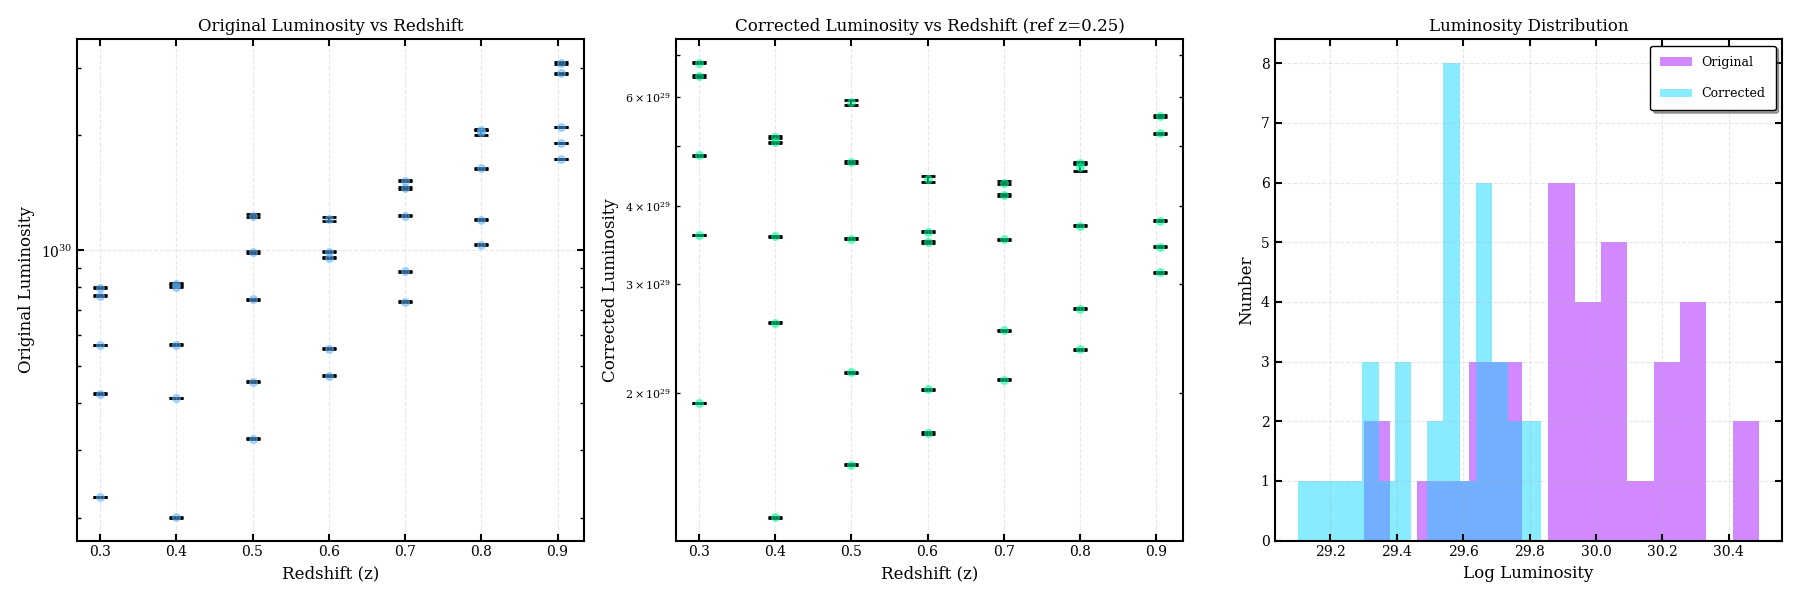

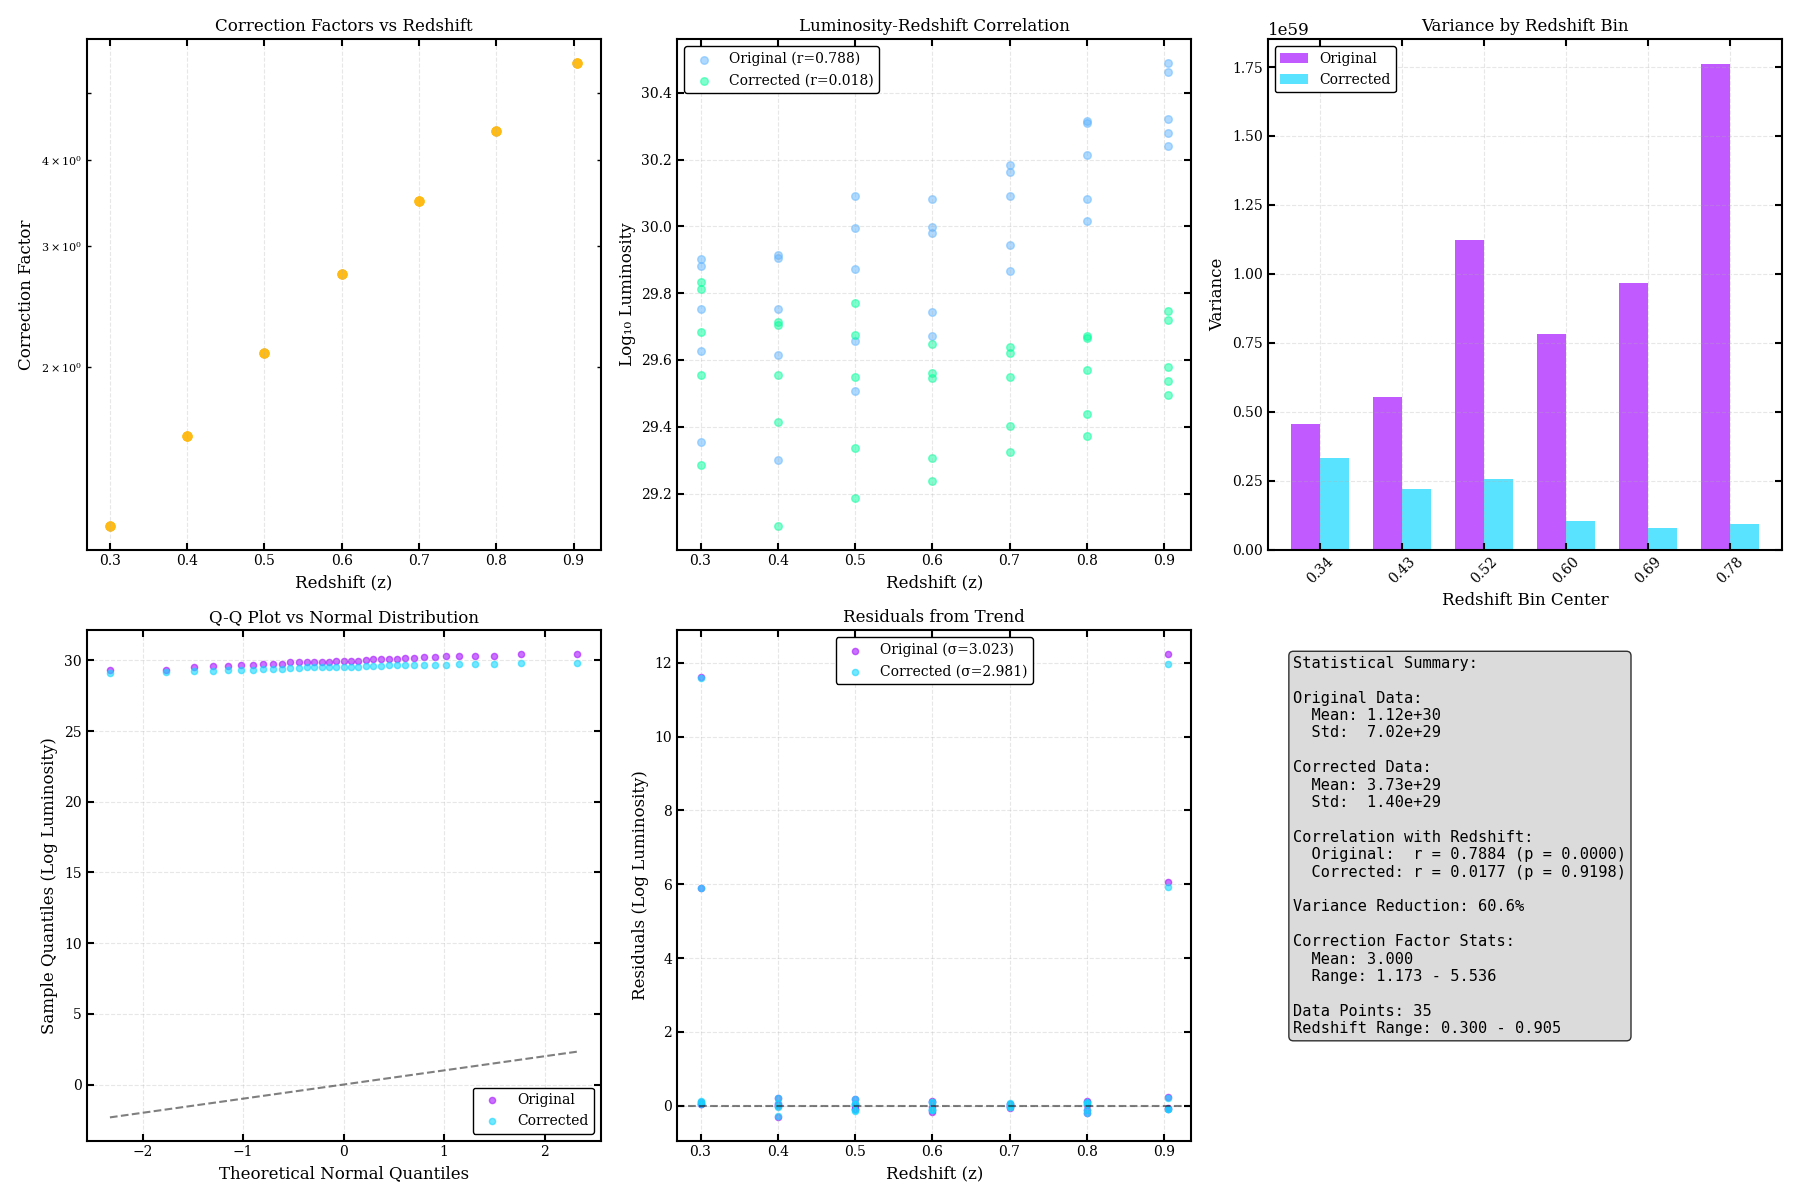

In [14]:
Corrected_Luminosities, Corrected_Luminosities_SD, Correction_Params, Corrected_Luminosities_Binned_Data = luminosity_evolution_correction(Luminosity_Total_Array, Luminosity_Total_SD_Array, Fixed_Z_Array, file_name = "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/Plots_For_Paper/Malmquist_Bias_Test_Bagpipes_MNRAS.png", ref_z=0.25, evolution_model='power_law', n_bins=7)

# Analyze results
analysis = analyze_correction_results(Luminosity_Total_Array, Corrected_Luminosities, Fixed_Z_Array, n_bins=7)



In [15]:
Corrected_Luminosities_Binned_Data_025_035 = Corrected_Luminosities_Binned_Data['corrected_luminosities_by_bin'][0]
Corrected_Luminosities_Binned_Data_035_045 = Corrected_Luminosities_Binned_Data['corrected_luminosities_by_bin'][1]
Corrected_Luminosities_Binned_Data_045_055 = Corrected_Luminosities_Binned_Data['corrected_luminosities_by_bin'][2]
Corrected_Luminosities_Binned_Data_055_065 = Corrected_Luminosities_Binned_Data['corrected_luminosities_by_bin'][3]
Corrected_Luminosities_Binned_Data_065_075 = Corrected_Luminosities_Binned_Data['corrected_luminosities_by_bin'][4]
Corrected_Luminosities_Binned_Data_075_085 = Corrected_Luminosities_Binned_Data['corrected_luminosities_by_bin'][5]
Corrected_Luminosities_Binned_Data_085_096 = Corrected_Luminosities_Binned_Data['corrected_luminosities_by_bin'][6]


Corrected_Luminosities_Binned_Data_SD_025_035 = Corrected_Luminosities_Binned_Data['corrected_luminosities_SD_by_bin'][0]
Corrected_Luminosities_Binned_Data_SD_035_045 = Corrected_Luminosities_Binned_Data['corrected_luminosities_SD_by_bin'][1]
Corrected_Luminosities_Binned_Data_SD_045_055 = Corrected_Luminosities_Binned_Data['corrected_luminosities_SD_by_bin'][2]
Corrected_Luminosities_Binned_Data_SD_055_065 = Corrected_Luminosities_Binned_Data['corrected_luminosities_SD_by_bin'][3]
Corrected_Luminosities_Binned_Data_SD_065_075 = Corrected_Luminosities_Binned_Data['corrected_luminosities_SD_by_bin'][4]
Corrected_Luminosities_Binned_Data_SD_075_085 = Corrected_Luminosities_Binned_Data['corrected_luminosities_SD_by_bin'][5]
Corrected_Luminosities_Binned_Data_SD_085_096 = Corrected_Luminosities_Binned_Data['corrected_luminosities_SD_by_bin'][6]




Luminosity_Corrected_Flux_Corrected_025_035, Luminosity_Corrected_Flux_Corrected_SD_025_035 = flux_from_luminosity_single(Corrected_Luminosities_Binned_Data_025_035, 
                                                                                Corrected_Luminosities_Binned_Data_SD_025_035, 
                                                                                DL_cm_025_035, 
                                                                                DL_SD_cm_025_035, 
                                                                                0.3)

Luminosity_Corrected_Flux_Corrected_035_045, Luminosity_Corrected_Flux_Corrected_SD_035_045 = flux_from_luminosity_single(Corrected_Luminosities_Binned_Data_035_045, 
                                                                                Corrected_Luminosities_Binned_Data_SD_035_045, 
                                                                                DL_cm_035_045, 
                                                                                DL_SD_cm_035_045, 
                                                                                0.4)

Luminosity_Corrected_Flux_Corrected_045_055, Luminosity_Corrected_Flux_Corrected_SD_045_055 = flux_from_luminosity_single(Corrected_Luminosities_Binned_Data_045_055, 
                                                                                Corrected_Luminosities_Binned_Data_SD_045_055, 
                                                                                DL_cm_045_055, 
                                                                                DL_SD_cm_045_055, 
                                                                                0.5)

Luminosity_Corrected_Flux_Corrected_055_065, Luminosity_Corrected_Flux_Corrected_SD_055_065 = flux_from_luminosity_single(Corrected_Luminosities_Binned_Data_055_065, 
                                                                                Corrected_Luminosities_Binned_Data_SD_055_065, 
                                                                                DL_cm_055_065, 
                                                                                DL_SD_cm_055_065, 
                                                                                0.6)

Luminosity_Corrected_Flux_Corrected_065_075, Luminosity_Corrected_Flux_Corrected_SD_065_075 = flux_from_luminosity_single(Corrected_Luminosities_Binned_Data_065_075, 
                                                                                Corrected_Luminosities_Binned_Data_SD_065_075, 
                                                                                DL_cm_065_075, 
                                                                                DL_SD_cm_065_075, 
                                                                                0.7)

Luminosity_Corrected_Flux_Corrected_075_085, Luminosity_Corrected_Flux_Corrected_SD_075_085 = flux_from_luminosity_single(Corrected_Luminosities_Binned_Data_075_085, 
                                                                                Corrected_Luminosities_Binned_Data_SD_075_085, 
                                                                                DL_cm_075_085, 
                                                                                DL_SD_cm_075_085, 
                                                                                0.8)

Luminosity_Corrected_Flux_Corrected_085_096, Luminosity_Corrected_Flux_Corrected_SD_085_096 = flux_from_luminosity_single(Corrected_Luminosities_Binned_Data_085_096, 
                                                                                Corrected_Luminosities_Binned_Data_SD_085_096, 
                                                                                DL_cm_085_096, 
                                                                                DL_SD_cm_085_096, 
                                                                                0.905)



In [16]:
Luminosity_Corrected_Flux_Corrected_025_035
Luminosity_Corrected_Flux_Corrected_SD_025_035

#### FINISH PUTTING IN THE UPDATED

array([0.05352151, 0.08854643, 0.16119545, 0.3395097 , 0.42419887])

In [17]:
Luminosity_Corrected_Flux_Corrected_025_035

array([ 51.435018  ,  95.98446017, 128.76242481, 181.64096419,
       172.91376228])

In [18]:
Corrected_Luminosities_Binned_Data_085_096

array([3.13514114e+29, 3.44729752e+29, 3.79496473e+29, 5.58721890e+29,
       5.24063137e+29])

In [19]:
"""
This is grabing the total magnitude of the filters.
Then it is using that total magnitude to find the ratio of AGN + Stellar and Stellar. This is after converting total mag to total flux.
"""

# Getting the ratio of the AGN+Stellar and the Stellar Flux
Ratio_of_Total_and_Stellar_03 = {
                                "G_Ratio": Luminosity_Corrected_Flux_Corrected_025_035[0] / SED_File["Flux_SersicNOne_GaussianFixedSigma"][1][0],
                                "G_Ratio_Err": (Luminosity_Corrected_Flux_Corrected_025_035[0]/SED_File["Flux_SersicNOne_GaussianFixedSigma"][1][0]) 
                                                * (np.sqrt((( Luminosity_Corrected_Flux_Corrected_SD_025_035[0] / Luminosity_Corrected_Flux_Corrected_025_035[0] ) ** 2) + 
                                                ((SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][1][0] / 
                                                  SED_File["Flux_SersicNOne_GaussianFixedSigma"][1][0])**2))),
                                
                                "R_Ratio": Luminosity_Corrected_Flux_Corrected_025_035[1] / SED_File["Flux_SersicNOne_GaussianFixedSigma"][1][1],
                                "R_Ratio_Err": (Luminosity_Corrected_Flux_Corrected_025_035[1]/SED_File["Flux_SersicNOne_GaussianFixedSigma"][1][1]) 
                                                * (np.sqrt((( Luminosity_Corrected_Flux_Corrected_SD_025_035[1] / Luminosity_Corrected_Flux_Corrected_025_035[1] ) ** 2) + 
                                                ((SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][1][1] / 
                                                  SED_File["Flux_SersicNOne_GaussianFixedSigma"][1][1])**2))),
                                
                                "I_Ratio": Luminosity_Corrected_Flux_Corrected_025_035[2] / SED_File["Flux_SersicNOne_GaussianFixedSigma"][1][2],
                                "I_Ratio_Err": (Luminosity_Corrected_Flux_Corrected_025_035[2]/SED_File["Flux_SersicNOne_GaussianFixedSigma"][1][2]) 
                                                * (np.sqrt((( Luminosity_Corrected_Flux_Corrected_SD_025_035[2] / Luminosity_Corrected_Flux_Corrected_025_035[2] ) ** 2) + 
                                                ((SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][1][2] / 
                                                  SED_File["Flux_SersicNOne_GaussianFixedSigma"][1][2])**2))),
                                
                                "Y_Ratio": Luminosity_Corrected_Flux_Corrected_025_035[3] / SED_File["Flux_SersicNOne_GaussianFixedSigma"][1][3],
                                "Y_Ratio_Err": (Luminosity_Corrected_Flux_Corrected_025_035[3]/SED_File["Flux_SersicNOne_GaussianFixedSigma"][1][3]) 
                                                * (np.sqrt((( Luminosity_Corrected_Flux_Corrected_SD_025_035[3] / Luminosity_Corrected_Flux_Corrected_025_035[3] ) ** 2) + 
                                                ((SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][1][3] / 
                                                  SED_File["Flux_SersicNOne_GaussianFixedSigma"][1][3])**2))),
                                
                                "Z_Ratio": Luminosity_Corrected_Flux_Corrected_025_035[4] / SED_File["Flux_SersicNOne_GaussianFixedSigma"][1][4],
                                "Z_Ratio_Err": (Luminosity_Corrected_Flux_Corrected_025_035[4]/SED_File["Flux_SersicNOne_GaussianFixedSigma"][1][4]) 
                                                * (np.sqrt((( Luminosity_Corrected_Flux_Corrected_SD_025_035[4] / Luminosity_Corrected_Flux_Corrected_025_035[4] ) ** 2) + 
                                                ((SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][1][4] / 
                                                  SED_File["Flux_SersicNOne_GaussianFixedSigma"][1][4])**2)))
                                }

Ratio_of_Total_and_Stellar_04 = {
                                "G_Ratio": Luminosity_Corrected_Flux_Corrected_035_045[0] / SED_File["Flux_SersicNOne_GaussianFixedSigma"][1][0],
                                "G_Ratio_Err": (Luminosity_Corrected_Flux_Corrected_035_045[0]/SED_File["Flux_SersicNOne_GaussianFixedSigma"][1][0]) 
                                                * (np.sqrt((( Luminosity_Corrected_Flux_Corrected_SD_035_045[0] / Luminosity_Corrected_Flux_Corrected_035_045[0] ) ** 2) + 
                                                ((SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][1][0] / 
                                                  SED_File["Flux_SersicNOne_GaussianFixedSigma"][1][0])**2))),
                                
                                "R_Ratio": Luminosity_Corrected_Flux_Corrected_035_045[1] / SED_File["Flux_SersicNOne_GaussianFixedSigma"][1][1],
                                "R_Ratio_Err": (Luminosity_Corrected_Flux_Corrected_035_045[1]/SED_File["Flux_SersicNOne_GaussianFixedSigma"][1][1]) 
                                                * (np.sqrt((( Luminosity_Corrected_Flux_Corrected_SD_035_045[1] / Luminosity_Corrected_Flux_Corrected_035_045[1] ) ** 2) + 
                                                ((SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][1][1] / 
                                                  SED_File["Flux_SersicNOne_GaussianFixedSigma"][1][1])**2))),
                                
                                "I_Ratio": Luminosity_Corrected_Flux_Corrected_035_045[2] / SED_File["Flux_SersicNOne_GaussianFixedSigma"][1][2],
                                "I_Ratio_Err": (Luminosity_Corrected_Flux_Corrected_035_045[2]/SED_File["Flux_SersicNOne_GaussianFixedSigma"][1][2]) 
                                                * (np.sqrt((( Luminosity_Corrected_Flux_Corrected_SD_035_045[2] / Luminosity_Corrected_Flux_Corrected_035_045[2] ) ** 2) + 
                                                ((SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][1][2] / 
                                                  SED_File["Flux_SersicNOne_GaussianFixedSigma"][1][2])**2))),
                                
                                "Y_Ratio": Luminosity_Corrected_Flux_Corrected_035_045[3] / SED_File["Flux_SersicNOne_GaussianFixedSigma"][1][3],
                                "Y_Ratio_Err": (Luminosity_Corrected_Flux_Corrected_035_045[3]/SED_File["Flux_SersicNOne_GaussianFixedSigma"][1][3]) 
                                                * (np.sqrt((( Luminosity_Corrected_Flux_Corrected_SD_035_045[3] / Luminosity_Corrected_Flux_Corrected_035_045[3] ) ** 2) + 
                                                ((SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][1][3] / 
                                                  SED_File["Flux_SersicNOne_GaussianFixedSigma"][1][3])**2))),
                                
                                "Z_Ratio": Luminosity_Corrected_Flux_Corrected_035_045[4] / SED_File["Flux_SersicNOne_GaussianFixedSigma"][1][4],
                                "Z_Ratio_Err": (Luminosity_Corrected_Flux_Corrected_035_045[4]/SED_File["Flux_SersicNOne_GaussianFixedSigma"][1][4]) 
                                                * (np.sqrt((( Luminosity_Corrected_Flux_Corrected_SD_035_045[4] / Luminosity_Corrected_Flux_Corrected_035_045[4] ) ** 2) + 
                                                ((SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][1][4] / 
                                                  SED_File["Flux_SersicNOne_GaussianFixedSigma"][1][4])**2)))
                                }
                    
Ratio_of_Total_and_Stellar_05 = {
                                "G_Ratio": Luminosity_Corrected_Flux_Corrected_045_055[0] / SED_File["Flux_SersicNOne_GaussianFixedSigma"][2][0],
                                "G_Ratio_Err": (Luminosity_Corrected_Flux_Corrected_045_055[0]/SED_File["Flux_SersicNOne_GaussianFixedSigma"][2][0]) 
                                                * (np.sqrt((( Luminosity_Corrected_Flux_Corrected_SD_045_055[0] / Luminosity_Corrected_Flux_Corrected_045_055[0] ) ** 2) + 
                                                ((SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][2][0] / 
                                                  SED_File["Flux_SersicNOne_GaussianFixedSigma"][2][0])**2))),
                                
                                "R_Ratio": Luminosity_Corrected_Flux_Corrected_045_055[1] / SED_File["Flux_SersicNOne_GaussianFixedSigma"][2][1],
                                "R_Ratio_Err": (Luminosity_Corrected_Flux_Corrected_045_055[1]/SED_File["Flux_SersicNOne_GaussianFixedSigma"][2][1]) 
                                                * (np.sqrt((( Luminosity_Corrected_Flux_Corrected_SD_045_055[1] / Luminosity_Corrected_Flux_Corrected_045_055[1] ) ** 2) + 
                                                ((SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][2][1] / 
                                                  SED_File["Flux_SersicNOne_GaussianFixedSigma"][2][1])**2))),
                                
                                "I_Ratio": Luminosity_Corrected_Flux_Corrected_045_055[2] / SED_File["Flux_SersicNOne_GaussianFixedSigma"][2][2],
                                "I_Ratio_Err": (Luminosity_Corrected_Flux_Corrected_045_055[2]/SED_File["Flux_SersicNOne_GaussianFixedSigma"][2][2]) 
                                                * (np.sqrt((( Luminosity_Corrected_Flux_Corrected_SD_045_055[2] / Luminosity_Corrected_Flux_Corrected_045_055[2] ) ** 2) + 
                                                ((SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][2][2] / 
                                                  SED_File["Flux_SersicNOne_GaussianFixedSigma"][2][2])**2))),
                                
                                "Y_Ratio": Luminosity_Corrected_Flux_Corrected_045_055[3] / SED_File["Flux_SersicNOne_GaussianFixedSigma"][2][3],
                                "Y_Ratio_Err": (Luminosity_Corrected_Flux_Corrected_045_055[3]/SED_File["Flux_SersicNOne_GaussianFixedSigma"][2][3]) 
                                                * (np.sqrt((( Luminosity_Corrected_Flux_Corrected_SD_045_055[3] / Luminosity_Corrected_Flux_Corrected_045_055[3] ) ** 2) + 
                                                ((SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][2][3] / 
                                                  SED_File["Flux_SersicNOne_GaussianFixedSigma"][2][3])**2))),
                                
                                "Z_Ratio": Luminosity_Corrected_Flux_Corrected_045_055[4] / SED_File["Flux_SersicNOne_GaussianFixedSigma"][2][4],
                                "Z_Ratio_Err": (Luminosity_Corrected_Flux_Corrected_045_055[4]/SED_File["Flux_SersicNOne_GaussianFixedSigma"][2][4]) 
                                                * (np.sqrt((( Luminosity_Corrected_Flux_Corrected_SD_045_055[4] / Luminosity_Corrected_Flux_Corrected_045_055[4] ) ** 2) + 
                                                ((SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][2][4] / 
                                                  SED_File["Flux_SersicNOne_GaussianFixedSigma"][2][4])**2)))
                                }

Ratio_of_Total_and_Stellar_06 = {
                                "G_Ratio": Luminosity_Corrected_Flux_Corrected_055_065[0] / SED_File["Flux_SersicNOne_GaussianFixedSigma"][3][0],
                                "G_Ratio_Err": (Luminosity_Corrected_Flux_Corrected_055_065[0]/SED_File["Flux_SersicNOne_GaussianFixedSigma"][3][0]) 
                                                * (np.sqrt((( Luminosity_Corrected_Flux_Corrected_SD_055_065[0] / Luminosity_Corrected_Flux_Corrected_055_065[0] ) ** 2) + 
                                                ((SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][3][0] / 
                                                  SED_File["Flux_SersicNOne_GaussianFixedSigma"][3][0])**2))),
                                
                                "R_Ratio": Luminosity_Corrected_Flux_Corrected_055_065[1] / SED_File["Flux_SersicNOne_GaussianFixedSigma"][3][1],
                                "R_Ratio_Err": (Luminosity_Corrected_Flux_Corrected_055_065[1]/SED_File["Flux_SersicNOne_GaussianFixedSigma"][3][1]) 
                                                * (np.sqrt((( Luminosity_Corrected_Flux_Corrected_SD_055_065[1] / Luminosity_Corrected_Flux_Corrected_055_065[1] ) ** 2) + 
                                                ((SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][3][1] / 
                                                  SED_File["Flux_SersicNOne_GaussianFixedSigma"][3][1])**2))),
                                
                                "I_Ratio": Luminosity_Corrected_Flux_Corrected_055_065[2] / SED_File["Flux_SersicNOne_GaussianFixedSigma"][3][2],
                                "I_Ratio_Err": (Luminosity_Corrected_Flux_Corrected_055_065[2]/SED_File["Flux_SersicNOne_GaussianFixedSigma"][3][2]) 
                                                * (np.sqrt((( Luminosity_Corrected_Flux_Corrected_SD_055_065[2] / Luminosity_Corrected_Flux_Corrected_055_065[2] ) ** 2) + 
                                                ((SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][3][2] / 
                                                  SED_File["Flux_SersicNOne_GaussianFixedSigma"][3][2])**2))),
                                
                                "Y_Ratio": Luminosity_Corrected_Flux_Corrected_055_065[3] / SED_File["Flux_SersicNOne_GaussianFixedSigma"][3][3],
                                "Y_Ratio_Err": (Luminosity_Corrected_Flux_Corrected_055_065[3]/SED_File["Flux_SersicNOne_GaussianFixedSigma"][3][3]) 
                                                * (np.sqrt((( Luminosity_Corrected_Flux_Corrected_SD_055_065[3] / Luminosity_Corrected_Flux_Corrected_055_065[3] ) ** 2) + 
                                                ((SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][3][3] / 
                                                  SED_File["Flux_SersicNOne_GaussianFixedSigma"][3][3])**2))),
                                
                                "Z_Ratio": Luminosity_Corrected_Flux_Corrected_055_065[4] / SED_File["Flux_SersicNOne_GaussianFixedSigma"][3][4],
                                "Z_Ratio_Err": (Luminosity_Corrected_Flux_Corrected_055_065[4]/SED_File["Flux_SersicNOne_GaussianFixedSigma"][3][4]) 
                                                * (np.sqrt((( Luminosity_Corrected_Flux_Corrected_SD_055_065[4] / Luminosity_Corrected_Flux_Corrected_055_065[4] ) ** 2) + 
                                                ((SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][3][4] / 
                                                  SED_File["Flux_SersicNOne_GaussianFixedSigma"][3][4])**2)))
                                }

Ratio_of_Total_and_Stellar_07 = {
                                "G_Ratio": Luminosity_Corrected_Flux_Corrected_065_075[0] / SED_File["Flux_SersicNOne_GaussianFixedSigma"][4][0],
                                "G_Ratio_Err": (Luminosity_Corrected_Flux_Corrected_065_075[0]/SED_File["Flux_SersicNOne_GaussianFixedSigma"][4][0]) 
                                                * (np.sqrt((( Luminosity_Corrected_Flux_Corrected_SD_065_075[0] / Luminosity_Corrected_Flux_Corrected_065_075[0] ) ** 2) + 
                                                ((SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][4][0] / 
                                                  SED_File["Flux_SersicNOne_GaussianFixedSigma"][4][0])**2))),
                                
                                "R_Ratio": Luminosity_Corrected_Flux_Corrected_065_075[1] / SED_File["Flux_SersicNOne_GaussianFixedSigma"][4][1],
                                "R_Ratio_Err": (Luminosity_Corrected_Flux_Corrected_065_075[1]/SED_File["Flux_SersicNOne_GaussianFixedSigma"][4][1]) 
                                                * (np.sqrt((( Luminosity_Corrected_Flux_Corrected_SD_065_075[1] / Luminosity_Corrected_Flux_Corrected_065_075[1] ) ** 2) + 
                                                ((SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][4][1] / 
                                                  SED_File["Flux_SersicNOne_GaussianFixedSigma"][4][1])**2))),
                                
                                "I_Ratio": Luminosity_Corrected_Flux_Corrected_065_075[2] / SED_File["Flux_SersicNOne_GaussianFixedSigma"][4][2],
                                "I_Ratio_Err": (Luminosity_Corrected_Flux_Corrected_065_075[2]/SED_File["Flux_SersicNOne_GaussianFixedSigma"][4][2]) 
                                                * (np.sqrt((( Luminosity_Corrected_Flux_Corrected_SD_065_075[2] / Luminosity_Corrected_Flux_Corrected_065_075[2] ) ** 2) + 
                                                ((SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][4][2] / 
                                                  SED_File["Flux_SersicNOne_GaussianFixedSigma"][4][2])**2))),
                                
                                "Y_Ratio": Luminosity_Corrected_Flux_Corrected_065_075[3] / SED_File["Flux_SersicNOne_GaussianFixedSigma"][4][3],
                                "Y_Ratio_Err": (Luminosity_Corrected_Flux_Corrected_065_075[3]/SED_File["Flux_SersicNOne_GaussianFixedSigma"][4][3]) 
                                                * (np.sqrt((( Luminosity_Corrected_Flux_Corrected_SD_065_075[3] / Luminosity_Corrected_Flux_Corrected_065_075[3] ) ** 2) + 
                                                ((SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][4][3] / 
                                                  SED_File["Flux_SersicNOne_GaussianFixedSigma"][4][3])**2))),
                                
                                "Z_Ratio": Luminosity_Corrected_Flux_Corrected_065_075[4] / SED_File["Flux_SersicNOne_GaussianFixedSigma"][4][4],
                                "Z_Ratio_Err": (Luminosity_Corrected_Flux_Corrected_065_075[4]/SED_File["Flux_SersicNOne_GaussianFixedSigma"][4][4]) 
                                                * (np.sqrt((( Luminosity_Corrected_Flux_Corrected_SD_065_075[4] / Luminosity_Corrected_Flux_Corrected_065_075[4] ) ** 2) + 
                                                ((SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][4][4] / 
                                                  SED_File["Flux_SersicNOne_GaussianFixedSigma"][4][4])**2)))
                                }

Ratio_of_Total_and_Stellar_08 = {
                                "G_Ratio": Luminosity_Corrected_Flux_Corrected_075_085[0] / SED_File["Flux_SersicNOne_GaussianFixedSigma"][5][0],
                                "G_Ratio_Err": (Luminosity_Corrected_Flux_Corrected_075_085[0]/SED_File["Flux_SersicNOne_GaussianFixedSigma"][5][0]) 
                                                * (np.sqrt((( Luminosity_Corrected_Flux_Corrected_SD_075_085[0] / Luminosity_Corrected_Flux_Corrected_075_085[0] ) ** 2) + 
                                                ((SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][5][0] / 
                                                  SED_File["Flux_SersicNOne_GaussianFixedSigma"][5][0])**2))),
                                
                                "R_Ratio": Luminosity_Corrected_Flux_Corrected_075_085[1] / SED_File["Flux_SersicNOne_GaussianFixedSigma"][5][1],
                                "R_Ratio_Err": (Luminosity_Corrected_Flux_Corrected_075_085[1]/SED_File["Flux_SersicNOne_GaussianFixedSigma"][5][1]) 
                                                * (np.sqrt((( Luminosity_Corrected_Flux_Corrected_SD_075_085[1] / Luminosity_Corrected_Flux_Corrected_075_085[1] ) ** 2) + 
                                                ((SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][5][1] / 
                                                  SED_File["Flux_SersicNOne_GaussianFixedSigma"][5][1])**2))),
                                
                                "I_Ratio": Luminosity_Corrected_Flux_Corrected_075_085[2] / SED_File["Flux_SersicNOne_GaussianFixedSigma"][5][2],
                                "I_Ratio_Err": (Luminosity_Corrected_Flux_Corrected_075_085[2]/SED_File["Flux_SersicNOne_GaussianFixedSigma"][5][2]) 
                                                * (np.sqrt((( Luminosity_Corrected_Flux_Corrected_SD_075_085[2] / Luminosity_Corrected_Flux_Corrected_075_085[2] ) ** 2) + 
                                                ((SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][5][2] / 
                                                  SED_File["Flux_SersicNOne_GaussianFixedSigma"][5][2])**2))),
                                
                                "Y_Ratio": Luminosity_Corrected_Flux_Corrected_075_085[3] / SED_File["Flux_SersicNOne_GaussianFixedSigma"][5][3],
                                "Y_Ratio_Err": (Luminosity_Corrected_Flux_Corrected_075_085[3]/SED_File["Flux_SersicNOne_GaussianFixedSigma"][5][3]) 
                                                * (np.sqrt((( Luminosity_Corrected_Flux_Corrected_SD_075_085[3] / Luminosity_Corrected_Flux_Corrected_075_085[3] ) ** 2) + 
                                                ((SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][5][3] / 
                                                  SED_File["Flux_SersicNOne_GaussianFixedSigma"][5][3])**2))),
                                
                                "Z_Ratio": Luminosity_Corrected_Flux_Corrected_075_085[4] / SED_File["Flux_SersicNOne_GaussianFixedSigma"][5][4],
                                "Z_Ratio_Err": (Luminosity_Corrected_Flux_Corrected_075_085[4]/SED_File["Flux_SersicNOne_GaussianFixedSigma"][5][4]) 
                                                * (np.sqrt((( Luminosity_Corrected_Flux_Corrected_SD_075_085[4] / Luminosity_Corrected_Flux_Corrected_075_085[4] ) ** 2) + 
                                                ((SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][5][4] / 
                                                  SED_File["Flux_SersicNOne_GaussianFixedSigma"][5][4])**2)))
                                  }

Ratio_of_Total_and_Stellar_0905 = {
                                "G_Ratio": Luminosity_Corrected_Flux_Corrected_085_096[0] / SED_File["Flux_SersicNOne_GaussianFixedSigma"][6][0],
                                "G_Ratio_Err": (Luminosity_Corrected_Flux_Corrected_085_096[0]/SED_File["Flux_SersicNOne_GaussianFixedSigma"][6][0]) 
                                                * (np.sqrt((( Luminosity_Corrected_Flux_Corrected_SD_085_096[0] / Luminosity_Corrected_Flux_Corrected_085_096[0] ) ** 2) + 
                                                ((SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][6][0] / 
                                                  SED_File["Flux_SersicNOne_GaussianFixedSigma"][6][0])**2))),
                                
                                "R_Ratio": Luminosity_Corrected_Flux_Corrected_085_096[1] / SED_File["Flux_SersicNOne_GaussianFixedSigma"][6][1],
                                "R_Ratio_Err": (Luminosity_Corrected_Flux_Corrected_085_096[1]/SED_File["Flux_SersicNOne_GaussianFixedSigma"][6][1]) 
                                                * (np.sqrt((( Luminosity_Corrected_Flux_Corrected_SD_085_096[1] / Luminosity_Corrected_Flux_Corrected_085_096[1] ) ** 2) + 
                                                ((SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][6][1] / 
                                                  SED_File["Flux_SersicNOne_GaussianFixedSigma"][6][1])**2))),
                                
                                "I_Ratio": Luminosity_Corrected_Flux_Corrected_085_096[2] / SED_File["Flux_SersicNOne_GaussianFixedSigma"][6][2],
                                "I_Ratio_Err": (Luminosity_Corrected_Flux_Corrected_085_096[2]/SED_File["Flux_SersicNOne_GaussianFixedSigma"][6][2]) 
                                                * (np.sqrt((( Luminosity_Corrected_Flux_Corrected_SD_085_096[2] / Luminosity_Corrected_Flux_Corrected_085_096[2] ) ** 2) + 
                                                ((SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][6][2] / 
                                                  SED_File["Flux_SersicNOne_GaussianFixedSigma"][6][2])**2))),
                                
                                "Y_Ratio": Luminosity_Corrected_Flux_Corrected_085_096[3] / SED_File["Flux_SersicNOne_GaussianFixedSigma"][6][3],
                                "Y_Ratio_Err": (Luminosity_Corrected_Flux_Corrected_085_096[3]/SED_File["Flux_SersicNOne_GaussianFixedSigma"][6][3]) 
                                                * (np.sqrt((( Luminosity_Corrected_Flux_Corrected_SD_085_096[3] / Luminosity_Corrected_Flux_Corrected_085_096[3] ) ** 2) + 
                                                ((SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][6][3] / 
                                                  SED_File["Flux_SersicNOne_GaussianFixedSigma"][6][3])**2))),
                                
                                "Z_Ratio": Luminosity_Corrected_Flux_Corrected_085_096[4] / SED_File["Flux_SersicNOne_GaussianFixedSigma"][6][4],
                                "Z_Ratio_Err": (Luminosity_Corrected_Flux_Corrected_085_096[4]/SED_File["Flux_SersicNOne_GaussianFixedSigma"][6][4]) 
                                                * (np.sqrt((( Luminosity_Corrected_Flux_Corrected_SD_085_096[4] / Luminosity_Corrected_Flux_Corrected_085_096[4] ) ** 2) + 
                                                ((SED_File["Flux_SersicNOne_GaussianFixedSigma_SD"][6][4] / 
                                                  SED_File["Flux_SersicNOne_GaussianFixedSigma"][6][4])**2)))
                                }






# Convert ratios to stellar fractions with proper error propagation
# Stellar fraction = Stellar_Flux / Total_Flux = 1 / (Total_Flux / Stellar_Flux) = 1 / Ratio
# Error propagation: if y = 1/x, then σ_y = σ_x / x²

Stellar_Fraction_03 = {
    "G_Fraction": 1.0 / Ratio_of_Total_and_Stellar_03["G_Ratio"],
    "G_Fraction_Err": Ratio_of_Total_and_Stellar_03["G_Ratio_Err"] / (Ratio_of_Total_and_Stellar_03["G_Ratio"]**2),
    
    "R_Fraction": 1.0 / Ratio_of_Total_and_Stellar_03["R_Ratio"],
    "R_Fraction_Err": Ratio_of_Total_and_Stellar_03["R_Ratio_Err"] / (Ratio_of_Total_and_Stellar_03["R_Ratio"]**2),
    
    "I_Fraction": 1.0 / Ratio_of_Total_and_Stellar_03["I_Ratio"],
    "I_Fraction_Err": Ratio_of_Total_and_Stellar_03["I_Ratio_Err"] / (Ratio_of_Total_and_Stellar_03["I_Ratio"]**2),
    
    "Y_Fraction": 1.0 / Ratio_of_Total_and_Stellar_03["Y_Ratio"],
    "Y_Fraction_Err": Ratio_of_Total_and_Stellar_03["Y_Ratio_Err"] / (Ratio_of_Total_and_Stellar_03["Y_Ratio"]**2),
    
    "Z_Fraction": 1.0 / Ratio_of_Total_and_Stellar_03["Z_Ratio"],
    "Z_Fraction_Err": Ratio_of_Total_and_Stellar_03["Z_Ratio_Err"] / (Ratio_of_Total_and_Stellar_03["Z_Ratio"]**2)
}

Stellar_Fraction_04 = {
    "G_Fraction": 1.0 / Ratio_of_Total_and_Stellar_04["G_Ratio"],
    "G_Fraction_Err": Ratio_of_Total_and_Stellar_04["G_Ratio_Err"] / (Ratio_of_Total_and_Stellar_04["G_Ratio"]**2),
    
    "R_Fraction": 1.0 / Ratio_of_Total_and_Stellar_04["R_Ratio"],
    "R_Fraction_Err": Ratio_of_Total_and_Stellar_04["R_Ratio_Err"] / (Ratio_of_Total_and_Stellar_04["R_Ratio"]**2),
    
    "I_Fraction": 1.0 / Ratio_of_Total_and_Stellar_04["I_Ratio"],
    "I_Fraction_Err": Ratio_of_Total_and_Stellar_04["I_Ratio_Err"] / (Ratio_of_Total_and_Stellar_04["I_Ratio"]**2),
    
    "Y_Fraction": 1.0 / Ratio_of_Total_and_Stellar_04["Y_Ratio"],
    "Y_Fraction_Err": Ratio_of_Total_and_Stellar_04["Y_Ratio_Err"] / (Ratio_of_Total_and_Stellar_04["Y_Ratio"]**2),
    
    "Z_Fraction": 1.0 / Ratio_of_Total_and_Stellar_04["Z_Ratio"],
    "Z_Fraction_Err": Ratio_of_Total_and_Stellar_04["Z_Ratio_Err"] / (Ratio_of_Total_and_Stellar_04["Z_Ratio"]**2)
}

Stellar_Fraction_05 = {
    "G_Fraction": 1.0 / Ratio_of_Total_and_Stellar_05["G_Ratio"],
    "G_Fraction_Err": Ratio_of_Total_and_Stellar_05["G_Ratio_Err"] / (Ratio_of_Total_and_Stellar_05["G_Ratio"]**2),
    
    "R_Fraction": 1.0 / Ratio_of_Total_and_Stellar_05["R_Ratio"],
    "R_Fraction_Err": Ratio_of_Total_and_Stellar_05["R_Ratio_Err"] / (Ratio_of_Total_and_Stellar_05["R_Ratio"]**2),
    
    "I_Fraction": 1.0 / Ratio_of_Total_and_Stellar_05["I_Ratio"],
    "I_Fraction_Err": Ratio_of_Total_and_Stellar_05["I_Ratio_Err"] / (Ratio_of_Total_and_Stellar_05["I_Ratio"]**2),
    
    "Y_Fraction": 1.0 / Ratio_of_Total_and_Stellar_05["Y_Ratio"],
    "Y_Fraction_Err": Ratio_of_Total_and_Stellar_05["Y_Ratio_Err"] / (Ratio_of_Total_and_Stellar_05["Y_Ratio"]**2),
    
    "Z_Fraction": 1.0 / Ratio_of_Total_and_Stellar_05["Z_Ratio"],
    "Z_Fraction_Err": Ratio_of_Total_and_Stellar_05["Z_Ratio_Err"] / (Ratio_of_Total_and_Stellar_05["Z_Ratio"]**2)
}

Stellar_Fraction_06 = {
    "G_Fraction": 1.0 / Ratio_of_Total_and_Stellar_06["G_Ratio"],
    "G_Fraction_Err": Ratio_of_Total_and_Stellar_06["G_Ratio_Err"] / (Ratio_of_Total_and_Stellar_06["G_Ratio"]**2),
    
    "R_Fraction": 1.0 / Ratio_of_Total_and_Stellar_06["R_Ratio"],
    "R_Fraction_Err": Ratio_of_Total_and_Stellar_06["R_Ratio_Err"] / (Ratio_of_Total_and_Stellar_06["R_Ratio"]**2),
    
    "I_Fraction": 1.0 / Ratio_of_Total_and_Stellar_06["I_Ratio"],
    "I_Fraction_Err": Ratio_of_Total_and_Stellar_06["I_Ratio_Err"] / (Ratio_of_Total_and_Stellar_06["I_Ratio"]**2),
    
    "Y_Fraction": 1.0 / Ratio_of_Total_and_Stellar_06["Y_Ratio"],
    "Y_Fraction_Err": Ratio_of_Total_and_Stellar_06["Y_Ratio_Err"] / (Ratio_of_Total_and_Stellar_06["Y_Ratio"]**2),
    
    "Z_Fraction": 1.0 / Ratio_of_Total_and_Stellar_06["Z_Ratio"],
    "Z_Fraction_Err": Ratio_of_Total_and_Stellar_06["Z_Ratio_Err"] / (Ratio_of_Total_and_Stellar_06["Z_Ratio"]**2)
}

Stellar_Fraction_07 = {
    "G_Fraction": 1.0 / Ratio_of_Total_and_Stellar_07["G_Ratio"],
    "G_Fraction_Err": Ratio_of_Total_and_Stellar_07["G_Ratio_Err"] / (Ratio_of_Total_and_Stellar_07["G_Ratio"]**2),
    
    "R_Fraction": 1.0 / Ratio_of_Total_and_Stellar_07["R_Ratio"],
    "R_Fraction_Err": Ratio_of_Total_and_Stellar_07["R_Ratio_Err"] / (Ratio_of_Total_and_Stellar_07["R_Ratio"]**2),
    
    "I_Fraction": 1.0 / Ratio_of_Total_and_Stellar_07["I_Ratio"],
    "I_Fraction_Err": Ratio_of_Total_and_Stellar_07["I_Ratio_Err"] / (Ratio_of_Total_and_Stellar_07["I_Ratio"]**2),
    
    "Y_Fraction": 1.0 / Ratio_of_Total_and_Stellar_07["Y_Ratio"],
    "Y_Fraction_Err": Ratio_of_Total_and_Stellar_07["Y_Ratio_Err"] / (Ratio_of_Total_and_Stellar_07["Y_Ratio"]**2),
    
    "Z_Fraction": 1.0 / Ratio_of_Total_and_Stellar_07["Z_Ratio"],
    "Z_Fraction_Err": Ratio_of_Total_and_Stellar_07["Z_Ratio_Err"] / (Ratio_of_Total_and_Stellar_07["Z_Ratio"]**2)
}

Stellar_Fraction_08 = {
    "G_Fraction": 1.0 / Ratio_of_Total_and_Stellar_08["G_Ratio"],
    "G_Fraction_Err": Ratio_of_Total_and_Stellar_08["G_Ratio_Err"] / (Ratio_of_Total_and_Stellar_08["G_Ratio"]**2),
    
    "R_Fraction": 1.0 / Ratio_of_Total_and_Stellar_08["R_Ratio"],
    "R_Fraction_Err": Ratio_of_Total_and_Stellar_08["R_Ratio_Err"] / (Ratio_of_Total_and_Stellar_08["R_Ratio"]**2),
    
    "I_Fraction": 1.0 / Ratio_of_Total_and_Stellar_08["I_Ratio"],
    "I_Fraction_Err": Ratio_of_Total_and_Stellar_08["I_Ratio_Err"] / (Ratio_of_Total_and_Stellar_08["I_Ratio"]**2),
    
    "Y_Fraction": 1.0 / Ratio_of_Total_and_Stellar_08["Y_Ratio"],
    "Y_Fraction_Err": Ratio_of_Total_and_Stellar_08["Y_Ratio_Err"] / (Ratio_of_Total_and_Stellar_08["Y_Ratio"]**2),
    
    "Z_Fraction": 1.0 / Ratio_of_Total_and_Stellar_08["Z_Ratio"],
    "Z_Fraction_Err": Ratio_of_Total_and_Stellar_08["Z_Ratio_Err"] / (Ratio_of_Total_and_Stellar_08["Z_Ratio"]**2)
}

Stellar_Fraction_0905 = {
    "G_Fraction": 1.0 / Ratio_of_Total_and_Stellar_0905["G_Ratio"],
    "G_Fraction_Err": Ratio_of_Total_and_Stellar_0905["G_Ratio_Err"] / (Ratio_of_Total_and_Stellar_0905["G_Ratio"]**2),
    
    "R_Fraction": 1.0 / Ratio_of_Total_and_Stellar_0905["R_Ratio"],
    "R_Fraction_Err": Ratio_of_Total_and_Stellar_0905["R_Ratio_Err"] / (Ratio_of_Total_and_Stellar_0905["R_Ratio"]**2),
    
    "I_Fraction": 1.0 / Ratio_of_Total_and_Stellar_0905["I_Ratio"],
    "I_Fraction_Err": Ratio_of_Total_and_Stellar_0905["I_Ratio_Err"] / (Ratio_of_Total_and_Stellar_0905["I_Ratio"]**2),
    
    "Y_Fraction": 1.0 / Ratio_of_Total_and_Stellar_0905["Y_Ratio"],
    "Y_Fraction_Err": Ratio_of_Total_and_Stellar_0905["Y_Ratio_Err"] / (Ratio_of_Total_and_Stellar_0905["Y_Ratio"]**2),
    
    "Z_Fraction": 1.0 / Ratio_of_Total_and_Stellar_0905["Z_Ratio"],
    "Z_Fraction_Err": Ratio_of_Total_and_Stellar_0905["Z_Ratio_Err"] / (Ratio_of_Total_and_Stellar_0905["Z_Ratio"]**2)
}


# Apply the stellar fraction to get corrected stellar luminosity
Corrected_Stellar_Flux_From_Lum_025_035 = {"G_Stellar_Cor_Flux_From_Lum": Stellar_Fraction_03["G_Fraction"] * Luminosity_Corrected_Flux_Corrected_025_035[0], 
                                        "G_Stellar_Cor_Flux_From_Lum_Err":  Luminosity_Corrected_Flux_Corrected_025_035[0] * np. sqrt( 
                                            ((Stellar_Fraction_03["G_Fraction_Err"] / Stellar_Fraction_03["G_Fraction"])**2) + 
                                            ((Luminosity_Corrected_Flux_Corrected_SD_025_035[0] / Luminosity_Corrected_Flux_Corrected_025_035[0])**2)),

                                        "R_Stellar_Cor_Flux_From_Lum": Stellar_Fraction_03["R_Fraction"] * Luminosity_Corrected_Flux_Corrected_025_035[1], 
                                        "R_Stellar_Cor_Flux_From_Lum_Err":  Luminosity_Corrected_Flux_Corrected_025_035[1] * np. sqrt( 
                                            ((Stellar_Fraction_03["R_Fraction_Err"] / Stellar_Fraction_03["R_Fraction"])**2) + 
                                            ((Luminosity_Corrected_Flux_Corrected_SD_025_035[1] / Luminosity_Corrected_Flux_Corrected_025_035[1])**2)),

                                        "I_Stellar_Cor_Flux_From_Lum": Stellar_Fraction_03["I_Fraction"] * Luminosity_Corrected_Flux_Corrected_025_035[2], 
                                        "I_Stellar_Cor_Flux_From_Lum_Err":  Luminosity_Corrected_Flux_Corrected_025_035[2] * np. sqrt( 
                                            ((Stellar_Fraction_03["I_Fraction_Err"] / Stellar_Fraction_03["I_Fraction"])**2) + 
                                            ((Luminosity_Corrected_Flux_Corrected_SD_025_035[2] / Luminosity_Corrected_Flux_Corrected_025_035[2])**2)),

                                        "Y_Stellar_Cor_Flux_From_Lum": Stellar_Fraction_03["Y_Fraction"] * Luminosity_Corrected_Flux_Corrected_025_035[3], 
                                        "Y_Stellar_Cor_Flux_From_Lum_Err":  Luminosity_Corrected_Flux_Corrected_025_035[3] * np. sqrt( 
                                            ((Stellar_Fraction_03["Y_Fraction_Err"] / Stellar_Fraction_03["Y_Fraction"])**2) + 
                                            ((Luminosity_Corrected_Flux_Corrected_SD_025_035[3] / Luminosity_Corrected_Flux_Corrected_025_035[3])**2)),

                                        "Z_Stellar_Cor_Flux_From_Lum": Stellar_Fraction_03["Z_Fraction"] * Luminosity_Corrected_Flux_Corrected_025_035[4], 
                                        "Z_Stellar_Cor_Flux_From_Lum_Err":  Luminosity_Corrected_Flux_Corrected_025_035[4] * np. sqrt( 
                                            ((Stellar_Fraction_03["Z_Fraction_Err"] / Stellar_Fraction_03["Z_Fraction"])**2) + 
                                            ((Luminosity_Corrected_Flux_Corrected_SD_025_035[4] / Luminosity_Corrected_Flux_Corrected_025_035[4])**2))

  
                                       }


Corrected_Stellar_Flux_From_Lum_035_045 = {"G_Stellar_Cor_Flux_From_Lum": Stellar_Fraction_04["G_Fraction"] * Luminosity_Corrected_Flux_Corrected_035_045[0], 
                                        "G_Stellar_Cor_Flux_From_Lum_Err":  Luminosity_Corrected_Flux_Corrected_035_045[0] * np. sqrt( 
                                            ((Stellar_Fraction_04["G_Fraction_Err"] / Stellar_Fraction_04["G_Fraction"])**2) + 
                                            ((Luminosity_Corrected_Flux_Corrected_SD_035_045[0] / Luminosity_Corrected_Flux_Corrected_035_045[0])**2)),

                                        "R_Stellar_Cor_Flux_From_Lum": Stellar_Fraction_04["R_Fraction"] * Luminosity_Corrected_Flux_Corrected_035_045[1], 
                                        "R_Stellar_Cor_Flux_From_Lum_Err":  Luminosity_Corrected_Flux_Corrected_035_045[1] * np. sqrt( 
                                            ((Stellar_Fraction_04["R_Fraction_Err"] / Stellar_Fraction_04["R_Fraction"])**2) + 
                                            ((Luminosity_Corrected_Flux_Corrected_SD_035_045[1] / Luminosity_Corrected_Flux_Corrected_035_045[1])**2)),

                                        "I_Stellar_Cor_Flux_From_Lum": Stellar_Fraction_04["I_Fraction"] * Luminosity_Corrected_Flux_Corrected_035_045[2], 
                                        "I_Stellar_Cor_Flux_From_Lum_Err":  Luminosity_Corrected_Flux_Corrected_035_045[2] * np. sqrt( 
                                            ((Stellar_Fraction_04["I_Fraction_Err"] / Stellar_Fraction_04["I_Fraction"])**2) + 
                                            ((Luminosity_Corrected_Flux_Corrected_SD_035_045[2] / Luminosity_Corrected_Flux_Corrected_035_045[2])**2)),

                                        "Y_Stellar_Cor_Flux_From_Lum": Stellar_Fraction_04["Y_Fraction"] * Luminosity_Corrected_Flux_Corrected_035_045[3], 
                                        "Y_Stellar_Cor_Flux_From_Lum_Err":  Luminosity_Corrected_Flux_Corrected_035_045[3] * np. sqrt( 
                                            ((Stellar_Fraction_04["Y_Fraction_Err"] / Stellar_Fraction_04["Y_Fraction"])**2) + 
                                            ((Luminosity_Corrected_Flux_Corrected_SD_035_045[3] / Luminosity_Corrected_Flux_Corrected_035_045[3])**2)),

                                        "Z_Stellar_Cor_Flux_From_Lum": Stellar_Fraction_04["Z_Fraction"] * Luminosity_Corrected_Flux_Corrected_035_045[4], 
                                        "Z_Stellar_Cor_Flux_From_Lum_Err":  Luminosity_Corrected_Flux_Corrected_035_045[4] * np. sqrt( 
                                            ((Stellar_Fraction_04["Z_Fraction_Err"] / Stellar_Fraction_04["Z_Fraction"])**2) + 
                                            ((Luminosity_Corrected_Flux_Corrected_SD_035_045[4] / Luminosity_Corrected_Flux_Corrected_035_045[4])**2))

  
                                       }


Corrected_Stellar_Flux_From_Lum_045_055 = {"G_Stellar_Cor_Flux_From_Lum": Stellar_Fraction_05["G_Fraction"] * Luminosity_Corrected_Flux_Corrected_045_055[0], 
                                        "G_Stellar_Cor_Flux_From_Lum_Err":  Luminosity_Corrected_Flux_Corrected_045_055[0] * np. sqrt( 
                                            ((Stellar_Fraction_05["G_Fraction_Err"] / Stellar_Fraction_05["G_Fraction"])**2) + 
                                            ((Luminosity_Corrected_Flux_Corrected_SD_045_055[0] / Luminosity_Corrected_Flux_Corrected_045_055[0])**2)),

                                        "R_Stellar_Cor_Flux_From_Lum": Stellar_Fraction_05["R_Fraction"] * Luminosity_Corrected_Flux_Corrected_045_055[1], 
                                        "R_Stellar_Cor_Flux_From_Lum_Err":  Luminosity_Corrected_Flux_Corrected_045_055[1] * np. sqrt( 
                                            ((Stellar_Fraction_05["R_Fraction_Err"] / Stellar_Fraction_05["R_Fraction"])**2) + 
                                            ((Luminosity_Corrected_Flux_Corrected_SD_045_055[1] / Luminosity_Corrected_Flux_Corrected_045_055[1])**2)),

                                        "I_Stellar_Cor_Flux_From_Lum": Stellar_Fraction_05["I_Fraction"] * Luminosity_Corrected_Flux_Corrected_045_055[2], 
                                        "I_Stellar_Cor_Flux_From_Lum_Err":  Luminosity_Corrected_Flux_Corrected_045_055[2] * np. sqrt( 
                                            ((Stellar_Fraction_05["I_Fraction_Err"] / Stellar_Fraction_05["I_Fraction"])**2) + 
                                            ((Luminosity_Corrected_Flux_Corrected_SD_045_055[2] / Luminosity_Corrected_Flux_Corrected_045_055[2])**2)),

                                        "Y_Stellar_Cor_Flux_From_Lum": Stellar_Fraction_05["Y_Fraction"] * Luminosity_Corrected_Flux_Corrected_045_055[3], 
                                        "Y_Stellar_Cor_Flux_From_Lum_Err":  Luminosity_Corrected_Flux_Corrected_045_055[3] * np. sqrt( 
                                            ((Stellar_Fraction_05["Y_Fraction_Err"] / Stellar_Fraction_05["Y_Fraction"])**2) + 
                                            ((Luminosity_Corrected_Flux_Corrected_SD_045_055[3] / Luminosity_Corrected_Flux_Corrected_045_055[3])**2)),

                                        "Z_Stellar_Cor_Flux_From_Lum": Stellar_Fraction_05["Z_Fraction"] * Luminosity_Corrected_Flux_Corrected_045_055[4], 
                                        "Z_Stellar_Cor_Flux_From_Lum_Err":  Luminosity_Corrected_Flux_Corrected_045_055[4] * np. sqrt( 
                                            ((Stellar_Fraction_05["Z_Fraction_Err"] / Stellar_Fraction_05["Z_Fraction"])**2) + 
                                            ((Luminosity_Corrected_Flux_Corrected_SD_045_055[4] / Luminosity_Corrected_Flux_Corrected_045_055[4])**2))

  
                                       }



Corrected_Stellar_Flux_From_Lum_055_065 = {"G_Stellar_Cor_Flux_From_Lum": Stellar_Fraction_06["G_Fraction"] * Luminosity_Corrected_Flux_Corrected_055_065[0], 
                                        "G_Stellar_Cor_Flux_From_Lum_Err":  Luminosity_Corrected_Flux_Corrected_055_065[0] * np. sqrt( 
                                            ((Stellar_Fraction_06["G_Fraction_Err"] / Stellar_Fraction_06["G_Fraction"])**2) + 
                                            ((Luminosity_Corrected_Flux_Corrected_SD_055_065[0] / Luminosity_Corrected_Flux_Corrected_055_065[0])**2)),

                                        "R_Stellar_Cor_Flux_From_Lum": Stellar_Fraction_06["R_Fraction"] * Luminosity_Corrected_Flux_Corrected_055_065[1], 
                                        "R_Stellar_Cor_Flux_From_Lum_Err":  Luminosity_Corrected_Flux_Corrected_055_065[1] * np. sqrt( 
                                            ((Stellar_Fraction_06["R_Fraction_Err"] / Stellar_Fraction_06["R_Fraction"])**2) + 
                                            ((Luminosity_Corrected_Flux_Corrected_SD_055_065[1] / Luminosity_Corrected_Flux_Corrected_055_065[1])**2)),

                                        "I_Stellar_Cor_Flux_From_Lum": Stellar_Fraction_06["I_Fraction"] * Luminosity_Corrected_Flux_Corrected_055_065[2], 
                                        "I_Stellar_Cor_Flux_From_Lum_Err":  Luminosity_Corrected_Flux_Corrected_055_065[2] * np. sqrt( 
                                            ((Stellar_Fraction_06["I_Fraction_Err"] / Stellar_Fraction_06["I_Fraction"])**2) + 
                                            ((Luminosity_Corrected_Flux_Corrected_SD_055_065[2] / Luminosity_Corrected_Flux_Corrected_055_065[2])**2)),

                                        "Y_Stellar_Cor_Flux_From_Lum": Stellar_Fraction_06["Y_Fraction"] * Luminosity_Corrected_Flux_Corrected_055_065[3], 
                                        "Y_Stellar_Cor_Flux_From_Lum_Err":  Luminosity_Corrected_Flux_Corrected_055_065[3] * np. sqrt( 
                                            ((Stellar_Fraction_06["Y_Fraction_Err"] / Stellar_Fraction_06["Y_Fraction"])**2) + 
                                            ((Luminosity_Corrected_Flux_Corrected_SD_055_065[3] / Luminosity_Corrected_Flux_Corrected_055_065[3])**2)),

                                        "Z_Stellar_Cor_Flux_From_Lum": Stellar_Fraction_06["Z_Fraction"] * Luminosity_Corrected_Flux_Corrected_055_065[4], 
                                        "Z_Stellar_Cor_Flux_From_Lum_Err":  Luminosity_Corrected_Flux_Corrected_055_065[4] * np. sqrt( 
                                            ((Stellar_Fraction_06["Z_Fraction_Err"] / Stellar_Fraction_06["Z_Fraction"])**2) + 
                                            ((Luminosity_Corrected_Flux_Corrected_SD_055_065[4] / Luminosity_Corrected_Flux_Corrected_055_065[4])**2))

  
                                       }


Corrected_Stellar_Flux_From_Lum_065_075 = {"G_Stellar_Cor_Flux_From_Lum": Stellar_Fraction_07["G_Fraction"] * Luminosity_Corrected_Flux_Corrected_065_075[0], 
                                        "G_Stellar_Cor_Flux_From_Lum_Err":  Luminosity_Corrected_Flux_Corrected_065_075[0] * np. sqrt( 
                                            ((Stellar_Fraction_07["G_Fraction_Err"] / Stellar_Fraction_07["G_Fraction"])**2) + 
                                            ((Luminosity_Corrected_Flux_Corrected_SD_065_075[0] / Luminosity_Corrected_Flux_Corrected_065_075[0])**2)),

                                        "R_Stellar_Cor_Flux_From_Lum": Stellar_Fraction_07["R_Fraction"] * Luminosity_Corrected_Flux_Corrected_065_075[1], 
                                        "R_Stellar_Cor_Flux_From_Lum_Err":  Luminosity_Corrected_Flux_Corrected_065_075[1] * np. sqrt( 
                                            ((Stellar_Fraction_07["R_Fraction_Err"] / Stellar_Fraction_07["R_Fraction"])**2) + 
                                            ((Luminosity_Corrected_Flux_Corrected_SD_065_075[1] / Luminosity_Corrected_Flux_Corrected_065_075[1])**2)),

                                        "I_Stellar_Cor_Flux_From_Lum": Stellar_Fraction_07["I_Fraction"] * Luminosity_Corrected_Flux_Corrected_065_075[2], 
                                        "I_Stellar_Cor_Flux_From_Lum_Err":  Luminosity_Corrected_Flux_Corrected_065_075[2] * np. sqrt( 
                                            ((Stellar_Fraction_07["I_Fraction_Err"] / Stellar_Fraction_07["I_Fraction"])**2) + 
                                            ((Luminosity_Corrected_Flux_Corrected_SD_065_075[2] / Luminosity_Corrected_Flux_Corrected_065_075[2])**2)),

                                        "Y_Stellar_Cor_Flux_From_Lum": Stellar_Fraction_07["Y_Fraction"] * Luminosity_Corrected_Flux_Corrected_065_075[3], 
                                        "Y_Stellar_Cor_Flux_From_Lum_Err":  Luminosity_Corrected_Flux_Corrected_065_075[3] * np. sqrt( 
                                            ((Stellar_Fraction_07["Y_Fraction_Err"] / Stellar_Fraction_07["Y_Fraction"])**2) + 
                                            ((Luminosity_Corrected_Flux_Corrected_SD_065_075[3] / Luminosity_Corrected_Flux_Corrected_065_075[3])**2)),

                                        "Z_Stellar_Cor_Flux_From_Lum": Stellar_Fraction_07["Z_Fraction"] * Luminosity_Corrected_Flux_Corrected_065_075[4], 
                                        "Z_Stellar_Cor_Flux_From_Lum_Err":  Luminosity_Corrected_Flux_Corrected_065_075[4] * np. sqrt( 
                                            ((Stellar_Fraction_07["Z_Fraction_Err"] / Stellar_Fraction_07["Z_Fraction"])**2) + 
                                            ((Luminosity_Corrected_Flux_Corrected_SD_065_075[4] / Luminosity_Corrected_Flux_Corrected_065_075[4])**2))

  
                                       }


Corrected_Stellar_Flux_From_Lum_075_085 = {"G_Stellar_Cor_Flux_From_Lum": Stellar_Fraction_08["G_Fraction"] * Luminosity_Corrected_Flux_Corrected_075_085[0], 
                                        "G_Stellar_Cor_Flux_From_Lum_Err":  Luminosity_Corrected_Flux_Corrected_075_085[0] * np. sqrt( 
                                            ((Stellar_Fraction_08["G_Fraction_Err"] / Stellar_Fraction_08["G_Fraction"])**2) + 
                                            ((Luminosity_Corrected_Flux_Corrected_SD_075_085[0] / Luminosity_Corrected_Flux_Corrected_075_085[0])**2)),

                                        "R_Stellar_Cor_Flux_From_Lum": Stellar_Fraction_08["R_Fraction"] * Luminosity_Corrected_Flux_Corrected_075_085[1], 
                                        "R_Stellar_Cor_Flux_From_Lum_Err":  Luminosity_Corrected_Flux_Corrected_075_085[1] * np. sqrt( 
                                            ((Stellar_Fraction_08["R_Fraction_Err"] / Stellar_Fraction_08["R_Fraction"])**2) + 
                                            ((Luminosity_Corrected_Flux_Corrected_SD_075_085[1] / Luminosity_Corrected_Flux_Corrected_075_085[1])**2)),

                                        "I_Stellar_Cor_Flux_From_Lum": Stellar_Fraction_08["I_Fraction"] * Luminosity_Corrected_Flux_Corrected_075_085[2], 
                                        "I_Stellar_Cor_Flux_From_Lum_Err":  Luminosity_Corrected_Flux_Corrected_075_085[2] * np. sqrt( 
                                            ((Stellar_Fraction_08["I_Fraction_Err"] / Stellar_Fraction_08["I_Fraction"])**2) + 
                                            ((Luminosity_Corrected_Flux_Corrected_SD_075_085[2] / Luminosity_Corrected_Flux_Corrected_075_085[2])**2)),

                                        "Y_Stellar_Cor_Flux_From_Lum": Stellar_Fraction_08["Y_Fraction"] * Luminosity_Corrected_Flux_Corrected_075_085[3], 
                                        "Y_Stellar_Cor_Flux_From_Lum_Err":  Luminosity_Corrected_Flux_Corrected_075_085[3] * np. sqrt( 
                                            ((Stellar_Fraction_08["Y_Fraction_Err"] / Stellar_Fraction_08["Y_Fraction"])**2) + 
                                            ((Luminosity_Corrected_Flux_Corrected_SD_075_085[3] / Luminosity_Corrected_Flux_Corrected_075_085[3])**2)),

                                        "Z_Stellar_Cor_Flux_From_Lum": Stellar_Fraction_08["Z_Fraction"] * Luminosity_Corrected_Flux_Corrected_075_085[4], 
                                        "Z_Stellar_Cor_Flux_From_Lum_Err":  Luminosity_Corrected_Flux_Corrected_075_085[4] * np. sqrt( 
                                            ((Stellar_Fraction_08["Z_Fraction_Err"] / Stellar_Fraction_08["Z_Fraction"])**2) + 
                                            ((Luminosity_Corrected_Flux_Corrected_SD_075_085[4] / Luminosity_Corrected_Flux_Corrected_075_085[4])**2))

  
                                       }



Corrected_Stellar_Flux_From_Lum_085_096 = {"G_Stellar_Cor_Flux_From_Lum": Stellar_Fraction_0905["G_Fraction"] * Luminosity_Corrected_Flux_Corrected_085_096[0], 
                                        "G_Stellar_Cor_Flux_From_Lum_Err":  Luminosity_Corrected_Flux_Corrected_085_096[0] * np. sqrt( 
                                            ((Stellar_Fraction_0905["G_Fraction_Err"] / Stellar_Fraction_0905["G_Fraction"])**2) + 
                                            ((Luminosity_Corrected_Flux_Corrected_SD_085_096[0] / Luminosity_Corrected_Flux_Corrected_085_096[0])**2)),

                                        "R_Stellar_Cor_Flux_From_Lum": Stellar_Fraction_0905["R_Fraction"] * Luminosity_Corrected_Flux_Corrected_085_096[1], 
                                        "R_Stellar_Cor_Flux_From_Lum_Err":  Luminosity_Corrected_Flux_Corrected_085_096[1] * np. sqrt( 
                                            ((Stellar_Fraction_0905["R_Fraction_Err"] / Stellar_Fraction_0905["R_Fraction"])**2) + 
                                            ((Luminosity_Corrected_Flux_Corrected_SD_085_096[1] / Luminosity_Corrected_Flux_Corrected_085_096[1])**2)),

                                        "I_Stellar_Cor_Flux_From_Lum": Stellar_Fraction_0905["I_Fraction"] * Luminosity_Corrected_Flux_Corrected_085_096[2], 
                                        "I_Stellar_Cor_Flux_From_Lum_Err":  Luminosity_Corrected_Flux_Corrected_085_096[2] * np. sqrt( 
                                            ((Stellar_Fraction_0905["I_Fraction_Err"] / Stellar_Fraction_0905["I_Fraction"])**2) + 
                                            ((Luminosity_Corrected_Flux_Corrected_SD_085_096[2] / Luminosity_Corrected_Flux_Corrected_085_096[2])**2)),

                                        "Y_Stellar_Cor_Flux_From_Lum": Stellar_Fraction_0905["Y_Fraction"] * Luminosity_Corrected_Flux_Corrected_085_096[3], 
                                        "Y_Stellar_Cor_Flux_From_Lum_Err":  Luminosity_Corrected_Flux_Corrected_085_096[3] * np. sqrt( 
                                            ((Stellar_Fraction_0905["Y_Fraction_Err"] / Stellar_Fraction_0905["Y_Fraction"])**2) + 
                                            ((Luminosity_Corrected_Flux_Corrected_SD_085_096[3] / Luminosity_Corrected_Flux_Corrected_085_096[3])**2)),

                                        "Z_Stellar_Cor_Flux_From_Lum": Stellar_Fraction_0905["Z_Fraction"] * Luminosity_Corrected_Flux_Corrected_085_096[4], 
                                        "Z_Stellar_Cor_Flux_From_Lum_Err":  Luminosity_Corrected_Flux_Corrected_085_096[4] * np. sqrt( 
                                            ((Stellar_Fraction_0905["Z_Fraction_Err"] / Stellar_Fraction_0905["Z_Fraction"])**2) + 
                                            ((Luminosity_Corrected_Flux_Corrected_SD_085_096[4] / Luminosity_Corrected_Flux_Corrected_085_096[4])**2))

  
                                       }




Corrected_Stellar_Flux_Array_025_035 = np.array([Corrected_Stellar_Flux_From_Lum_025_035["G_Stellar_Cor_Flux_From_Lum"],
                                                 Corrected_Stellar_Flux_From_Lum_025_035["R_Stellar_Cor_Flux_From_Lum"],
                                                 Corrected_Stellar_Flux_From_Lum_025_035["I_Stellar_Cor_Flux_From_Lum"],
                                                 Corrected_Stellar_Flux_From_Lum_025_035["Y_Stellar_Cor_Flux_From_Lum"],
                                                 Corrected_Stellar_Flux_From_Lum_025_035["Z_Stellar_Cor_Flux_From_Lum"]
                                                ])
Corrected_Stellar_Flux_Array_Err_025_035 = np.array([Corrected_Stellar_Flux_From_Lum_025_035["G_Stellar_Cor_Flux_From_Lum_Err"],
                                                     Corrected_Stellar_Flux_From_Lum_025_035["R_Stellar_Cor_Flux_From_Lum_Err"],
                                                     Corrected_Stellar_Flux_From_Lum_025_035["I_Stellar_Cor_Flux_From_Lum_Err"],
                                                     Corrected_Stellar_Flux_From_Lum_025_035["Y_Stellar_Cor_Flux_From_Lum_Err"],
                                                     Corrected_Stellar_Flux_From_Lum_025_035["Z_Stellar_Cor_Flux_From_Lum_Err"]
                                                    ])


Corrected_Stellar_Flux_Array_035_045 = np.array([Corrected_Stellar_Flux_From_Lum_035_045["G_Stellar_Cor_Flux_From_Lum"],
                                                 Corrected_Stellar_Flux_From_Lum_035_045["R_Stellar_Cor_Flux_From_Lum"],
                                                 Corrected_Stellar_Flux_From_Lum_035_045["I_Stellar_Cor_Flux_From_Lum"],
                                                 Corrected_Stellar_Flux_From_Lum_035_045["Y_Stellar_Cor_Flux_From_Lum"],
                                                 Corrected_Stellar_Flux_From_Lum_035_045["Z_Stellar_Cor_Flux_From_Lum"]
                                                ])
Corrected_Stellar_Flux_Array_Err_035_045 = np.array([Corrected_Stellar_Flux_From_Lum_035_045["G_Stellar_Cor_Flux_From_Lum_Err"],
                                                     Corrected_Stellar_Flux_From_Lum_035_045["R_Stellar_Cor_Flux_From_Lum_Err"],
                                                     Corrected_Stellar_Flux_From_Lum_035_045["I_Stellar_Cor_Flux_From_Lum_Err"],
                                                     Corrected_Stellar_Flux_From_Lum_035_045["Y_Stellar_Cor_Flux_From_Lum_Err"],
                                                     Corrected_Stellar_Flux_From_Lum_035_045["Z_Stellar_Cor_Flux_From_Lum_Err"]
                                                    ])


Corrected_Stellar_Flux_Array_045_055 = np.array([Corrected_Stellar_Flux_From_Lum_045_055["G_Stellar_Cor_Flux_From_Lum"],
                                                 Corrected_Stellar_Flux_From_Lum_045_055["R_Stellar_Cor_Flux_From_Lum"],
                                                 Corrected_Stellar_Flux_From_Lum_045_055["I_Stellar_Cor_Flux_From_Lum"],
                                                 Corrected_Stellar_Flux_From_Lum_045_055["Y_Stellar_Cor_Flux_From_Lum"],
                                                 Corrected_Stellar_Flux_From_Lum_045_055["Z_Stellar_Cor_Flux_From_Lum"]
                                                ])
Corrected_Stellar_Flux_Array_Err_045_055 = np.array([Corrected_Stellar_Flux_From_Lum_045_055["G_Stellar_Cor_Flux_From_Lum_Err"],
                                                     Corrected_Stellar_Flux_From_Lum_045_055["R_Stellar_Cor_Flux_From_Lum_Err"],
                                                     Corrected_Stellar_Flux_From_Lum_045_055["I_Stellar_Cor_Flux_From_Lum_Err"],
                                                     Corrected_Stellar_Flux_From_Lum_045_055["Y_Stellar_Cor_Flux_From_Lum_Err"],
                                                     Corrected_Stellar_Flux_From_Lum_045_055["Z_Stellar_Cor_Flux_From_Lum_Err"]
                                                    ])


Corrected_Stellar_Flux_Array_055_065 = np.array([Corrected_Stellar_Flux_From_Lum_055_065["G_Stellar_Cor_Flux_From_Lum"],
                                                 Corrected_Stellar_Flux_From_Lum_055_065["R_Stellar_Cor_Flux_From_Lum"],
                                                 Corrected_Stellar_Flux_From_Lum_055_065["I_Stellar_Cor_Flux_From_Lum"],
                                                 Corrected_Stellar_Flux_From_Lum_055_065["Y_Stellar_Cor_Flux_From_Lum"],
                                                 Corrected_Stellar_Flux_From_Lum_055_065["Z_Stellar_Cor_Flux_From_Lum"]
                                                ])
Corrected_Stellar_Flux_Array_Err_055_065 = np.array([Corrected_Stellar_Flux_From_Lum_055_065["G_Stellar_Cor_Flux_From_Lum_Err"],
                                                     Corrected_Stellar_Flux_From_Lum_055_065["R_Stellar_Cor_Flux_From_Lum_Err"],
                                                     Corrected_Stellar_Flux_From_Lum_055_065["I_Stellar_Cor_Flux_From_Lum_Err"],
                                                     Corrected_Stellar_Flux_From_Lum_055_065["Y_Stellar_Cor_Flux_From_Lum_Err"],
                                                     Corrected_Stellar_Flux_From_Lum_055_065["Z_Stellar_Cor_Flux_From_Lum_Err"]
                                                    ])


Corrected_Stellar_Flux_Array_065_075 = np.array([Corrected_Stellar_Flux_From_Lum_065_075["G_Stellar_Cor_Flux_From_Lum"],
                                                 Corrected_Stellar_Flux_From_Lum_065_075["R_Stellar_Cor_Flux_From_Lum"],
                                                 Corrected_Stellar_Flux_From_Lum_065_075["I_Stellar_Cor_Flux_From_Lum"],
                                                 Corrected_Stellar_Flux_From_Lum_065_075["Y_Stellar_Cor_Flux_From_Lum"],
                                                 Corrected_Stellar_Flux_From_Lum_065_075["Z_Stellar_Cor_Flux_From_Lum"]
                                                ])
Corrected_Stellar_Flux_Array_Err_065_075 = np.array([Corrected_Stellar_Flux_From_Lum_065_075["G_Stellar_Cor_Flux_From_Lum_Err"],
                                                     Corrected_Stellar_Flux_From_Lum_065_075["R_Stellar_Cor_Flux_From_Lum_Err"],
                                                     Corrected_Stellar_Flux_From_Lum_065_075["I_Stellar_Cor_Flux_From_Lum_Err"],
                                                     Corrected_Stellar_Flux_From_Lum_065_075["Y_Stellar_Cor_Flux_From_Lum_Err"],
                                                     Corrected_Stellar_Flux_From_Lum_065_075["Z_Stellar_Cor_Flux_From_Lum_Err"]
                                                    ])


Corrected_Stellar_Flux_Array_075_085 = np.array([Corrected_Stellar_Flux_From_Lum_075_085["G_Stellar_Cor_Flux_From_Lum"],
                                                 Corrected_Stellar_Flux_From_Lum_075_085["R_Stellar_Cor_Flux_From_Lum"],
                                                 Corrected_Stellar_Flux_From_Lum_075_085["I_Stellar_Cor_Flux_From_Lum"],
                                                 Corrected_Stellar_Flux_From_Lum_075_085["Y_Stellar_Cor_Flux_From_Lum"],
                                                 Corrected_Stellar_Flux_From_Lum_075_085["Z_Stellar_Cor_Flux_From_Lum"]
                                                ])
Corrected_Stellar_Flux_Array_Err_075_085 = np.array([Corrected_Stellar_Flux_From_Lum_075_085["G_Stellar_Cor_Flux_From_Lum_Err"],
                                                     Corrected_Stellar_Flux_From_Lum_075_085["R_Stellar_Cor_Flux_From_Lum_Err"],
                                                     Corrected_Stellar_Flux_From_Lum_075_085["I_Stellar_Cor_Flux_From_Lum_Err"],
                                                     Corrected_Stellar_Flux_From_Lum_075_085["Y_Stellar_Cor_Flux_From_Lum_Err"],
                                                     Corrected_Stellar_Flux_From_Lum_075_085["Z_Stellar_Cor_Flux_From_Lum_Err"]
                                                    ])


Corrected_Stellar_Flux_Array_085_096 = np.array([Corrected_Stellar_Flux_From_Lum_085_096["G_Stellar_Cor_Flux_From_Lum"],
                                                 Corrected_Stellar_Flux_From_Lum_085_096["R_Stellar_Cor_Flux_From_Lum"],
                                                 Corrected_Stellar_Flux_From_Lum_085_096["I_Stellar_Cor_Flux_From_Lum"],
                                                 Corrected_Stellar_Flux_From_Lum_085_096["Y_Stellar_Cor_Flux_From_Lum"],
                                                 Corrected_Stellar_Flux_From_Lum_085_096["Z_Stellar_Cor_Flux_From_Lum"]
                                                ])
Corrected_Stellar_Flux_Array_Err_085_096 = np.array([Corrected_Stellar_Flux_From_Lum_085_096["G_Stellar_Cor_Flux_From_Lum_Err"],
                                                     Corrected_Stellar_Flux_From_Lum_085_096["R_Stellar_Cor_Flux_From_Lum_Err"],
                                                     Corrected_Stellar_Flux_From_Lum_085_096["I_Stellar_Cor_Flux_From_Lum_Err"],
                                                     Corrected_Stellar_Flux_From_Lum_085_096["Y_Stellar_Cor_Flux_From_Lum_Err"],
                                                     Corrected_Stellar_Flux_From_Lum_085_096["Z_Stellar_Cor_Flux_From_Lum_Err"]
                                                    ])






In [20]:
G_Bandpass_Wave = G_Bandpass_Filter_Curve[:, 0]  # First column (index 0)
G_Bandpass_Troughput = G_Bandpass_Filter_Curve[:, 1]  # Second column (index 1)

R_Bandpass_Wave = R_Bandpass_Filter_Curve[:, 0]  # First column (index 0)
R_Bandpass_Troughput = R_Bandpass_Filter_Curve[:, 1]  # Second column (index 1)

I_Bandpass_Wave = I_Bandpass_Filter_Curve[:, 0]  # First column (index 0)
I_Bandpass_Troughput = I_Bandpass_Filter_Curve[:, 1]  # Second column (index 1)

Z_Bandpass_Wave = Z_Bandpass_Filter_Curve[:, 0]  # First column (index 0)
Z_Bandpass_Troughput = Z_Bandpass_Filter_Curve[:, 1]  # Second column (index 1)

Y_Bandpass_Wave = Y_Bandpass_Filter_Curve[:, 0]  # First column (index 0)
Y_Bandpass_Troughput = Y_Bandpass_Filter_Curve[:, 1]  # Second column (index 1)


In [21]:
from scipy.integrate import quad as quad

c = 299792.5  # km s^-1
H_0 = 70      # km s^-1 Mpc^-1

def age_integrand(z, omega_m=0.3, omega_lambda=0.7):
    """
    Function for the age integration.
    
    Parameters
    ----------
    z : float
        Redshift
    omega_m : float, optional
        Matter density parameter, default is 0.3
    omega_lambda : float, optional
        Dark energy density parameter, default is 0.7
    
    Returns
    -------
    float
        The integrand for the age calculation
    """
    return 1.0 / ((1 + z) * np.sqrt(omega_m * (1 + z)**3 + omega_lambda))

def age_single(z, omega_m=0.3, omega_lambda=0.7):
    """
    Calculate age of the universe at a given redshift.
    
    Parameters
    ----------
    z : float
        Redshift
    omega_m : float, optional
        Matter density parameter, default is 0.3
    omega_lambda : float, optional
        Dark energy density parameter, default is 0.7
    
    Returns
    -------
    float
        Age of the universe in Gyrs
    float
        Integration error (not statistical error)
    """
    result, error = quad(lambda x: age_integrand(x, omega_m, omega_lambda), z, np.inf)
    
    # Convert from seconds to Gyrs
    # H_0 is in km/s/Mpc, so 1/H_0 has units of Mpc·s/km
    # Convert to seconds: 1 Mpc = 3.086e19 km
    # Convert to Gyrs: 1 Gyr = 3.156e16 s
    conversion_factor = 3.086e19 / 3.156e16  # Mpc·s/km to Gyrs
    
    age_gyrs = (1/H_0) * conversion_factor * result
    error_gyrs = (1/H_0) * conversion_factor * error
    
    return age_gyrs, error_gyrs







    





print(age_single(0.3))

(10.048960427839186, 2.857471539044943e-08)


In [22]:
def setup_bagpipes_model_AGN_optimized(fixed_redshift):
    """
    Optimized BAGPIPES model for AGN host galaxies with AGN component removed
    Specifically tuned for HSC g,r,i,z,y photometry at z~0.3
    
    Parameters:
    -----------
    fixed_redshift : float
        Fixed spectroscopic redshift
        
    Returns:
    --------
    dict : BAGPIPES model configuration optimized for AGN host galaxies
    """
    from astropy.cosmology import FlatLambdaCDM
    
    model_components = {}
    
    # Fixed redshift (as requested)
    model_components["redshift"] = fixed_redshift
    
    # Calculate maximum age at observed redshift with safety margin
    cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
    max_age = cosmo.age(fixed_redshift).value

    print(f"Cosmic age at z={fixed_redshift}: {max_age:.2f} Gyr")
    print(f"Current age limit: {max_age * 0.85:.2f} Gyr")
    print(f"Proposed age limit: {max_age * 0.98:.2f} Gyr")

    # Use delayed-tau SFH - good for AGN host galaxies
    # Adjusted ranges based on z~0.3 constraints
    model_components["delayed"] = {
        "age": (0.5, max_age * 0.85),       # Avoid very young ages and edge effects
        "tau": (0.3, 10.0),                 # Reasonable tau range for z~0.3 galaxies
        "massformed": (8.5, 12.0),          # Typical AGN host mass range
        "metallicity": (0.1, 2.5)           # Solar to super-solar metallicity
    }
    
    # Dust attenuation - tuned for AGN hosts after AGN removal
    model_components["dust"] = {
        "type": "Calzetti",
        "Av": (0.1, 4.0)                    # Reasonable dust range for post-AGN galaxies
    }
    
    # Nebular emission - important for star-forming galaxies
    model_components["nebular"] = {
        "logU": (-3.5, -1.5)                # Focused ionization parameter range
    }
    
    return model_components


def setup_bagpipes_model_AGN_conservative(fixed_redshift):
    """
    Conservative BAGPIPES model for problematic fits
    
    Parameters:
    -----------
    fixed_redshift : float
        Fixed spectroscopic redshift
        
    Returns:
    --------
    dict : BAGPIPES model configuration with very conservative priors
    """
    from astropy.cosmology import FlatLambdaCDM
    
    model_components = {}
    
    # Fixed redshift
    model_components["redshift"] = fixed_redshift
    
    # Calculate maximum age
    cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
    max_age = cosmo.age(fixed_redshift).value

    print(f"Cosmic age at z={fixed_redshift}: {max_age:.2f} Gyr")
    print(f"Current age limit: {max_age * 0.85:.2f} Gyr")
    print(f"Proposed age limit: {max_age * 0.98:.2f} Gyr")

    # Simple exponential declining SFH
    model_components["exponential"] = {
        "age": (1.0, max_age * 0.8),        # Conservative age range
        "tau": (0.5, 8.0),                  # Reasonable tau range
        "massformed": (9.0, 12.0),          # Typical galaxy mass range
        "metallicity": (0.2, 2.0)           # Conservative metallicity
    }
    
    # Simple dust model
    model_components["dust"] = {
        "type": "Calzetti",
        "Av": (0.1, 3.0)                    # Conservative dust range
    }
    
    # Skip nebular emission for stability
    
    return model_components


def setup_bagpipes_model_AGN_advanced(fixed_redshift):
    """
    Advanced BAGPIPES model with Charlot & Fall dust for AGN host galaxies
    
    Parameters:
    -----------
    fixed_redshift : float
        Fixed spectroscopic redshift
        
    Returns:
    --------
    dict : BAGPIPES model configuration with advanced dust treatment
    """
    from astropy.cosmology import FlatLambdaCDM
    
    model_components = {}
    
    # Fixed redshift
    model_components["redshift"] = fixed_redshift
    
    # Calculate maximum age
    cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
    max_age = cosmo.age(fixed_redshift).value

    print(f"Cosmic age at z={fixed_redshift}: {max_age:.2f} Gyr")
    print(f"Current age limit: {max_age * 0.85:.2f} Gyr")
    print(f"Proposed age limit: {max_age * 0.98:.2f} Gyr")

    # Delayed-tau SFH
    model_components["delayed"] = {
        "age": (0.1, max_age * 0.9),
        "tau": (0.1, 20.0),                 # Very broad tau range
        "massformed": (8.5, 12.5),
        "metallicity": (0.05, 3.0)
    }
    
    # Charlot & Fall dust model - better for star-forming galaxies
    model_components["dust"] = {
        "type": "CF00",                      # Charlot & Fall (2000) law
        "Av": (0.0, 5.0),                   # ISM attenuation
        "eta": (1.0, 3.0),                  # Birth cloud multiplier
        "n": (0.3, 1.5)                     # Power-law slope
    }
    
    # Nebular emission with broader range
    model_components["nebular"] = {
        "logU": (-4.0, -1.0),
        "f_esc": (0.0, 0.3),               # Escape fraction
        "f_dust": (0.0, 1.0)               # Dust-to-metal ratio
    }
    
    return model_components


def setup_bagpipes_model_AGN_exponential_fallback(fixed_redshift):
    """
    Fallback model using exponential SFH instead of delayed-tau
    Sometimes exponential is more stable for boundary issues
    
    Parameters:
    -----------
    fixed_redshift : float
        Fixed spectroscopic redshift
        
    Returns:
    --------
    dict : BAGPIPES model configuration with exponential SFH
    """
    from astropy.cosmology import FlatLambdaCDM
    
    model_components = {}
    
    # Fixed redshift
    model_components["redshift"] = fixed_redshift
    
    # Calculate maximum age
    cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
    max_age = cosmo.age(fixed_redshift).value

    print(f"Cosmic age at z={fixed_redshift}: {max_age:.2f} Gyr")
    print(f"Current age limit: {max_age * 0.85:.2f} Gyr")
    print(f"Proposed age limit: {max_age * 0.98:.2f} Gyr")

    # Use exponential declining SFH - sometimes more stable
    model_components["exponential"] = {
        "age": (0.5, max_age * 0.98),       # Broad age range
        "tau": (0.1, 8.0),                  # e-folding timescale
        "massformed": (8.5, 12.0),          # Mass range
        "metallicity": (0.1, 2.5)           # Metallicity range
    }
    
    # Same dust and nebular as before
    model_components["dust"] = {
        "type": "Calzetti",
        "Av": (0.1, 4.0)
    }
    
    model_components["nebular"] = {
        "logU": (-3.5, -1.5)
    }
    
    return model_components


def run_bagpipes_fit_improved(flux_array, flux_err_array, 
                             filter_response_files, redshift, 
                             n_live, galaxy_id="agn_galaxy",
                             run_name="agn_fit",
                             model_complexity="optimized",
                             use_parallel=True,
                             verbose=True):
    """
    Improved BAGPIPES fitting with better error handling and model selection
    
    Parameters:
    -----------
    flux_array : array-like
        Flux values in microjanskys
    flux_err_array : array-like  
        Flux error values in microjanskys
    filter_response_files : dict
        Dictionary mapping filter names to response curve file paths
    redshift : float
        Fixed spectroscopic redshift
    n_live : int
        Number of live points for nested sampling
    galaxy_id : str
        Galaxy identifier
    run_name : str
        Name for the fitting run
    model_complexity : str
        "conservative", "optimized", or "advanced"
    use_parallel : bool
        Whether to use parallel processing
    verbose : bool
        Whether to print detailed output
        
    Returns:
    --------
    tuple : (fit, galaxy) BAGPIPES objects
    """
    import warnings
    import multiprocessing as mp
    import os
    
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    
    if verbose:
        print(f"BAGPIPES AGN Host Galaxy SED Fitting - {model_complexity.upper()} Model")
        print("=" * 70)
    
    # Set up model based on complexity
    if model_complexity == "conservative":
        model_components = setup_bagpipes_model_AGN_conservative(redshift)
    elif model_complexity == "advanced":
        model_components = setup_bagpipes_model_AGN_advanced(redshift)
    elif model_complexity == "exponential":
        model_components = setup_bagpipes_model_AGN_exponential_fallback(redshift)
    elif model_complexity == "adaptive":
        model_components = setup_bagpipes_model_AGN_adaptive(redshift)
    else:  # optimized
        model_components = setup_bagpipes_model_AGN_optimized(redshift)
    
    if verbose:
        print(f"\nModel components:")
        for component, params in model_components.items():
            if isinstance(params, dict):
                print(f"- {component}:")
                for param, value in params.items():
                    print(f"    {param}: {value}")
            else:
                print(f"- {component}: {params}")
    
    # Set up parallel processing
    if use_parallel:
        n_cores = max(1, mp.cpu_count() - 1)
        if verbose:
            print(f"\nUsing {n_cores} cores for parallel processing")
        
        os.environ['OMP_NUM_THREADS'] = str(n_cores)
        os.environ['MKL_NUM_THREADS'] = str(n_cores)
        
    # Create filter files (using your existing function)
    filter_file_paths, filter_paths_list = create_bagpipes_filter_files_corrected(
        filter_response_files, output_dir="bagpipes_filters"
    )
    
    # Create data loader (using your existing function)
    load_data = create_bagpipes_data_loader_correct(flux_array, flux_err_array, redshift)
    
    # Create galaxy object
    galaxy = pipes.galaxy(galaxy_id, 
                         load_data, 
                         spectrum_exists=False,
                         photometry_exists=True,
                         filt_list=filter_paths_list,
                         phot_units='mujy')
    
    # Create fit object
    fit = pipes.fit(galaxy=galaxy, 
                   fit_instructions=model_components,
                   run=run_name,
                   time_calls=True)
    
    # Run fitting with progressive fallback
    sampler = check_bagpipes_dependencies()  # Your existing function
    
    try:
        if verbose:
            print(f"\nRunning fit with {sampler} sampler...")
                
        if sampler == "ultranest":
            if use_parallel and n_cores > 1:
                fit.fit(verbose=verbose, n_live=n_live, num_proc=n_cores)
            else:
                fit.fit(verbose=verbose, n_live=n_live)
                
        else:
            # Fallback to basic fitting
            fit.fit(verbose=verbose, n_live=n_live)
            
        if verbose:
            print(f"\n{'='*70}")
            print(f"SUCCESS! Fitting completed with {sampler}")
            print(f"{'='*70}")
            
            # Print results summary
            if hasattr(fit, 'posterior') and hasattr(fit.posterior, 'samples'):
                print(f"\nFitted parameters (median ± 1σ):")
                print("-" * 40)
                for param in sorted(fit.fitted_model.params):
                    if param in fit.posterior.samples:
                        samples = fit.posterior.samples[param]
                        median_val = np.median(samples)
                        std_val = np.std(samples)
                        print(f"{param:15s}: {median_val:8.3f} ± {std_val:6.3f}")
                        
        return fit, galaxy
        
    except Exception as e:
        if verbose:
            print(f"Fitting failed: {e}")
            
        # Try fallback to conservative model if not already using it
        if model_complexity != "conservative":
            if verbose:
                print("Trying conservative model...")
            return run_bagpipes_fit_improved(
                flux_array, flux_err_array, filter_response_files, 
                redshift, n_live, galaxy_id, run_name + "_conservative",
                "conservative", use_parallel, verbose
            )
        else:
            if verbose:
                print("All fitting attempts failed!")
            return None, galaxy


# Additional utility function for parameter validation
def validate_photometry_for_bagpipes(flux_array, flux_err_array, filter_names, 
                                    min_snr=2.0, max_error_fraction=0.8):
    """
    Validate photometry data before fitting
    
    Parameters:
    -----------
    flux_array : array-like
        Flux values
    flux_err_array : array-like
        Flux error values
    filter_names : list
        Filter names
    min_snr : float
        Minimum signal-to-noise ratio for valid detection
    max_error_fraction : float
        Maximum allowed error/flux ratio
        
    Returns:
    --------
    dict : Validation results and recommendations
    """
    import numpy as np
    
    results = {
        'valid_filters': [],
        'low_snr_filters': [],
        'high_error_filters': [],
        'negative_flux_filters': [],
        'recommendations': []
    }
    
    for i, (flux, err, filt) in enumerate(zip(flux_array, flux_err_array, filter_names)):
        snr = flux / err if err > 0 else 0
        error_frac = err / flux if flux > 0 else float('inf')
        
        if flux <= 0:
            results['negative_flux_filters'].append(filt)
        elif snr < min_snr:
            results['low_snr_filters'].append(filt)
        elif error_frac > max_error_fraction:
            results['high_error_filters'].append(filt)
        else:
            results['valid_filters'].append(filt)
    
    # Generate recommendations
    if len(results['valid_filters']) < 3:
        results['recommendations'].append("WARNING: Less than 3 valid filters for fitting")
    
    if len(results['negative_flux_filters']) > 0:
        results['recommendations'].append(f"Consider upper limits for: {results['negative_flux_filters']}")
    
    if len(results['low_snr_filters']) > 0:
        results['recommendations'].append(f"Low S/N in: {results['low_snr_filters']}")
    
    return results







def setup_bagpipes_model_AGN_improved(fixed_redshift):
    """
    Improved BAGPIPES model for AGN host galaxies with proper age limits
    Addresses boundary effects and optimizes priors for z~0.3 AGN hosts
    
    Parameters:
    -----------
    fixed_redshift : float
        Fixed spectroscopic redshift
        
    Returns:
    --------
    dict : BAGPIPES model configuration optimized for AGN host galaxies
    """
    from astropy.cosmology import FlatLambdaCDM
    import numpy as np
    
    model_components = {}
    
    # Fixed redshift
    model_components["redshift"] = fixed_redshift
    
    # Calculate maximum age at observed redshift with proper safety margin
    cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
    max_age = cosmo.age(fixed_redshift).value
    
    # Use 98% of cosmic age as upper limit to avoid boundary effects
    # This gives 9.85 Gyr for z=0.3 (much better than your 8.54 Gyr limit)
    age_upper_limit = max_age * 0.98
    
    print(f"Cosmic age at z={fixed_redshift:.2f}: {max_age:.2f} Gyr")
    print(f"Model age upper limit: {age_upper_limit:.2f} Gyr")
    
    # Use delayed-tau SFH - excellent for AGN host galaxies
    model_components["delayed"] = {
        "age": (0.1, age_upper_limit),       # Much broader age range
        "tau": (0.1, 5.0),                   # Based on your corner plot analysis
        "massformed": (8.5, 12.0),           # Typical AGN host mass range
        "metallicity": (0.1, 2.5)            # Solar to super-solar metallicity
    }
    
    # Dust attenuation - tuned for AGN hosts after AGN component removal
    model_components["dust"] = {
        "type": "Calzetti",
        "Av": (0.1, 4.0)                     # Reasonable dust range
    }
    
    # Nebular emission - important for star-forming galaxies
    model_components["nebular"] = {
        "logU": (-3.5, -1.5)                 # Focused ionization parameter range
    }
    
    return model_components


def setup_bagpipes_model_AGN_robust(fixed_redshift):
    """
    Robust BAGPIPES model that handles boundary effects better
    Uses slightly more conservative priors to ensure stable fitting
    
    Parameters:
    -----------
    fixed_redshift : float
        Fixed spectroscopic redshift
        
    Returns:
    --------
    dict : BAGPIPES model configuration with robust priors
    """
    from astropy.cosmology import FlatLambdaCDM
    
    model_components = {}
    
    # Fixed redshift
    model_components["redshift"] = fixed_redshift
    
    # Calculate maximum age
    cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
    max_age = cosmo.age(fixed_redshift).value
    
    # Use 95% of cosmic age for extra safety margin
    age_upper_limit = max_age * 0.95
    
    print(f"Cosmic age at z={fixed_redshift:.2f}: {max_age:.2f} Gyr")
    print(f"Robust model age upper limit: {age_upper_limit:.2f} Gyr")
    
    # Delayed-tau SFH with robust priors
    model_components["delayed"] = {
        "age": (0.5, age_upper_limit),        # Slightly more conservative lower limit
        "tau": (0.1, 3.0),                   # Tighter tau range based on your results
        "massformed": (9.0, 12.0),           # Slightly narrower mass range
        "metallicity": (0.2, 2.0)            # More conservative metallicity range
    }
    
    # Dust attenuation
    model_components["dust"] = {
        "type": "Calzetti",
        "Av": (0.1, 3.5)                     # Slightly more conservative dust range
    }
    
    # Nebular emission
    model_components["nebular"] = {
        "logU": (-3.0, -1.8)                 # Tighter nebular range
    }
    
    return model_components


def setup_bagpipes_model_AGN_exponential_improved(fixed_redshift):
    """
    Improved exponential SFH model for cases where delayed-tau has issues
    Uses proper age limits and optimized priors
    
    Parameters:
    -----------
    fixed_redshift : float
        Fixed spectroscopic redshift
        
    Returns:
    --------
    dict : BAGPIPES model configuration with exponential SFH
    """
    from astropy.cosmology import FlatLambdaCDM
    
    model_components = {}
    
    # Fixed redshift
    model_components["redshift"] = fixed_redshift
    
    # Calculate maximum age
    cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
    max_age = cosmo.age(fixed_redshift).value
    age_upper_limit = max_age * 0.98
    
    print(f"Cosmic age at z={fixed_redshift:.2f}: {max_age:.2f} Gyr")
    print(f"Exponential model age upper limit: {age_upper_limit:.2f} Gyr")
    
    # Exponential declining SFH - sometimes more stable than delayed-tau
    model_components["exponential"] = {
        "age": (0.1, age_upper_limit),        # Full age range with proper limit
        "tau": (0.1, 8.0),                   # e-folding timescale
        "massformed": (8.5, 12.0),           # Mass range
        "metallicity": (0.1, 2.5)            # Metallicity range
    }
    
    # Same dust and nebular as optimized model
    model_components["dust"] = {
        "type": "Calzetti",
        "Av": (0.1, 4.0)
    }
    
    model_components["nebular"] = {
        "logU": (-3.5, -1.5)
    }
    
    return model_components


def setup_bagpipes_model_AGN_adaptive(fixed_redshift, photometry_quality="good"):
    """
    Adaptive model that adjusts priors based on photometry quality
    
    Parameters:
    -----------
    fixed_redshift : float
        Fixed spectroscopic redshift
    photometry_quality : str
        "excellent", "good", "fair", or "poor"
        
    Returns:
    --------
    dict : BAGPIPES model configuration adapted to data quality
    """
    from astropy.cosmology import FlatLambdaCDM
    
    model_components = {}
    
    # Fixed redshift
    model_components["redshift"] = fixed_redshift
    
    # Calculate maximum age
    cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
    max_age = cosmo.age(fixed_redshift).value
    
    # Adjust safety margin based on data quality
    if photometry_quality == "excellent":
        safety_factor = 0.99
        age_min = 0.05
        tau_max = 8.0
        av_max = 5.0
    elif photometry_quality == "good":
        safety_factor = 0.98  # Your proposed value
        age_min = 0.1
        tau_max = 5.0
        av_max = 4.0
    elif photometry_quality == "fair":
        safety_factor = 0.95
        age_min = 0.5
        tau_max = 3.0
        av_max = 3.0
    else:  # poor
        safety_factor = 0.90
        age_min = 1.0
        tau_max = 2.0
        av_max = 2.5
    
    age_upper_limit = max_age * safety_factor
    
    print(f"Cosmic age at z={fixed_redshift:.2f}: {max_age:.2f} Gyr")
    print(f"Adaptive model age upper limit ({photometry_quality}): {age_upper_limit:.2f} Gyr")
    
    # Delayed-tau SFH with adaptive priors
    model_components["delayed"] = {
        "age": (age_min, age_upper_limit),
        "tau": (0.1, tau_max),
        "massformed": (8.5, 12.0),
        "metallicity": (0.1, 2.5)
    }
    
    # Adaptive dust range
    model_components["dust"] = {
        "type": "Calzetti",
        "Av": (0.1, av_max)
    }
    
    # Nebular emission
    model_components["nebular"] = {
        "logU": (-3.5, -1.5)
    }
    
    return model_components

In [23]:
def setup_bagpipes_model_AGN_optimized_v2(fixed_redshift):
    """
    Enhanced BAGPIPES model based on your corner plot analysis
    Addresses specific issues seen in your results
    
    Parameters:
    -----------
    fixed_redshift : float
        Fixed spectroscopic redshift
        
    Returns:
    --------
    dict : BAGPIPES model configuration optimized for your specific case
    """
    from astropy.cosmology import FlatLambdaCDM
    
    model_components = {}
    
    # Fixed redshift
    model_components["redshift"] = fixed_redshift
    
    # Calculate maximum age at observed redshift
    cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
    max_age = cosmo.age(fixed_redshift).value
    
    print(f"Cosmic age at z={fixed_redshift}: {max_age:.2f} Gyr")
    print(f"Current age limit: {max_age * 0.85:.2f} Gyr")
    print(f"IMPROVED age limit: {max_age * 0.98:.2f} Gyr")
    
    # KEY IMPROVEMENT 1: Fix the age truncation issue
    # Your current 8.54 Gyr limit is too restrictive - use 98% of cosmic age
    model_components["delayed"] = {
        "age": (0.1, max_age * 0.98),        # MAJOR FIX: Use 98% not 85%
        "tau": (0.1, 8.0),                   # Broaden tau range slightly
        "massformed": (8.5, 12.0),           # Keep current mass range
        "metallicity": (0.1, 2.5)            # Keep current metallicity range
    }
    
    # Keep your current dust model - it looks good
    model_components["dust"] = {
        "type": "Calzetti",
        "Av": (0.1, 4.0)
    }
    
    # Keep your current nebular model - it looks good
    model_components["nebular"] = {
        "logU": (-3.5, -1.5)
    }
    
    return model_components


def setup_bagpipes_model_AGN_fine_tuned(fixed_redshift):
    """
    Fine-tuned model based on your corner plot showing some boundary effects
    
    Parameters:
    -----------
    fixed_redshift : float
        Fixed spectroscopic redshift
        
    Returns:
    --------
    dict : BAGPIPES model configuration with refined priors
    """
    from astropy.cosmology import FlatLambdaCDM
    
    model_components = {}
    
    # Fixed redshift
    model_components["redshift"] = fixed_redshift
    
    # Calculate maximum age
    cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
    max_age = cosmo.age(fixed_redshift).value
    
    print(f"Fine-tuned model for z={fixed_redshift}")
    print(f"Age limit: {max_age * 0.98:.2f} Gyr (was {max_age * 0.85:.2f} Gyr)")
    
    # IMPROVEMENT 2: Refined priors based on your results
    # Your tau distribution shows preference for lower values
    model_components["delayed"] = {
        "age": (0.1, max_age * 0.98),        # Fix age boundary
        "tau": (0.1, 5.0),                   # Tighten tau based on your results
        "massformed": (9.0, 11.5),           # Focus on your mass range
        "metallicity": (0.2, 2.0)            # Slightly tighter metallicity
    }
    
    # IMPROVEMENT 3: Refined dust range
    # Your Av distribution looks good but could be slightly tighter
    model_components["dust"] = {
        "type": "Calzetti",
        "Av": (0.1, 3.0)                     # Slightly tighter dust range
    }
    
    # IMPROVEMENT 4: Tighter nebular range
    # Your logU distribution shows preference for middle values
    model_components["nebular"] = {
        "logU": (-3.0, -2.0)                 # Focus on well-constrained range
    }
    
    return model_components


def setup_bagpipes_model_AGN_with_burst(fixed_redshift):
    """
    Model with recent burst component - might explain some features
    
    Parameters:
    -----------
    fixed_redshift : float
        Fixed spectroscopic redshift
        
    Returns:
    --------
    dict : BAGPIPES model configuration with burst component
    """
    from astropy.cosmology import FlatLambdaCDM
    
    model_components = {}
    
    # Fixed redshift
    model_components["redshift"] = fixed_redshift
    
    # Calculate maximum age
    cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
    max_age = cosmo.age(fixed_redshift).value
    
    print(f"Burst model for z={fixed_redshift}")
    print(f"Age limit: {max_age * 0.98:.2f} Gyr")
    
    # IMPROVEMENT 5: Add burst component for better fits
    # Main delayed-tau component
    model_components["delayed"] = {
        "age": (1.0, max_age * 0.98),        # Main population
        "tau": (0.5, 15.0),                  # Broader tau for main component
        "massformed": (8.5, 11.5),           # Main stellar mass
        "metallicity": (0.1, 2.5)            # Main metallicity
    }
    
    # Recent burst component
    model_components["burst"] = {
        "age": (0.01, 1.0),                  # Recent burst (10 Myr - 1 Gyr)
        "massformed": (7.0, 10.0),           # Burst mass (fraction of main)
        "metallicity": (0.1, 2.5)            # Burst metallicity
    }
    
    # Dust model
    model_components["dust"] = {
        "type": "Calzetti",
        "Av": (0.1, 4.0)
    }
    
    # Nebular emission
    model_components["nebular"] = {
        "logU": (-3.5, -1.5)
    }
    
    return model_components


def setup_bagpipes_model_AGN_power_law_sfh(fixed_redshift):
    """
    Power-law SFH model - sometimes better for AGN hosts
    Parameters:
    -----------
    fixed_redshift : float
        Fixed spectroscopic redshift
    Returns:
    --------
    dict : BAGPIPES model configuration with power-law SFH
    """
    from astropy.cosmology import FlatLambdaCDM
    model_components = {}
    # Fixed redshift
    model_components["redshift"] = fixed_redshift
    # Calculate maximum age
    cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
    max_age = cosmo.age(fixed_redshift).value
    print(f"Power-law SFH model for z={fixed_redshift}")
    print(f"Age limit: {max_age * 0.98:.2f} Gyr")
    # IMPROVEMENT 6: Try power-law SFH
    # Sometimes more flexible than delayed-tau
    model_components["dblplaw"] = {
        "tau": (0, max_age * 0.98),        # Formation timescale
        "alpha": (0.01, 1000.0),                # Power-law index (early times)
        "beta": (0.01, 1000.0),                 # Power-law index (late times)
        "massformed": (8.5, 12.0),           # Total stellar mass
        "metallicity": (0.1, 2.5)            # Metallicity
    }
    # Dust model
    model_components["dust"] = {
        "type": "Calzetti",
        "Av": (0.1, 4.0)
    }
    # Nebular emission
    model_components["nebular"] = {
        "logU": (-3.5, -1.5)
    }
    return model_components



def run_bagpipes_fit_improved(flux_array, flux_err_array, 
                             filter_response_files, redshift, 
                             n_live, galaxy_id="agn_galaxy",
                             run_name="agn_fit",
                             model_complexity="optimized",
                             use_parallel=True,
                             verbose=True):
    """
    Improved BAGPIPES fitting with better error handling and model selection
    
    Parameters:
    -----------
    flux_array : array-like
        Flux values in microjanskys
    flux_err_array : array-like  
        Flux error values in microjanskys
    filter_response_files : dict
        Dictionary mapping filter names to response curve file paths
    redshift : float
        Fixed spectroscopic redshift
    n_live : int
        Number of live points for nested sampling
    galaxy_id : str
        Galaxy identifier
    run_name : str
        Name for the fitting run
    model_complexity : str
        "conservative", "optimized", or "advanced"
    use_parallel : bool
        Whether to use parallel processing
    verbose : bool
        Whether to print detailed output
        
    Returns:
    --------
    tuple : (fit, galaxy) BAGPIPES objects
    """
    import warnings
    import multiprocessing as mp
    import os
    
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    
    if verbose:
        print(f"BAGPIPES AGN Host Galaxy SED Fitting - {model_complexity.upper()} Model")
        print("=" * 70)
    
    # Set up model based on complexity
    if model_complexity == "conservative":
        model_components = setup_bagpipes_model_AGN_conservative(redshift)
    elif model_complexity == "advanced":
        model_components = setup_bagpipes_model_AGN_advanced(redshift)
    elif model_complexity == "exponential":
        model_components = setup_bagpipes_model_AGN_exponential_fallback(redshift)
    elif model_complexity == "adaptive":
        model_components = setup_bagpipes_model_AGN_adaptive(redshift)
    elif model_complexity == "power_law":
        model_components = setup_bagpipes_model_AGN_power_law_sfh(redshift)
    elif model_complexity == "burst":
        model_components = setup_bagpipes_model_AGN_with_burst(redshift)
    elif model_complexity == "optimized":
        model_components = setup_bagpipes_model_AGN_optimized_v2(redshift)
    elif model_complexity == "fine_tuned":
        model_components = setup_bagpipes_model_AGN_fine_tuned(redshift)        

    else:  # optimized
        model_components = setup_bagpipes_model_AGN_optimized(redshift)
    
    if verbose:
        print(f"\nModel components:")
        for component, params in model_components.items():
            if isinstance(params, dict):
                print(f"- {component}:")
                for param, value in params.items():
                    print(f"    {param}: {value}")
            else:
                print(f"- {component}: {params}")
    
    # Set up parallel processing
    if use_parallel:
        n_cores = max(1, mp.cpu_count() - 1)
        if verbose:
            print(f"\nUsing {n_cores} cores for parallel processing")
        
        os.environ['OMP_NUM_THREADS'] = str(n_cores)
        os.environ['MKL_NUM_THREADS'] = str(n_cores)
        
    # Create filter files (using your existing function)
    filter_file_paths, filter_paths_list = create_bagpipes_filter_files_corrected(
        filter_response_files, output_dir="bagpipes_filters"
    )
    
    # Create data loader (using your existing function)
    load_data = create_bagpipes_data_loader_correct(flux_array, flux_err_array, redshift)
    
    # Create galaxy object
    galaxy = pipes.galaxy(galaxy_id, 
                         load_data, 
                         spectrum_exists=False,
                         photometry_exists=True,
                         filt_list=filter_paths_list,
                         phot_units='mujy')
    
    # Create fit object
    fit = pipes.fit(galaxy=galaxy, 
                   fit_instructions=model_components,
                   run=run_name,
                   time_calls=True)
    
    # Run fitting with progressive fallback
    sampler = check_bagpipes_dependencies()  # Your existing function
    
    try:
        if verbose:
            print(f"\nRunning fit with {sampler} sampler...")
                
        if sampler == "ultranest":
            if use_parallel and n_cores > 1:
                fit.fit(verbose=verbose, n_live=n_live, num_proc=n_cores)
            else:
                fit.fit(verbose=verbose, n_live=n_live)
                
        else:
            # Fallback to basic fitting
            fit.fit(verbose=verbose, n_live=n_live)
            
        if verbose:
            print(f"\n{'='*70}")
            print(f"SUCCESS! Fitting completed with {sampler}")
            print(f"{'='*70}")
            
            # Print results summary
            if hasattr(fit, 'posterior') and hasattr(fit.posterior, 'samples'):
                print(f"\nFitted parameters (median ± 1σ):")
                print("-" * 40)
                for param in sorted(fit.fitted_model.params):
                    if param in fit.posterior.samples:
                        samples = fit.posterior.samples[param]
                        median_val = np.median(samples)
                        std_val = np.std(samples)
                        print(f"{param:15s}: {median_val:8.3f} ± {std_val:6.3f}")
                        
        return fit, galaxy
        
    except Exception as e:
        if verbose:
            print(f"Fitting failed: {e}")
            
        # Try fallback to conservative model if not already using it
        if model_complexity != "conservative":
            if verbose:
                print("Trying conservative model...")
            return run_bagpipes_fit_improved(
                flux_array, flux_err_array, filter_response_files, 
                redshift, n_live, galaxy_id, run_name + "_conservative",
                "conservative", use_parallel, verbose
            )
        else:
            if verbose:
                print("All fitting attempts failed!")
            return None, galaxy

In [24]:
import numpy as np
import warnings
from copy import deepcopy

def analyze_corner_plot_quality(fit, verbose=True):
    """
    Analyze the quality of parameter fits from BAGPIPES results
    
    Parameters:
    -----------
    fit : BAGPIPES fit object
        The completed fit object
    verbose : bool
        Whether to print analysis details
        
    Returns:
    --------
    dict : Quality metrics and suggested adjustments
    """
    if not hasattr(fit, 'posterior') or not hasattr(fit.posterior, 'samples'):
        return {'quality': 'poor', 'adjustments': {}, 'message': 'No posterior samples found'}
    
    samples = fit.posterior.samples
    quality_metrics = {}
    adjustments = {}
    
    for param in samples.keys():
        if param == 'redshift':  # Skip fixed redshift
            continue
            
        param_samples = samples[param]
        
        # Calculate percentiles
        p1, p5, p16, p50, p84, p95, p99 = np.percentile(param_samples, [1, 5, 16, 50, 84, 95, 99])
        
        # Check for boundary issues (hitting edges)
        boundary_threshold = 0.05  # 5% of range
        range_span = p99 - p1
        
        # Check if samples are bunched at boundaries
        lower_boundary = (p5 - p1) / range_span < boundary_threshold
        upper_boundary = (p99 - p95) / range_span < boundary_threshold
        
        # Check convergence (width of distribution)
        convergence_ratio = (p84 - p16) / (p95 - p5)
        good_convergence = 0.3 < convergence_ratio < 0.8
        
        # Check for bimodality or weird shapes
        median_centered = np.abs(p50 - (p16 + p84) / 2) / (p84 - p16)
        good_shape = median_centered < 0.2
        
        # Store quality metrics
        quality_metrics[param] = {
            'lower_boundary': lower_boundary,
            'upper_boundary': upper_boundary,
            'good_convergence': good_convergence,
            'good_shape': good_shape,
            'convergence_ratio': convergence_ratio,
            'percentiles': [p1, p5, p16, p50, p84, p95, p99]
        }
        
        # Suggest adjustments
        if lower_boundary:
            # Expand lower bound
            new_lower = p1 - 2 * (p50 - p1)
            adjustments[param] = adjustments.get(param, {})
            adjustments[param]['lower'] = new_lower
            
        if upper_boundary:
            # Expand upper bound
            new_upper = p99 + 2 * (p99 - p50)
            adjustments[param] = adjustments.get(param, {})
            adjustments[param]['upper'] = new_upper
            
        if not good_convergence:
            # Suggest tighter bounds if too wide, or wider if too narrow
            if convergence_ratio > 0.8:
                # Too wide - tighten bounds
                new_lower = p5
                new_upper = p95
                adjustments[param] = adjustments.get(param, {})
                adjustments[param]['lower'] = new_lower
                adjustments[param]['upper'] = new_upper
    
    # Overall quality assessment
    total_params = len(quality_metrics)
    good_params = sum(1 for metrics in quality_metrics.values() 
                     if metrics['good_convergence'] and metrics['good_shape'] 
                     and not metrics['lower_boundary'] and not metrics['upper_boundary'])
    
    quality_score = good_params / total_params if total_params > 0 else 0
    
    if quality_score > 0.8:
        overall_quality = 'excellent'
    elif quality_score > 0.6:
        overall_quality = 'good'
    elif quality_score > 0.4:
        overall_quality = 'fair'
    else:
        overall_quality = 'poor'
    
    if verbose:
        print(f"\nCorner Plot Quality Analysis:")
        print(f"Overall Quality: {overall_quality.upper()} ({quality_score:.2f})")
        print(f"Good parameters: {good_params}/{total_params}")
        
        for param, metrics in quality_metrics.items():
            issues = []
            if metrics['lower_boundary']:
                issues.append("lower boundary")
            if metrics['upper_boundary']:
                issues.append("upper boundary")
            if not metrics['good_convergence']:
                issues.append("convergence")
            if not metrics['good_shape']:
                issues.append("shape")
                
            if issues:
                print(f"  {param}: Issues with {', '.join(issues)}")
            else:
                print(f"  {param}: Good")
    
    return {
        'quality': overall_quality,
        'score': quality_score,
        'adjustments': adjustments,
        'metrics': quality_metrics
    }


def adjust_model_parameters(model_components, adjustments, safety_factor=1.5):
    """
    Adjust model parameters based on corner plot analysis
    
    Parameters:
    -----------
    model_components : dict
        Original BAGPIPES model components
    adjustments : dict
        Suggested parameter adjustments
    safety_factor : float
        Safety factor to avoid too aggressive adjustments
        
    Returns:
    --------
    dict : Updated model components
    """
    updated_components = deepcopy(model_components)
    
    for component_name, component_params in updated_components.items():
        if isinstance(component_params, dict):
            for param_name, param_value in component_params.items():
                full_param_name = f"{component_name}.{param_name}"
                
                if full_param_name in adjustments and isinstance(param_value, tuple):
                    original_lower, original_upper = param_value
                    adjustment = adjustments[full_param_name]
                    
                    # Apply adjustments with safety factor
                    if 'lower' in adjustment:
                        new_lower = adjustment['lower'] / safety_factor
                        # Don't go below reasonable physical limits
                        if param_name in ['massformed', 'metallicity']:
                            new_lower = max(new_lower, 0.1)
                        elif param_name in ['Av']:
                            new_lower = max(new_lower, 0.0)
                        elif param_name in ['tau', 'alpha', 'beta']:
                            new_lower = max(new_lower, 0.01)
                    else:
                        new_lower = original_lower
                    
                    if 'upper' in adjustment:
                        new_upper = adjustment['upper'] * safety_factor
                        # Don't go above reasonable physical limits
                        if param_name == 'massformed':
                            new_upper = min(new_upper, 13.0)
                        elif param_name == 'metallicity':
                            new_upper = min(new_upper, 5.0)
                        elif param_name == 'Av':
                            new_upper = min(new_upper, 6.0)
                        elif param_name in ['alpha', 'beta']:
                            new_upper = min(new_upper, 10000.0)
                    else:
                        new_upper = original_upper
                    
                    updated_components[component_name][param_name] = (new_lower, new_upper)
    
    return updated_components


def run_adaptive_bagpipes_fit(flux_array, flux_err_array, 
                            filter_response_files, redshift, 
                            galaxy_id, run_name, n_live, model_type,
                            max_iterations=3,
                            target_quality=0.7,
                            safety_factor=1.5,
                            verbose=True):
    """
    Run BAGPIPES fitting with adaptive parameter optimization
    
    Parameters:
    -----------
    flux_array : array-like
        Flux values in microjanskys
    flux_err_array : array-like  
        Flux error values in microjanskys
    filter_response_files : dict
        Dictionary mapping filter names to response curve file paths
    redshift : float
        Fixed spectroscopic redshift
    galaxy_id : str
        Galaxy identifier
    run_name : str
        Base name for fitting runs
    n_live : int
        Number of live points for nested sampling
    model_type : str
        Model type (e.g., "agn_optimized", "power_law", etc.)
    max_iterations : int
        Maximum number of optimization iterations
    target_quality : float
        Target quality score (0-1)
    safety_factor : float
        Safety factor for parameter adjustments
    verbose : bool
        Whether to print detailed output
        
    Returns:
    --------
    tuple : (best_fit, best_galaxy, optimization_history)
    """
    
    if verbose:
        print(f"BAGPIPES Adaptive Parameter Optimization")
        print(f"Galaxy ID: {galaxy_id}")
        print(f"Model Type: {model_type}")
        print(f"Target Quality: {target_quality:.2f}")
        print(f"Max Iterations: {max_iterations}")
        print("=" * 60)
    
    # Note: You'll need to implement or import your model setup function
    # This is a placeholder - replace with your actual model setup
    # model_components = setup_model_components(model_type, redshift)
    
    optimization_history = []
    best_fit = None
    best_galaxy = None
    best_quality = 0.0
    
    for iteration in range(max_iterations):
        current_galaxy_id = f"{galaxy_id}_iter{iteration}"
        current_run_name = f"{run_name}_iter{iteration}"
        
        if verbose:
            print(f"\nIteration {iteration + 1}/{max_iterations}")
            print(f"Galaxy ID: {current_galaxy_id}")
            print("-" * 40)
        
        # Run the fit using your existing function
        try:
            fit_result, galaxy_obj = run_bagpipes_fit_improved(
                flux_array=flux_array,
                flux_err_array=flux_err_array,
                filter_response_files=filter_response_files,
                galaxy_id=current_galaxy_id,
                redshift=redshift,
                run_name=current_run_name,
                n_live=n_live,
                model_complexity=model_type
            )
            
            if fit_result is None:
                if verbose:
                    print("Fit failed, stopping optimization")
                break
            
            # Analyze corner plot quality
            analysis = analyze_corner_plot_quality(fit_result, verbose)
            current_quality = analysis['score']
            
            # Store history
            optimization_history.append({
                'iteration': iteration + 1,
                'galaxy_id': current_galaxy_id,
                'run_name': current_run_name,
                'quality': current_quality,
                'analysis': analysis,
                'fit_result': fit_result,
                'galaxy_obj': galaxy_obj
            })
            
            # Update best fit if this is better
            if current_quality > best_quality:
                best_fit = fit_result
                best_galaxy = galaxy_obj
                best_quality = current_quality
                
                if verbose:
                    print(f"New best quality: {best_quality:.3f}")
            
            # Check if we've reached target quality
            if current_quality >= target_quality:
                if verbose:
                    print(f"Target quality reached! ({current_quality:.3f} >= {target_quality:.3f})")
                break
            
            # For next iteration, you would need to modify the model parameters
            # This would require access to your model setup functions
            # and the ability to modify parameter bounds between iterations
            
            if iteration < max_iterations - 1:  # Don't adjust on last iteration
                adjustments = analysis['adjustments']
                
                if adjustments:
                    if verbose:
                        print(f"Parameter adjustments needed for {len(adjustments)} parameters")
                        print("Note: Parameter adjustment requires model modification between iterations")
                        for param, adj in adjustments.items():
                            print(f"  {param}: {adj}")
                else:
                    if verbose:
                        print("No parameter adjustments needed")
                    break
        
        except Exception as e:
            if verbose:
                print(f"Error in iteration {iteration + 1}: {e}")
            break
    
    if verbose:
        print(f"\nOptimization Complete!")
        print(f"Best Quality: {best_quality:.3f}")
        print(f"Total Iterations: {len(optimization_history)}")
        print("=" * 60)
    
    return best_fit, best_galaxy, optimization_history


def print_optimization_summary(optimization_history):
    """
    Print a summary of the optimization process
    
    Parameters:
    -----------
    optimization_history : list
        List of optimization iteration results
    """
    if not optimization_history:
        print("No optimization history available")
        return
    
    print("\nOptimization Summary:")
    print("=" * 70)
    print(f"{'Iter':<6} {'Galaxy ID':<30} {'Quality':<10} {'Status':<15}")
    print("-" * 70)
    
    for hist in optimization_history:
        iteration = hist['iteration']
        galaxy_id = hist['galaxy_id']
        quality = hist['quality']
        
        if quality > 0.8:
            status = "Excellent"
        elif quality > 0.6:
            status = "Good"
        elif quality > 0.4:
            status = "Fair"
        else:
            status = "Poor"
        
        print(f"{iteration:<6} {galaxy_id:<30} {quality:<10.3f} {status:<15}")
    
    # Show improvement
    if len(optimization_history) > 1:
        initial_quality = optimization_history[0]['quality']
        final_quality = optimization_history[-1]['quality']
        improvement = final_quality - initial_quality
        
        print("-" * 70)
        print(f"Initial Quality: {initial_quality:.3f}")
        print(f"Final Quality:   {final_quality:.3f}")
        print(f"Improvement:     {improvement:+.3f}")
        
        if improvement > 0:
            print("✓ Optimization successful!")
        else:
            print("⚠ No improvement achieved")


def get_best_fit_from_history(optimization_history):
    """
    Extract the best fit from optimization history
    
    Parameters:
    -----------
    optimization_history : list
        List of optimization iteration results
        
    Returns:
    --------
    tuple : (best_fit, best_galaxy, best_quality)
    """
    if not optimization_history:
        return None, None, 0.0
    
    best_iteration = max(optimization_history, key=lambda x: x['quality'])
    return best_iteration['fit_result'], best_iteration['galaxy_obj'], best_iteration['quality']







































def analyze_corner_plot_quality(fit, verbose=True):
    """
    Analyze the quality of parameter fits from BAGPIPES results
    
    Parameters:
    -----------
    fit : BAGPIPES fit object
        The completed fit object
    verbose : bool
        Whether to print analysis details
        
    Returns:
    --------
    dict : Quality metrics and suggested adjustments
    """
    if not hasattr(fit, 'posterior') or not hasattr(fit.posterior, 'samples'):
        return {'quality': 'poor', 'adjustments': {}, 'message': 'No posterior samples found'}
    
    samples = fit.posterior.samples
    quality_metrics = {}
    adjustments = {}
    
    for param in samples.keys():
        if param == 'redshift':  # Skip fixed redshift
            continue
            
        param_samples = samples[param]
        
        # Calculate percentiles
        p1, p5, p16, p50, p84, p95, p99 = np.percentile(param_samples, [1, 5, 16, 50, 84, 95, 99])
        
        # Check for boundary issues (hitting edges)
        boundary_threshold = 0.05  # 5% of range
        range_span = p99 - p1
        
        # Check if samples are bunched at boundaries
        lower_boundary = (p5 - p1) / range_span < boundary_threshold
        upper_boundary = (p99 - p95) / range_span < boundary_threshold
        
        # Check convergence (width of distribution)
        convergence_ratio = (p84 - p16) / (p95 - p5)
        good_convergence = 0.3 < convergence_ratio < 0.8
        
        # Check for bimodality or weird shapes
        median_centered = np.abs(p50 - (p16 + p84) / 2) / (p84 - p16)
        good_shape = median_centered < 0.2
        
        # Store quality metrics
        quality_metrics[param] = {
            'lower_boundary': lower_boundary,
            'upper_boundary': upper_boundary,
            'good_convergence': good_convergence,
            'good_shape': good_shape,
            'convergence_ratio': convergence_ratio,
            'percentiles': [p1, p5, p16, p50, p84, p95, p99]
        }
        
        # Suggest adjustments
        if lower_boundary:
            # Expand lower bound
            new_lower = p1 - 2 * (p50 - p1)
            adjustments[param] = adjustments.get(param, {})
            adjustments[param]['lower'] = new_lower
            
        if upper_boundary:
            # Expand upper bound
            new_upper = p99 + 2 * (p99 - p50)
            adjustments[param] = adjustments.get(param, {})
            adjustments[param]['upper'] = new_upper
            
        if not good_convergence:
            # Suggest tighter bounds if too wide, or wider if too narrow
            if convergence_ratio > 0.8:
                # Too wide - tighten bounds
                new_lower = p5
                new_upper = p95
                adjustments[param] = adjustments.get(param, {})
                adjustments[param]['lower'] = new_lower
                adjustments[param]['upper'] = new_upper
    
    # Overall quality assessment
    total_params = len(quality_metrics)
    good_params = sum(1 for metrics in quality_metrics.values() 
                     if metrics['good_convergence'] and metrics['good_shape'] 
                     and not metrics['lower_boundary'] and not metrics['upper_boundary'])
    
    quality_score = good_params / total_params if total_params > 0 else 0
    
    if quality_score > 0.8:
        overall_quality = 'excellent'
    elif quality_score > 0.6:
        overall_quality = 'good'
    elif quality_score > 0.4:
        overall_quality = 'fair'
    else:
        overall_quality = 'poor'
    
    if verbose:
        print(f"\nQuality Analysis:")
        print(f"Overall Quality: {overall_quality.upper()} ({quality_score:.2f})")
        print(f"Good parameters: {good_params}/{total_params}")
        
        for param, metrics in quality_metrics.items():
            issues = []
            if metrics['lower_boundary']:
                issues.append("lower boundary")
            if metrics['upper_boundary']:
                issues.append("upper boundary")
            if not metrics['good_convergence']:
                issues.append("convergence")
            if not metrics['good_shape']:
                issues.append("shape")
                
            if issues:
                print(f"  {param}: Issues with {', '.join(issues)}")
            else:
                print(f"  {param}: Good")
    
    return {
        'quality': overall_quality,
        'score': quality_score,
        'adjustments': adjustments,
        'metrics': quality_metrics
    }


def adjust_model_parameters(model_components, adjustments, safety_factor=1.5):
    """
    Adjust model parameters based on quality analysis
    
    Parameters:
    -----------
    model_components : dict
        Original BAGPIPES model components
    adjustments : dict
        Suggested parameter adjustments
    safety_factor : float
        Safety factor to avoid too aggressive adjustments
        
    Returns:
    --------
    dict : Updated model components
    """
    updated_components = deepcopy(model_components)
    
    for component_name, component_params in updated_components.items():
        if isinstance(component_params, dict):
            for param_name, param_value in component_params.items():
                full_param_name = f"{component_name}.{param_name}"
                
                if full_param_name in adjustments and isinstance(param_value, tuple):
                    original_lower, original_upper = param_value
                    adjustment = adjustments[full_param_name]
                    
                    # Apply adjustments with safety factor
                    if 'lower' in adjustment:
                        new_lower = adjustment['lower'] / safety_factor
                        # Don't go below reasonable physical limits
                        if param_name in ['massformed', 'metallicity']:
                            new_lower = max(new_lower, 0.1)
                        elif param_name in ['Av']:
                            new_lower = max(new_lower, 0.0)
                        elif param_name in ['tau', 'alpha', 'beta']:
                            new_lower = max(new_lower, 0.01)
                    else:
                        new_lower = original_lower
                    
                    if 'upper' in adjustment:
                        new_upper = adjustment['upper'] * safety_factor
                        # Don't go above reasonable physical limits
                        if param_name == 'massformed':
                            new_upper = min(new_upper, 13.0)
                        elif param_name == 'metallicity':
                            new_upper = min(new_upper, 5.0)
                        elif param_name == 'Av':
                            new_upper = min(new_upper, 6.0)
                        elif param_name in ['alpha', 'beta']:
                            new_upper = min(new_upper, 10000.0)
                    else:
                        new_upper = original_upper
                    
                    updated_components[component_name][param_name] = (new_lower, new_upper)
    
    return updated_components


def run_adaptive_bagpipes_fit(flux_array, flux_err_array, 
                            filter_response_files, redshift, 
                            galaxy_id, run_name, n_live, model_type,
                            max_iterations=3,
                            target_quality=0.7,
                            safety_factor=1.5,
                            verbose=True):
    """
    Run BAGPIPES fitting with adaptive parameter optimization
    
    Parameters:
    -----------
    flux_array : array-like
        Flux values in microjanskys
    flux_err_array : array-like  
        Flux error values in microjanskys
    filter_response_files : dict
        Dictionary mapping filter names to response curve file paths
    redshift : float
        Fixed spectroscopic redshift
    galaxy_id : str
        Galaxy identifier
    run_name : str
        Base name for fitting runs
    n_live : int
        Number of live points for nested sampling
    model_type : str
        Model type (e.g., "agn_optimized", "power_law", etc.)
    max_iterations : int
        Maximum number of optimization iterations
    target_quality : float
        Target quality score (0-1)
    safety_factor : float
        Safety factor for parameter adjustments
    verbose : bool
        Whether to print detailed output
        
    Returns:
    --------
    tuple : (best_fit, best_galaxy) - same format as run_bagpipes_fit_improved
    """
    
    if verbose:
        print(f"BAGPIPES Adaptive Parameter Optimization")
        print(f"Galaxy ID: {galaxy_id}")
        print(f"Model Type: {model_type}")
        print(f"Target Quality: {target_quality:.2f}")
        print(f"Max Iterations: {max_iterations}")
        print("=" * 60)
    
    # Note: You'll need to implement or import your model setup function
    # This is a placeholder - replace with your actual model setup
    # model_components = setup_model_components(model_type, redshift)
    
    optimization_history = []
    best_fit = None
    best_galaxy = None
    best_quality = 0.0
    
    for iteration in range(max_iterations):
        current_galaxy_id = f"{galaxy_id}_iter{iteration}"
        current_run_name = f"{run_name}_iter{iteration}"
        
        if verbose:
            print(f"\nIteration {iteration + 1}/{max_iterations}")
            print(f"Galaxy ID: {current_galaxy_id}")
            print("-" * 40)
        
        # Run the fit using your existing function
        try:
            fit_result, galaxy_obj = run_bagpipes_fit_improved(
                flux_array=flux_array,
                flux_err_array=flux_err_array,
                filter_response_files=filter_response_files,
                galaxy_id=current_galaxy_id,
                redshift=redshift,
                run_name=current_run_name,
                n_live=n_live,
                model_complexity=model_type
            )
            
            if fit_result is None:
                if verbose:
                    print("Fit failed, stopping optimization")
                break
            
            # Analyze quality
            analysis = analyze_corner_plot_quality(fit_result, verbose)
            current_quality = analysis['score']
            
            # Store history
            optimization_history.append({
                'iteration': iteration + 1,
                'galaxy_id': current_galaxy_id,
                'run_name': current_run_name,
                'quality': current_quality,
                'analysis': analysis,
                'fit_result': fit_result,
                'galaxy_obj': galaxy_obj
            })
            
            # Update best fit if this is better
            if current_quality > best_quality:
                best_fit = fit_result
                best_galaxy = galaxy_obj
                best_quality = current_quality
                
                if verbose:
                    print(f"New best quality: {best_quality:.3f}")
            
            # Check if we've reached target quality
            if current_quality >= target_quality:
                if verbose:
                    print(f"Target quality reached! ({current_quality:.3f} >= {target_quality:.3f})")
                break
            
            # For next iteration, you would need to modify the model parameters
            # This would require access to your model setup functions
            # and the ability to modify parameter bounds between iterations
            
            if iteration < max_iterations - 1:  # Don't adjust on last iteration
                adjustments = analysis['adjustments']
                
                if adjustments:
                    if verbose:
                        print(f"Parameter adjustments needed for {len(adjustments)} parameters")
                        print("Note: Parameter adjustment requires model modification between iterations")
                        for param, adj in adjustments.items():
                            print(f"  {param}: {adj}")
                else:
                    if verbose:
                        print("No parameter adjustments needed")
                    break
        
        except Exception as e:
            if verbose:
                print(f"Error in iteration {iteration + 1}: {e}")
            break
    
    if verbose:
        print(f"\nOptimization Complete!")
        print(f"Best Quality: {best_quality:.3f}")
        print(f"Total Iterations: {len(optimization_history)}")
        print("=" * 60)
    
    # Return the best fit and galaxy in the same format as run_bagpipes_fit_improved
    return best_fit, best_galaxy


def print_optimization_summary(optimization_history):
    """
    Print a summary of the optimization process
    
    Parameters:
    -----------
    optimization_history : list
        List of optimization iteration results
    """
    if not optimization_history:
        print("No optimization history available")
        return
    
    print("\nOptimization Summary:")
    print("=" * 70)
    print(f"{'Iter':<6} {'Galaxy ID':<30} {'Quality':<10} {'Status':<15}")
    print("-" * 70)
    
    for hist in optimization_history:
        iteration = hist['iteration']
        galaxy_id = hist['galaxy_id']
        quality = hist['quality']
        
        if quality > 0.8:
            status = "Excellent"
        elif quality > 0.6:
            status = "Good"
        elif quality > 0.4:
            status = "Fair"
        else:
            status = "Poor"
        
        print(f"{iteration:<6} {galaxy_id:<30} {quality:<10.3f} {status:<15}")
    
    # Show improvement
    if len(optimization_history) > 1:
        initial_quality = optimization_history[0]['quality']
        final_quality = optimization_history[-1]['quality']
        improvement = final_quality - initial_quality
        
        print("-" * 70)
        print(f"Initial Quality: {initial_quality:.3f}")
        print(f"Final Quality:   {final_quality:.3f}")
        print(f"Improvement:     {improvement:+.3f}")
        
        if improvement > 0:
            print("✓ Optimization successful!")
        else:
            print("⚠ No improvement achieved")


def get_best_fit_from_history(optimization_history):
    """
    Extract the best fit from optimization history
    
    Parameters:
    -----------
    optimization_history : list
        List of optimization iteration results
        
    Returns:
    --------
    tuple : (best_fit, best_galaxy, best_quality)
    """
    if not optimization_history:
        return None, None, 0.0
    
    best_iteration = max(optimization_history, key=lambda x: x['quality'])
    return best_iteration['fit_result'], best_iteration['galaxy_obj'], best_iteration['quality']

In [25]:
import numpy as np
from copy import deepcopy
import warnings
import multiprocessing as mp
import os
from astropy.cosmology import FlatLambdaCDM

#def setup_bagpipes_model_AGN_optimized_v3(fixed_redshift):
#    """
#    Improved model for AGN host galaxies with better mass constraints
#    
#    Parameters:
#    -----------
#    fixed_redshift : float
#        Fixed redshift
#        
#    Returns:
#    --------
#    dict : Model components optimized for AGN host galaxy fitting
#    """
#    
#    model_components = {}
#    
#    # Fixed redshift
#    model_components["redshift"] = fixed_redshift
#    
#    # Calculate maximum age at observed redshift
#    cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
#    max_age = cosmo.age(fixed_redshift).value
#    
#    print(f"Cosmic age at z={fixed_redshift}: {max_age:.2f} Gyr")
#    print(f"Age limit for AGN hosts: {max_age * 0.85:.2f} Gyr")
#    
#    # Key components - optimized for AGN host galaxies
#    model_components["delayed"] = {
#        # More conservative age limit to prevent unrealistically old populations
#        "age": (0.5, max_age * 0.85),        
#        
#        # Constrained tau range for massive galaxy star formation histories
#        "tau": (1.0, 10.0),                   
#        
#        # Higher mass range appropriate for AGN hosts (typically log M* > 10.5)
#        "massformed": (10.2, 12.2),          
#        
#        # Slightly higher metallicity range for massive galaxies
#        "metallicity": (0.5, 2.5)            
#    }
#    
#    # Dust model - AGN hosts can be quite dusty
#    model_components["dust"] = {
#        "type": "Calzetti",
#        "Av": (0.0, 3.0)  # Allow for dust-free to very dusty systems
#    }
#    
#    # Nebular Model - might be less relevant after AGN subtraction
#    model_components["nebular"] = {
#        "logU": (-3.5, -2.0)  # Slightly tighter range
#    }
#    
#    return model_components
        




def setup_bagpipes_model_AGN_optimized_v3(fixed_redshift):
    """
    Improved model for AGN host galaxies with better mass constraints
    
    Parameters:
    -----------
    fixed_redshift : float
        Fixed redshift
        
    Returns:
    --------
    dict : Model components optimized for AGN host galaxy fitting
    """
    
    model_components = {}
    
    # Fixed redshift
    model_components["redshift"] = fixed_redshift
    
    # Calculate maximum age at observed redshift
    cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
    max_age = cosmo.age(fixed_redshift).value
    
    print(f"Cosmic age at z={fixed_redshift}: {max_age:.2f} Gyr")
    print(f"Age limit for AGN hosts: {max_age * 0.85:.2f} Gyr")
    
    # Key components - optimized for AGN host galaxies
    model_components["delayed"] = {
        # More conservative age limit to prevent unrealistically old populations
        "age": (0.5, max_age * 0.85),        
        
        # Constrained tau range for massive galaxy star formation histories
        "tau": (1.0, 10.0),                   
        
        # Higher mass range for massive AGN hosts (typically log M* > 10.8)
        "massformed": (10.5, 12.5),          
        
        # Slightly higher metallicity range for massive galaxies
        "metallicity": (0.5, 2.5)            
    }
    
    # Dust model - AGN hosts can be quite dusty
    model_components["dust"] = {
        "type": "Calzetti",
        "Av": (0.0, 3.0)  # Allow for dust-free to very dusty systems
    }
    
    # Nebular Model - might be less relevant after AGN subtraction
    model_components["nebular"] = {
        "logU": (-3.5, -2.0)  # Slightly tighter range
    }
    
    return model_components






def setup_bagpipes_model_with_AGN(fixed_redshift):
    model_components = {}

    # Calculate maximum age at observed redshift
    cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
    max_age = cosmo.age(fixed_redshift).value
    
    print(f"Cosmic age at z={fixed_redshift}: {max_age:.2f} Gyr")
    print(f"Current age limit: {max_age * 0.85:.2f} Gyr")
    print(f"IMPROVED age limit: {max_age * 0.98:.2f} Gyr")
    
    # Your existing galaxy components
    model_components["redshift"] = fixed_redshift
    model_components["delayed"] = {
        "age": (0.1, max_age * 0.98),
        "tau": (0.1, 15.0),
        "massformed": (9.0, 12.0),  # Higher range
        "metallicity": (0.1, 2.5)
    }
    
    model_components["dust"] = {
        "type": "Calzetti",
        "Av": (0.0, 4.0)
    }
    
    model_components["nebular"] = {
        "logU": (-3.8, -1.5)
    }
    
    model_components["agn"] = {
    "mass": 7.0,       # Almost fixed mass
    "beta": -1.5,     # Almost fixed slope  
    "alpha": 0.05      # <1% contribution
    }
    
    return model_components
    
    

def setup_bagpipes_model_AGN_optimized_v2(fixed_redshift):
    """
    Model based on AGN Bagpipes parameters (mixed with galaxy parameters)
    
    Parameters:
    -----------
    fixed_redshift : float
        Fixed redshift
        
    Returns:
    --------
    dict : Model components that will be used by Bagpipes to find the best fit.
    """
    
    model_components = {}
    
    # Fixed redshift
    model_components["redshift"] = fixed_redshift
    
    # Calculate maximum age at observed redshift
    cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
    max_age = cosmo.age(fixed_redshift).value
    
    print(f"Cosmic age at z={fixed_redshift}: {max_age:.2f} Gyr")
    print(f"Current age limit: {max_age * 0.85:.2f} Gyr")
    print(f"IMPROVED age limit: {max_age * 0.98:.2f} Gyr")

    #Key components
    model_components["delayed"] = {
        "age": (0.1, max_age * 0.98),        # Fix the max age to a little less than the age of the universe
        "tau": (0.1, 20.0),                   # Delayed decay time in Gyr - https://www.aanda.org/articles/aa/full_html/2015/04/aa25252-14/aa25252-14.html 
                                                    #(They use 0.5 - 10.0) 
        "massformed": (9.5, 15.0),           # (8.5, 12) Keep current mass range
        "metallicity": (0.1, 2.5)            # Keep current metallicity range - https://academic.oup.com/mnras/article/480/4/4379/5068189
    }
    
    # Dust model
    model_components["dust"] = {
        "type": "Calzetti",
        "Av": (0.1, 4.0) #https://academic.oup.com/mnras/article/480/4/4379/5068189?login=false
    }
    
    # Nebular Model
    model_components["nebular"] = {
        "logU": (-3.8, -1.5) #https://academic.oup.com/mnras/article/480/4/4379/5068189
    }
    
    return model_components


def setup_bagpipes_model_AGN_fine_tuned(fixed_redshift):
    """
    Fine-tuned model based on your corner plot showing some boundary effects
    
    Parameters:
    -----------
    fixed_redshift : float
        Fixed spectroscopic redshift
        
    Returns:
    --------
    dict : BAGPIPES model configuration with refined priors
    """
    from astropy.cosmology import FlatLambdaCDM
    
    model_components = {}
    
    # Fixed redshift
    model_components["redshift"] = fixed_redshift
    
    # Calculate maximum age
    cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
    max_age = cosmo.age(fixed_redshift).value
    
    print(f"Fine-tuned model for z={fixed_redshift}")
    print(f"Age limit: {max_age * 0.98:.2f} Gyr (was {max_age * 0.85:.2f} Gyr)")
    
    # IMPROVEMENT 2: Refined priors based on your results
    # Your tau distribution shows preference for lower values
    model_components["delayed"] = {
        "age": (0.1, max_age * 0.98),        # Fix age boundary
        "tau": (0.1, 5.0),                   # Tighten tau based on your results
        "massformed": (8.5, 12.0),           # Focus on your mass range
        "metallicity": (0.1, 2.5)            # Slightly tighter metallicity
    }
    
    # IMPROVEMENT 3: Refined dust range
    # Your Av distribution looks good but could be slightly tighter
    model_components["dust"] = {
        "type": "Calzetti",
        "Av": (0.1, 4.0)                     # Slightly tighter dust range
    }
    
    # IMPROVEMENT 4: Tighter nebular range
    # Your logU distribution shows preference for middle values
    model_components["nebular"] = {
        "logU": (-3.8, -1.5)                 # Focus on well-constrained range
    }
    
    return model_components


def setup_bagpipes_model_AGN_with_burst(fixed_redshift):
    """
    Model with recent burst component - might explain some features
    
    Parameters:
    -----------
    fixed_redshift : float
        Fixed spectroscopic redshift
        
    Returns:
    --------
    dict : BAGPIPES model configuration with burst component
    """
    from astropy.cosmology import FlatLambdaCDM
    
    model_components = {}
    
    # Fixed redshift
    model_components["redshift"] = fixed_redshift
    
    # Calculate maximum age
    cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
    max_age = cosmo.age(fixed_redshift).value
    
    print(f"Burst model for z={fixed_redshift}")
    print(f"Age limit: {max_age * 0.98:.2f} Gyr")
    
    # IMPROVEMENT 5: Add burst component for better fits
    # Main delayed-tau component
    model_components["delayed"] = {
        "age": (1.0, max_age * 0.98),        # Main population
        "tau": (0.5, 15.0),                  # Broader tau for main component
        "massformed": (8.5, 12.0),           # Main stellar mass
        "metallicity": (0.1, 2.5)            # Main metallicity
    }
    
    # Recent burst component
    model_components["burst"] = {
        "age": (0.01, 1.0),                  # Recent burst (10 Myr - 1 Gyr)
        "massformed": (7.0, 10.0),           # Burst mass (fraction of main)
        "metallicity": (0.1, 2.5)            # Burst metallicity
    }
    
    # Dust model
    model_components["dust"] = {
        "type": "Calzetti",
        "Av": (0.1, 4.0)
    }
    
    # Nebular emission
    model_components["nebular"] = {
        "logU": (-3.5, -1.5)
    }
    
    return model_components


    

def setup_bagpipes_model_AGN_power_law_sfh(fixed_redshift):
    """
    Power-law SFH model - sometimes better for AGN hosts
    Parameters:
    -----------
    fixed_redshift : float
        Fixed spectroscopic redshift
    Returns:
    --------
    dict : BAGPIPES model configuration with power-law SFH
    """
    from astropy.cosmology import FlatLambdaCDM
    model_components = {}
    # Fixed redshift
    model_components["redshift"] = fixed_redshift
    # Calculate maximum age
    cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
    max_age = cosmo.age(fixed_redshift).value
    print(f"Power-law SFH model for z={fixed_redshift}")
    print(f"Age limit: {max_age * 0.98:.2f} Gyr")
    # IMPROVEMENT 6: Try power-law SFH
    # Sometimes more flexible than delayed-tau
    model_components["dblplaw"] = {
        "tau": (0, max_age * 0.98),        # Formation timescale
        "alpha": (1.0, 100.0),                # Power-law index (early times) - Typical values are 1-5 but can be 1-10 https://arxiv.org/pdf/1207.6105
        "beta": (1.0, 100.0),                 # Power-law index (late times) - Typical values are 1-5 but can be 1-10 https://arxiv.org/pdf/1207.6105
                                                                                # This paper says 0.1-100 https://arxiv.org/pdf/1712.04452
        "massformed": (8.5, 12.0),           # Total stellar mass
        "metallicity": (0.1, 2.5)            # Metallicity
    }
    # Dust model
    model_components["dust"] = {
        "type": "Calzetti",
        "Av": (0.1, 4.0)
    }
    # Nebular emission
    model_components["nebular"] = {
        "logU": (-3.8, -1.5)
    }
    return model_components

    
def analyze_corner_plot_quality(fit, verbose=True):
    """
    Analyze the quality of parameter fits from BAGPIPES results
    
    Parameters:
    -----------
    fit : BAGPIPES fit object
        The completed fit object
    verbose : bool
        Whether to print analysis details
        
    Returns:
    --------
    dict : Quality metrics and suggested adjustments
    """
    if not hasattr(fit, 'posterior') or not hasattr(fit.posterior, 'samples'):
        return {'quality': 'poor', 'adjustments': {}, 'message': 'No posterior samples found'}
    
    samples = fit.posterior.samples
    quality_metrics = {}
    adjustments = {}
    
    for param in samples.keys():
        if param == 'redshift':  # Skip fixed redshift
            continue
            
        param_samples = samples[param]
        
        # Skip if samples are empty or invalid
        if len(param_samples) == 0:
            continue
            
        # Calculate percentiles
        try:
            p1, p5, p16, p50, p84, p95, p99 = np.percentile(param_samples, [1, 5, 16, 50, 84, 95, 99])
        except (ValueError, IndexError):
            continue
        
        # Check for boundary issues (hitting edges)
        boundary_threshold = 0.05  # 5% of range
        range_span = p99 - p1
        
        # Avoid division by zero
        if range_span == 0:
            continue
        
        # Check if samples are bunched at boundaries
        lower_boundary = (p5 - p1) / range_span < boundary_threshold
        upper_boundary = (p99 - p95) / range_span < boundary_threshold
        
        # Check convergence (width of distribution)
        if (p95 - p5) == 0:
            convergence_ratio = 0
        else:
            convergence_ratio = (p84 - p16) / (p95 - p5)
        good_convergence = 0.3 < convergence_ratio < 0.8
        
        # Check for bimodality or weird shapes
        if (p84 - p16) == 0:
            median_centered = 0
        else:
            median_centered = np.abs(p50 - (p16 + p84) / 2) / (p84 - p16)
        good_shape = median_centered < 0.2
        
        # Store quality metrics
        quality_metrics[param] = {
            'lower_boundary': lower_boundary,
            'upper_boundary': upper_boundary,
            'good_convergence': good_convergence,
            'good_shape': good_shape,
            'convergence_ratio': convergence_ratio,
            'percentiles': [p1, p5, p16, p50, p84, p95, p99]
        }
        
        # Suggest adjustments
        if lower_boundary and p50 > p1:  # Only adjust if we have room
            # Expand lower bound
            new_lower = p1 - 2 * (p50 - p1)
            adjustments[param] = adjustments.get(param, {})
            adjustments[param]['lower'] = new_lower
            
        if upper_boundary and p99 > p50:  # Only adjust if we have room
            # Expand upper bound
            new_upper = p99 + 2 * (p99 - p50)
            adjustments[param] = adjustments.get(param, {})
            adjustments[param]['upper'] = new_upper
            
        if not good_convergence:
            # Suggest tighter bounds if too wide, or wider if too narrow
            if convergence_ratio > 0.8:
                # Too wide - tighten bounds
                new_lower = p5
                new_upper = p95
                adjustments[param] = adjustments.get(param, {})
                adjustments[param]['lower'] = new_lower
                adjustments[param]['upper'] = new_upper
    
    # Overall quality assessment
    total_params = len(quality_metrics)
    if total_params == 0:
        return {'quality': 'poor', 'score': 0.0, 'adjustments': {}, 'metrics': {}}
    
    good_params = sum(1 for metrics in quality_metrics.values() 
                     if metrics['good_convergence'] and metrics['good_shape'] 
                     and not metrics['lower_boundary'] and not metrics['upper_boundary'])
    
    quality_score = good_params / total_params
    
    if quality_score > 0.8:
        overall_quality = 'excellent'
    elif quality_score > 0.6:
        overall_quality = 'good'
    elif quality_score > 0.4:
        overall_quality = 'fair'
    else:
        overall_quality = 'poor'
    
    if verbose:
        print(f"\nQuality Analysis:")
        print(f"Overall Quality: {overall_quality.upper()} ({quality_score:.2f})")
        print(f"Good parameters: {good_params}/{total_params}")
        
        for param, metrics in quality_metrics.items():
            issues = []
            if metrics['lower_boundary']:
                issues.append("lower boundary")
            if metrics['upper_boundary']:
                issues.append("upper boundary")
            if not metrics['good_convergence']:
                issues.append("convergence")
            if not metrics['good_shape']:
                issues.append("shape")
                
            if issues:
                print(f"  {param}: Issues with {', '.join(issues)}")
            else:
                print(f"  {param}: Good")
    
    return {
        'quality': overall_quality,
        'score': quality_score,
        'adjustments': adjustments,
        'metrics': quality_metrics
    }


def adjust_model_parameters(model_components, adjustments, safety_factor=1.5):
    """
    Adjust model parameters based on quality analysis
    
    Parameters:
    -----------
    model_components : dict
        Original BAGPIPES model components
    adjustments : dict
        Suggested parameter adjustments
    safety_factor : float
        Safety factor to avoid too aggressive adjustments
        
    Returns:
    --------
    dict : Updated model components
    """
    updated_components = deepcopy(model_components)
    
    for component_name, component_params in updated_components.items():
        if isinstance(component_params, dict):
            for param_name, param_value in component_params.items():
                full_param_name = f"{component_name}.{param_name}"
                
                if full_param_name in adjustments and isinstance(param_value, tuple):
                    original_lower, original_upper = param_value
                    adjustment = adjustments[full_param_name]
                    
                    # Apply adjustments with safety factor
                    if 'lower' in adjustment:
                        new_lower = adjustment['lower'] / safety_factor
                        # Don't go below reasonable physical limits
                        if param_name in ['massformed', 'metallicity']:
                            new_lower = max(new_lower, 0.1)
                        elif param_name in ['Av']:
                            new_lower = max(new_lower, 0.0)
                        elif param_name in ['tau', 'alpha', 'beta']:
                            new_lower = max(new_lower, 0.01)
                    else:
                        new_lower = original_lower
                    
                    if 'upper' in adjustment:
                        new_upper = adjustment['upper'] * safety_factor
                        # Don't go above reasonable physical limits
                        if param_name == 'massformed':
                            new_upper = min(new_upper, 13.0)
                        elif param_name == 'metallicity':
                            new_upper = min(new_upper, 5.0)
                        elif param_name == 'Av':
                            new_upper = min(new_upper, 6.0)
                        elif param_name in ['alpha', 'beta']:
                            new_upper = min(new_upper, 10000.0)
                    else:
                        new_upper = original_upper
                    
                    updated_components[component_name][param_name] = (new_lower, new_upper)
    
    return updated_components


def run_adaptive_bagpipes_fit(flux_array, flux_err_array, 
                            filter_response_files, redshift, 
                            galaxy_id, run_name, n_live, model_type,
                            max_iterations=3,
                            target_quality=0.7,
                            safety_factor=1.5,
                            verbose=True):
    """
    Run BAGPIPES fitting with adaptive parameter optimization
    
    Parameters:
    -----------
    flux_array : array-like
        Flux values in microjanskys
    flux_err_array : array-like  
        Flux error values in microjanskys
    filter_response_files : dict
        Dictionary mapping filter names to response curve file paths
    redshift : float
        Fixed spectroscopic redshift
    galaxy_id : str
        Galaxy identifier
    run_name : str
        Base name for fitting runs
    n_live : int
        Number of live points for nested sampling
    model_type : str
        Model type (e.g., "agn_optimized", "power_law", etc.)
    max_iterations : int
        Maximum number of optimization iterations
    target_quality : float
        Target quality score (0-1)
    safety_factor : float
        Safety factor for parameter adjustments
    verbose : bool
        Whether to print detailed output
        
    Returns:
    --------
    tuple : (best_fit, best_galaxy) - same format as run_bagpipes_fit_improved
    """
    
    if verbose:
        print(f"BAGPIPES Adaptive Parameter Optimization")
        print(f"Galaxy ID: {galaxy_id}")
        print(f"Model Type: {model_type}")
        print(f"Target Quality: {target_quality:.2f}")
        print(f"Max Iterations: {max_iterations}")
        print("=" * 60)
    
    # Note: You'll need to implement or import your model setup function
    # This is a placeholder - replace with your actual model setup
    # model_components = setup_model_components(model_type, redshift)
    
    optimization_history = []
    best_fit = None
    best_galaxy = None
    best_quality = 0.0
    
    for iteration in range(max_iterations):
        current_galaxy_id = f"{galaxy_id}_iter{iteration}"
        current_run_name = f"{run_name}_iter{iteration}"
        
        if verbose:
            print(f"\nIteration {iteration + 1}/{max_iterations}")
            print(f"Galaxy ID: {current_galaxy_id}")
            print("-" * 40)
        
        # Run the fit using your existing function
        try:
            fit_result, galaxy_obj, errors = run_bagpipes_fit_improved(
                flux_array=flux_array,
                flux_err_array=flux_err_array,
                filter_response_files=filter_response_files,
                galaxy_id=current_galaxy_id,
                redshift=redshift,
                run_name=current_run_name,
                n_live=n_live,
                model_complexity=model_type
            )
            
            if fit_result is None:
                if verbose:
                    print("Fit failed, stopping optimization")
                break
            
            # Analyze quality
            analysis = analyze_corner_plot_quality(fit_result, verbose)
            current_quality = analysis['score']
            
            # Store history
            optimization_history.append({
                'iteration': iteration + 1,
                'galaxy_id': current_galaxy_id,
                'run_name': current_run_name,
                'quality': current_quality,
                'analysis': analysis,
                'fit_result': fit_result,
                'galaxy_obj': galaxy_obj
            })
            
            # Update best fit if this is better
            if current_quality > best_quality:
                best_fit = fit_result
                best_galaxy = galaxy_obj
                best_quality = current_quality
                
                if verbose:
                    print(f"New best quality: {best_quality:.3f}")
            
            # Check if we've reached target quality
            if current_quality >= target_quality:
                if verbose:
                    print(f"Target quality reached! ({current_quality:.3f} >= {target_quality:.3f})")
                break
            
            # For next iteration, you would need to modify the model parameters
            # This would require access to your model setup functions
            # and the ability to modify parameter bounds between iterations
            
            if iteration < max_iterations - 1:  # Don't adjust on last iteration
                adjustments = analysis['adjustments']
                
                if adjustments:
                    if verbose:
                        print(f"Parameter adjustments needed for {len(adjustments)} parameters")
                        print("Note: Parameter adjustment requires model modification between iterations")
                        for param, adj in adjustments.items():
                            print(f"  {param}: {adj}")
                else:
                    if verbose:
                        print("No parameter adjustments needed")
                    break
        
        except Exception as e:
            if verbose:
                print(f"Error in iteration {iteration + 1}: {e}")
            break
    
    if verbose:
        print(f"\nOptimization Complete!")
        print(f"Best Quality: {best_quality:.3f}")
        print(f"Total Iterations: {len(optimization_history)}")
        print("=" * 60)
    
    # Return the best fit and galaxy in the same format as run_bagpipes_fit_improved
    return best_fit, best_galaxy, errors


def print_optimization_summary(optimization_history):
    """
    Print a summary of the optimization process
    
    Parameters:
    -----------
    optimization_history : list
        List of optimization iteration results
    """
    if not optimization_history:
        print("No optimization history available")
        return
    
    print("\nOptimization Summary:")
    print("=" * 70)
    print(f"{'Iter':<6} {'Galaxy ID':<30} {'Quality':<10} {'Status':<15}")
    print("-" * 70)
    
    for hist in optimization_history:
        iteration = hist['iteration']
        galaxy_id = hist['galaxy_id']
        quality = hist['quality']
        
        if quality > 0.8:
            status = "Excellent"
        elif quality > 0.6:
            status = "Good"
        elif quality > 0.4:
            status = "Fair"
        else:
            status = "Poor"
        
        print(f"{iteration:<6} {galaxy_id:<30} {quality:<10.3f} {status:<15}")
    
    # Show improvement
    if len(optimization_history) > 1:
        initial_quality = optimization_history[0]['quality']
        final_quality = optimization_history[-1]['quality']
        improvement = final_quality - initial_quality
        
        print("-" * 70)
        print(f"Initial Quality: {initial_quality:.3f}")
        print(f"Final Quality:   {final_quality:.3f}")
        print(f"Improvement:     {improvement:+.3f}")
        
        if improvement > 0:
            print("✓ Optimization successful!")
        else:
            print("⚠ No improvement achieved")


def get_best_fit_from_history(optimization_history):
    """
    Extract the best fit from optimization history
    
    Parameters:
    -----------
    optimization_history : list
        List of optimization iteration results
        
    Returns:
    --------
    tuple : (best_fit, best_galaxy, best_quality)
    """
    if not optimization_history:
        return None, None, 0.0
    
    best_iteration = max(optimization_history, key=lambda x: x['quality'])
    return best_iteration['fit_result'], best_iteration['galaxy_obj'], best_iteration['quality']


def run_bagpipes_fit_improved(flux_array, flux_err_array, 
                             filter_response_files, redshift, 
                             n_live, galaxy_id="agn_galaxy",
                             run_name="agn_fit",
                             model_complexity="optimized",
                             use_parallel=True,
                             verbose=True):
    """
    Improved BAGPIPES fitting with better error handling and model selection
    
    Parameters:
    -----------
    flux_array : array-like
        Flux values in microjanskys
    flux_err_array : array-like  
        Flux error values in microjanskys
    filter_response_files : dict
        Dictionary mapping filter names to response curve file paths
    redshift : float
        Fixed spectroscopic redshift
    n_live : int
        Number of live points for nested sampling
    galaxy_id : str
        Galaxy identifier
    run_name : str
        Name for the fitting run
    model_complexity : str
        "conservative", "optimized", or "advanced"
    use_parallel : bool
        Whether to use parallel processing
    verbose : bool
        Whether to print detailed output
        
    Returns:
    --------
    tuple : (fit, galaxy) BAGPIPES objects
    """
    # Store original environment variables to restore later
    original_omp_threads = os.environ.get('OMP_NUM_THREADS', None)
    original_mkl_threads = os.environ.get('MKL_NUM_THREADS', None)
    
    try:
        # Only filter specific warnings, not all RuntimeWarnings
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=RuntimeWarning, 
                                  message=".*overflow encountered.*")
            warnings.filterwarnings("ignore", category=RuntimeWarning, 
                                  message=".*invalid value encountered.*")
            
            if verbose:
                print(f"BAGPIPES AGN Host Galaxy SED Fitting - {model_complexity.upper()} Model")
                print("=" * 70)
            
            # Set up model based on complexity
            if model_complexity == "conservative":
                model_components = setup_bagpipes_model_AGN_conservative(redshift)
            elif model_complexity == "advanced":
                model_components = setup_bagpipes_model_AGN_advanced(redshift)
            elif model_complexity == "exponential":
                model_components = setup_bagpipes_model_AGN_exponential_fallback(redshift)
            elif model_complexity == "adaptive":
                model_components = setup_bagpipes_model_AGN_adaptive(redshift)
            elif model_complexity == "power_law":
                model_components = setup_bagpipes_model_AGN_power_law_sfh(redshift)
            elif model_complexity == "burst":
                model_components = setup_bagpipes_model_AGN_with_burst(redshift)
            elif model_complexity == "optimized":
                model_components = setup_bagpipes_model_AGN_optimized_v2(redshift)
            elif model_complexity == "fine_tuned":
                model_components = setup_bagpipes_model_AGN_fine_tuned(redshift) 
            elif model_complexity == "with_AGN":
                model_components = setup_bagpipes_model_with_AGN(redshift) 
            elif model_complexity == "optimized_v3":
                model_components = setup_bagpipes_model_AGN_optimized_v3(redshift)

                
            else:  # optimized
                model_components = setup_bagpipes_model_AGN_optimized(redshift)
            
            if verbose:
                print(f"\nModel components:")
                for component, params in model_components.items():
                    if isinstance(params, dict):
                        print(f"- {component}:")
                        for param, value in params.items():
                            print(f"    {param}: {value}")
                    else:
                        print(f"- {component}: {params}")
            
            # Set up parallel processing only for the fitting, not globally
            n_cores = 1
            if use_parallel:
                n_cores = max(1, mp.cpu_count() - 1)
                if verbose:
                    print(f"\nWill use {n_cores} cores for parallel processing")
            
            # Create filter files (using your existing function)
            filter_file_paths, filter_paths_list = create_bagpipes_filter_files_corrected(
                filter_response_files, output_dir="bagpipes_filters"
            )
            
            # Create data loader (using your existing function)
            load_data = create_bagpipes_data_loader_correct(flux_array, flux_err_array, redshift)
            
            # Create galaxy object
            galaxy = pipes.galaxy(galaxy_id, 
                                 load_data, 
                                 spectrum_exists=False,
                                 photometry_exists=True,
                                 filt_list=filter_paths_list,
                                 phot_units='mujy')
            
            # Create fit object
            fit = pipes.fit(galaxy=galaxy, 
                           fit_instructions=model_components,
                           run=run_name,
                           time_calls=True)
            
            # Run fitting with progressive fallback
            sampler = check_bagpipes_dependencies()  # Your existing function
            
            try:
                if verbose:
                    print(f"\nRunning fit with {sampler} sampler...")
                
                # Only set environment variables right before fitting
                if use_parallel and n_cores > 1:
                    os.environ['OMP_NUM_THREADS'] = str(n_cores)
                    os.environ['MKL_NUM_THREADS'] = str(n_cores)
                        
                if sampler == "ultranest":
                    if use_parallel and n_cores > 1:
                        fit.fit(verbose=verbose, n_live=n_live, num_proc=n_cores)
                    else:
                        fit.fit(verbose=verbose, n_live=n_live)
                        
                else:
                    # Fallback to basic fitting
                    fit.fit(verbose=verbose, n_live=n_live)
                    
                if verbose:
                    print(f"\n{'='*70}")
                    print(f"SUCCESS! Fitting completed with {sampler}")
                    print(f"{'='*70}")
                    
                    # Print results summary
                    if hasattr(fit, 'posterior') and hasattr(fit.posterior, 'samples'):
                        print(f"\nFitted parameters (median ± 1σ):")
                        print("-" * 40)
                        for param in sorted(fit.fitted_model.params):
                            if param in fit.posterior.samples:
                                samples = fit.posterior.samples[param]
                                median_val = np.median(samples)
                                std_val = np.std(samples)
                                print(f"{param:15s}: {median_val:8.3f} ± {std_val:6.3f}")
                
                # Get 1σ errors for all fitted parameters
                errors = {}
                for param in fit.fitted_model.params:
                    if param in fit.posterior.samples:
                        samples = fit.posterior.samples[param]
                        std_error = np.std(samples)
                        errors[param] = std_error
                                
                return fit, galaxy, errors
                
            except Exception as e:
                if verbose:
                    print(f"Fitting failed: {e}")
                    
                # Try fallback to conservative model if not already using it
                if model_complexity != "conservative":
                    if verbose:
                        print("Trying conservative model...")
                    return run_bagpipes_fit_improved(
                        flux_array, flux_err_array, filter_response_files, 
                        redshift, n_live, galaxy_id, run_name + "_conservative",
                        "conservative", use_parallel, verbose
                    )
                else:
                    if verbose:
                        print("All fitting attempts failed!")
                    return None, galaxy
                    
    finally:
        # Always restore original environment variables
        if original_omp_threads is not None:
            os.environ['OMP_NUM_THREADS'] = original_omp_threads
        elif 'OMP_NUM_THREADS' in os.environ:
            del os.environ['OMP_NUM_THREADS']
            
        if original_mkl_threads is not None:
            os.environ['MKL_NUM_THREADS'] = original_mkl_threads
        elif 'MKL_NUM_THREADS' in os.environ:
            del os.environ['MKL_NUM_THREADS']





"burst"
"optimized"
"fine_tuned"
"with_AGN"
"optimized_v3"

#print(SED_File[0]["Flux_SersicNOne_GaussianFixedSigma"])
#print("")
#print(Corrected_Stellar_Flux_Array_025_035)
#print("")
#print(Flux_Total_025_035)
print(Corrected_Stellar_Flux_Array_025_035, Corrected_Stellar_Flux_Array_Err_025_035)
print("")
print(Corrected_Stellar_Flux_Array_035_045, Corrected_Stellar_Flux_Array_Err_035_045)
print("")
print(Corrected_Stellar_Flux_Array_045_055, Corrected_Stellar_Flux_Array_Err_045_055)
print("")
print(Corrected_Stellar_Flux_Array_055_065, Corrected_Stellar_Flux_Array_Err_055_065)
print("")
print(Corrected_Stellar_Flux_Array_065_075, Corrected_Stellar_Flux_Array_Err_065_075)
print("")
print(Corrected_Stellar_Flux_Array_075_085, Corrected_Stellar_Flux_Array_Err_075_085)
print("")
print(Corrected_Stellar_Flux_Array_085_096, Corrected_Stellar_Flux_Array_Err_085_096)



[18.45844033 34.85037799 55.22594285 72.00861344 74.62573785] [1.61583051 4.48013261 2.94000504 7.11675268 5.64333837]

[18.45844033 34.85037799 55.22594285 72.00861344 74.62573785] [0.50357691 1.53548601 1.03591564 2.59035661 2.09096494]

[17.35219075 21.25978271 37.33316527 54.82821393 48.16384956] [0.37160318 0.73971906 0.9340061  2.39455921 1.37297551]

[14.7338891  13.9563663  28.72943277 31.67485061 28.63434386] [0.25084845 0.59539821 0.72444386 1.39428227 0.54667981]

[13.49186973 14.41918198 23.66600739 25.49097554 27.68735744] [0.31086252 0.46138699 0.38715613 0.86669633 0.46259579]

[13.23585512 13.21763812 20.15137029 24.46534998 25.67667663] [0.21459294 0.38454318 0.39146244 0.49618839 0.43554829]

[15.25061892 13.68745427 17.99475782 25.04782851 25.86255828] [0.18313312 0.47684567 0.29843777 0.42363684 0.3044517 ]


In [26]:
Luminosity_Corrected_fit_result_025_035, galaxy_obj_025_035, Luminosity_Corrected_fit_result_SD_025_035 = run_adaptive_bagpipes_fit(
    flux_array=Corrected_Stellar_Flux_Array_025_035,
    flux_err_array=Corrected_Stellar_Flux_Array_Err_025_035,
    filter_response_files=hsc_filter_files,
    redshift=0.3,
    galaxy_id="Redshift_025_035_n=1000_optimized_v3_tight_MCMC_Plotfixed_Corrected_Luminosities_Stellar_a",
    run_name="hsc_test_fit",
    n_live=1000,
    model_type="optimized_v3",
    max_iterations=3,
    target_quality=0.8
)


BAGPIPES Adaptive Parameter Optimization
Galaxy ID: Redshift_025_035_n=1000_optimized_v3_tight_MCMC_Plotfixed_Corrected_Luminosities_Stellar_a
Model Type: optimized_v3
Target Quality: 0.80
Max Iterations: 3

Iteration 1/3
Galaxy ID: Redshift_025_035_n=1000_optimized_v3_tight_MCMC_Plotfixed_Corrected_Luminosities_Stellar_a_iter0
----------------------------------------
BAGPIPES AGN Host Galaxy SED Fitting - OPTIMIZED_V3 Model
Cosmic age at z=0.3: 10.05 Gyr
Age limit for AGN hosts: 8.54 Gyr

Model components:
- redshift: 0.3
- delayed:
    age: (0.5, 8.541373488433601)
    tau: (1.0, 10.0)
    massformed: (10.5, 12.5)
    metallicity: (0.5, 2.5)
- dust:
    type: Calzetti
    Av: (0.0, 3.0)
- nebular:
    logU: (-3.5, -2.0)

Will use 11 cores for parallel processing
Created BAGPIPES filter file: bagpipes_filters/hsc_g.filt
Created BAGPIPES filter file: bagpipes_filters/hsc_r.filt
Created BAGPIPES filter file: bagpipes_filters/hsc_i.filt
Created BAGPIPES filter file: bagpipes_filters/hsc_

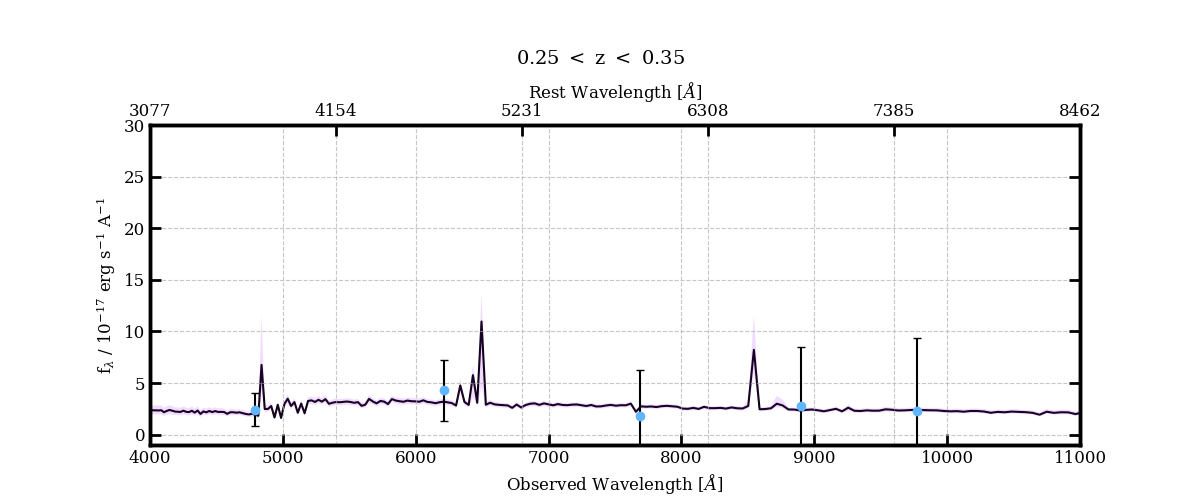

In [27]:
set_mnras_style()
fig_025_035, ax_025_035 = plot_spectrum_posterior(Luminosity_Corrected_fit_result_025_035, standard_deviation=Corrected_Stellar_Flux_Array_Err_025_035, 
                                                  show=True, xlim=(4.0*10**3, 1.1*10**4), ylim=(-1, 30), title=r"0.25 $<$ z $<$ 0.35")


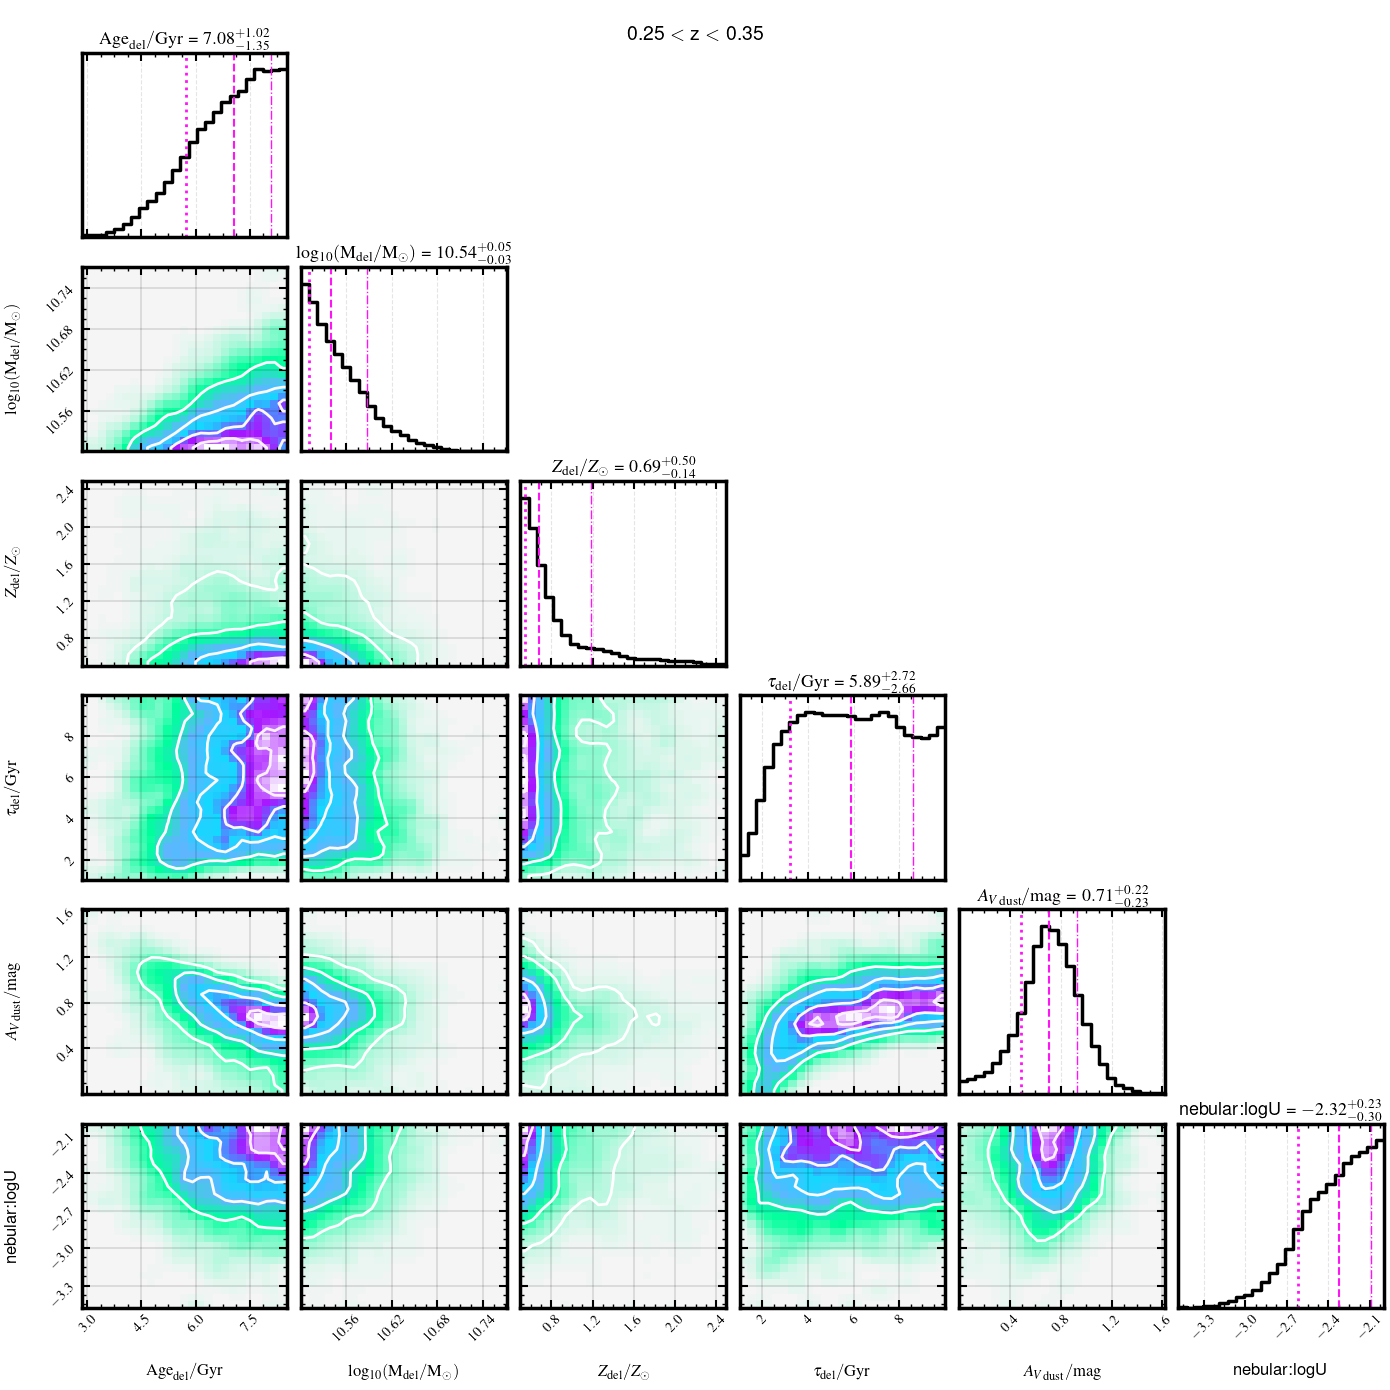

In [28]:
# Create and customize corner plot
fig_corner_025_035 = Luminosity_Corrected_fit_result_025_035.plot_corner(save=False, show=False)
fig_corner_025_035 = customize_corner_plot(fig_corner_025_035, fitt="Redshift_025_035_n=1000_optimized_v3_tight_MCMC_Plotfixed_Corrected_Luminosities_Stellar_a", title=r"0.25 $<$ z $<$ 0.35")

# Extract figure if tuple
if isinstance(fig_corner_025_035, tuple):
    fig_corner_025_035 = fig_corner_025_035[0]
plt.show()


In [29]:
np.average(Luminosity_Corrected_fit_result_025_035.posterior.samples["stellar_mass"])

10.283467138132124

"conservative"
"advanced"
"exponential"
"adaptive"
"power_law"
"burst"
"optimized"
"fine_tuned"

What is the bandpass window

In [30]:
np.average(Luminosity_Corrected_fit_result_025_035.posterior.samples["stellar_mass"])


10.283467138132124

In [31]:
Luminosity_Corrected_fit_result_035_045, galaxy_obj_035_045, Luminosity_Corrected_fit_result_SD_035_045 = run_adaptive_bagpipes_fit(
    flux_array=Corrected_Stellar_Flux_Array_035_045,
    flux_err_array=Corrected_Stellar_Flux_Array_Err_035_045,
    filter_response_files=hsc_filter_files,
    redshift=0.4,
    galaxy_id="Redshift_035_045_n=1000_optimized_v3_tight_MCMC_Plotfixed_Corrected_Luminosities_Stellar_a",
    run_name="hsc_test_fit",
    n_live=1000,
    model_type="optimized_v3",
    max_iterations=3,
    target_quality=0.8
)

    

BAGPIPES Adaptive Parameter Optimization
Galaxy ID: Redshift_035_045_n=1000_optimized_v3_tight_MCMC_Plotfixed_Corrected_Luminosities_Stellar_a
Model Type: optimized_v3
Target Quality: 0.80
Max Iterations: 3

Iteration 1/3
Galaxy ID: Redshift_035_045_n=1000_optimized_v3_tight_MCMC_Plotfixed_Corrected_Luminosities_Stellar_a_iter0
----------------------------------------
BAGPIPES AGN Host Galaxy SED Fitting - OPTIMIZED_V3 Model
Cosmic age at z=0.4: 9.19 Gyr
Age limit for AGN hosts: 7.81 Gyr

Model components:
- redshift: 0.4
- delayed:
    age: (0.5, 7.807345848139757)
    tau: (1.0, 10.0)
    massformed: (10.5, 12.5)
    metallicity: (0.5, 2.5)
- dust:
    type: Calzetti
    Av: (0.0, 3.0)
- nebular:
    logU: (-3.5, -2.0)

Will use 11 cores for parallel processing
Created BAGPIPES filter file: bagpipes_filters/hsc_g.filt
Created BAGPIPES filter file: bagpipes_filters/hsc_r.filt
Created BAGPIPES filter file: bagpipes_filters/hsc_i.filt
Created BAGPIPES filter file: bagpipes_filters/hsc_z

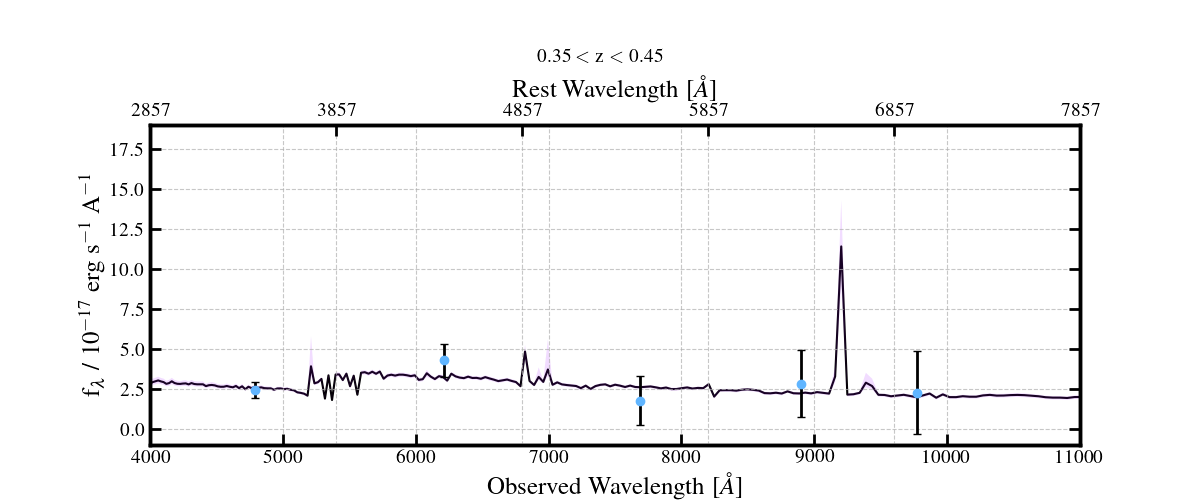

In [32]:
set_mnras_style()
fig_035_045, ax_035_045 = plot_spectrum_posterior(Luminosity_Corrected_fit_result_035_045, standard_deviation=Corrected_Stellar_Flux_Array_Err_035_045, show=True, xlim=(4.0*10**3, 1.1*10**4), 
                                                                                                            ylim=(-1, 19), title=r"0.35 $<$ z $<$ 0.45")



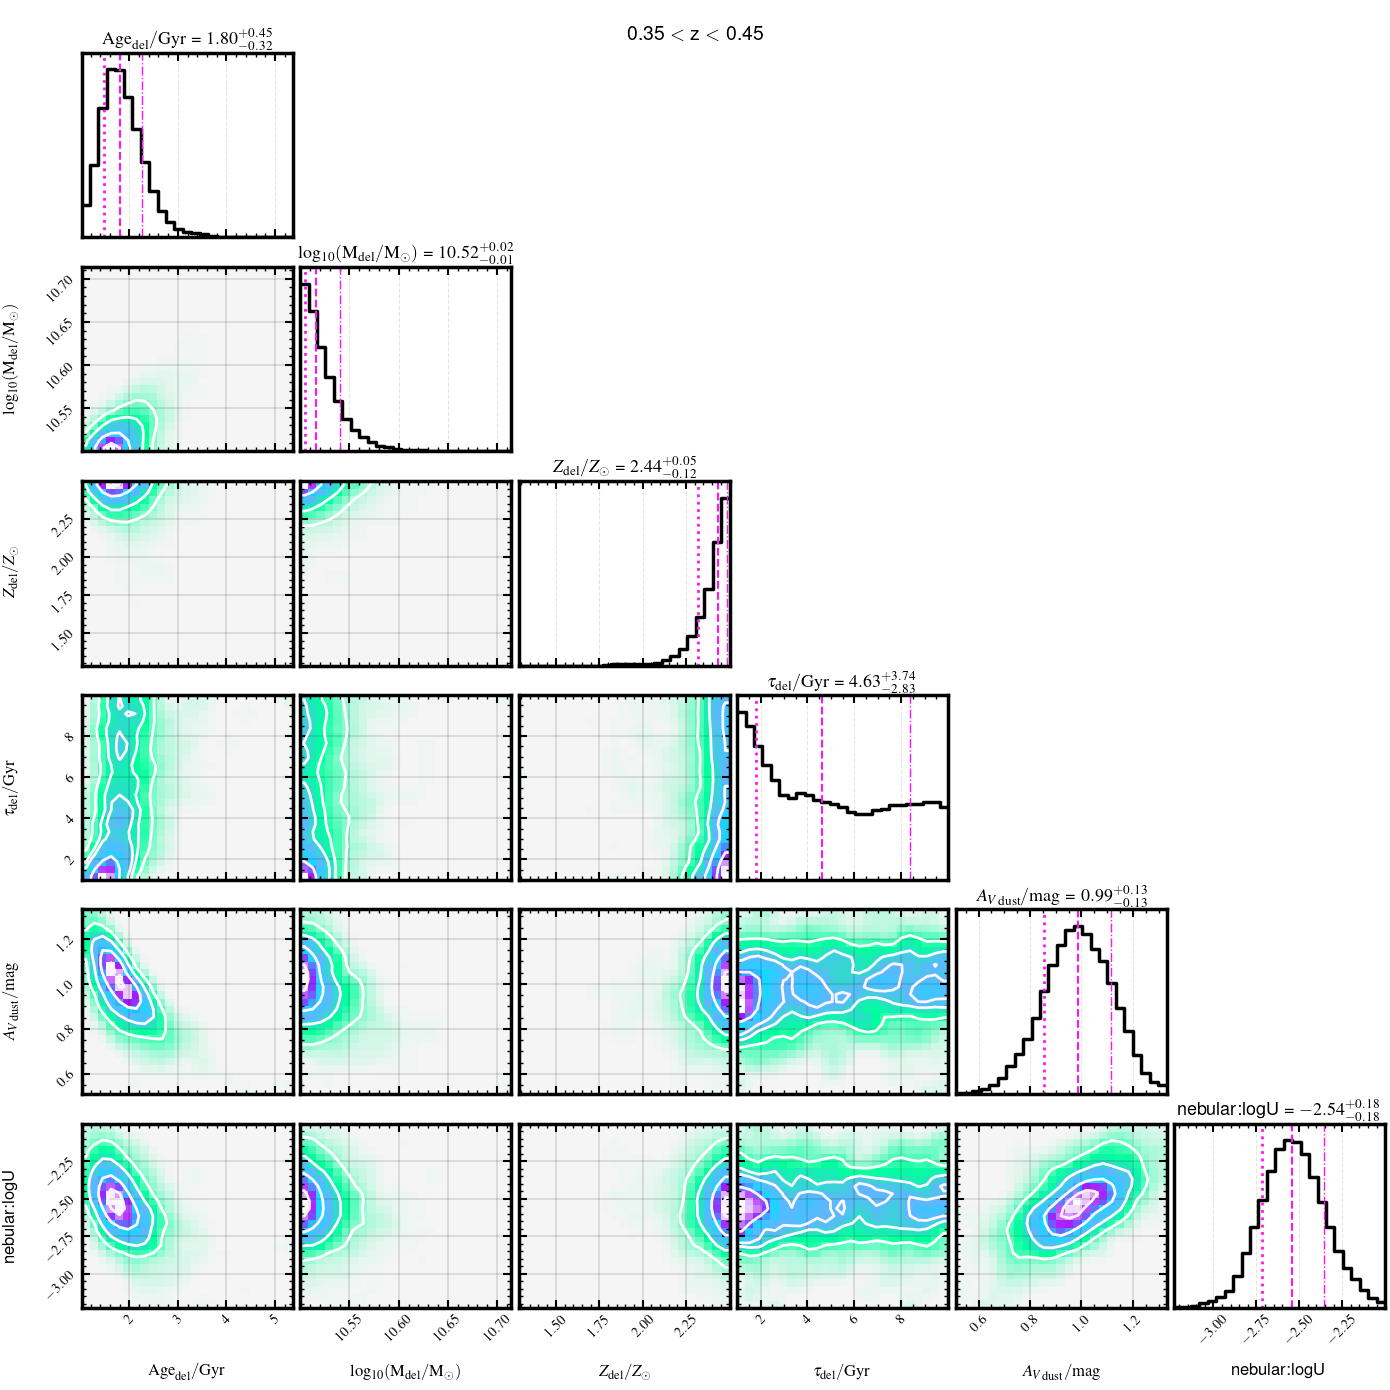

In [33]:
# Set MNRAS style first
set_mnras_style()

# Create and customize corner plot
fig_corner_035_045 = Luminosity_Corrected_fit_result_035_045.plot_corner(save=False, show=False)
fig_corner_035_045 = customize_corner_plot(fig_corner_035_045, fitt="Redshift_035_045_n=1000_optimized_v3_tight_MCMC_Plotfixed_Corrected_Luminosities_Stellar_a", 
                                                                                                                              title=r"0.35 $<$ z $<$ 0.45")

# Extract figure if tuple
if isinstance(fig_corner_035_045, tuple):
    fig_corner_035_045 = fig_corner_035_045[0]
plt.show()



In [34]:
np.average(Luminosity_Corrected_fit_result_035_045.posterior.samples["stellar_mass"])

10.323373277077412

In [35]:
Luminosity_Corrected_fit_result_045_055, galaxy_obj_045_055, Luminosity_Corrected_fit_result_SD_045_055 = run_adaptive_bagpipes_fit(
    flux_array=Corrected_Stellar_Flux_Array_045_055,
    flux_err_array=Corrected_Stellar_Flux_Array_Err_045_055,
    filter_response_files=hsc_filter_files,
    redshift=0.5,
    galaxy_id="Redshift_045_055_n=1000_optimized_v3_tight_MCMC_Plotfixed_Corrected_Luminosities_Stellar_a",
    run_name="hsc_test_fit",
    n_live=1000,
    model_type="optimized_v3",
    max_iterations=3,
    target_quality=0.8
)

    

BAGPIPES Adaptive Parameter Optimization
Galaxy ID: Redshift_045_055_n=1000_optimized_v3_tight_MCMC_Plotfixed_Corrected_Luminosities_Stellar_a
Model Type: optimized_v3
Target Quality: 0.80
Max Iterations: 3

Iteration 1/3
Galaxy ID: Redshift_045_055_n=1000_optimized_v3_tight_MCMC_Plotfixed_Corrected_Luminosities_Stellar_a_iter0
----------------------------------------
BAGPIPES AGN Host Galaxy SED Fitting - OPTIMIZED_V3 Model
Cosmic age at z=0.5: 8.43 Gyr
Age limit for AGN hosts: 7.16 Gyr

Model components:
- redshift: 0.5
- delayed:
    age: (0.5, 7.162394115089016)
    tau: (1.0, 10.0)
    massformed: (10.5, 12.5)
    metallicity: (0.5, 2.5)
- dust:
    type: Calzetti
    Av: (0.0, 3.0)
- nebular:
    logU: (-3.5, -2.0)

Will use 11 cores for parallel processing
Created BAGPIPES filter file: bagpipes_filters/hsc_g.filt
Created BAGPIPES filter file: bagpipes_filters/hsc_r.filt
Created BAGPIPES filter file: bagpipes_filters/hsc_i.filt
Created BAGPIPES filter file: bagpipes_filters/hsc_z

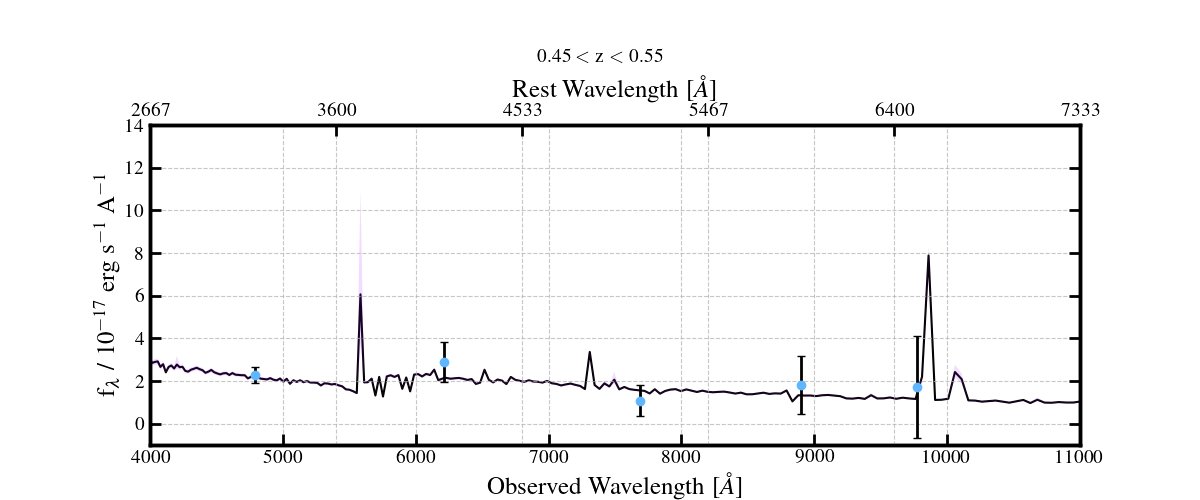

In [36]:
set_mnras_style()
fig_045_055, ax_045_055 = plot_spectrum_posterior(Luminosity_Corrected_fit_result_045_055, standard_deviation=Corrected_Stellar_Flux_Array_Err_045_055, show=True, xlim=(4.0*10**3, 1.1*10**4), ylim=(-1, 14),
                                                                                                                                        title=r"0.45 $<$ z $<$ 0.55")



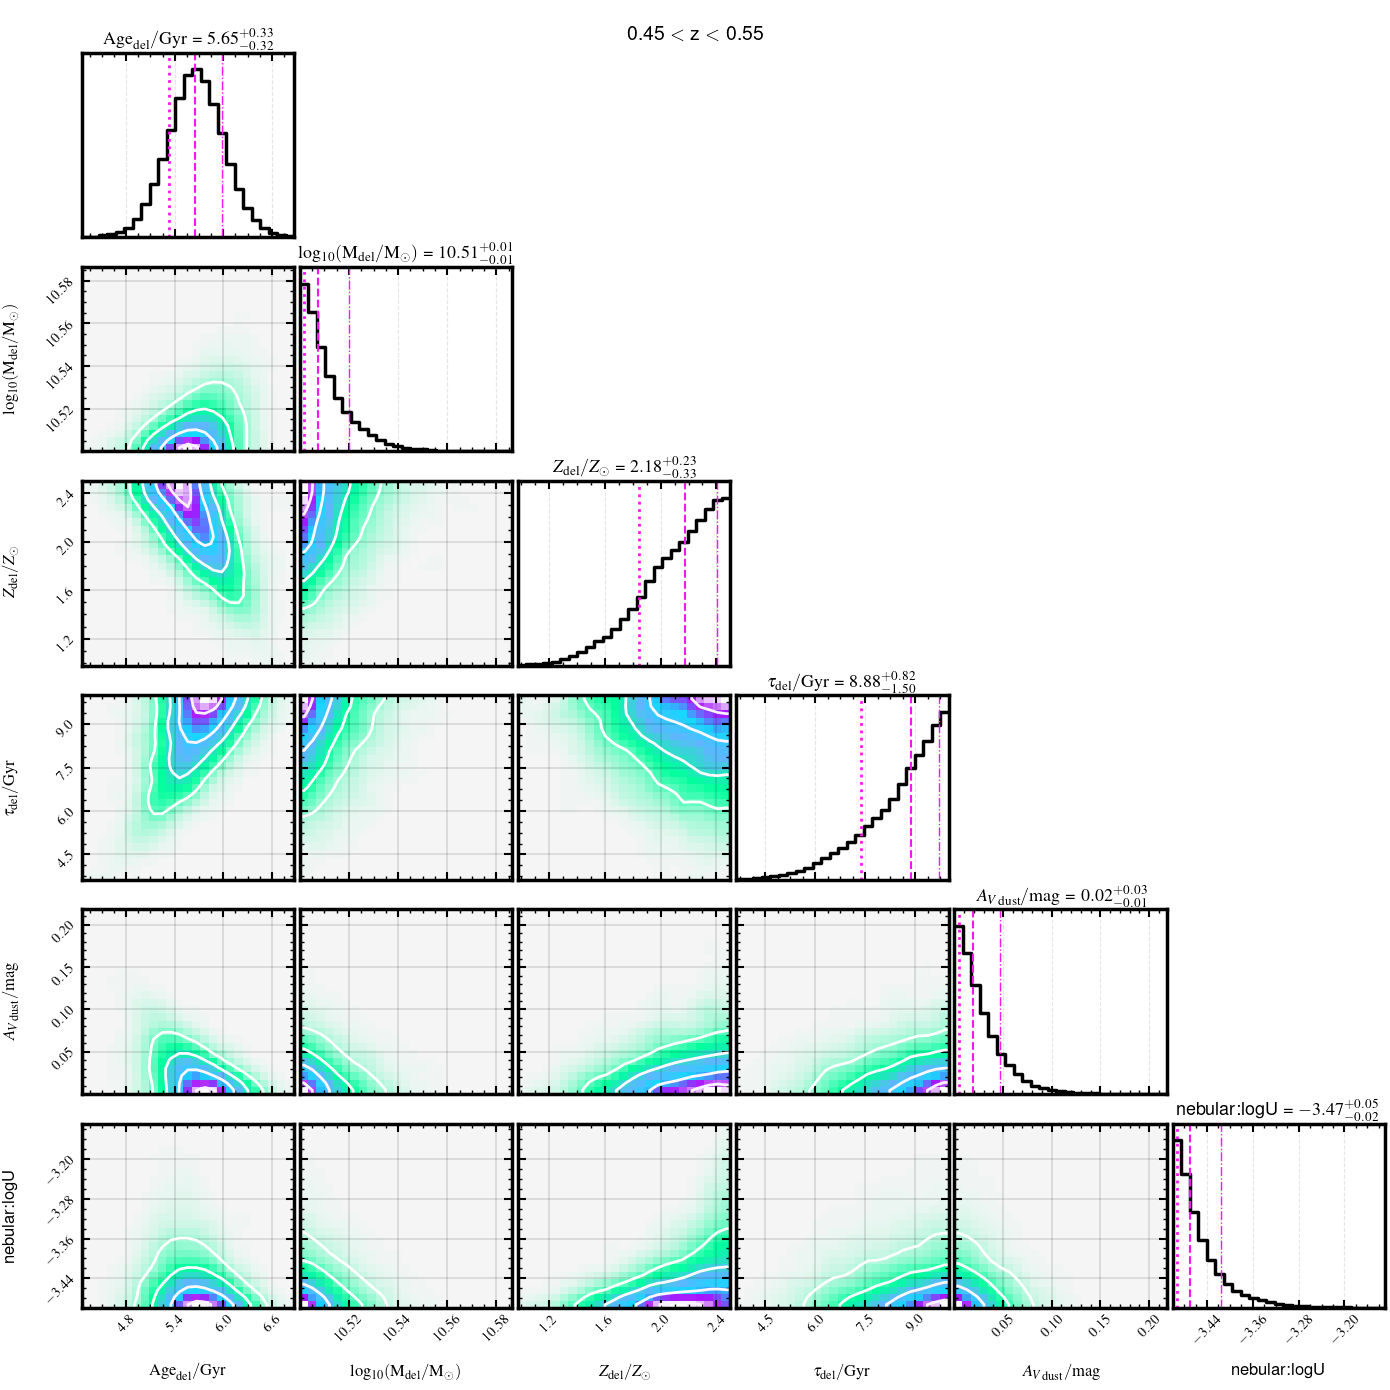

In [37]:
# Set MNRAS style first
set_mnras_style()

# Create and customize corner plot
fig_corner_045_055 = Luminosity_Corrected_fit_result_045_055.plot_corner(save=False, show=False)
fig_corner_045_055 = customize_corner_plot(fig_corner_045_055, fitt="Redshift_045_055_n=1000_optimized_v3_tight_MCMC_Plotfixed_Corrected_Luminosities_Stellar_a", title=r"0.45 $<$ z $<$ 0.55")
# Extract figure if tuple
if isinstance(fig_corner_045_055, tuple):
    fig_corner_045_055 = fig_corner_045_055[0]
plt.show()


In [38]:
Luminosity_Corrected_fit_result_055_065, galaxy_obj_055_065, Luminosity_Corrected_fit_result_SD_055_065 = run_adaptive_bagpipes_fit(
    flux_array=Corrected_Stellar_Flux_Array_055_065,
    flux_err_array=Corrected_Stellar_Flux_Array_Err_055_065,
    filter_response_files=hsc_filter_files,
    redshift=0.6,
    galaxy_id="Redshift_055_065_n=1000_optimized_v3_tight_MCMC_Plotfixed_Corrected_Luminosities_Stellar_a",
    run_name="hsc_test_fit",
    n_live=1000,
    model_type="optimized_v3",
    max_iterations=3,
    target_quality=0.8
)

    

BAGPIPES Adaptive Parameter Optimization
Galaxy ID: Redshift_055_065_n=1000_optimized_v3_tight_MCMC_Plotfixed_Corrected_Luminosities_Stellar_a
Model Type: optimized_v3
Target Quality: 0.80
Max Iterations: 3

Iteration 1/3
Galaxy ID: Redshift_055_065_n=1000_optimized_v3_tight_MCMC_Plotfixed_Corrected_Luminosities_Stellar_a_iter0
----------------------------------------
BAGPIPES AGN Host Galaxy SED Fitting - OPTIMIZED_V3 Model
Cosmic age at z=0.6: 7.76 Gyr
Age limit for AGN hosts: 6.59 Gyr

Model components:
- redshift: 0.6
- delayed:
    age: (0.5, 6.593696146351426)
    tau: (1.0, 10.0)
    massformed: (10.5, 12.5)
    metallicity: (0.5, 2.5)
- dust:
    type: Calzetti
    Av: (0.0, 3.0)
- nebular:
    logU: (-3.5, -2.0)

Will use 11 cores for parallel processing
Created BAGPIPES filter file: bagpipes_filters/hsc_g.filt
Created BAGPIPES filter file: bagpipes_filters/hsc_r.filt
Created BAGPIPES filter file: bagpipes_filters/hsc_i.filt
Created BAGPIPES filter file: bagpipes_filters/hsc_z

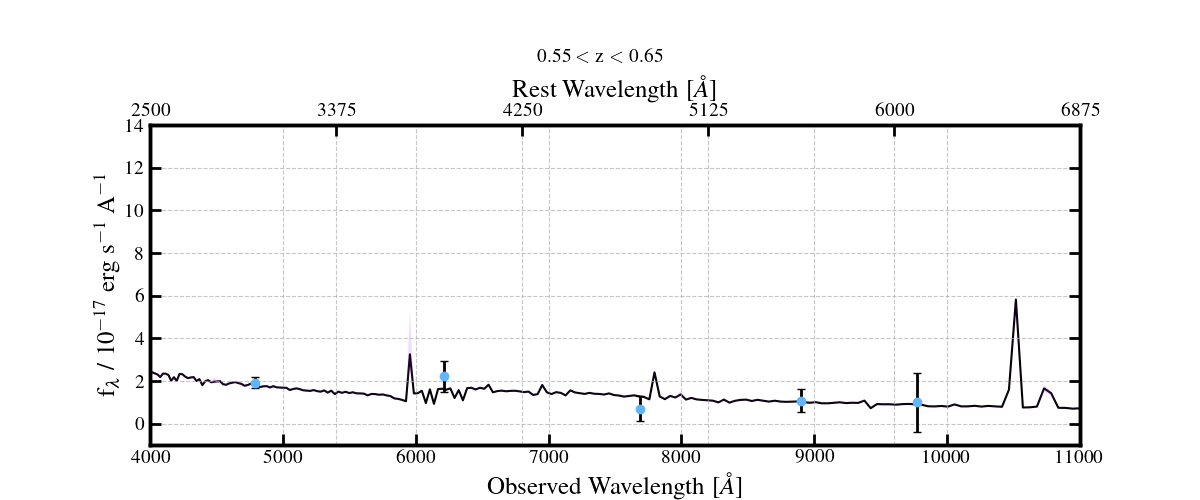

In [39]:
set_mnras_style()

fig_055_065, ax_055_065 = plot_spectrum_posterior(Luminosity_Corrected_fit_result_055_065, standard_deviation=Corrected_Stellar_Flux_Array_Err_055_065, show=True, xlim=(4.0*10**3, 1.1*10**4), ylim=(-1, 14),
                                                                                                                                          title=r"0.55 $<$ z $<$ 0.65")




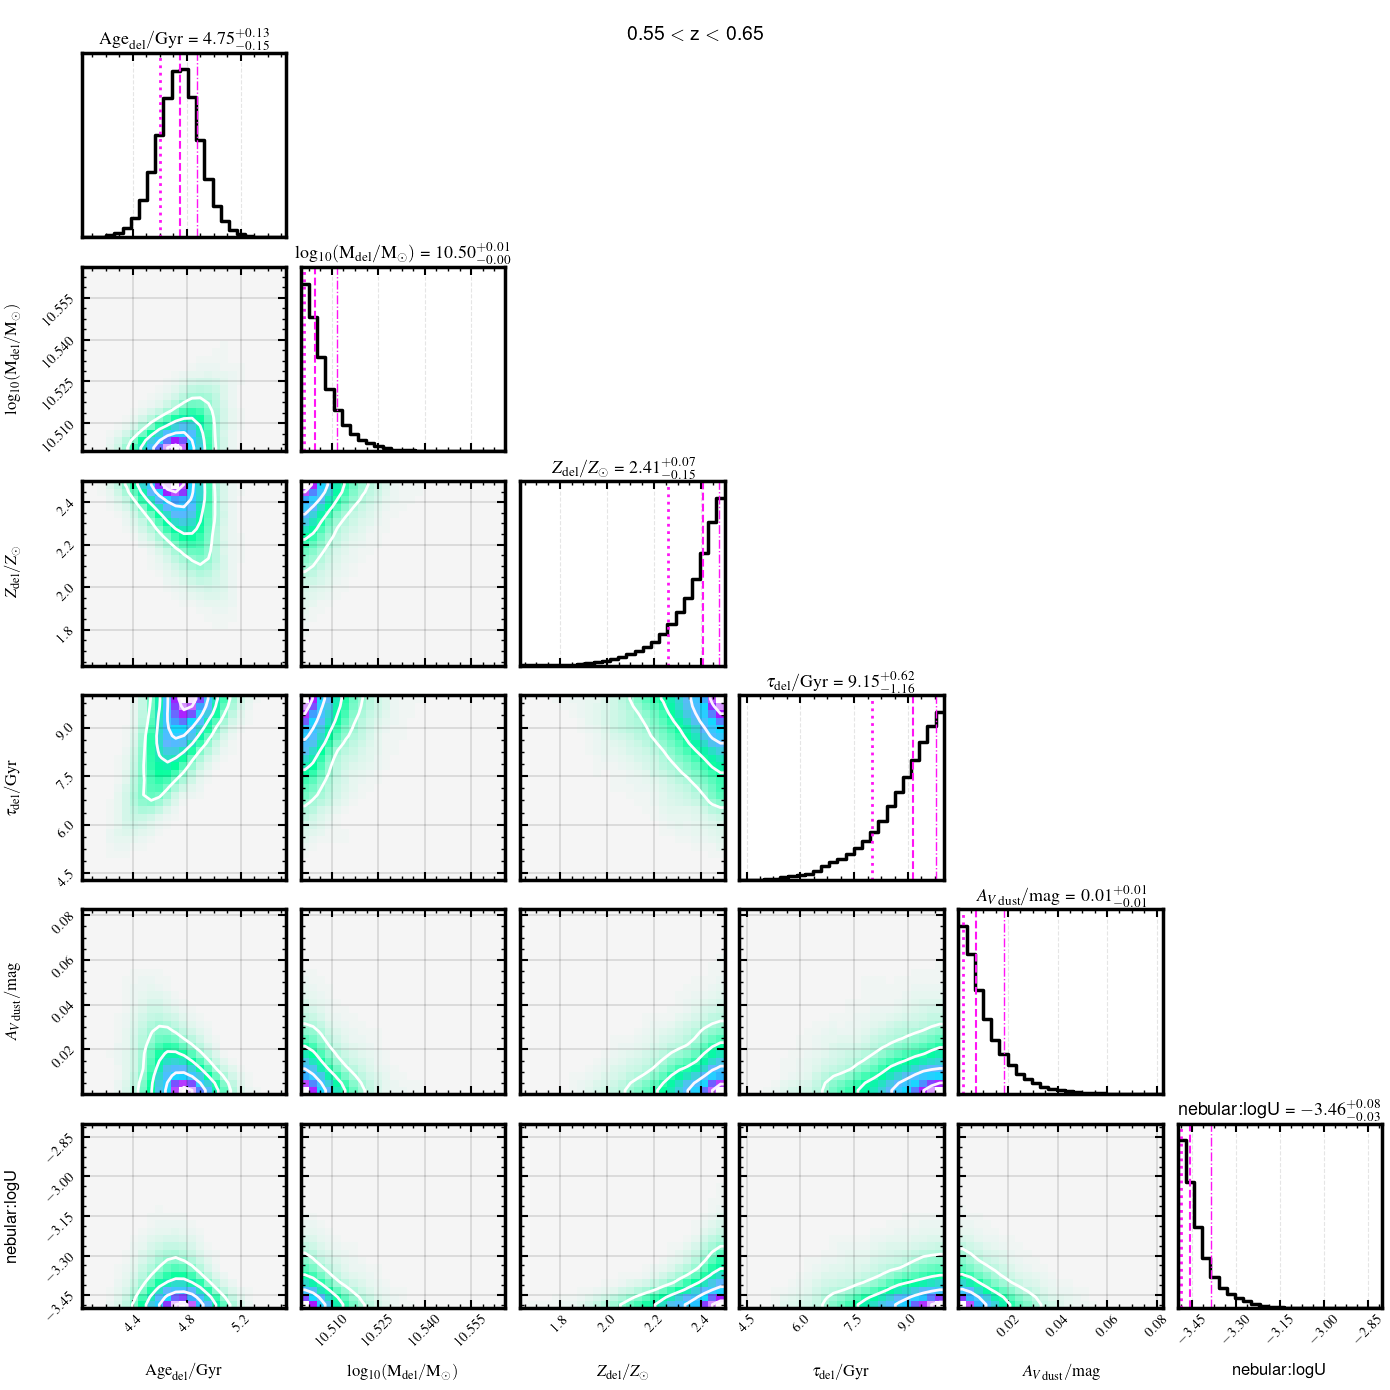

In [40]:
# Set MNRAS style first
set_mnras_style()

# Create and customize corner plot
fig_corner_055_065 = Luminosity_Corrected_fit_result_055_065.plot_corner(save=False, show=False)
fig_corner_055_065 = customize_corner_plot(fig_corner_055_065, fitt="Redshift_055_065_n=1000_optimized_v3_tight_MCMC_Plotfixed_Corrected_Luminosities_Stellar_a", title=r"0.55 $<$ z $<$ 0.65")
# Extract figure if tuple
if isinstance(fig_corner_055_065, tuple):
    fig_corner_055_065 = fig_corner_055_065[0]
plt.show()


In [41]:
Luminosity_Corrected_fit_result_065_075, galaxy_obj_065_075, Luminosity_Corrected_fit_result_SD_065_075 = run_adaptive_bagpipes_fit(
    flux_array=Corrected_Stellar_Flux_Array_065_075,
    flux_err_array=Corrected_Stellar_Flux_Array_Err_065_075,
    filter_response_files=hsc_filter_files,
    redshift=0.7,
    galaxy_id="Redshift_065_075_n=1000_optimized_v3_tight_MCMC_Plotfixed_Corrected_Luminosities_Stellar_a",
    run_name="hsc_test_fit",
    n_live=1000,
    model_type="optimized_v3",
    max_iterations=3,
    target_quality=0.8
)



BAGPIPES Adaptive Parameter Optimization
Galaxy ID: Redshift_065_075_n=1000_optimized_v3_tight_MCMC_Plotfixed_Corrected_Luminosities_Stellar_a
Model Type: optimized_v3
Target Quality: 0.80
Max Iterations: 3

Iteration 1/3
Galaxy ID: Redshift_065_075_n=1000_optimized_v3_tight_MCMC_Plotfixed_Corrected_Luminosities_Stellar_a_iter0
----------------------------------------
BAGPIPES AGN Host Galaxy SED Fitting - OPTIMIZED_V3 Model
Cosmic age at z=0.7: 7.17 Gyr
Age limit for AGN hosts: 6.09 Gyr

Model components:
- redshift: 0.7
- delayed:
    age: (0.5, 6.09044560861473)
    tau: (1.0, 10.0)
    massformed: (10.5, 12.5)
    metallicity: (0.5, 2.5)
- dust:
    type: Calzetti
    Av: (0.0, 3.0)
- nebular:
    logU: (-3.5, -2.0)

Will use 11 cores for parallel processing
Created BAGPIPES filter file: bagpipes_filters/hsc_g.filt
Created BAGPIPES filter file: bagpipes_filters/hsc_r.filt
Created BAGPIPES filter file: bagpipes_filters/hsc_i.filt
Created BAGPIPES filter file: bagpipes_filters/hsc_z.

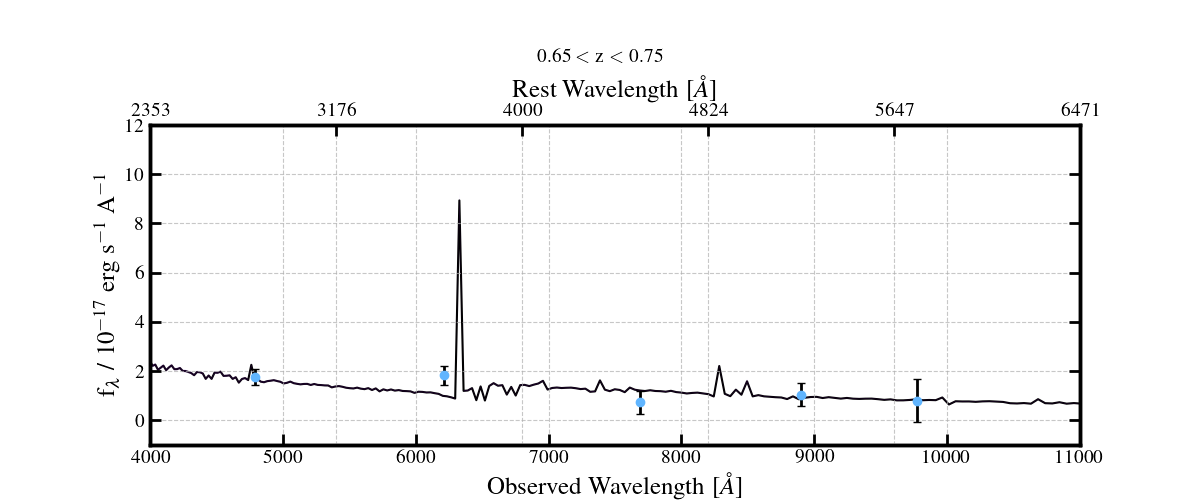

In [42]:
set_mnras_style()

fig_065_075, ax_065_075 = plot_spectrum_posterior(Luminosity_Corrected_fit_result_065_075, standard_deviation=Corrected_Stellar_Flux_Array_Err_065_075, show=True, xlim=(4.0*10**3, 1.1*10**4), ylim=(-1, 12),
                                                                                                                                    title=r"0.65 $<$ z $<$ 0.75")



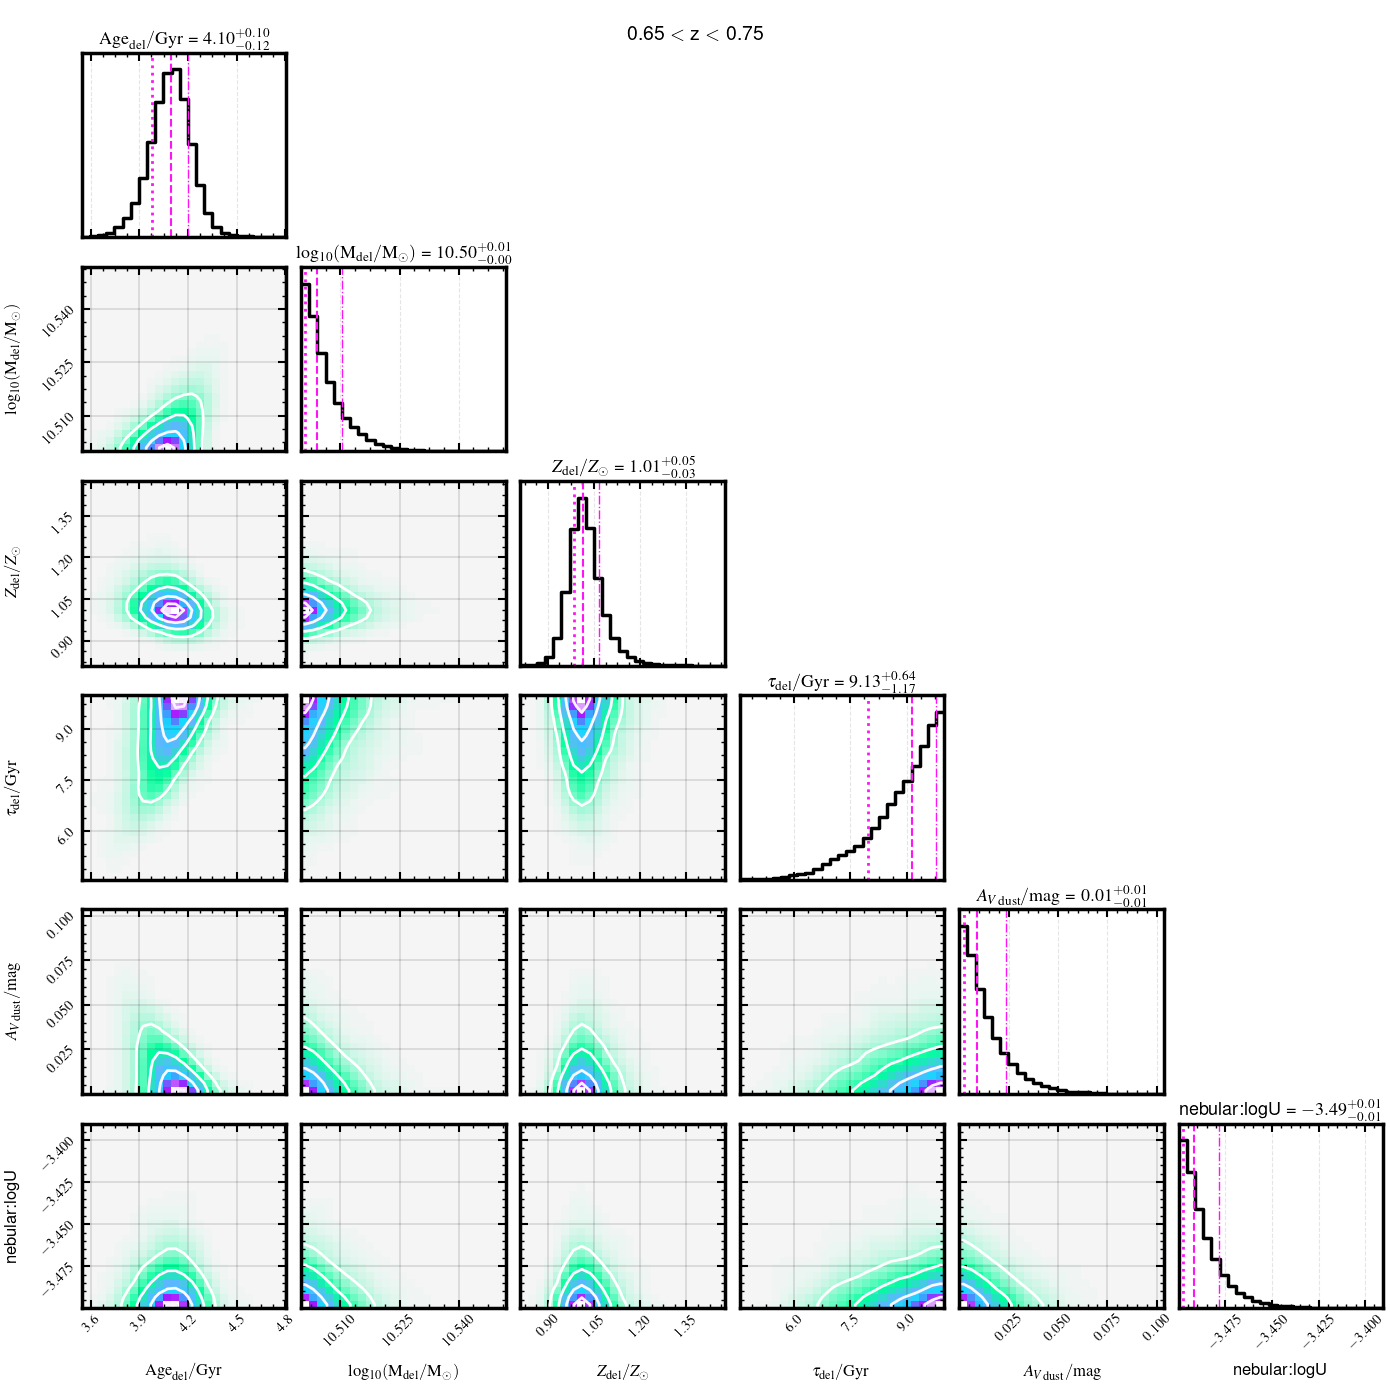

In [43]:
# Set MNRAS style first
set_mnras_style()

# Create and customize corner plot
fig_corner_065_075 = Luminosity_Corrected_fit_result_065_075.plot_corner(save=False, show=False)
fig_corner_065_075 = customize_corner_plot(fig_corner_065_075, fitt="Redshift_065_075_n=1000_optimized_v3_tight_MCMC_Plotfixed_Corrected_Luminosities_Stellar_a", title=r"0.65 $<$ z $<$ 0.75")
# Extract figure if tuple
if isinstance(fig_corner_065_075, tuple):
    fig_corner_065_075 = fig_corner_065_075[0]
plt.show()


In [44]:
Luminosity_Corrected_fit_result_075_085, galaxy_obj_075_085, Luminosity_Corrected_fit_result_SD_075_085 = run_adaptive_bagpipes_fit(
    flux_array=Corrected_Stellar_Flux_Array_075_085,
    flux_err_array=Corrected_Stellar_Flux_Array_Err_075_085,
    filter_response_files=hsc_filter_files,
    redshift=0.8,
    galaxy_id="Redshift_075_085_n=1000_optimized_v3_tight_MCMC_Plotfixed_Corrected_Luminosities_Stellar_a",
    run_name="hsc_test_fit",
    n_live=1000,
    model_type="optimized_v3",
    max_iterations=3,
    target_quality=0.8
)



BAGPIPES Adaptive Parameter Optimization
Galaxy ID: Redshift_075_085_n=1000_optimized_v3_tight_MCMC_Plotfixed_Corrected_Luminosities_Stellar_a
Model Type: optimized_v3
Target Quality: 0.80
Max Iterations: 3

Iteration 1/3
Galaxy ID: Redshift_075_085_n=1000_optimized_v3_tight_MCMC_Plotfixed_Corrected_Luminosities_Stellar_a_iter0
----------------------------------------
BAGPIPES AGN Host Galaxy SED Fitting - OPTIMIZED_V3 Model
Cosmic age at z=0.8: 6.64 Gyr
Age limit for AGN hosts: 5.64 Gyr

Model components:
- redshift: 0.8
- delayed:
    age: (0.5, 5.64351415972964)
    tau: (1.0, 10.0)
    massformed: (10.5, 12.5)
    metallicity: (0.5, 2.5)
- dust:
    type: Calzetti
    Av: (0.0, 3.0)
- nebular:
    logU: (-3.5, -2.0)

Will use 11 cores for parallel processing
Created BAGPIPES filter file: bagpipes_filters/hsc_g.filt
Created BAGPIPES filter file: bagpipes_filters/hsc_r.filt
Created BAGPIPES filter file: bagpipes_filters/hsc_i.filt
Created BAGPIPES filter file: bagpipes_filters/hsc_z.

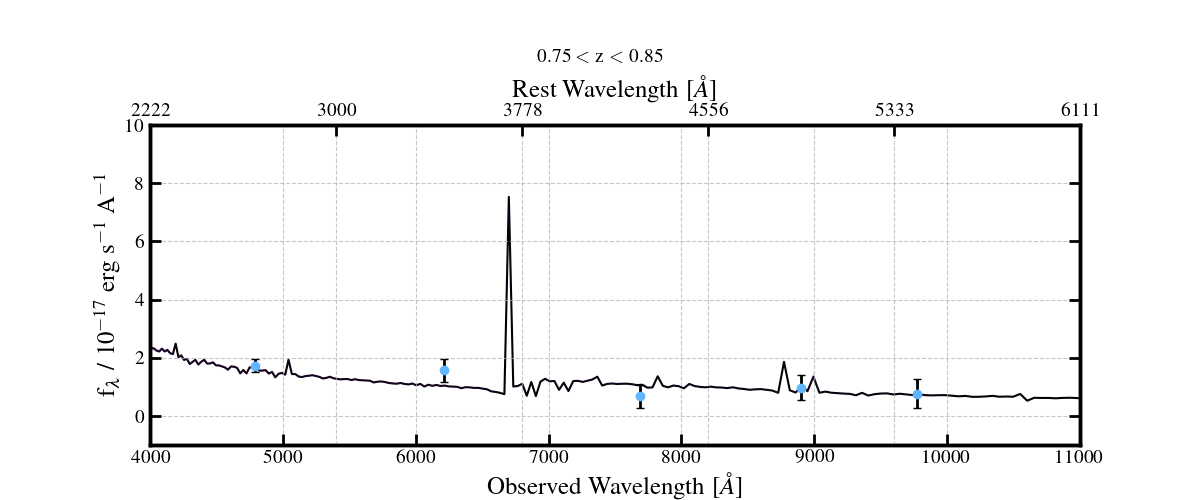

In [45]:
set_mnras_style()
fig_075_085, ax_075_085 = plot_spectrum_posterior(Luminosity_Corrected_fit_result_075_085, standard_deviation=Corrected_Stellar_Flux_Array_Err_075_085, show=True, xlim=(4.0*10**3, 1.1*10**4), ylim=(-1, 10),
                                                                                                                                          title=r"0.75 $<$ z $<$ 0.85")


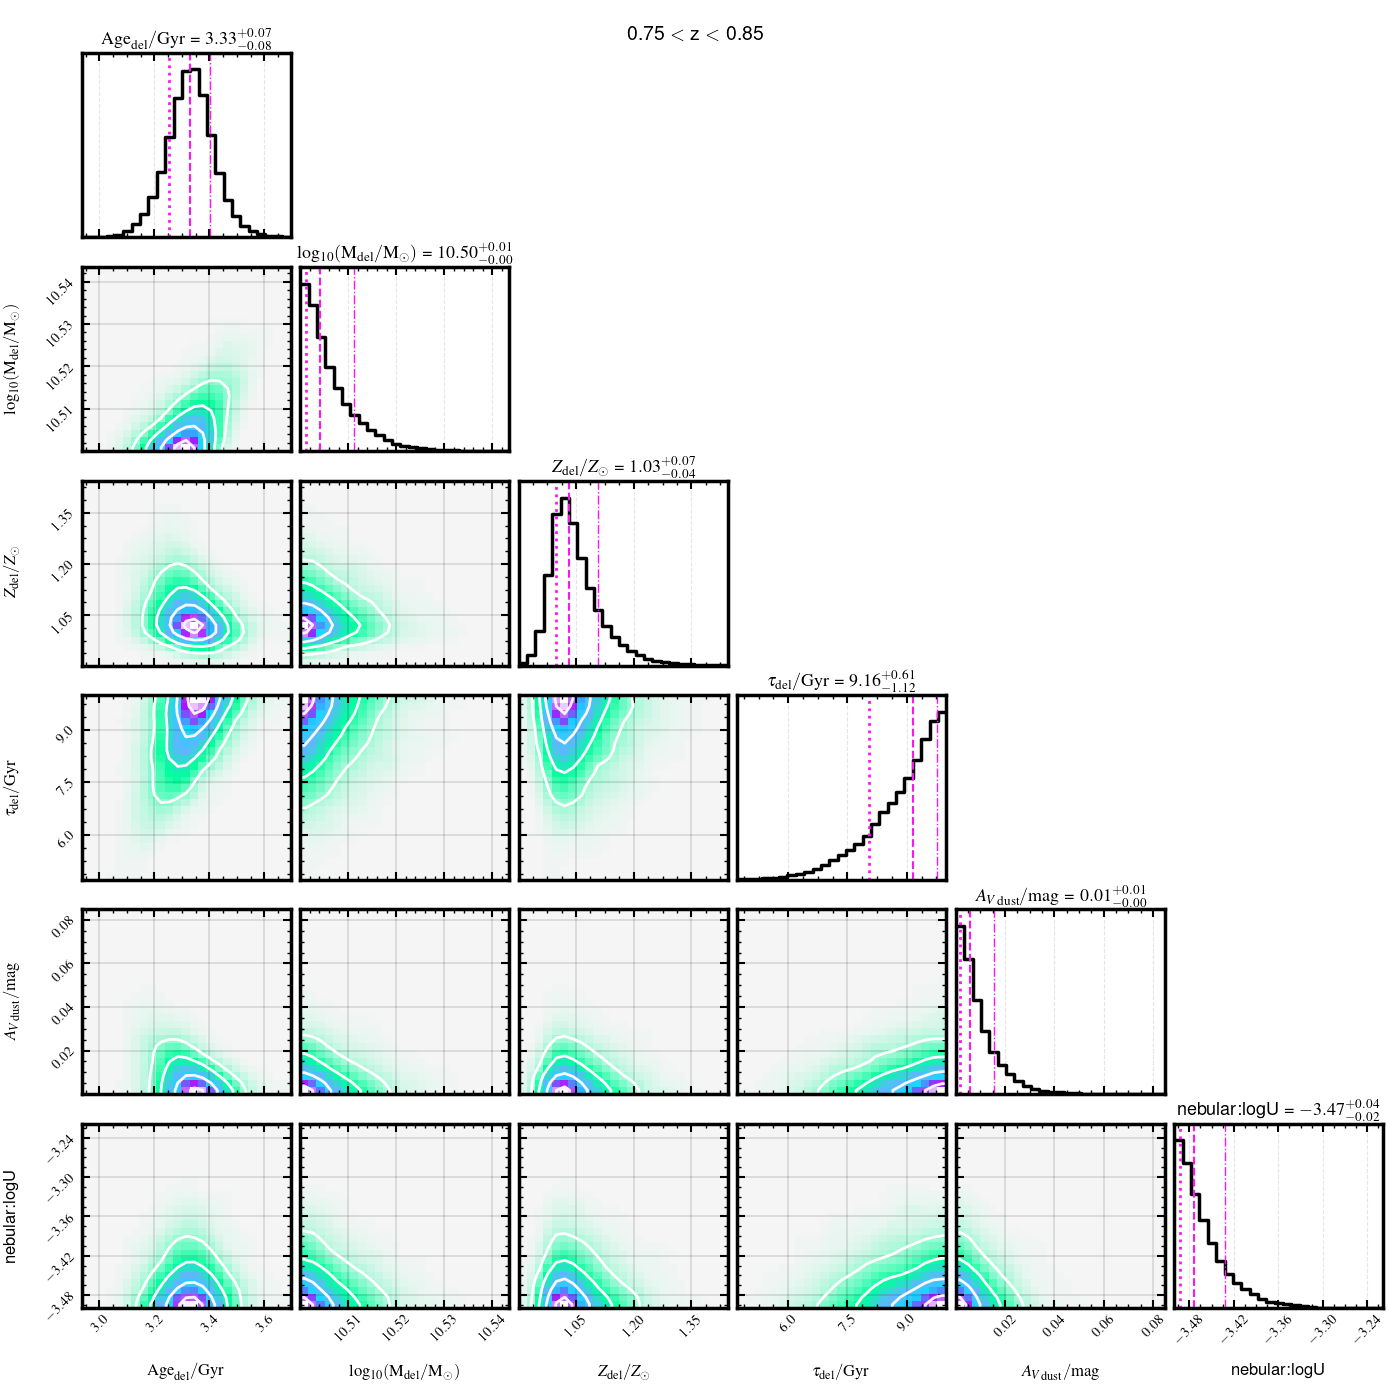

In [46]:
# Set MNRAS style first
set_mnras_style()

# Create and customize corner plot
fig_corner_075_085 = Luminosity_Corrected_fit_result_075_085.plot_corner(save=False, show=False)
fig_corner_075_085 = customize_corner_plot(fig_corner_075_085, fitt="Redshift_075_085_n=1000_optimized_v3_tight_MCMC_Plotfixed_Corrected_Luminosities_Stellar_a", title=r"0.75 $<$ z $<$ 0.85")
# Extract figure if tuple
if isinstance(fig_corner_075_085, tuple):
    fig_corner_075_085 = fig_corner_075_085[0]
plt.show()


In [47]:
Luminosity_Corrected_fit_result_085_096, galaxy_obj_085_096, Luminosity_Corrected_fit_result_SD_085_096 = run_adaptive_bagpipes_fit(
    flux_array=Corrected_Stellar_Flux_Array_085_096,
    flux_err_array=Corrected_Stellar_Flux_Array_Err_085_096,
    filter_response_files=hsc_filter_files,
    redshift=0.905,
    galaxy_id="Redshift_085_096_n=1000_optimized_v3_tight_MCMC_Plotfixed_Corrected_Luminosities_Stellar_a",
    run_name="hsc_test_fit",
    n_live=1000,
    model_type="optimized_v3",
    max_iterations=3,
    target_quality=0.8
)



BAGPIPES Adaptive Parameter Optimization
Galaxy ID: Redshift_085_096_n=1000_optimized_v3_tight_MCMC_Plotfixed_Corrected_Luminosities_Stellar_a
Model Type: optimized_v3
Target Quality: 0.80
Max Iterations: 3

Iteration 1/3
Galaxy ID: Redshift_085_096_n=1000_optimized_v3_tight_MCMC_Plotfixed_Corrected_Luminosities_Stellar_a_iter0
----------------------------------------
BAGPIPES AGN Host Galaxy SED Fitting - OPTIMIZED_V3 Model
Cosmic age at z=0.905: 6.15 Gyr
Age limit for AGN hosts: 5.23 Gyr

Model components:
- redshift: 0.905
- delayed:
    age: (0.5, 5.226416500339623)
    tau: (1.0, 10.0)
    massformed: (10.5, 12.5)
    metallicity: (0.5, 2.5)
- dust:
    type: Calzetti
    Av: (0.0, 3.0)
- nebular:
    logU: (-3.5, -2.0)

Will use 11 cores for parallel processing
Created BAGPIPES filter file: bagpipes_filters/hsc_g.filt
Created BAGPIPES filter file: bagpipes_filters/hsc_r.filt
Created BAGPIPES filter file: bagpipes_filters/hsc_i.filt
Created BAGPIPES filter file: bagpipes_filters/h

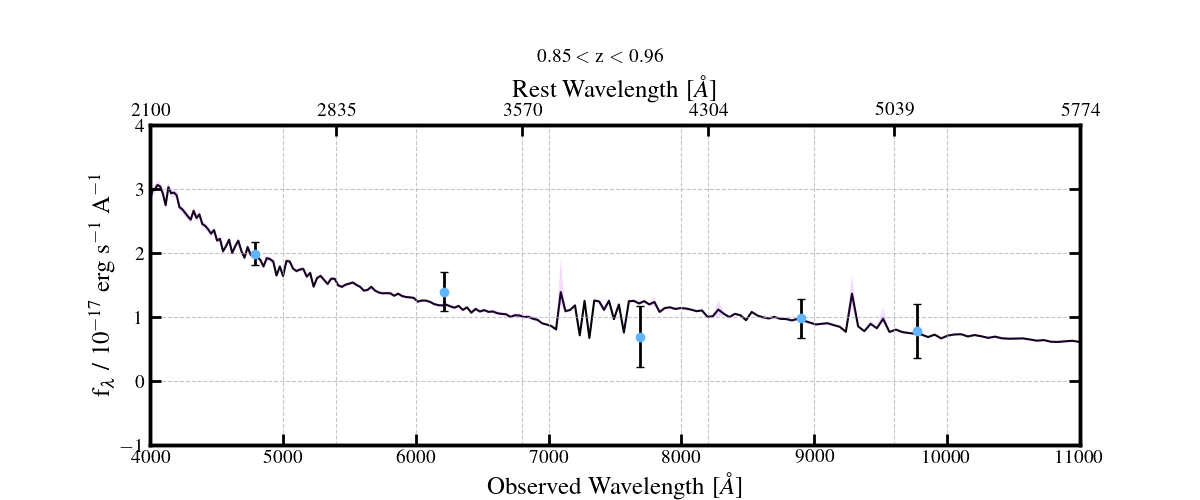

In [48]:
set_mnras_style()
fig_085_096, ax_085_096 = plot_spectrum_posterior(Luminosity_Corrected_fit_result_085_096, standard_deviation=Corrected_Stellar_Flux_Array_Err_085_096, show=True, xlim=(4.0*10**3, 1.1*10**4), ylim=(-1, 4),
                                                                                                                                      title=r"0.85 $<$ z $<$ 0.96")



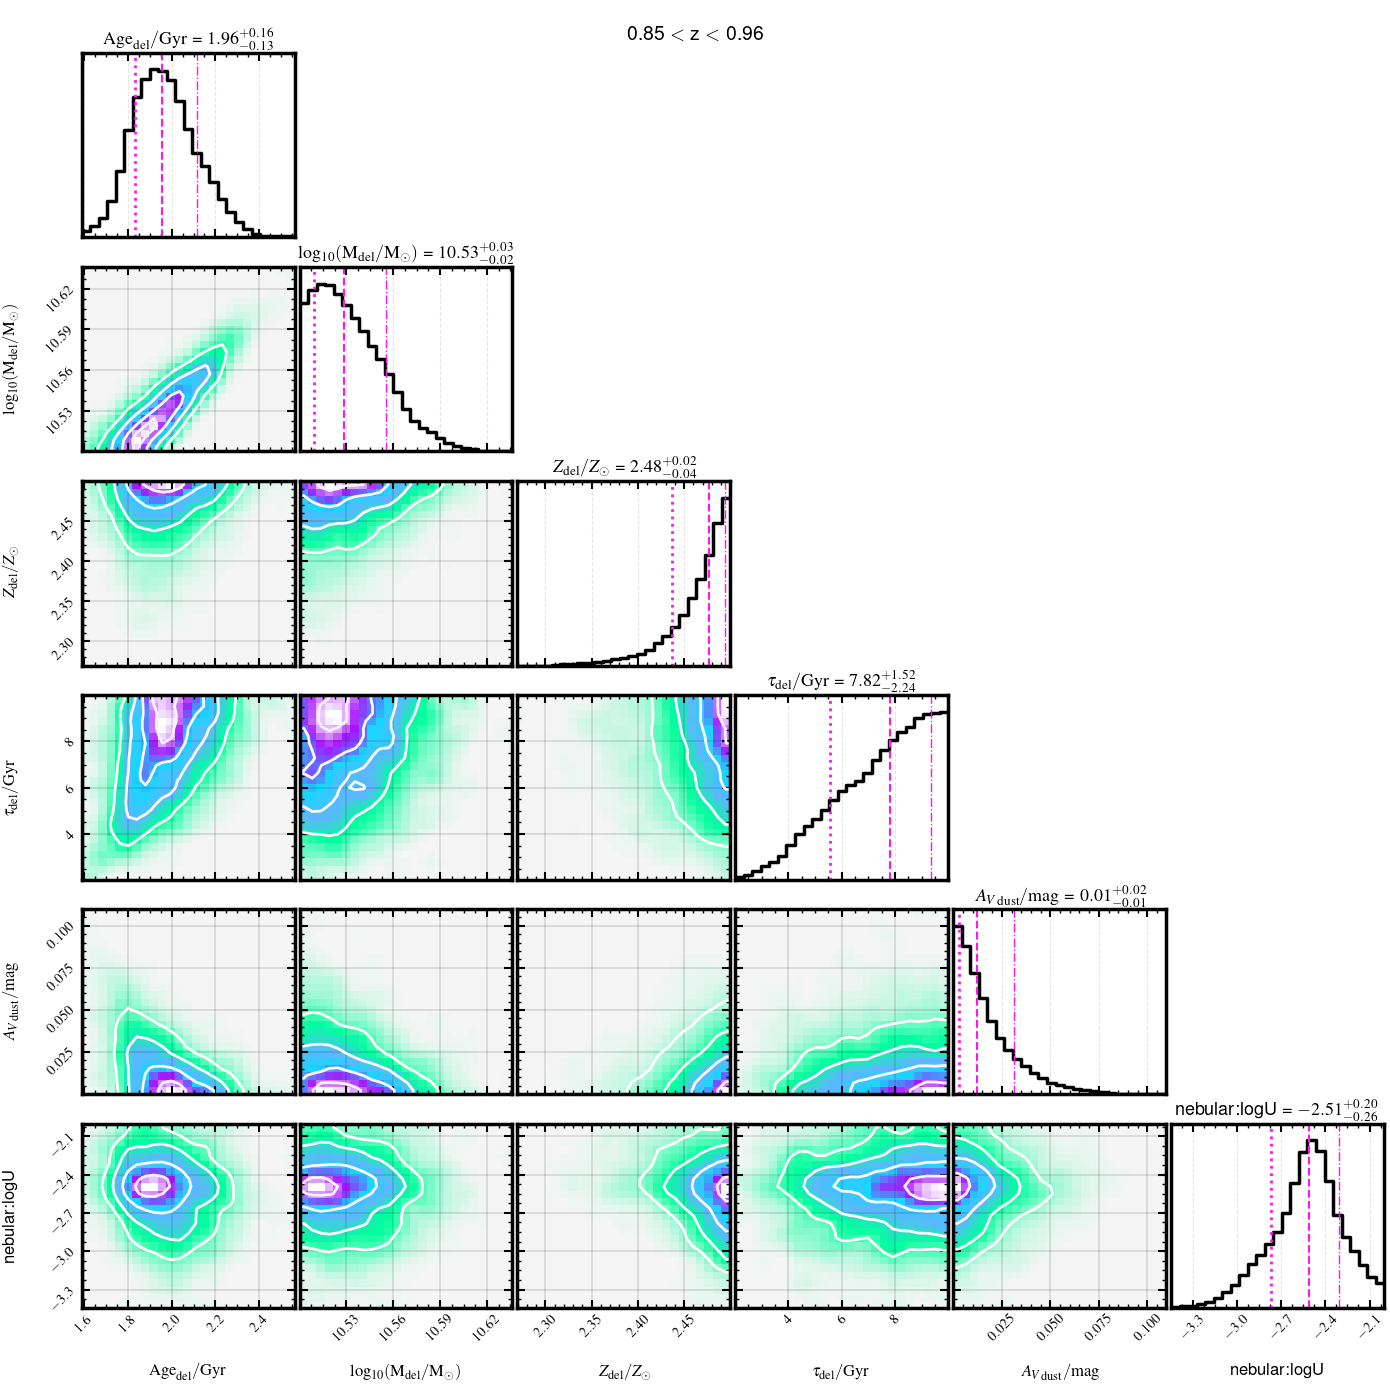

In [49]:
# Set MNRAS style first
set_mnras_style()

# Create and customize corner plot
fig_corner_085_096 = Luminosity_Corrected_fit_result_085_096.plot_corner(save=False, show=False)
fig_corner_085_096 = customize_corner_plot(fig_corner_085_096, fitt="Redshift_085_096_n=1000_optimized_v3_tight_MCMC_Plotfixed_Corrected_Luminosities_Stellar_a", title=r"0.85 $<$ z $<$ 0.96")
# Extract figure if tuple
if isinstance(fig_corner_085_096, tuple):
    fig_corner_085_096 = fig_corner_085_096[0]
plt.show()



In [50]:
Stellar_Mass_025_035 =Luminosity_Corrected_fit_result_025_035.posterior.samples["stellar_mass"]
Stellar_Mass_035_045 =Luminosity_Corrected_fit_result_035_045.posterior.samples["stellar_mass"]
Stellar_Mass_045_055 =Luminosity_Corrected_fit_result_045_055.posterior.samples["stellar_mass"]
Stellar_Mass_055_065 =Luminosity_Corrected_fit_result_055_065.posterior.samples["stellar_mass"]
Stellar_Mass_065_075 =Luminosity_Corrected_fit_result_065_075.posterior.samples["stellar_mass"]
Stellar_Mass_075_085 =Luminosity_Corrected_fit_result_075_085.posterior.samples["stellar_mass"]
Stellar_Mass_085_096 =Luminosity_Corrected_fit_result_085_096.posterior.samples["stellar_mass"]



In [51]:
Redshift_All = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.905]

Stellar_Masses_All = [Stellar_Mass_025_035, Stellar_Mass_035_045, Stellar_Mass_045_055, Stellar_Mass_055_065, Stellar_Mass_065_075, 
                      Stellar_Mass_075_085, Stellar_Mass_085_096]



In [52]:
print(np.average(Stellar_Mass_025_035))
print(np.average(Stellar_Mass_035_045))
print(np.average(Stellar_Mass_045_055))
print(np.average(Stellar_Mass_055_065))
print(np.average(Stellar_Mass_065_075))
print(np.average(Stellar_Mass_075_085))
print(np.average(Stellar_Mass_085_096))


10.283467138132124
10.323373277077412
10.261966632928866
10.265320694470516
10.279169455275364
10.290059659836414
10.331590597129106


In [53]:
#print(fit_result_085_096.sfh.stellar_mass)

In [54]:
# Your array of samples
stellar_mass_samples = Luminosity_Corrected_fit_result_085_096.posterior.samples["stellar_mass"]

# Method 1: Median with 16th and 84th percentiles (equivalent to ±1σ for normal distributions)
median = np.median(stellar_mass_samples)
p16, p84 = np.percentile(stellar_mass_samples, [16, 84])
lower_err = median - p16
upper_err = p84 - median

print(f"Stellar Mass: {median:.3f} +{upper_err:.3f} -{lower_err:.3f}")
# or for symmetric errors, you can average them:
avg_err = (lower_err + upper_err) / 2
print(f"Stellar Mass: {median:.3f} ± {avg_err:.3f}")

# Method 2: Mean and standard deviation (if you prefer)
mean = np.mean(stellar_mass_samples)
std = np.std(stellar_mass_samples)
print(f"Stellar Mass: {mean:.3f} ± {std:.3f}")


Stellar Mass: 10.328 +0.025 -0.016
Stellar Mass: 10.328 ± 0.021
Stellar Mass: 10.332 ± 0.020


In [55]:
def print_fit_results_linear(fit):
    """Print median ± error in linear units where appropriate"""
    print("Parameter Results (Linear Units):")
    print("-" * 60)
    
    for param in sorted(fit.posterior.samples.keys()):
        if param.startswith(('delayed:', 'dust:', 'stellar_mass', 'sfr', 'mass_weighted')):
            samples = fit.posterior.samples[param]
            median = np.median(samples)
            error = (np.percentile(samples, 84) - np.percentile(samples, 16)) / 2
            
            # Convert log parameters to linear
            if 'mass' in param and 'age' not in param and 'zmet' not in param:
                # Mass parameters (log M☉ -> M☉)
                linear_median = 10**median
                # Error propagation for log->linear: σ_linear = ln(10) * 10^median * σ_log
                linear_error = np.log(10) * linear_median * error
                print(f"{param:25s}: {linear_median:.2e} ± {linear_error:.2e} M☉")
                
            elif param == 'delayed:metallicity' or 'zmet' in param:
                # Metallicity (Z☉ units, already linear)
                print(f"{param:25s}: {median:.4f} ± {error:.4f} Z☉")
                
            elif 'age' in param or param == 'delayed:tau':
                # Time parameters (already in Gyr)
                print(f"{param:25s}: {median:.3f} ± {error:.3f} Gyr")
                
            elif param == 'dust:Av':
                # Dust attenuation (already linear in mag)
                print(f"{param:25s}: {median:.3f} ± {error:.3f} mag")
                
            elif param == 'sfr':
                # Star formation rate (already linear)
                print(f"{param:25s}: {median:.3f} ± {error:.3f} M☉/yr")
                
            elif param == 'ssfr':
                # Specific SFR (already linear)
                print(f"{param:25s}: {median:.2e} ± {error:.2e} yr⁻¹")
                
            else:
                # Default: print as-is with appropriate precision
                if error < 0.01:
                    print(f"{param:25s}: {median:.4f} ± {error:.4f}")
                else:
                    print(f"{param:25s}: {median:.3f} ± {error:.3f}")

# Usage:
print_fit_results_linear(Luminosity_Corrected_fit_result_085_096)


Parameter Results (Linear Units):
------------------------------------------------------------
delayed:age              : 1.945 ± 0.156 Gyr
delayed:massformed       : 3.36e+10 ± 1.85e+09 M☉
delayed:metallicity      : 2.4784 ± 0.0284 Z☉
delayed:tau              : 7.688 ± 1.910 Gyr
dust:Av                  : 0.013 ± 0.015 mag
mass_weighted_age        : 0.678 ± 0.052 Gyr
mass_weighted_zmet       : 2.4780 ± 0.0289 Z☉
sfr                      : 30.786 ± 0.913 M☉/yr
stellar_mass             : 2.13e+10 ± 1.02e+09 M☉


In [56]:
np.average(Stellar_Mass_085_096)


10.331590597129106

In [57]:
print(10**np.average(Stellar_Mass_085_096))


21458067007.129192


In [58]:
import h5py
import numpy as np
import pickle

def save_variables_to_hdf5(filepath, variable_names):
    """Save variables to HDF5 file"""
    user_vars = {}
    missing_vars = []
    
    for var_name in variable_names:
        if var_name in globals():
            obj = globals()[var_name]
            
            # Store the data type for reconstruction
            if isinstance(obj, str):
                user_vars[var_name] = ('string', obj)
            elif isinstance(obj, (int, float, bool, np.integer, np.floating)):
                user_vars[var_name] = ('scalar', obj)
            elif isinstance(obj, np.ndarray):
                user_vars[var_name] = ('ndarray', obj)
            elif isinstance(obj, (list, tuple)):
                # Try to convert to numpy array
                try:
                    arr = np.array(obj)
                    # Check if it's a regular array (not object dtype from irregular shapes)
                    if arr.dtype == object:
                        # It's irregular/jagged - store as pickle
                        user_vars[var_name] = ('pickle', pickle.dumps(obj))
                    else:
                        user_vars[var_name] = ('array', arr)
                except (ValueError, TypeError):
                    # Can't convert to array - store as pickle
                    user_vars[var_name] = ('pickle', pickle.dumps(obj))
            else:
                # Store complex objects as pickle
                user_vars[var_name] = ('pickle', pickle.dumps(obj))
        else:
            missing_vars.append(var_name)
    
    if missing_vars:
        print(f"Warning: {len(missing_vars)} variables not found in namespace:")
        for var in missing_vars[:5]:
            print(f"  - {var}")
        if len(missing_vars) > 5:
            print(f"  ... and {len(missing_vars) - 5} more")
    
    if user_vars:
        with h5py.File(filepath, 'w') as f:
            for var_name, (data_type, var_value) in user_vars.items():
                try:
                    if data_type == 'string':
                        f.create_dataset(var_name, data=np.string_(var_value))
                        f[var_name].attrs['data_type'] = 'string'
                    elif data_type == 'scalar':
                        f.create_dataset(var_name, data=var_value)
                        f[var_name].attrs['data_type'] = 'scalar'
                    elif data_type in ('ndarray', 'array'):
                        f.create_dataset(var_name, data=var_value)
                        f[var_name].attrs['data_type'] = 'array'
                    elif data_type == 'pickle':
                        # Store pickled data as bytes
                        f.create_dataset(var_name, data=np.void(var_value))
                        f[var_name].attrs['data_type'] = 'pickle'
                except Exception as e:
                    print(f"Error saving {var_name}: {e}")
        
        print(f"Successfully saved {len(user_vars)} variables to {filepath}")
        return True
    else:
        print("No variables found to save!")
        return False

        
def load_variables_from_hdf5(filepath, auto_assign=True):
    """Load variables from HDF5 file"""
    vars_dict = {}
    
    with h5py.File(filepath, 'r') as f:
        for var_name in f.keys():
            data = f[var_name][()]
            
            # Handle string data
            if isinstance(data, bytes):
                data = data.decode('utf-8')
            elif isinstance(data, np.ndarray) and data.dtype.kind == 'S':
                data = data.astype(str)
            
            vars_dict[var_name] = data
    
    if auto_assign:
        import inspect
        frame = inspect.currentframe()
        try:
            caller_globals = frame.f_back.f_globals
            for var_name, var_value in vars_dict.items():
                caller_globals[var_name] = var_value
            
            print(f"Successfully loaded and assigned {len(vars_dict)} variables")
            print("Sample variables:")
            for i, var_name in enumerate(vars_dict.keys()):
                if i < 3:
                    print(f"  - {var_name}")
                elif i == 3:
                    print(f"  ... and {len(vars_dict) - 3} more")
                    break
        finally:
            del frame
    
    return vars_dict

# Your variable list (same as before)
variable_list = ["Luminosity_Corrected_fit_result_025_035",
                 "Luminosity_Corrected_fit_result_035_045",
                 "Luminosity_Corrected_fit_result_045_055",
                 "Luminosity_Corrected_fit_result_055_065",
                 "Luminosity_Corrected_fit_result_065_075",
                 "Luminosity_Corrected_fit_result_075_085",
                 "Luminosity_Corrected_fit_result_085_096",
                 "Luminosity_Corrected_fit_result_SD_025_035",
                 "Luminosity_Corrected_fit_result_SD_035_045",
                 "Luminosity_Corrected_fit_result_SD_045_055",
                 "Luminosity_Corrected_fit_result_SD_055_065",
                 "Luminosity_Corrected_fit_result_SD_065_075",
                 "Luminosity_Corrected_fit_result_SD_075_085",
                 "Luminosity_Corrected_fit_result_SD_085_096",
                 "Luminosity_Corrected_Flux_Corrected_SD_025_035",
                 "Luminosity_Corrected_Flux_Corrected_SD_035_045",
                 "Luminosity_Corrected_Flux_Corrected_SD_045_055",
                 "Luminosity_Corrected_Flux_Corrected_SD_055_065",
                 "Luminosity_Corrected_Flux_Corrected_SD_065_075",
                 "Luminosity_Corrected_Flux_Corrected_SD_075_085",
                 "Luminosity_Corrected_Flux_Corrected_SD_085_096",
                 "Luminosity_Corrected_Flux_Corrected_025_035",
                 "Luminosity_Corrected_Flux_Corrected_035_045",
                 "Luminosity_Corrected_Flux_Corrected_045_055",
                 "Luminosity_Corrected_Flux_Corrected_055_065",
                 "Luminosity_Corrected_Flux_Corrected_065_075",
                 "Luminosity_Corrected_Flux_Corrected_075_085",
                 "Luminosity_Corrected_Flux_Corrected_085_096",
                 "Stellar_Mass_025_035",
                 "Stellar_Mass_035_045",
                 "Stellar_Mass_045_055",
                 "Stellar_Mass_055_065",
                 "Stellar_Mass_065_075",
                 "Stellar_Mass_075_085",
                 "Stellar_Mass_085_096"
]


# Remove duplicates
unique_variables = []
seen = set()
for var in variable_list:
    if var not in seen:
        unique_variables.append(var)
        seen.add(var)

print(f"Found {len(unique_variables)} unique variables to save")

# Save to HDF5
save_variables_to_hdf5(
    "/home/jovyan/work/stampede3/AGN-Black-Hole-Research/All_Variables_Luminosity_Corrected_Bagpipes.h5",
    unique_variables
)


# To load later:
# vars_dict = load_variables_from_hdf5("/home/jovyan/work/stampede3/AGN-Black-Hole-Research/All_Variables.h5")

Found 35 unique variables to save
Successfully saved 35 variables to /home/jovyan/work/stampede3/AGN-Black-Hole-Research/All_Variables_Luminosity_Corrected_Bagpipes.h5


True

In [59]:
best_fit, galaxy, history = run_adaptive_bagpipes_fit(
    flux_array=your_flux,
    flux_err_array=your_flux_errors,
    filter_response_files=your_filters,
    redshift=your_redshift,
    n_live=400,
    target_quality=0.7,  # Adjust this (0-1)
    max_iterations=3,    # Usually 2-3 iterations is enough
    verbose=True
)

NameError: name 'your_flux' is not defined

In [ ]:
aaaaaaaaaaaaaaa

In [ ]:
set_mnras_style()

# Create and customize SFH plot
fig_sfh = fit_result_025_035.plot_sfh_posterior(save=False, show=False)
fig_sfh = customize_sfh_plot(fig_sfh)
# Extract figure if tuple
if isinstance(fig_sfh, tuple):
    fig_sfh = fig_sfh[0]

plt.ylim(-10, 130)

plt.show()